# Единый пайплайн: данные, прогноз и аналитический бюллетень

Этот ноутбук строит полный воспроизводимый пайплайн для еженедельного эпидемиологического бюллетеня.

Последовательность работы:

1. LLM-агент определяет город по пользовательскому запросу.
2. По выбранному городу загружаются данные по заболеваемости и погоде.
3. На этих данных строится прогноз заболеваемости на четыре недели.
4. Из исходных эпидемиологических данных рассчитывается сезонная статистика по возрастным группам.
5. Набор секционных narrator-агентов формирует текст бюллетеня на основе структурированных данных.
6. Отдельный editor-агент может упростить и выровнять формулировки без изменения фактов и чисел.
7. Итоговый бюллетень сохраняется в PDF.

В ноутбуке оставлена рабочая цепочка B -> E: `B_decomposed` формирует исходный бюллетень, `E_editor` выполняет редакторское улучшение текста.


## Структура ноутбука

Ноутбук разделён на логические блоки.

- **Подготовка данных.** Загрузка справочника городов, выбор города через агента, загрузка временных рядов и погодных признаков.
- **Прогнозирование.** Обучение моделей, расчёт прогнозов, метрик и интервалов неопределённости.
- **Контекст бюллетеня.** Преобразование результатов моделирования в компактный структурированный контекст для генерации текста.
- **Генерация текста.** Секционные narrator-агенты создают отдельные части бюллетеня.
- **Редактирование.** Editor-агент улучшает читаемость текста, сохраняя исходные числа, смысл и структуру.
- **PDF-рендеринг.** Бюллетень выводится в PDF с таблицами, рассчитанными на перенос строк.

Экспериментальные блоки single-pass generation, external review и section-consistency удалены. Основная рабочая цепочка не зависит от них.


## Импорты и настройка путей


In [1]:
import sys
from pathlib import Path

# ⚠️  НАСТРОЙТЕ ПУТЬ К РЕПОЗИТОРИЮ
# Укажите корень репозитория model_complex, содержащий папку model_complex/
# Варианты:
#   REPO_ROOT = Path(r"C:\path\to\model_complex-main")   # Windows
#   REPO_ROOT = Path("/path/to/model_complex-main")          # Linux/Mac
#   REPO_ROOT = Path(".")                                     # если ноутбук лежит в корне репо
# REPO_ROOT = Path(".").resolve()  # <- по умолчанию: текущая директория
REPO_ROOT = Path(r"C:\Users\user\Desktop\Mark_files\model_complex-main\model_complex-main")


if not (REPO_ROOT / "model_complex").exists():
    raise FileNotFoundError(
        "Не найден каталог 'model_complex'. "
        "Переместите ноутбук в корень репозитория или поправьте REPO_ROOT."
    )

sys.path.insert(0, str(REPO_ROOT))
print("OK. REPO_ROOT =", REPO_ROOT)

import json
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from datetime import date, datetime, timedelta
from collections.abc import Iterable
from IPython.display import display

from model_complex import InfluenzaData, Calibration, FactoryModel, Forecast, ModelParams
import os
import difflib


OK. REPO_ROOT = C:\Users\user\Desktop\Mark_files\model_complex-main\model_complex-main


## Реестр городов


In [2]:
# ---------------------------------------------------------------------------
# CITY_REGISTRY: slug -> (api_id, название_на_русском)
# Источник: Города_в_API.xlsx + russia=0 (вся страна)
# Этот словарь используется агентом и функциями пайплайна.
# Если вы обновляете influenza_data.py, убедитесь, что оба словаря синхронизированы.
# ---------------------------------------------------------------------------
CITY_REGISTRY: dict = {
    "russia":            (0,   "Россия"),
    "birobidzhan":       (7,   "Биробиджан"),
    "arkhangelsk":       (9,   "Архангельск"),
    "astrakhan":         (10,  "Астрахань"),
    "barnaul":           (11,  "Барнаул"),
    "orenburg":          (12,  "Оренбург"),
    "vladivostok":       (13,  "Владивосток"),
    "volgograd":         (14,  "Волгоград"),
    "voronezh":          (15,  "Воронеж"),
    "nizhny_novgorod":   (16,  "Нижний Новгород"),
    "irkutsk":           (19,  "Иркутск"),
    "kaliningrad":       (20,  "Калининград"),
    "murmansk":          (21,  "Мурманск"),
    "novosibirsk":       (22,  "Новосибирск"),
    "saratov":           (24,  "Саратов"),
    "khabarovsk":        (26,  "Хабаровск"),
    "moscow":            (32,  "Москва"),
    "tomsk":             (34,  "Томск"),
    "vladimir":          (36,  "Владимир"),
    "spb":               (38,  "Санкт-Петербург"),
    "yaroslavl":         (40,  "Ярославль"),
    "kazan":             (41,  "Казань"),
    "kemerovo":          (43,  "Кемерово"),
    "kirov":             (44,  "Киров"),
    "cheboksary":        (45,  "Чебоксары"),
    "magadan":           (46,  "Магадан"),
    "norilsk":           (47,  "Норильск"),
    "vladikavkaz":       (48,  "Владикавказ"),
    "perm":              (49,  "Пермь"),
    "petropavlovsk":     (50,  "Петропавловск"),
    "rostov_na_donu":    (51,  "Ростов-на-Дону"),
    "smolensk":          (53,  "Смоленск"),
    "stavropol":         (54,  "Ставрополь"),
    "ulan_ude":          (55,  "Улан-Удэ"),
    "ufa":               (56,  "Уфа"),
    "chelyabinsk":       (57,  "Челябинск"),
    "yakutsk":           (58,  "Якутск"),
    "chita":             (59,  "Чита"),
    "yuzhno_sakhalinsk": (60,  "Южно-Сахалинск"),
    "krasnodar":         (61,  "Краснодар"),
    "krasnoyarsk":       (62,  "Красноярск"),
    "samara":            (63,  "Самара"),
    "omsk":              (64,  "Омск"),
    "yekaterinburg":     (68,  "Екатеринбург"),
    "pskov":             (69,  "Псков"),
    "petrozavodsk":      (70,  "Петрозаводск"),
    "lipetsk":           (71,  "Липецк"),
    "izhevsk":           (72,  "Ижевск"),
    "tula":              (73,  "Тула"),
    "ulyanovsk":         (74,  "Ульяновск"),
    "bryansk":           (75,  "Брянск"),
    "vologda":           (76,  "Вологда"),
    "syktyvkar":         (77,  "Сыктывкар"),
    "orel":              (78,  "Орёл"),
    "ryazan":            (79,  "Рязань"),
    "tver":              (80,  "Тверь"),
    "belgorod":          (81,  "Белгород"),
    "kursk":             (82,  "Курск"),
    "cherepovets":       (83,  "Череповец"),
    "penza":             (84,  "Пенза"),
    "veliky_novgorod":   (85,  "Великий Новгород"),
    "simferopol":        (91,  "Симферополь"),
    "sevastopol":        (92,  "Севастополь"),
    "donetsk":           (102, "Донецк"),
    "lugansk":           (103, "Луганск"),
    "kherson":           (104, "Херсон"),
    "zaporizhzhia":      (105, "Запорожье"),
}

print(f"CITY_REGISTRY загружен: {len(CITY_REGISTRY)} городов.")


CITY_REGISTRY загружен: 67 городов.


## Вспомогательные функции пайплайна


In [3]:
# ---------------------------------------------------------------------------
# Presets с жёстко прописанными координатами (ускоряет работу для частых городов).
# Для остальных городов координаты получаются через геокодинг Open-Meteo.
# ---------------------------------------------------------------------------
CITY_PRESETS = {
    # Санкт-Петербург
    "spb": {
        "influenza_code": "spb",
        "weather_query": "Saint Petersburg",
        "latitude": 59.9311,
        "longitude": 30.3609,
        "timezone": "Europe/Moscow",
    },
    # Москва
    "moscow": {
        "influenza_code": "moscow",
        "weather_query": "Moscow",
        "latitude": 55.7558,
        "longitude": 37.6173,
        "timezone": "Europe/Moscow",
    },
    # Новосибирск
    "novosibirsk": {
        "influenza_code": "novosibirsk",
        "weather_query": "Novosibirsk",
        "latitude": 54.9833,
        "longitude": 82.8964,
        "timezone": "Asia/Novosibirsk",
    },
    # Екатеринбург
    "yekaterinburg": {
        "influenza_code": "yekaterinburg",
        "weather_query": "Yekaterinburg",
        "latitude": 56.8389,
        "longitude": 60.6057,
        "timezone": "Asia/Yekaterinburg",
    },
    # Краснодар
    "krasnodar": {
        "influenza_code": "krasnodar",
        "weather_query": "Krasnodar",
        "latitude": 45.0355,
        "longitude": 38.9753,
        "timezone": "Europe/Moscow",
    },
}


def _normalize_city_list(cities):
    if isinstance(cities, str):
        return [cities]
    if isinstance(cities, Iterable):
        return list(cities)
    raise TypeError("cities должен быть строкой или итерируемым набором строк.")


def _normalize_end_date(end_date=None):
    if end_date is None:
        return date.today()
    if isinstance(end_date, pd.Timestamp):
        return end_date.date()
    if isinstance(end_date, datetime):
        return end_date.date()
    if isinstance(end_date, date):
        return end_date
    return pd.Timestamp(end_date).date()


def _safe_city_slug(city):
    city = str(city).strip().lower()
    city = re.sub(r"\s+", "_", city)
    city = re.sub(r"[^0-9a-zA-Zа-яА-Я_-]+", "_", city)
    city = re.sub(r"_+", "_", city).strip("_")
    return city


def _resolve_city_config(city):
    """
    Возвращает конфиг города.
    Сначала ищет в CITY_PRESETS (жёсткие координаты),
    затем строит минимальный конфиг для геокодинга.
    """
    city_raw = str(city).strip()
    city_key = city_raw.lower()

    if city_key in CITY_PRESETS:
        cfg = CITY_PRESETS[city_key].copy()
        cfg["input_city"] = city_raw
        cfg["output_slug"] = _safe_city_slug(cfg["influenza_code"])
        return cfg

    # Fallback: используем city_key как код для InfluenzaData
    # и как запрос для геокодинга (Open-Meteo найдёт город по транслитерации)
    name_ru = CITY_REGISTRY.get(city_key, (None, city_raw))[1]
    return {
        "input_city": city_raw,
        "influenza_code": city_key,
        "weather_query": name_ru,   # геокодинг по русскому названию надёжнее
        "output_slug": _safe_city_slug(city_key),
    }


def _resolve_weather_location(city_config):
    if "latitude" in city_config and "longitude" in city_config and "timezone" in city_config:
        return city_config

    url = "https://geocoding-api.open-meteo.com/v1/search"
    params = {
        "name": city_config["weather_query"],
        "count": 1,
        "language": "ru",
        "format": "json",
    }
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    js = r.json()

    results = js.get("results") or []
    if not results:
        raise ValueError(f"Не удалось определить координаты для города: {city_config['weather_query']}")

    best = results[0]
    city_config = city_config.copy()
    city_config["latitude"] = best["latitude"]
    city_config["longitude"] = best["longitude"]
    city_config["timezone"] = best.get("timezone", "UTC")
    return city_config


def fetch_hourly_chunk(lat, lon, start_date, end_date, timezone):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date.isoformat(),
        "end_date": end_date.isoformat(),
        "hourly": "temperature_2m,relative_humidity_2m",
        "timezone": timezone,
    }
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    js = r.json()

    h = js["hourly"]
    return pd.DataFrame({
        "time": pd.to_datetime(h["time"]),
        "temp": h["temperature_2m"],
        "rh": h["relative_humidity_2m"],
    })


def fetch_hourly_yearly(lat, lon, start_date, end_date, timezone):
    parts = []
    for y in range(start_date.year, end_date.year + 1):
        s = max(start_date, pd.Timestamp(f"{y}-01-01").date())
        e = min(end_date,   pd.Timestamp(f"{y}-12-31").date())
        parts.append(fetch_hourly_chunk(lat, lon, s, e, timezone))
    out = pd.concat(parts, ignore_index=True)
    return out.drop_duplicates(subset=["time"]).sort_values("time")


def run_influenza_api_block(city, end_date=None):
    city_config = _resolve_city_config(city)
    city_code   = city_config["influenza_code"]

    end_dt = _normalize_end_date(end_date)
    today_iso = end_dt.isocalendar()
    end_year, end_week = today_iso.year, today_iso.week

    epid = InfluenzaData(city_code, 2011, 1, end_year, end_week)

    raw_df = epid.cases_df.copy()
    raw_df["datetime"] = pd.to_datetime(raw_df["datetime"])
    raw_df = raw_df.sort_values("datetime").reset_index(drop=True)

    df = raw_df.copy()
    strain_cols = [f"real_cases_strain_{i}" for i in range(4)]
    df["total_cases_formula"] = df.fillna(0)[strain_cols].sum(axis=1)
    df["inc_per_10k"] = df["total_cases_formula"] / df["total_population"] * 10000
    df["iso_year"] = df["datetime"].dt.isocalendar().year.astype(int)
    df["iso_week"] = df["datetime"].dt.isocalendar().week.astype(int)
    df = df.dropna(subset=["inc_per_10k", "total_population"]).reset_index(drop=True)

    out_path = f"influenza_{city_config['output_slug']}_weekly_2011_to_latest_formula.csv"
    df[["datetime", "iso_year", "iso_week", "total_population",
        "total_cases_formula", "inc_per_10k"]].to_csv(out_path, index=False, encoding="utf-8")

    last_y = int(df["iso_year"].iloc[-1])
    last_w = int(df["iso_week"].iloc[-1])
    print(f"Сохранено: {out_path}")
    print(f"Последняя доступная неделя: {last_y} W{last_w:02d} | строк: {len(df)}")
    display(df.head())
    display(df.tail())

    return out_path, df, raw_df, city_config


def run_weather_block(city, infl_path):
    city_config = _resolve_city_config(city)
    city_config = _resolve_weather_location(city_config)

    infl = pd.read_csv(infl_path)
    infl["datetime"] = pd.to_datetime(infl["datetime"])

    assert (infl["datetime"].dt.dayofweek == 0).all(), "Ожидались даты-понедельники (начало недели)."

    start_date = infl["datetime"].min().date()
    end_date   = (infl["datetime"].max() + pd.Timedelta(days=6)).date()

    LAT, LON, TZ = city_config["latitude"], city_config["longitude"], city_config["timezone"]

    weather_h = fetch_hourly_yearly(LAT, LON, start_date, end_date, TZ)
    weather_h["time"] = pd.to_datetime(weather_h["time"])
    weather_h["week_start"] = weather_h["time"].dt.to_period("W-SUN").dt.start_time

    weekly = (
        weather_h
        .groupby("week_start", as_index=False)
        .agg(
            temp_mean=("temp", "mean"),
            temp_max=("temp", "max"),
            temp_min=("temp", "min"),
            rh_mean=("rh", "mean"),
            rh_max=("rh", "max"),
            rh_min=("rh", "min"),
            n_hours=("temp", "count"),
        )
    )

    missing = pd.Index(infl["datetime"]).difference(pd.Index(weekly["week_start"]))
    if len(missing) > 0:
        raise ValueError(f"Нет погоды для {len(missing)} недель. Примеры: {missing[:5].tolist()}")

    bad = weekly.loc[weekly["n_hours"] < 150, ["week_start", "n_hours"]]
    if len(bad) > 0:
        raise ValueError(f"Подозрительно неполные недели по часам:\n{bad.head(10)}")

    merged = (
        infl.merge(
            weekly.drop(columns=["n_hours"]),
            left_on="datetime", right_on="week_start",
            how="left",
            validate="one_to_one"
        )
        .drop(columns=["week_start"])
    )

    weather_cols = ["temp_mean", "temp_max", "temp_min", "rh_mean", "rh_max", "rh_min"]
    if merged[weather_cols].isna().any().any():
        rows = merged.loc[merged[weather_cols].isna().any(axis=1), ["datetime"] + weather_cols].head(10)
        raise ValueError(f"После merge есть NaN в погоде:\n{rows}")

    out_path = f"influenza_weather_{city_config['output_slug']}_weekly.csv"
    merged.to_csv(out_path, index=False)
    print(f"Saved: {out_path}")
    print(merged[["datetime", "temp_mean", "temp_max", "temp_min", "rh_mean", "rh_max", "rh_min"]].head())

    return out_path, merged, city_config


def run_full_pipeline(cities, end_date=None):
    results = {}
    for city in _normalize_city_list(cities):
        print("=" * 100)
        print(f"Обработка: {city}")
        infl_path, infl_df, infl_raw_df, city_config = run_influenza_api_block(city, end_date=end_date)
        weather_path, merged_df, city_config = run_weather_block(city, infl_path)
        results[city] = {
            "city_config": city_config,
            "influenza_path": infl_path,
            "weather_path": weather_path,
            "influenza_df": infl_df,
            "influenza_raw_df": infl_raw_df,
            "merged_df": merged_df,
        }
    return results


## LLM-агент выбора города

Этот блок определяет город по запросу пользователя. Например, запрос «Хочу данные по Питеру» должен быть преобразован в код `spb`.

Результат агента используется не только для демонстрации. Далее именно выбранный агентом город передаётся в загрузку данных, после чего из этих данных формируются:

- `df` — датафрейм для прогноза заболеваемости;
- `age_ari_source_df` — датафрейм для сезонной статистики по возрастным группам.


In [4]:
# ============================================================
#  Настройки агента — правьте здесь
# ============================================================
OLLAMA_BASE_URL = "http://localhost:11434"   # адрес Ollama
OLLAMA_MODEL    = "qwen3.5:9b"              # имя модели (ollama list)
AGENT_TIMEOUT   = 60                         # секунд на ответ

# ============================================================
#  Строим список городов из CITY_REGISTRY для системного промпта
# ============================================================
_CITY_LIST_FOR_PROMPT = "\n".join(
    f"  {slug} — {name_ru}"
    for slug, (_, name_ru) in sorted(CITY_REGISTRY.items(), key=lambda x: x[1][1])
)

_SYSTEM_PROMPT = f"""Ты — агент разбора запросов к базе данных эпидемиологического надзора за гриппом России.

Твоя задача: по запросу пользователя определить, данные по какому городу нужно загрузить.

Список доступных городов (код — русское название):
{_CITY_LIST_FOR_PROMPT}

Правила:
1. Отвечай ТОЛЬКО валидным JSON, без пояснений, без markdown-обёрток.
2. Если город определён однозначно:
   {{"status": "ok", "city_code": "<код>", "city_name": "<название_на_русском>", "confidence": <0.0-1.0>}}
3. Если запрос неоднозначен (например, «Новгород» — это Нижний Новгород или Великий Новгород?):
   {{"status": "ambiguous", "candidates": ["код1", "код2"], "city_code": null, "city_name": null}}
4. Если город не найден в списке:
   {{"status": "not_found", "city_code": null, "city_name": null}}
5. Если в запросе явно указан slug (например, «spb», «moscow») — используй его напрямую.
"""


def _call_ollama(user_message: str) -> dict:
    """
    Вызов Ollama Chat API. Возвращает распарсенный JSON-ответ агента.
    Бросает исключение, если Ollama недоступна или ответ не является JSON.
    """
    payload = {
        "model": OLLAMA_MODEL,
        "messages": [
            {"role": "system", "content": _SYSTEM_PROMPT},
            {"role": "user",   "content": user_message},
        ],
        "stream": False,
        "options": {"temperature": 0.1},   # низкая температура = более детерминированный вывод
    }

    try:
        resp = requests.post(
            f"{OLLAMA_BASE_URL}/api/chat",
            json=payload,
            timeout=AGENT_TIMEOUT,
        )
        resp.raise_for_status()
    except requests.exceptions.ConnectionError:
        raise RuntimeError(
            f"Нет соединения с Ollama по адресу {OLLAMA_BASE_URL}. "
            "Убедитесь, что сервис запущен (`ollama serve`)."
        )

    content = resp.json()["message"]["content"].strip()

    # Извлекаем JSON из ответа — модель может обернуть его в ```json ... ```
    json_match = re.search(r"\{.*\}", content, re.DOTALL)
    if not json_match:
        raise ValueError(f"Агент вернул не-JSON ответ:\n{content}")

    return json.loads(json_match.group())


def resolve_city_with_agent(user_message: str, interactive: bool = True) -> str | None:
    """
    По запросу пользователя возвращает город (city_code для InfluenzaData).

    Parameters
    ----------
    user_message : str
        Запрос на естественном языке (рус/англ).
    interactive : bool
        Если True — при неоднозначности спрашивает пользователя в консоли.
        Если False — бросает ValueError при неоднозначности.

    Returns
    -------
    str | None
        Код города (ключ из CITY_REGISTRY) или None, если определить не удалось.
    """
    print(f"[Агент] Запрос: '{user_message}'")
    result = _call_ollama(user_message)
    print(f"[Агент] Ответ модели: {result}")

    status = result.get("status")

    # --- Успех ---
    if status == "ok":
        city_code = result["city_code"]
        city_name = result.get("city_name", city_code)
        confidence = result.get("confidence", 1.0)
        print(f"[Агент] Определён город: {city_name} (код: {city_code}, уверенность: {confidence:.0%})")
        return city_code

    # --- Неоднозначность ---
    if status == "ambiguous":
        candidates = result.get("candidates", [])
        print("[Агент] Неоднозначный запрос. Возможные города:")
        for i, code in enumerate(candidates, 1):
            name_ru = CITY_REGISTRY.get(code, (None, code))[1]
            print(f"  {i}. {name_ru} (код: {code})")

        if not interactive:
            raise ValueError(
                f"Неоднозначный запрос. Уточните город. Варианты: {candidates}"
            )

        choice = input("Введите номер нужного города (или 0 для отмены): ").strip()
        if choice == "0" or not choice.isdigit():
            print("[Агент] Отменено.")
            return None
        idx = int(choice) - 1
        if 0 <= idx < len(candidates):
            city_code = candidates[idx]
            print(f"[Агент] Выбран: {CITY_REGISTRY.get(city_code, (None, city_code))[1]}")
            return city_code
        print("[Агент] Некорректный выбор.")
        return None

    # --- Не найден ---
    print("[Агент] Город не найден в базе данных.")
    print("Доступные города:")
    for slug, (_, name_ru) in sorted(CITY_REGISTRY.items(), key=lambda x: x[1][1]):
        print(f"  {slug}: {name_ru}")
    return None


print("LLM-агент инициализирован.")
print(f"  Модель : {OLLAMA_MODEL}")
print(f"  Адрес  : {OLLAMA_BASE_URL}")
print(f"  Городов: {len(CITY_REGISTRY)}")


LLM-агент инициализирован.
  Модель : qwen3.5:9b
  Адрес  : http://localhost:11434
  Городов: 67


## Пайплайн с агентом


In [5]:
def run_pipeline_from_query(user_query: str, end_date=None, interactive: bool = True):
    """
    Полный пайплайн: агент определяет город по запросу, затем
    загружает данные по заболеваемости и погоде.

    Parameters
    ----------
    user_query : str
        Запрос на естественном языке.
    end_date : str | date | None
        Конечная дата выборки. None = сегодня.
    interactive : bool
        Разрешить уточняющие вопросы агенту при неоднозначности.

    Returns
    -------
    dict | None
        Результат run_full_pipeline для найденного города, или None.
    """
    city_code = resolve_city_with_agent(user_query, interactive=interactive)
    if city_code is None:
        print("[Пайплайн] Город не определён, загрузка отменена.")
        return None

    return run_full_pipeline(city_code, end_date=end_date)


## Примеры запуска

Ниже приведены примеры вызовов. Они оставлены закомментированными, чтобы ноутбук не запускал лишние загрузки данных случайно.

Основной запуск находится в следующей ячейке: там задаётся текстовый запрос к агенту, после чего формируются рабочие датафреймы.


In [6]:
# Примеры прямого запуска по коду города:
# results = run_full_pipeline("spb")
# results = run_full_pipeline("moscow", end_date="2026-03-01")
# results = run_full_pipeline(["spb", "moscow", "novosibirsk"])

# Примеры запуска через LLM-агент:
# results = run_pipeline_from_query("Хочу посмотреть данные по Петербургу")
# results = run_pipeline_from_query("Load data for Novosibirsk please")
# results = run_pipeline_from_query("Загрузи грипп по Нижнему")
# results = run_pipeline_from_query("екб")
# results = run_pipeline_from_query("Новгород")  # агент должен уточнить: Нижний или Великий Новгород

# Список доступных городов:
# display(InfluenzaData.list_cities())


---

## Формирование рабочих датафреймов через городского агента

В этой ячейке задаётся пользовательский запрос `CITY_QUERY`. Агент определяет город, затем этот город используется для загрузки данных. Поэтому последующие прогнозы, графики и возрастная статистика строятся по одному и тому же выбранному городу.

Если нужен другой город, измените только `CITY_QUERY`.


In [7]:
# Пользовательский запрос к агенту выбора города.
# Примеры: "Хочу данные по Питеру", "Москва", "Load data for Novosibirsk".
CITY_QUERY = "Хочу данные по Питеру"
END_DATE = None


def prepare_city_pipeline_data_from_code(city_code: str, end_date=None) -> dict:
    """
    Загружает данные по уже известному коду города и формирует рабочие датафреймы.

    Возвращает единый словарь, из которого далее берутся:
    - df: данные для прогноза;
    - age_ari_source_df: исходные эпидемиологические данные для возрастной статистики.
    """
    if city_code not in CITY_REGISTRY:
        raise KeyError(f"Неизвестный код города: {city_code!r}. Проверьте CITY_REGISTRY.")

    city_pipeline_data = run_full_pipeline(city_code, end_date=end_date)
    city_payload = city_pipeline_data[city_code]

    forecast_df = city_payload["merged_df"].copy()
    forecast_df["datetime"] = pd.to_datetime(forecast_df["datetime"])
    forecast_df = forecast_df.sort_values("datetime").reset_index(drop=True)

    age_source_df = city_payload["influenza_raw_df"].copy()
    age_source_df["datetime"] = pd.to_datetime(age_source_df["datetime"])
    age_source_df = age_source_df.sort_values("datetime").reset_index(drop=True)

    return {
        "city_code": city_code,
        "city_name_ru": CITY_REGISTRY[city_code][1],
        "pipeline_data": city_pipeline_data,
        "df": forecast_df,
        "age_ari_source_df": age_source_df,
    }


def prepare_city_pipeline_data_from_query(user_query: str, end_date=None, interactive: bool = True) -> dict:
    """
    Основная функция выбора данных для ноутбука.

    Сначала LLM-агент определяет город по естественному запросу.
    Затем найденный город передаётся в загрузку данных и подготовку датафреймов.
    """
    city_code = resolve_city_with_agent(user_query, interactive=interactive)
    if city_code is None:
        raise RuntimeError("Город не определён; дальнейший запуск пайплайна остановлен.")
    return prepare_city_pipeline_data_from_code(city_code, end_date=end_date)


city_data = prepare_city_pipeline_data_from_query(
    CITY_QUERY,
    end_date=END_DATE,
    interactive=True,
)

CITY = city_data["city_code"]
CITY_NAME_RU = city_data["city_name_ru"]
pipeline_data = city_data["pipeline_data"]
df = city_data["df"]
age_ari_source_df = city_data["age_ari_source_df"]

print(f"Выбран город: {CITY_NAME_RU} (код: {CITY})")
print(f"df загружен: {df.shape} строк")
print(f"Диапазон дат df: {df['datetime'].min().date()} — {df['datetime'].max().date()}")
print(f"age_ari_source_df загружен: {age_ari_source_df.shape} строк")
print(f"Диапазон дат age_ari_source_df: {age_ari_source_df['datetime'].min().date()} — {age_ari_source_df['datetime'].max().date()}")

required_age_cols = [
    "datetime",
    "sars_total_cases",
    "sars_cases_age_group_0",
    "population_age_group_0",
    "sars_cases_age_group_1",
    "population_age_group_1",
    "sars_cases_age_group_2",
    "population_age_group_2",
    "sars_cases_age_group_4",
    "population_age_group_4",
    "sars_cases_age_group_5",
    "population_age_group_5",
]
missing_age_cols = [c for c in required_age_cols if c not in age_ari_source_df.columns]
if missing_age_cols:
    raise ValueError(f"В age_ari_source_df отсутствуют обязательные возрастные колонки: {missing_age_cols}")

print("Возрастные колонки для ARI-блока: OK")
df.head()


[Агент] Запрос: 'Хочу данные по Питеру'
[Агент] Ответ модели: {'status': 'ok', 'city_code': 'spb', 'city_name': 'Санкт-Петербург', 'confidence': 1.0}
[Агент] Определён город: Санкт-Петербург (код: spb, уверенность: 100%)
Обработка: spb
Сохранено: influenza_spb_weekly_2011_to_latest_formula.csv
Последняя доступная неделя: 2026 W16 | строк: 798


,datetime,region_name,district_name,sars_total_cases,sars_cases_age_group_0,sars_cases_age_group_1,sars_cases_age_group_2,sars_cases_age_group_4,sars_cases_age_group_5,total_population,...,rel_strain_1,real_cases_strain_1,rel_strain_2,real_cases_strain_2,rel_strain_3,real_cases_strain_3,total_cases_formula,inc_per_10k,iso_year,iso_week
0,2011-01-03,Северо-Западный ФО,Санкт-Петербург,8279,2505,2304,1228,2023,219,4600276,...,0.250000,2070.0,0.0625,517.0,0.187500,1552.0,4139.0,8.997286,2011,1
1,2011-01-10,Северо-Западный ФО,Санкт-Петербург,29858,6629,5914,3755,12208,1352,4600276,...,0.189189,5649.0,0.0000,0.0,0.027027,807.0,6456.0,14.033941,2011,2
2,2011-01-17,Северо-Западный ФО,Санкт-Петербург,35219,5847,6848,5318,15972,1234,4600276,...,0.422222,14870.0,0.0000,0.0,0.066667,2348.0,17218.0,37.428189,2011,3
3,2011-01-24,Северо-Западный ФО,Санкт-Петербург,50557,7134,10140,10770,21072,1441,4600276,...,0.434343,21959.0,0.0000,0.0,0.101010,5107.0,28598.0,62.165835,2011,4
4,2011-01-31,Северо-Западный ФО,Санкт-Петербург,69587,8956,13522,15815,29522,1772,4600276,...,0.314815,21907.0,0.0000,0.0,0.120370,8376.0,30927.0,67.228575,2011,5


,datetime,region_name,district_name,sars_total_cases,sars_cases_age_group_0,sars_cases_age_group_1,sars_cases_age_group_2,sars_cases_age_group_4,sars_cases_age_group_5,total_population,...,rel_strain_1,real_cases_strain_1,rel_strain_2,real_cases_strain_2,rel_strain_3,real_cases_strain_3,total_cases_formula,inc_per_10k,iso_year,iso_week
793,2026-03-16,Северо-Западный ФО,Санкт-Петербург,26779,2578,3913,4733,13482,2073,5597763,...,0.074866,2005.0,0.000000,0.0,0.0,0.0,2005.0,3.581788,2026,12
794,2026-03-23,Северо-Западный ФО,Санкт-Петербург,27072,2914,4301,5133,12738,1986,5597763,...,0.039801,1077.0,0.000000,0.0,0.0,0.0,1077.0,1.923983,2026,13
795,2026-03-30,Северо-Западный ФО,Санкт-Петербург,23756,2558,3739,3074,12460,1925,5597763,...,0.034783,826.0,0.008696,207.0,0.0,0.0,1033.0,1.845380,2026,14
796,2026-04-06,Северо-Западный ФО,Санкт-Петербург,21064,2055,2963,2594,11748,1704,5597763,...,0.040000,843.0,0.005000,105.0,0.0,0.0,1369.0,2.445620,2026,15
797,2026-04-13,Северо-Западный ФО,Санкт-Петербург,20523,1991,3031,3109,10926,1466,5597763,...,0.056000,1149.0,0.016000,328.0,0.0,0.0,1477.0,2.638554,2026,16


Saved: influenza_weather_spb_weekly.csv
    datetime  temp_mean  temp_max  temp_min    rh_mean  rh_max  rh_min
0 2011-01-03  -6.727381       1.0     -12.2  88.410714      95      80
1 2011-01-10  -4.704167       2.5     -14.4  87.785714      97      79
2 2011-01-17  -5.432143      -0.6     -15.9  90.928571      98      77
3 2011-01-24  -6.477381      -0.3     -16.9  87.571429      94      79
4 2011-01-31  -2.513690       1.1     -12.4  90.946429      98      82
Выбран город: Санкт-Петербург (код: spb)
df загружен: (798, 12) строк
Диапазон дат df: 2011-01-03 — 2026-04-13
age_ari_source_df загружен: (798, 25) строк
Диапазон дат age_ari_source_df: 2011-01-03 — 2026-04-13
Возрастные колонки для ARI-блока: OK


,datetime,iso_year,iso_week,total_population,total_cases_formula,inc_per_10k,temp_mean,temp_max,temp_min,rh_mean,rh_max,rh_min
0,2011-01-03,2011,1,4600276,4139.0,8.997286,-6.727381,1.0,-12.2,88.410714,95,80
1,2011-01-10,2011,2,4600276,6456.0,14.033941,-4.704167,2.5,-14.4,87.785714,97,79
2,2011-01-17,2011,3,4600276,17218.0,37.428189,-5.432143,-0.6,-15.9,90.928571,98,77
3,2011-01-24,2011,4,4600276,28598.0,62.165835,-6.477381,-0.3,-16.9,87.571429,94,79
4,2011-01-31,2011,5,4600276,30927.0,67.228575,-2.513690,1.1,-12.4,90.946429,98,82


---
# Часть 2: GBDT-прогноз и SHAP-анализ

Обучаем модели HistGradientBoostingRegressor на данных из Части 1.
Результаты сохраняются в папку `results_csv/`.


In [8]:
# Дополнительные импорты для моделирования

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


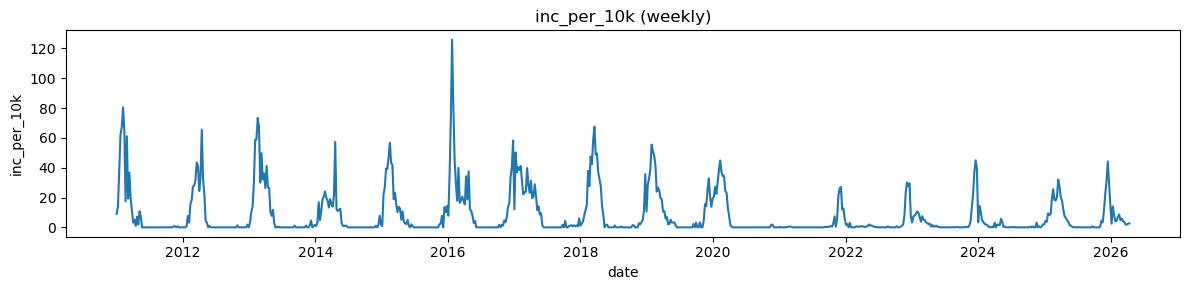

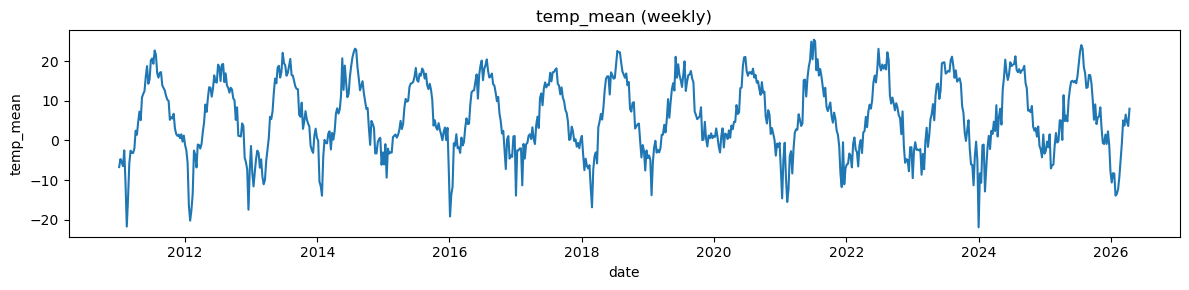

In [9]:
# Базовый график цели и температуры
fig, ax = plt.subplots(figsize=(12,3))
ax.plot(df["datetime"], df["inc_per_10k"])
ax.set_title("inc_per_10k (weekly)")
ax.set_xlabel("date")
ax.set_ylabel("inc_per_10k")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12,3))
ax.plot(df["datetime"], df["temp_mean"])
ax.set_title("temp_mean (weekly)")
ax.set_xlabel("date")
ax.set_ylabel("temp_mean")
fig.tight_layout()
plt.show()


In [10]:
def add_fourier_week_features(frame: pd.DataFrame, week_col="iso_week", period=52, K=2) -> pd.DataFrame:
    out = frame.copy()
    w = out[week_col].astype(float).to_numpy()
    for k in range(1, K+1):
        out[f"sin_w{k}"] = np.sin(2*np.pi*k*w/period)
        out[f"cos_w{k}"] = np.cos(2*np.pi*k*w/period)
    return out

def make_lag_features(frame: pd.DataFrame, col: str, lags: list[int], prefix: str | None = None) -> pd.DataFrame:
    out = frame.copy()
    p = prefix or col
    for L in lags:
        out[f"{p}_lag{L}"] = out[col].shift(L)
    return out

def make_rolling_features(frame: pd.DataFrame, col: str, windows: list[int], prefix: str | None = None) -> pd.DataFrame:
    out = frame.copy()
    p = prefix or col
    for w in windows:
        out[f"{p}_rollmean{w}"] = out[col].rolling(w).mean()
        #out[f"{p}_rollmed{w}"] = out[col].rolling(w).median()
        out[f"{p}_rollstd{w}"] = out[col].rolling(w).std()
    return out

def add_epidemic_dynamics_features(
    frame: pd.DataFrame,
    target_col: str = "inc_per_10k",
    week_col: str = "iso_week",
    growth_lags: list[int] = [1, 2, 3, 4],  # 1-2-4 недели обычно достаточно
    eps: float = 1e-6,
) -> pd.DataFrame:
    out = frame.copy()
    y = out[target_col].astype(float)

    # --- 1) Темп роста / лог-темп роста (устойчиво к нулям) ---
    for L in growth_lags:
        yL = y.shift(L)
        out[f"y_diff{L}"] = y - yL
        #out[f"y_growth{L}"] = (y + eps) / (yL + eps)
        #out[f"y_log_growth{L}"] = np.log1p(y) - np.log1p(yL)

    # --- 2) Ускорение (вторая разность) ---
    # accel_t = (y_t - y_{t-1}) - (y_{t-1} - y_{t-2})
    out["y_accel"] = (y - y.shift(1)) - (y.shift(1) - y.shift(2))

    # --- 3) Отклонение от сезонной нормы (историческая средняя по iso_week) ---
    # Важно: используем только прошлые наблюдения в той же iso_week => shift(1) + expanding()
    # out["y_week_mean_hist"] = (
    #     out.groupby(week_col)[target_col]
    #        .transform(lambda s: s.shift(1).expanding().mean())
    # )

    #out["y_seasonal_dev"] = y - out["y_week_mean_hist"]
    #out["y_seasonal_ratio"] = (y + eps) / (out["y_week_mean_hist"] + eps)
    #out["y_seasonal_log_dev"] = np.log1p(y) - np.log1p(out["y_week_mean_hist"])

    return out

def build_supervised(
    df: pd.DataFrame,
    target_col: str = "inc_per_10k",
    temp_cols: list[str] = ["temp_mean"],  # можно расширить до ["temp_mean","temp_min","temp_max"]
    H: int = 4,
    y_lags: list[int] = [1,2,3,4,5,6,7,8,12,52],
    temp_lags: list[int] = [0,1,2,3,4],
    y_roll_windows: list[int] = [3,8],
    temp_roll_windows: list[int] = [3,8],
    fourier_K: int = 2,
):
    data = df.copy()

    # Сезонность
    data = add_fourier_week_features(data, week_col="iso_week", period=52, K=fourier_K)

    # Тренд (простой индекс времени)
    # data["t_idx"] = np.arange(len(data))

    # Лаги/роллинги цели
    data = make_lag_features(data, target_col, y_lags, prefix="y")
    data = make_rolling_features(data, target_col, y_roll_windows, prefix="y")

    # Эпидемическая динамика (темп роста, моментум, сезонные отклонения)
    data = add_epidemic_dynamics_features(
        data,
        target_col=target_col,
        week_col="iso_week",
        growth_lags=[1, 2, 4],  # при желании можно расширить: [1,2,3,4,5,6,8]
        eps=1e-6,
    )

    # Температура: лаги/роллинги
    for tc in temp_cols:
        data = make_lag_features(data, tc, temp_lags, prefix=tc)
        data = make_rolling_features(data, tc, temp_roll_windows, prefix=tc)

    # Цели для каждого горизонта
    for h in range(1, H+1):
        data[f"y_h{h}"] = data[target_col].shift(-h)

    # Список фичей: берём всё, что создали, кроме таргетов и сырых колонок
    drop_cols = {"datetime", target_col, "total_population", "total_cases_formula", 'rh_min', 'rh_max'}
    drop_cols |= {f"y_h{h}" for h in range(1, H+1)}
    # оставим iso_year/iso_week как численные признаки (можно убрать, если хотите)
    feature_cols = [c for c in data.columns if c not in drop_cols]

    return data, feature_cols


In [11]:
def fit_models_hist_gbdt(
    X_train: np.ndarray,
    y_train_list: list[np.ndarray],
    random_state: int = 42,
):

    models = []
    for h, y_tr in enumerate(y_train_list, start=1):
        m = HistGradientBoostingRegressor(
            loss="poisson",
            max_depth=None,
            max_leaf_nodes=None,
            learning_rate=0.001,
            max_iter=8000,
            min_samples_leaf=95,
            l2_regularization=1.0,
            early_stopping=True,
            validation_fraction=None,
            random_state=random_state + h
        )

        # m = HistGradientBoostingRegressor(
        #         loss="quantile",
        #         quantile=0.5,
        #         max_depth=None,
        #         max_leaf_nodes=None,
        #         learning_rate=0.001,
        #         max_iter=8000,
        #         min_samples_leaf=25,
        #         l2_regularization=1.0,
        #         early_stopping=True,
        #         validation_fraction=None,
        #         random_state=random_state + h,
        # )
        
        m.fit(X_train, y_tr)
        models.append(m)
    return models

def evaluate_multistep(y_true_mat: np.ndarray, y_pred_mat: np.ndarray):
    H = y_true_mat.shape[1]
    rows=[]
    for i in range(H):
        yt = y_true_mat[:, i]
        yp = y_pred_mat[:, i]
        rows.append({
            "horizon_weeks": i+1,
            "r2": r2_score(yt, yp),
            "rmse": float(np.sqrt(mean_squared_error(yt, yp))),
            "mae": float(mean_absolute_error(yt, yp)),
        })
    overall = {
        "r2_overall": r2_score(y_true_mat.reshape(-1), y_pred_mat.reshape(-1)),
        "rmse_overall": float(np.sqrt(mean_squared_error(y_true_mat.reshape(-1), y_pred_mat.reshape(-1)))),
        "mae_overall": float(mean_absolute_error(y_true_mat.reshape(-1), y_pred_mat.reshape(-1))),
    }
    return pd.DataFrame(rows), overall


In [12]:
def fit_models_hist_gbdt_quantiles(
    X_train: np.ndarray,
    y_train_list: list[np.ndarray],
    quantiles=(0.1, 0.9),
    random_state: int = 42,
):
    q_models = {q: [] for q in quantiles}
    for h, y_tr in enumerate(y_train_list, start=1):
        for q in quantiles:
            m = HistGradientBoostingRegressor(
                loss="quantile",
                quantile=q,
                max_depth=None,
                max_leaf_nodes=None,
                learning_rate=0.001,
                max_iter=8000,
                min_samples_leaf=25,
                l2_regularization=1.0,
                early_stopping=True,
                validation_fraction=None,
                random_state=random_state + 100*h + int(q*100),
            )
            m.fit(X_train, y_tr)
            q_models[q].append(m)
    return q_models


In [13]:
DATA_COLOR = "#1f77b4"      # matplotlib default blue
FORECAST_COLOR = "#ff7f0e"  # matplotlib default orange
PI_ALPHA = 0.20

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def _iso_week_labels(dates: pd.DatetimeIndex) -> list[str]:
    weeks = pd.DatetimeIndex(dates).isocalendar().week.to_numpy()
    return [f"{int(w):02d}" for w in weeks]

def plot_forecast_like_example(
    raw_df: pd.DataFrame,
    origin_date: pd.Timestamp,
    future_dates: pd.DatetimeIndex,
    y_hat: np.ndarray,
    y_lo: np.ndarray | None = None,
    y_hi: np.ndarray | None = None,
    y_hist_col: str = "inc_per_10k",
    datetime_col: str = "datetime",
    window_back: int = 24,
    tick_step: int = 2,
):
    """
    raw_df: история (datetime_col + y_hist_col)
    origin_date: последняя наблюдаемая дата, от которой делаем прогноз
    future_dates: даты t+1..t+H
    y_hat: прогноз (H,)
    y_lo/y_hi: границы PI 80% (H,) или None
    """

    raw_df = raw_df.sort_values(datetime_col).reset_index(drop=True)
    origin_date = pd.to_datetime(origin_date)

    # История для отображения
    hist = raw_df[pd.to_datetime(raw_df[datetime_col]) <= origin_date].tail(window_back).copy()
    hist_dt = pd.to_datetime(hist[datetime_col])

    y_hat = np.asarray(y_hat, dtype=float).reshape(-1)
    H = len(y_hat)

    if y_lo is not None and y_hi is not None:
        y_lo = np.asarray(y_lo, dtype=float).reshape(-1)
        y_hi = np.asarray(y_hi, dtype=float).reshape(-1)
        y_lo, y_hi = np.minimum(y_lo, y_hi), np.maximum(y_lo, y_hi)

    # Ось X как последовательный индекс (как на примере)
    all_dates = pd.DatetimeIndex(list(hist_dt) + list(pd.to_datetime(future_dates)))
    x_all = np.arange(len(all_dates))
    x_hist = x_all[:len(hist)]
    x_fut = x_all[len(hist):]

    labels = _iso_week_labels(all_dates)

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

    def draw(ax, lang: str):
        # Данные (синие)
        ax.plot(
            x_hist, hist[y_hist_col].to_numpy(),
            color=DATA_COLOR, marker="o", linewidth=2, markersize=5,
            label=("Данные" if lang == "ru" else "Data")
        )

        # Прогноз (оранжевый пунктир), соединяем с последней синей точкой
        y_last = float(hist[y_hist_col].iloc[-1])
        x_bridge = np.concatenate(([x_hist[-1]], x_fut))
        y_bridge = np.concatenate(([y_last], y_hat))

        ax.plot(
            x_bridge, y_bridge,
            color=FORECAST_COLOR, linestyle="--",
            marker="o",
            # маркеры только на будущих точках (не на последней наблюдаемой)
            markevery=range(1, len(x_bridge)),
            linewidth=2, markersize=5,
            label=("Прогноз" if lang == "ru" else "Forecast")
        )

        # Интервал (только на будущем горизонте)
        if y_lo is not None and y_hi is not None:
            ax.fill_between(
                x_fut, y_lo[:H], y_hi[:H],
                color=FORECAST_COLOR, alpha=PI_ALPHA,
                label=("Предиктивный интервал 80%" if lang == "ru" else "Prediction interval 80%")
            )

        ax.grid(True, alpha=0.25)
        ax.legend(loc="upper right")

        if lang == "ru":
            ax.set_title(f"Прогноз на {H} недели вперёд")
            ax.set_xlabel("Недели")
            ax.set_ylabel("Заболеваемость гриппом\nна 10 тыс населения")
        else:
            ax.set_title(f"{H}-week forecast ahead")
            ax.set_xlabel("Weeks")
            ax.set_ylabel("Influenza morbidity per 10000 population")

    draw(axes[0], "ru")
    draw(axes[1], "en")

    # Тики и подписи недель — на ОБЕИХ панелях (как у вас)
    tick_idx = np.arange(0, len(x_all), tick_step)
    for ax in axes:
        ax.set_xticks(tick_idx)
        ax.set_xticklabels([labels[i] for i in tick_idx])
        ax.tick_params(axis="x", labelbottom=True)  # важно при sharex=True

    fig.tight_layout()
    return fig, axes


In [14]:
# =========================================================
# Настройки
# =========================================================
OUTPUT_PATH = "model_registry.json"
NOTEBOOK_ID = "gbdt_influenza_forecast_4w"


# =========================================================
# Вспомогательные функции (портируемые в .py без изменений)
# =========================================================

def _extract_hgbr_params(model) -> dict:
    params = model.get_params()
    return {
        "learning_rate":    params.get("learning_rate"),
        "max_iter":         params.get("max_iter"),
        "min_samples_leaf": params.get("min_samples_leaf"),
        "l2_regularization": params.get("l2_regularization"),
        "early_stopping":   params.get("early_stopping"),
    }


def _build_point_entry(model, h: int, target_variable: str, time_unit: str) -> dict:
    return {
        "id":                  f"point_forecast_h{h}",
        "family":              "HistGradientBoostingRegressor",
        "forecast_type":       "point",
        "output_type":         "single_value",
        "target_variable":     target_variable,
        "target_time_offset":  h,
        "target_time_unit":    time_unit,
        "predicts":            f"{target_variable} at t+{h}",
        "training_strategy":   "direct",
        "loss":                "poisson",
        "purpose":             "point_forecast",
        "hyperparameters":     _extract_hgbr_params(model),
    }


def _build_quantile_entry(
    model, h: int, q: float, interval_side: str,
    target_variable: str, time_unit: str,
) -> dict:
    if interval_side not in {"lower", "upper"}:
        raise ValueError("interval_side must be 'lower' or 'upper'")
    purpose = f"{interval_side}_prediction_interval"
    q_str = str(q).replace(".", "")
    return {
        "id":                  f"{purpose}_q{q_str}_h{h}",
        "family":              "HistGradientBoostingRegressor",
        "forecast_type":       "quantile",
        "output_type":         "single_value",
        "target_variable":     target_variable,
        "target_time_offset":  h,
        "target_time_unit":    time_unit,
        "predicts":            f"{target_variable} at t+{h}",
        "training_strategy":   "direct",
        "loss":                "quantile",
        "quantile":            q,
        "interval_side":       interval_side,
        "purpose":             purpose,
        "hyperparameters":     _extract_hgbr_params(model),
    }


def build_model_registry(
    point_models: list,
    quantile_models: dict,
    H: int,
    feature_cols: list,
    test_weeks: int,
    notebook_id: str = NOTEBOOK_ID,
    target_variable: str = "inc_per_10k",
    time_unit: str = "week",
) -> dict:
    """
    Строит model_registry без интроспекции globals().

    Args:
        point_models:    список из H point-моделей (HistGradientBoostingRegressor,
                         loss='poisson'), упорядоченных по горизонту h=1..H.
        quantile_models: dict вида {0.1: [m_h1, ..., m_hH], 0.9: [m_h1, ..., m_hH]}.
        H:               горизонт прогноза.
        feature_cols:    список имён признаков, переданных модели.
        test_weeks:      количество недель в тестовой выборке.
        notebook_id:     идентификатор ноутбука / источника.
        target_variable: имя целевой переменной.
        time_unit:       единица времени горизонта.

    Returns:
        dict — готовый registry для сериализации в JSON.
    """
    if len(point_models) != H:
        raise ValueError(
            f"Ожидалось {H} point-моделей, получено {len(point_models)}."
        )

    quantile_keys = sorted(quantile_models.keys())
    if len(quantile_keys) < 2:
        raise ValueError("quantile_models должен содержать минимум два квантиля.")

    lower_q = quantile_keys[0]
    upper_q = quantile_keys[-1]

    model_entries = []

    for h, model in enumerate(point_models, start=1):
        model_entries.append(_build_point_entry(model, h, target_variable, time_unit))

    for h, model in enumerate(quantile_models[lower_q], start=1):
        model_entries.append(
            _build_quantile_entry(model, h, lower_q, "lower", target_variable, time_unit)
        )

    for h, model in enumerate(quantile_models[upper_q], start=1):
        model_entries.append(
            _build_quantile_entry(model, h, upper_q, "upper", target_variable, time_unit)
        )

    return {
        "notebook_id": notebook_id,
        "task": f"forecast weekly {target_variable} for 1-{H} weeks ahead",
        "forecast_design": {
            "strategy":        "direct_multi_step",
            "per_model_output": "single_value",
            "semantic_rule":   (
                "each model predicts exactly one target value "
                "for one specific future offset t+h"
            ),
        },
        "training_scheme": {
            "strategy":   "direct_multi_step",
            "test_split": "time_based_holdout",
            "test_weeks": test_weeks,
        },
        "feature_groups": [
            "target_lags",
            "target_rolling_stats",
            "epidemic_dynamics",
            "fourier_seasonality",
            "temperature_lags",
            "temperature_rolling_stats",
            "calendar_features",
        ],
        "features": feature_cols,
        "models": model_entries,
    }



In [15]:
def run_influenza_forecast_pipeline(
    df: pd.DataFrame,
    H: int = 4,
    test_weeks: int = 52,
    temp_cols: list[str] | None = None,
    use_log1p: bool = False,
    quantiles: tuple[float, ...] = (0.05, 0.95),
    y_lags: list[int] | None = None,
    temp_lags: list[int] | None = None,
    y_roll_windows: list[int] | None = None,
    temp_roll_windows: list[int] | None = None,
    target_col: str = "inc_per_10k",
    save_dir: str = "results_csv",
    registry_path: str = "model_registry.json",
    notebook_id: str = "gbdt_influenza_forecast_4w",
    window_back: int = 24,
    plot: bool = True,
) -> dict:
    """
    Полный пайплайн: feature engineering → eval on holdout → prod fit → forecast → сохранение.

    Args:
        df:                исходный DataFrame (datetime + target_col + погодные признаки).
        H:                 горизонт прогноза в неделях.
        test_weeks:        длина тестовой выборки (time-based holdout).
        temp_cols:         список температурных колонок. По умолчанию ["temp_mean"].
        use_log1p:         применять log1p к target перед обучением.
        quantiles:         квантили для предиктивного интервала. По умолчанию (0.1, 0.9).
        y_lags:            лаги целевой переменной. По умолчанию [0,1,2,3,4,5].
        temp_lags:         лаги температурных признаков. По умолчанию [0,1,2,3,4].
        y_roll_windows:    окна роллинговых статистик цели. По умолчанию [4,5,6,7,8,9].
        temp_roll_windows: окна роллинговых статистик температуры. По умолчанию [4,5,6,7].
        target_col:        имя целевой переменной.
        save_dir:          папка для сохранения CSV.
        registry_path:     путь к JSON-реестру моделей.
        notebook_id:       идентификатор ноутбука для реестра.
        window_back:       количество исторических недель на графике прогноза.
        plot:              строить и показывать график прогноза.

    Returns:
        dict:
            feature_cols    — список имён признаков
            data            — DataFrame после feature engineering
            per_h           — метрики по горизонтам (DataFrame)
            overall         — суммарные метрики (dict)
            models_eval     — eval point-модели (list[H])
            models_prod     — prod point-модели (list[H])
            q_models_prod   — prod quantile-модели (dict {q: list[H]})
            y_hat           — point-прогноз (H,)
            y_lo, y_hi      — границы PI (H,)
            origin_date     — дата последнего наблюдения
            future_dates    — даты прогнозируемых недель
            model_registry  — реестр моделей (dict)
            fig             — matplotlib Figure или None
    """

    # ── Defaults ──────────────────────────────────────────────────────────────
    if temp_cols is None:
        temp_cols = ["temp_mean"]
    if y_lags is None:
        y_lags = [0, 1, 2, 3, 4, 5]
    if temp_lags is None:
        temp_lags = [0, 1, 2, 3, 4]
    if y_roll_windows is None:
        y_roll_windows = [4, 5, 6, 7, 8, 9]
    if temp_roll_windows is None:
        temp_roll_windows = [4, 5, 6, 7]

    # ── Target transform (local — не зависит от глобального use_log1p) ────────
    def y_forward(y: np.ndarray) -> np.ndarray:
        return np.log1p(y) if use_log1p else y

    def y_inverse(z: np.ndarray) -> np.ndarray:
        return np.expm1(z) if use_log1p else z

    # =========================================================================
    # 1) Feature engineering
    # =========================================================================
    data, feature_cols = build_supervised(
        df,
        target_col=target_col,
        temp_cols=temp_cols,
        H=H,
        y_lags=y_lags,
        temp_lags=temp_lags,
        y_roll_windows=y_roll_windows,
        temp_roll_windows=temp_roll_windows,
    )

    # =========================================================================
    # 2) Train / Test split
    # =========================================================================
    valid_mask = np.ones(len(data), dtype=bool)
    for h in range(1, H + 1):
        valid_mask &= data[f"y_h{h}"].notna().to_numpy()
    valid_mask &= data[feature_cols].notna().all(axis=1).to_numpy()

    data_valid = data.loc[valid_mask].copy().reset_index(drop=True)

    test_start_date = data_valid["datetime"].iloc[-test_weeks]
    train_mask = data_valid["datetime"] < test_start_date
    test_mask  = data_valid["datetime"] >= test_start_date

    print(
        f"Train: {data_valid.loc[train_mask, 'datetime'].min().date()} → "
        f"{data_valid.loc[train_mask, 'datetime'].max().date()} "
        f"(n={int(train_mask.sum())})"
    )
    print(
        f"Test:  {data_valid.loc[test_mask, 'datetime'].min().date()} → "
        f"{data_valid.loc[test_mask, 'datetime'].max().date()} "
        f"(n={int(test_mask.sum())})"
    )

    X_all    = data_valid[feature_cols].to_numpy(dtype=float)
    X_train  = X_all[train_mask.to_numpy()]
    X_test   = X_all[test_mask.to_numpy()]

    y_train_list = []
    y_test_mat   = np.zeros((int(test_mask.sum()), H), dtype=float)
    for h in range(1, H + 1):
        y_h = data_valid[f"y_h{h}"].to_numpy(dtype=float)
        y_train_list.append(y_forward(y_h[train_mask.to_numpy()]))
        y_test_mat[:, h - 1] = y_h[test_mask.to_numpy()]

    # =========================================================================
    # 3) Eval fit + evaluate on holdout
    # =========================================================================
    print("\nFitting eval models...")
    models_eval = fit_models_hist_gbdt(X_train, y_train_list)

    z_pred_mat = np.column_stack([m.predict(X_test) for m in models_eval])
    y_pred_mat = np.clip(y_inverse(z_pred_mat), 0.0, None)

    per_h, overall = evaluate_multistep(y_test_mat, y_pred_mat)
    print(per_h.to_string(index=False))
    print("Overall:", overall)

    # =========================================================================
    # 4) Production fit (full valid data)
    # =========================================================================
    prod_mask = np.ones(len(data), dtype=bool)
    for h in range(1, H + 1):
        prod_mask &= data[f"y_h{h}"].notna().to_numpy()
    prod_mask &= data[feature_cols].notna().all(axis=1).to_numpy()

    data_prod   = data.loc[prod_mask].copy()
    X_prod      = data_prod[feature_cols].to_numpy(dtype=float)
    y_prod_list = [
        y_forward(data_prod[f"y_h{h}"].to_numpy(dtype=float))
        for h in range(1, H + 1)
    ]

    print("\nFitting production point models...")
    models_prod = fit_models_hist_gbdt(X_prod, y_prod_list)

    print("Fitting production quantile models...")
    q_models_prod = fit_models_hist_gbdt_quantiles(X_prod, y_prod_list, quantiles=quantiles)

    # =========================================================================
    # 5) Production forecast from latest origin
    # =========================================================================
    prod_feat_mask = data[feature_cols].notna().all(axis=1).to_numpy()
    origin_idx     = np.where(prod_feat_mask)[0][-1]
    origin_date    = pd.to_datetime(data.loc[origin_idx, "datetime"])
    x0             = data.loc[origin_idx, feature_cols].to_numpy(dtype=float).reshape(1, -1)

    z_hat = np.array([m.predict(x0)[0] for m in models_prod])
    y_hat = np.clip(y_inverse(z_hat), 0.0, None)

    q_keys  = sorted(q_models_prod.keys())
    lower_q, upper_q = q_keys[0], q_keys[-1]

    z_lo = np.array([q_models_prod[lower_q][h].predict(x0)[0] for h in range(H)])
    z_hi = np.array([q_models_prod[upper_q][h].predict(x0)[0] for h in range(H)])
    y_lo = np.clip(y_inverse(z_lo), 0.0, None)
    y_hi = np.clip(y_inverse(z_hi), 0.0, None)
    y_lo, y_hi = np.minimum(y_lo, y_hi), np.maximum(y_lo, y_hi)

    step = data["datetime"].diff().dropna().median()
    if pd.isna(step):
        step = pd.Timedelta(days=7)
    future_dates = pd.date_range(origin_date + step, periods=H, freq=step)

    print(f"\nProduction forecast (origin: {origin_date.date()}):")
    for h, (d, yh, lo, hi) in enumerate(zip(future_dates, y_hat, y_lo, y_hi), 1):
        print(f"  t+{h} ({d.date()}): {yh:.3f}  PI{int((upper_q - lower_q) * 100)}=[{lo:.3f}, {hi:.3f}]")

    # =========================================================================
    # 6) Plot
    # =========================================================================
    fig = None
    if plot:
        fig, _ = plot_forecast_like_example(
            raw_df=df,
            origin_date=origin_date,
            future_dates=future_dates,
            y_hist_col=target_col,
            y_hat=y_hat,
            y_lo=y_lo,
            y_hi=y_hi,
            window_back=window_back,
        )
        plt.show()

    # =========================================================================
    # 7) Model registry
    # =========================================================================
    model_registry = build_model_registry(
        point_models=models_prod,
        quantile_models=q_models_prod,
        H=H,
        feature_cols=feature_cols,
        test_weeks=test_weeks,
        notebook_id=notebook_id,
        target_variable=target_col,
    )
    Path(registry_path).write_text(
        json.dumps(model_registry, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    print(f"\nModel registry saved → {registry_path}")

    # =========================================================================
    # 8) Save CSVs
    # =========================================================================
    save_path = Path(save_dir)
    save_path.mkdir(parents=True, exist_ok=True)

    # 8a) Metrics summary
    metrics_df = per_h.copy()
    metrics_df["section"]          = "per_h"
    metrics_df["train_start"]      = data_valid.loc[train_mask, "datetime"].min().date()
    metrics_df["train_end"]        = data_valid.loc[train_mask, "datetime"].max().date()
    metrics_df["test_start"]       = data_valid.loc[test_mask,  "datetime"].min().date()
    metrics_df["test_end"]         = data_valid.loc[test_mask,  "datetime"].max().date()
    metrics_df["n_train"]          = int(train_mask.sum())
    metrics_df["n_test"]           = int(test_mask.sum())
    metrics_df["n_features"]       = len(feature_cols)
    metrics_df["target_transform"] = "log1p" if use_log1p else "none"

    overall_df = pd.DataFrame([{
        "section":          "overall",
        "horizon_weeks":    "all",
        "r2":               overall["r2_overall"],
        "rmse":             overall["rmse_overall"],
        "mae":              overall["mae_overall"],
        "train_start":      data_valid.loc[train_mask, "datetime"].min().date(),
        "train_end":        data_valid.loc[train_mask, "datetime"].max().date(),
        "test_start":       data_valid.loc[test_mask,  "datetime"].min().date(),
        "test_end":         data_valid.loc[test_mask,  "datetime"].max().date(),
        "n_train":          int(train_mask.sum()),
        "n_test":           int(test_mask.sum()),
        "n_features":       len(feature_cols),
        "target_transform": "log1p" if use_log1p else "none",
    }])

    all_cols = sorted(set(metrics_df.columns) | set(overall_df.columns))
    pd.concat(
        [metrics_df.reindex(columns=all_cols), overall_df.reindex(columns=all_cols)],
        ignore_index=True,
    ).to_csv(save_path / "metrics_summary.csv", index=False, encoding="utf-8-sig")

    # 8b) Test predictions
    test_dates = data_valid.loc[test_mask, "datetime"].reset_index(drop=True)
    test_preds = pd.DataFrame({"origin_date": test_dates})
    for h in range(1, H + 1):
        test_preds[f"target_date_h{h}"] = test_dates + pd.to_timedelta(7 * h, unit="D")
        test_preds[f"y_true_h{h}"]      = y_test_mat[:, h - 1]
        test_preds[f"y_pred_h{h}"]      = y_pred_mat[:, h - 1]
        test_preds[f"abs_error_h{h}"]   = np.abs(y_test_mat[:, h - 1] - y_pred_mat[:, h - 1])
    test_preds.to_csv(save_path / "test_predictions.csv", index=False, encoding="utf-8-sig")

    # 8c) Forecast next H weeks
    forecast_df = pd.DataFrame({
        "origin_date":    [origin_date.date()] * H,
        "target_date":    pd.to_datetime(future_dates).date,
        "horizon_weeks":  np.arange(1, H + 1),
        "point_forecast": y_hat,
        "q_lo":           y_lo,
        "q_hi":           y_hi,
    })
    forecast_df["pi_width"]    = forecast_df["q_hi"] - forecast_df["q_lo"]
    forecast_df["interval_ok"] = forecast_df["q_hi"] >= forecast_df["q_lo"]
    forecast_df.to_csv(save_path / f"forecast_next_{H}w.csv", index=False, encoding="utf-8-sig")

    # 8d) Feature list
    pd.DataFrame({
        "feature_name":  feature_cols,
        "feature_index": np.arange(len(feature_cols)),
    }).to_csv(save_path / "feature_list.csv", index=False, encoding="utf-8-sig")

    # 8e) History (40 points) + forecast
    hist_tail = (
        df[["datetime", target_col]]
        .sort_values("datetime")
        .tail(40)
        .reset_index(drop=True)
    )
    hist_out = pd.DataFrame({
        "date":          pd.to_datetime(hist_tail["datetime"]),
        "value":         hist_tail[target_col].astype(float),
        "row_type":      "history",
        "origin_date":   pd.NaT,
        "horizon_weeks": pd.NA,
        "q_lo":          np.nan,
        "q_hi":          np.nan,
    })
    forecast_out = pd.DataFrame({
        "date":          pd.to_datetime(future_dates),
        "value":         y_hat,
        "row_type":      "forecast",
        "origin_date":   [origin_date] * H,
        "horizon_weeks": np.arange(1, H + 1),
        "q_lo":          y_lo,
        "q_hi":          y_hi,
    })
    (
        pd.concat([hist_out, forecast_out], ignore_index=True)
        .sort_values("date")
        .reset_index(drop=True)
        .to_csv(save_path / "history_plus_forecast_40.csv", index=False, encoding="utf-8-sig")
    )

    print(f"Results saved → {save_path.resolve()}/")

    return {
        "feature_cols":   feature_cols,
        "data":           data,
        "per_h":          per_h,
        "overall":        overall,
        "models_eval":    models_eval,
        "models_prod":    models_prod,
        "q_models_prod":  q_models_prod,
        "y_hat":          y_hat,
        "y_lo":           y_lo,
        "y_hi":           y_hi,
        "origin_date":    origin_date,
        "future_dates":   future_dates,
        "model_registry": model_registry,
        "fig":            fig,
        # ── для SHAP-анализа ──────────────────────────────
        "X_test":         X_test,
        "y_test_mat":     y_test_mat,
        "y_pred_mat":     y_pred_mat,
        "y_inverse":      y_inverse,
        "dates_test":     data_valid.loc[test_mask, "datetime"].reset_index(drop=True),
    }


In [16]:
from sklearn.base import BaseEstimator, RegressorMixin


class InverseTargetWrapper(RegressorMixin, BaseEstimator):
    """Оборачивает модель так, чтобы predict возвращал значения в исходной шкале y.
    Нужно для корректного SHAP-анализа при use_log1p=True."""

    def __init__(self, base_estimator, inverse_func):
        self.base_estimator = base_estimator
        self.inverse_func   = inverse_func
        for attr in ("n_features_in_", "feature_names_in_"):
            if hasattr(base_estimator, attr):
                setattr(self, attr, getattr(base_estimator, attr))

    def predict(self, X):
        return np.clip(self.inverse_func(self.base_estimator.predict(X)), 0.0, None)

    def __getattr__(self, name):
        return getattr(self.base_estimator, name)

    def __sklearn_is_fitted__(self):
        return True


def run_shap_analysis(
    results: dict,
    shap_horizons=None,
    shap_background: int = 100,
    shap_worst_n: int = 5,
    max_test_samples: int | None = None,
    random_state: int = 42,
    save_dir: str = "results_csv",
) -> dict:
    """
    SHAP-анализ eval-моделей на тестовой выборке.

    Использует TreeExplainer (быстрый, точный, работает напрямую со структурой
    деревьев HistGradientBoostingRegressor). При use_log1p=True SHAP-значения
    будут в log-шкале, что не влияет на ранжирование признаков по важности.

    Args:
        results:          словарь, возвращённый run_influenza_forecast_pipeline().
        shap_horizons:    горизонты для объяснения (None => все).
        shap_background:  размер фонового набора (используется только при
                          фолбэке на PermutationExplainer).
        shap_worst_n:     число "худших" недель для таблицы ошибок.
        max_test_samples: если задано — объяснять не весь тест, а случайную
                          подвыборку такого размера (ускоряет при большом тесте).
        random_state:     seed для воспроизводимости.
        save_dir:         папка для сохранения CSV.

    Returns:
        dict:
            shap_global  — глобальная важность признаков (DataFrame, long)
            shap_local   — локальные SHAP-значения (DataFrame, long)
            shap_worst   — таблица худших предсказаний (DataFrame)
    """
    try:
        import shap
    except ImportError:
        raise ImportError("Установите shap: !pip install shap")


    # ── Распаковываем всё необходимое из results ──────────────────────────────
    models_eval  = results["models_eval"]
    X_test       = results["X_test"]
    y_test_mat   = results["y_test_mat"]
    y_pred_mat   = results["y_pred_mat"]
    feature_cols = results["feature_cols"]
    y_inverse    = results["y_inverse"]
    dates_test   = results["dates_test"]

    H_           = y_test_mat.shape[1]
    X_test_df    = pd.DataFrame(X_test, columns=feature_cols)
    dates_reset  = pd.to_datetime(dates_test).reset_index(drop=True)

    # Опциональный сабсэмплинг теста для ускорения
    if max_test_samples is not None and max_test_samples < len(X_test_df):
        sample_idx   = (
            pd.RangeIndex(len(X_test_df))
            .to_series()
            .sample(max_test_samples, random_state=random_state)
            .sort_index()
            .index
        )
        X_explain    = X_test_df.iloc[sample_idx].reset_index(drop=True)
        y_test_expl  = y_test_mat[sample_idx]
        y_pred_expl  = y_pred_mat[sample_idx]
        dates_expl   = dates_reset.iloc[sample_idx].reset_index(drop=True)
        print(f"SHAP: объясняем {max_test_samples} из {len(X_test_df)} тестовых точек")
    else:
        X_explain   = X_test_df
        y_test_expl = y_test_mat
        y_pred_expl = y_pred_mat
        dates_expl  = dates_reset

    horizons = tuple(range(1, H_ + 1)) if shap_horizons is None else tuple(shap_horizons)

    save_path = Path(save_dir)
    save_path.mkdir(parents=True, exist_ok=True)

    shap_global_tables = []
    shap_local_tables  = []
    shap_worst_tables  = []

    for h in horizons:
        print(f"\n----- SHAP: horizon h={h} -----")

        model = models_eval[h - 1]

        # TreeExplainer: быстрый точный метод, работает напрямую со структурой
        # деревьев HGBR. Не требует фонового набора и не делает сэмплирование.
        # Фолбэк на PermutationExplainer если TreeExplainer недоступен.
        try:
            explainer = shap.TreeExplainer(model, feature_names=feature_cols)
            sv        = explainer(X_explain)
            print(f"  [TreeExplainer]")
        except Exception as e:
            print(f"  [TreeExplainer недоступен: {e}, используем PermutationExplainer]")
            bg        = X_explain.sample(min(shap_background, len(X_explain)), random_state=random_state)
            wrapped   = InverseTargetWrapper(model, y_inverse)
            explainer = shap.Explainer(
                wrapped.predict, bg,
                algorithm="permutation",
                feature_names=feature_cols,
            )
            sv = explainer(X_explain)

        # sv.values → 2D (n_rows, n_features)
        sv_values = np.asarray(sv.values)
        if sv_values.ndim == 3:
            sv_values = sv_values[:, :, 0]
        n_rows, n_features = sv_values.shape
        if n_features != len(feature_cols):
            raise ValueError(
                f"SHAP: ожидалось {len(feature_cols)} признаков, получено {n_features}"
            )

        # base_values → (n_rows,)
        bv = np.asarray(sv.base_values).reshape(-1)
        if len(bv) == 1:
            bv = np.full(n_rows, float(bv[0]))
        elif len(bv) != n_rows:
            bv = np.full(n_rows, float(bv[0]))

        # Худшие недели (считаем по полному тесту, не по subsample)
        abs_err_full = np.abs(y_test_mat[:, h - 1] - y_pred_mat[:, h - 1])
        worst_idx    = np.argsort(-abs_err_full)[:min(shap_worst_n, len(abs_err_full))]
        worst_tbl = pd.DataFrame({
            "row_id":  worst_idx,
            "date":    dates_reset.iloc[worst_idx].to_numpy(),
            "y_true":  y_test_mat[worst_idx, h - 1],
            "y_pred":  y_pred_mat[worst_idx, h - 1],
            "abs_err": abs_err_full[worst_idx],
        }).sort_values("abs_err", ascending=False).reset_index(drop=True)
        display(worst_tbl)

        # Глобальная важность
        shap_global = pd.DataFrame({
            "horizon_weeks":      h,
            "feature":            feature_cols,
            "mean_abs_shap":      np.mean(np.abs(sv_values), axis=0),
            "mean_shap":          np.mean(sv_values, axis=0),
            "mean_feature_value": X_explain.mean(axis=0).to_numpy(),
        }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
        shap_global["rank"] = np.arange(1, len(shap_global) + 1)
        shap_global_tables.append(shap_global)

        # Худшие недели для сохранения
        worst_save = worst_tbl.copy()
        worst_save.insert(0, "horizon_weeks", h)
        shap_worst_tables.append(worst_save)

        # Локальные значения (long format)
        abs_err_expl = np.abs(y_test_expl[:, h - 1] - y_pred_expl[:, h - 1])
        shap_long = (
            pd.DataFrame(sv_values, columns=feature_cols)
            .assign(row_id=np.arange(n_rows))
            .melt(id_vars="row_id", var_name="feature", value_name="shap_value")
        )
        feat_long = (
            X_explain.reset_index(drop=True)
            .assign(row_id=np.arange(n_rows))
            .melt(id_vars="row_id", var_name="feature", value_name="feature_value")
        )
        row_meta = pd.DataFrame({
            "row_id":             np.arange(n_rows),
            "horizon_weeks":      h,
            "date":               dates_expl.iloc[:n_rows].to_numpy(),
            "y_true":             y_test_expl[:n_rows, h - 1],
            "y_pred":             y_pred_expl[:n_rows, h - 1],
            "abs_err":            abs_err_expl[:n_rows],
            "base_value":         bv,
            "base_plus_shap_sum": bv + sv_values.sum(axis=1),
        })
        shap_local = (
            shap_long
            .merge(feat_long, on=["row_id", "feature"], how="left")
            .merge(row_meta,  on="row_id",               how="left")
        )
        shap_local["abs_shap"] = shap_local["shap_value"].abs()
        shap_local_tables.append(shap_local)

        # Графики
        shap.plots.beeswarm(sv, max_display=20)
        shap.plots.bar(sv, max_display=20)

    # Сохранение CSV
    shap_global_all = pd.concat(shap_global_tables, ignore_index=True)
    shap_local_all  = pd.concat(shap_local_tables,  ignore_index=True)
    shap_worst_all  = pd.concat(shap_worst_tables,  ignore_index=True)

    shap_global_all.to_csv(save_path / "shap_global_importance.csv", index=False, encoding="utf-8-sig")
    shap_local_all.to_csv( save_path / "shap_local_values.csv",      index=False, encoding="utf-8-sig")
    shap_worst_all.to_csv( save_path / "shap_worst_cases.csv",        index=False, encoding="utf-8-sig")

    print("\nSHAP CSV сохранены:")
    print("  -", save_path / "shap_global_importance.csv")
    print("  -", save_path / "shap_local_values.csv")
    print("  -", save_path / "shap_worst_cases.csv")

    return {
        "shap_global": shap_global_all,
        "shap_local":  shap_local_all,
        "shap_worst":  shap_worst_all,
    }


Train: 2011-02-28 → 2025-03-17 (n=734)
Test:  2025-03-24 → 2026-03-16 (n=52)

Fitting eval models...
 horizon_weeks       r2     rmse      mae
             1 0.691755 5.089927 2.787576
             2 0.691974 4.973402 2.690113
             3 0.808437 3.852645 2.373844
             4 0.591118 5.597601 2.696488
Overall: {'r2_overall': 0.6963637864474941, 'rmse_overall': 4.919809164521357, 'mae_overall': 2.637005276171031}

Fitting production point models...
Fitting production quantile models...

Production forecast (origin: 2026-04-13):
  t+1 (2026-04-20): 1.369  PI89=[0.000, 3.476]
  t+2 (2026-04-27): 1.322  PI89=[0.000, 1.920]
  t+3 (2026-05-04): 1.214  PI89=[0.000, 3.761]
  t+4 (2026-05-11): 1.778  PI89=[0.000, 3.318]


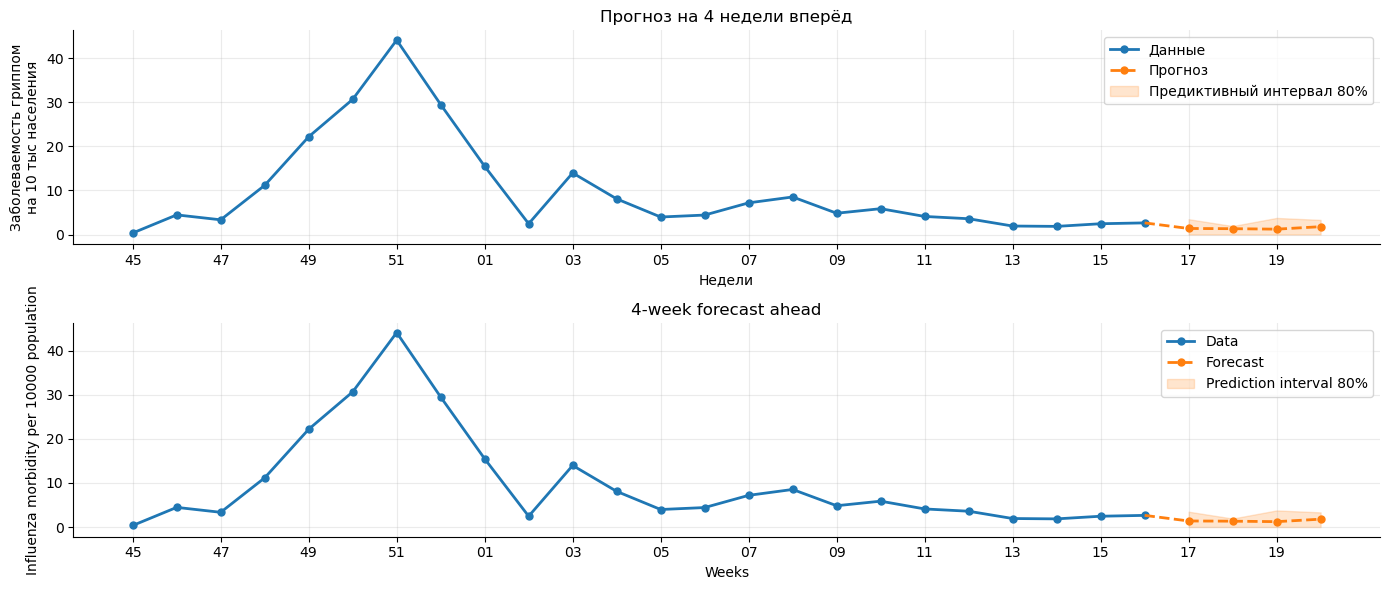


Model registry saved → model_registry.json
Results saved → C:\Users\user\results_csv/


In [17]:
results = run_influenza_forecast_pipeline(df)

# Все артефакты доступны в словаре results:
# results["per_h"]          — метрики по горизонтам (DataFrame)
# results["overall"]        — суммарные метрики (dict)
# results["models_prod"]    — point-модели для продакшна (list[H])
# results["q_models_prod"]  — quantile-модели (dict {q: list[H]})
# results["y_hat"]          — point-прогноз (H,)
# results["y_lo"]           — нижняя граница PI (H,)
# results["y_hi"]           — верхняя граница PI (H,)
# results["origin_date"]    — дата последнего наблюдения
# results["future_dates"]   — даты прогнозируемых недель
# results["model_registry"] — реестр моделей (dict)
# results["fig"]            — matplotlib Figure



----- SHAP: horizon h=1 -----
  [TreeExplainer]


,row_id,date,y_true,y_pred,abs_err
0,37,2025-12-08,44.142633,23.611925,20.530708
1,40,2025-12-29,2.445620,18.954352,16.508732
2,42,2026-01-12,8.088946,18.852554,10.763608
3,41,2026-01-05,13.975225,4.210308,9.764918
4,38,2025-12-15,29.511789,20.186698,9.325091


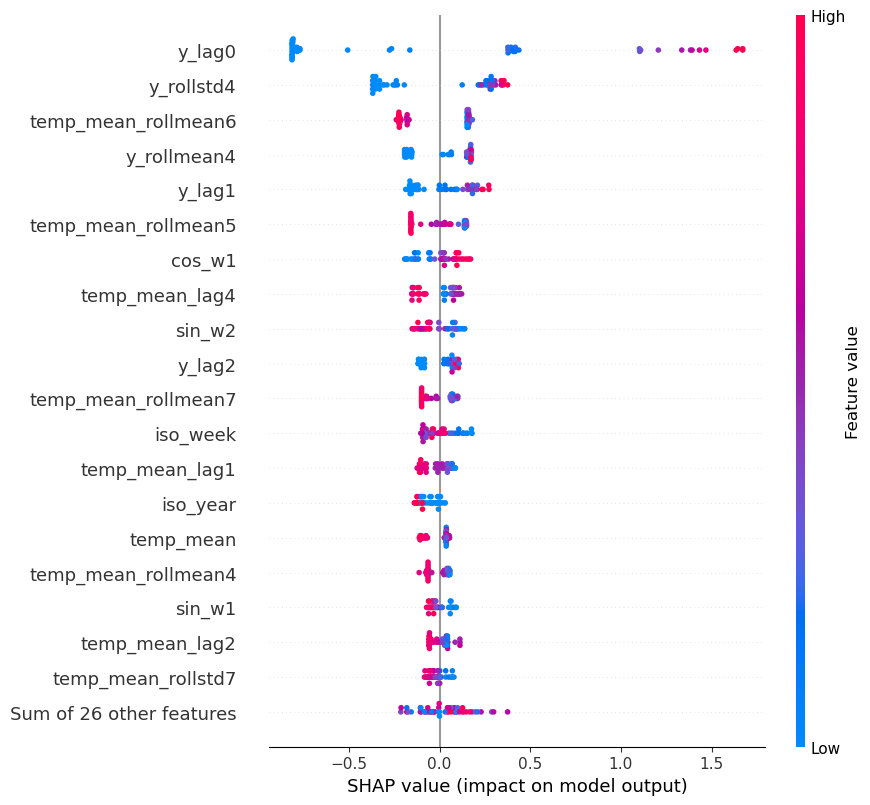

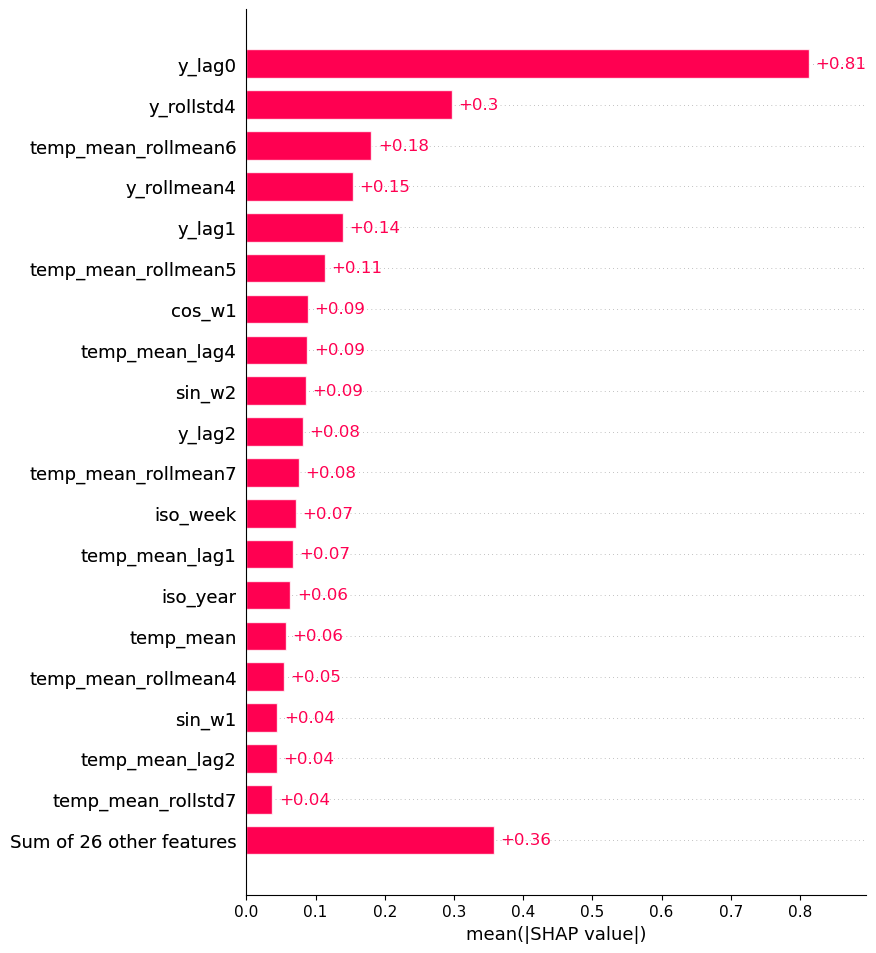


----- SHAP: horizon h=2 -----
  [TreeExplainer]


,row_id,date,y_true,y_pred,abs_err
0,36,2025-12-01,44.142633,25.395752,18.746882
1,39,2025-12-22,2.445620,17.933566,15.487946
2,42,2026-01-12,3.971229,16.934584,12.963355
3,34,2025-11-17,22.192794,12.718718,9.474076
4,37,2025-12-08,29.511789,20.786281,8.725508


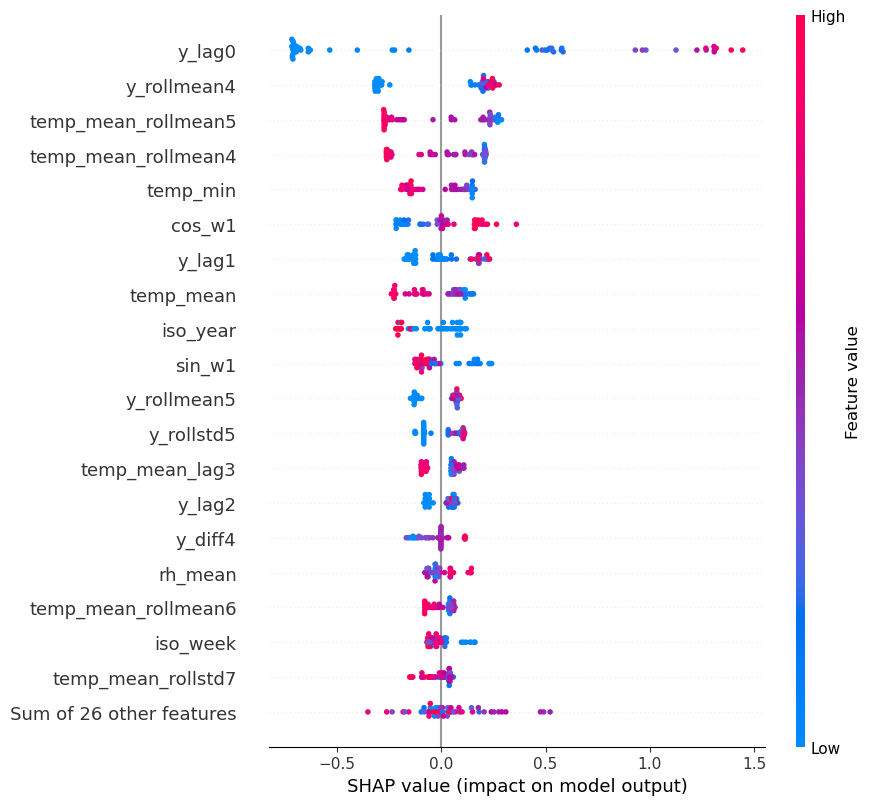

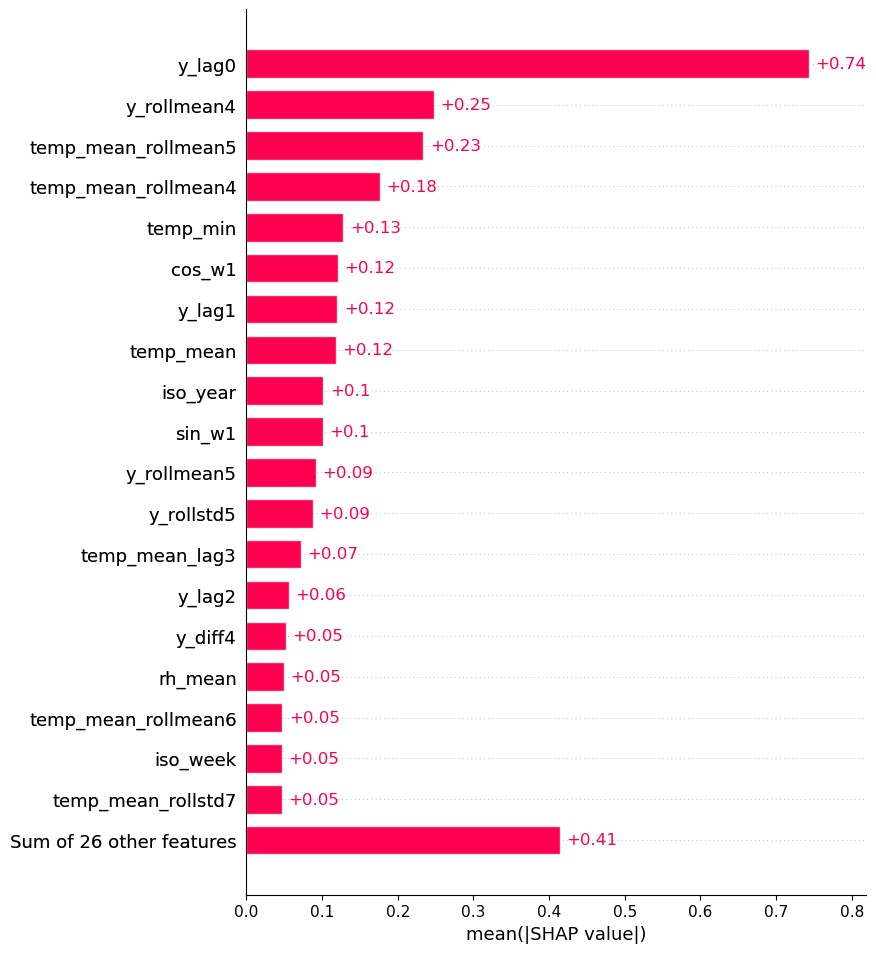


----- SHAP: horizon h=3 -----
  [TreeExplainer]


,row_id,date,y_true,y_pred,abs_err
0,38,2025-12-15,2.445620,13.127798,10.682178
1,35,2025-11-24,44.142633,33.674322,10.468311
2,1,2025-03-31,7.404744,16.899968,9.495225
3,32,2025-11-03,11.163388,1.738949,9.424439
4,40,2025-12-29,8.088946,15.526748,7.437802


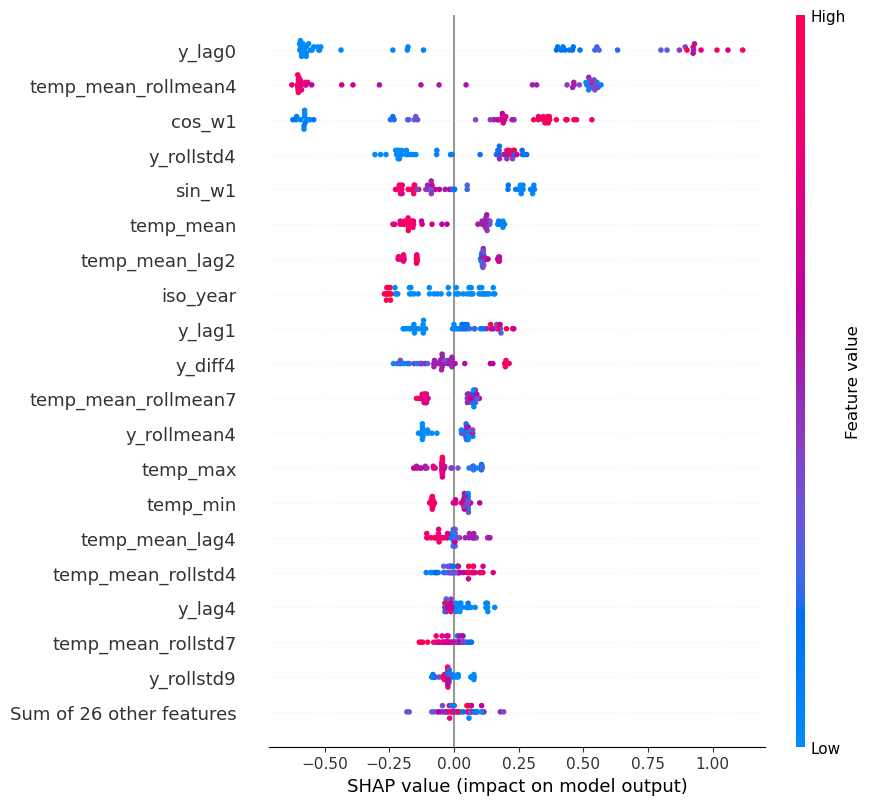

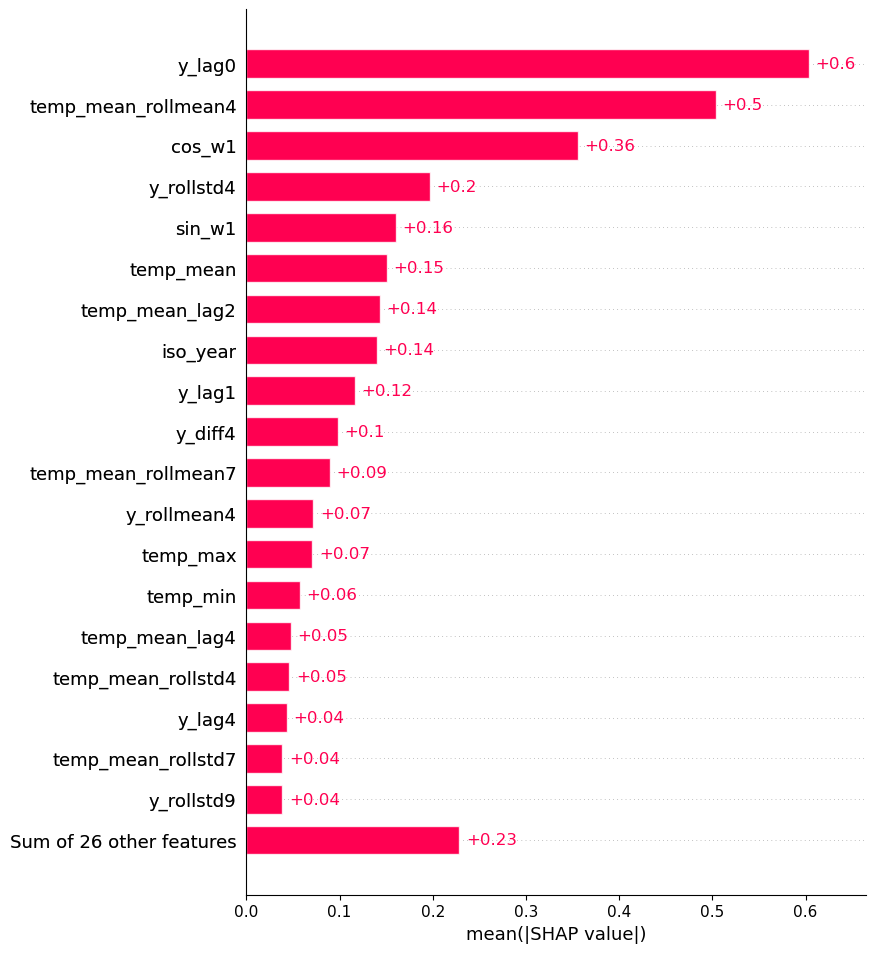


----- SHAP: horizon h=4 -----
  [TreeExplainer]


,row_id,date,y_true,y_pred,abs_err
0,34,2025-11-17,44.142633,17.169116,26.973518
1,32,2025-11-03,22.192794,4.525148,17.667646
2,37,2025-12-08,2.445620,14.030538,11.584918
3,39,2025-12-22,8.088946,17.445158,9.356212
4,40,2025-12-29,3.971229,13.100585,9.129355


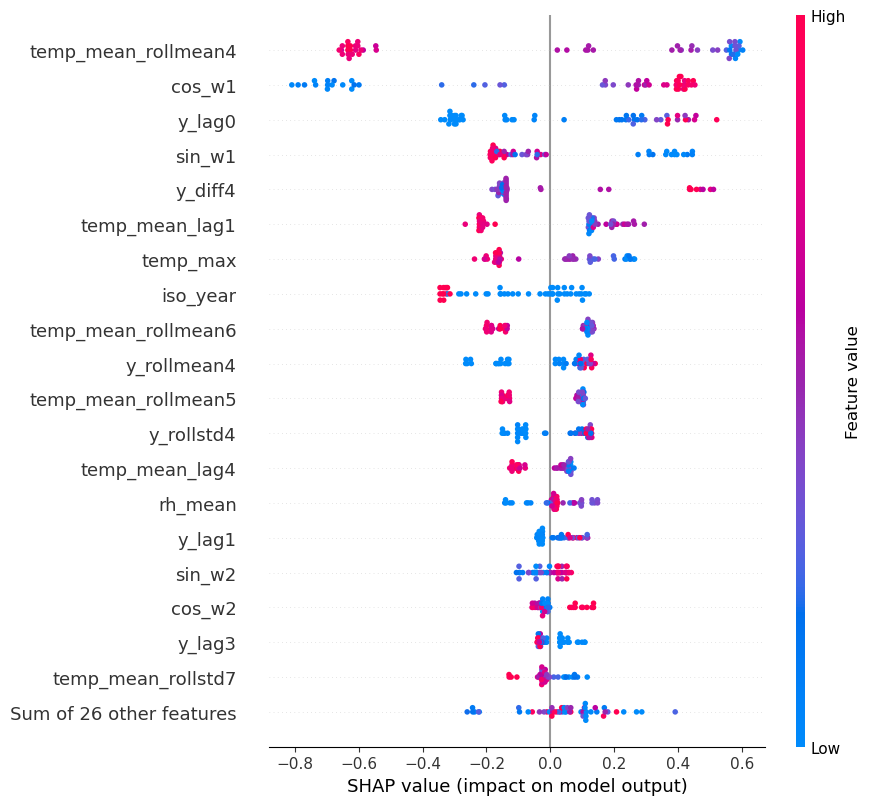

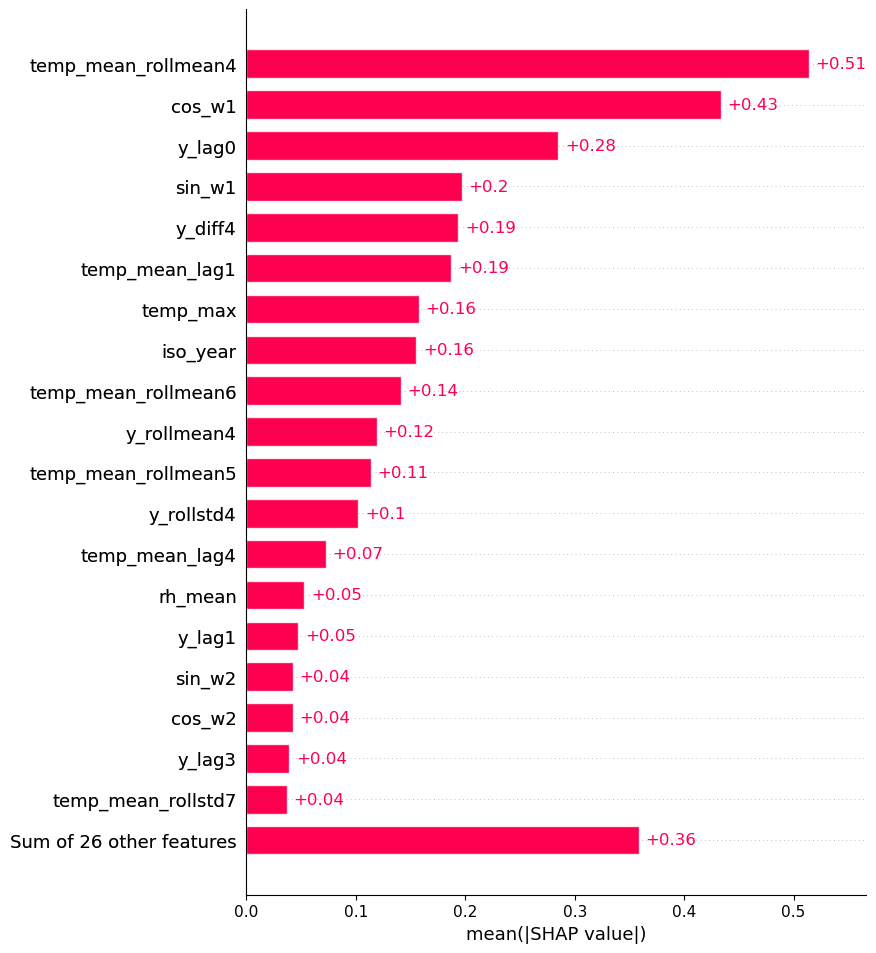


SHAP CSV сохранены:
  - results_csv\shap_global_importance.csv
  - results_csv\shap_local_values.csv
  - results_csv\shap_worst_cases.csv


In [18]:
shap_results = run_shap_analysis(results)

# Доступные артефакты:
# shap_results["shap_global"]  — глобальная важность признаков по горизонтам
# shap_results["shap_local"]   — SHAP-значения для каждой точки теста
# shap_results["shap_worst"]   — таблица худших предсказаний


## Опционально: архивирование артефактов моделирования

Эта ячейка нужна только если требуется отдельный `results.zip` для переноса артефактов вне ноутбука.


In [19]:
# Создаём zip-архив с результатами для передачи в Часть 3
# (google.colab убран — теперь просто сохраняем zip рядом с ноутбуком)
from zipfile import ZipFile, ZIP_DEFLATED
import shutil

SAVE_DIR = Path("results_csv")
ZIP_PATH = Path("results.zip")

csv_files = sorted(SAVE_DIR.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"В папке {SAVE_DIR} не найдено CSV-файлов")

# Структура zip: results/*.csv + results/model_registry.json
# (совместимо с форматом, который ожидает Часть 3)
with ZipFile(ZIP_PATH, "w", compression=ZIP_DEFLATED) as zf:
    for file_path in csv_files:
        zf.write(file_path, arcname=f"results/{file_path.name}")
    reg_path = Path("model_registry.json")
    if reg_path.exists():
        zf.write(reg_path, arcname="results/model_registry.json")

print(f"Архив создан: {ZIP_PATH.resolve()}")
print("Файлы в архиве:")
for f in csv_files:
    print(" -", f.name)


Архив создан: C:\Users\user\results.zip
Файлы в архиве:
 - feature_list.csv
 - forecast_next_4w.csv
 - history_plus_forecast_40.csv
 - metrics_summary.csv
 - shap_global_importance.csv
 - shap_local_values.csv
 - shap_worst_cases.csv
 - test_predictions.csv


---
## 🔗 Переход: Модель → Бюллетень

Загружаем CSV-файлы и `model_registry.json` напрямую из `results_csv/`
без промежуточного zip (данные уже в памяти после Части 2).


In [20]:
# Загружаем все таблицы напрямую из results_csv/
# (EXTRACT_DIR и OUT_DIR совместимы с кодом Части 3)
EXTRACT_DIR = Path("results_csv")
OUT_DIR = str(EXTRACT_DIR)

feature_list                = pd.read_csv(EXTRACT_DIR / "feature_list.csv")
forecast_next_4w            = pd.read_csv(EXTRACT_DIR / "forecast_next_4w.csv")
history_plus_forecast_40    = pd.read_csv(EXTRACT_DIR / "history_plus_forecast_40.csv")
metrics_summary             = pd.read_csv(EXTRACT_DIR / "metrics_summary.csv")
shap_global_importance      = pd.read_csv(EXTRACT_DIR / "shap_global_importance.csv")
shap_local_values           = pd.read_csv(EXTRACT_DIR / "shap_local_values.csv")
shap_worst_cases            = pd.read_csv(EXTRACT_DIR / "shap_worst_cases.csv")
test_predictions            = pd.read_csv(EXTRACT_DIR / "test_predictions.csv")

with open("model_registry.json", "r", encoding="utf-8") as _f:
    model_registry = json.load(_f)
print("model_registry.json загружен.")

# Приведение типов дат
forecast_next_4w["origin_date"] = pd.to_datetime(forecast_next_4w["origin_date"])
forecast_next_4w["target_date"] = pd.to_datetime(forecast_next_4w["target_date"])
history_plus_forecast_40["date"] = pd.to_datetime(history_plus_forecast_40["date"])
for _c in ["train_start", "train_end", "test_start", "test_end"]:
    metrics_summary[_c] = pd.to_datetime(metrics_summary[_c])

print("Данные загружены.")
print(f"  history_plus_forecast_40 : {history_plus_forecast_40.shape}")
print(f"  forecast_next_4w         : {forecast_next_4w.shape}")
print(f"  shap_global_importance   : {shap_global_importance.shape}")
print(f"  shap_worst_cases         : {shap_worst_cases.shape}")
print(f"  test_predictions         : {test_predictions.shape}")


model_registry.json загружен.
Данные загружены.
  history_plus_forecast_40 : (44, 7)
  forecast_next_4w         : (4, 8)
  shap_global_importance   : (180, 6)
  shap_worst_cases         : (20, 6)
  test_predictions         : (52, 17)


# Часть 3: Генерация аналитического бюллетеня

На этом этапе используются артефакты из части моделирования:

- прогноз на 4 недели,
- исторический ряд,
- метрики качества,
- SHAP-глобальная и локальная интерпретация,
- registry с описанием модели.

Далее ноутбук выполняет четыре шага:

1. загружает артефакты из `results_csv/`;
2. строит расширенный контекст `context`;
3. определяет LLM-слой, evaluation-layer и orchestration;
4. запускает генерацию, оценивание, рендеринг PDF и инспекцию trace.


## Подготовка расширенного контекста

Контекст строится **детерминированно** из артефактов моделирования и затем используется narrator/evaluator-слоем.

В него входят:

- метаданные недели бюллетеня;
- текущая ситуация и краткая динамика;
- недельный прогноз и неопределённость;
- SHAP-сводка по горизонтам;
- качество модели и worst-case режим;
- model card для текстового описания модели.


In [21]:

# =========================================================
# HELPERS: СРАВНЕНИЕ ТРЁХ ПОСЛЕДНИХ ЭПИДЕМИЧЕСКИХ ВОЛН
# =========================================================
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

SEASON_START_WEEK = 40
WAVE_SMOOTH_WINDOW = 3


def _season_week_order(season_start_week: int = SEASON_START_WEEK) -> List[int]:
    return list(range(season_start_week, 54)) + list(range(1, season_start_week))


def _season_start_and_label(ts, season_start_week: int = SEASON_START_WEEK) -> Tuple[int, str]:
    ts = pd.Timestamp(ts)
    iso = ts.isocalendar()
    iso_year = int(iso.year)
    iso_week = int(iso.week)
    start_year = iso_year if iso_week >= season_start_week else iso_year - 1
    return start_year, f"{start_year}-{start_year + 1}"


def _interp_x_at_y(x0: float, y0: float, x1: float, y1: float, target_y: float) -> float:
    if abs(y1 - y0) < 1e-12:
        return float(x0)
    return float(x0 + (target_y - y0) * (x1 - x0) / (y1 - y0))


def _nearest_half_height_crossing(
    xs: np.ndarray,
    ys: np.ndarray,
    peak_idx: int,
    half_height: float,
    side: str,
) -> Optional[float]:
    if side not in {"left", "right"}:
        raise ValueError("side должен быть 'left' или 'right'.")

    if side == "left":
        pairs = [(j, j + 1) for j in range(peak_idx - 1, -1, -1)]
    else:
        pairs = [(j, j + 1) for j in range(peak_idx, len(xs) - 1)]

    for i0, i1 in pairs:
        y0 = float(ys[i0])
        y1 = float(ys[i1])
        if (y0 - half_height) == 0:
            return float(xs[i0])
        if (y1 - half_height) == 0:
            return float(xs[i1])
        if (y0 - half_height) * (y1 - half_height) < 0:
            return _interp_x_at_y(float(xs[i0]), y0, float(xs[i1]), y1, half_height)
    return None


def _secondary_peak_ratio(ys: np.ndarray, peak_idx: int) -> Optional[float]:
    if len(ys) < 3:
        return None
    local_peaks = []
    for i in range(1, len(ys) - 1):
        if i == peak_idx:
            continue
        if ys[i] >= ys[i - 1] and ys[i] >= ys[i + 1]:
            local_peaks.append(float(ys[i]))
    if local_peaks:
        second_val = max(local_peaks)
    else:
        candidates = [float(v) for i, v in enumerate(ys) if i != peak_idx]
        if not candidates:
            return None
        second_val = max(candidates)
    peak_val = float(ys[peak_idx])
    if peak_val <= 0:
        return None
    return round(second_val / peak_val, 3)


def build_epidemic_wave_comparison_bundle(
    frame: pd.DataFrame,
    target_col: str = "inc_per_10k",
    datetime_col: str = "datetime",
    season_start_week: int = SEASON_START_WEEK,
    smooth_window: int = WAVE_SMOOTH_WINDOW,
    n_last_seasons: int = 3,
) -> Dict[str, Any]:
    if frame is None or len(frame) == 0:
        raise ValueError("Для построения comparison bundle нужен непустой DataFrame.")
    if target_col not in frame.columns:
        raise KeyError(f"В DataFrame отсутствует столбец {target_col!r}.")
    if datetime_col not in frame.columns:
        raise KeyError(f"В DataFrame отсутствует столбец {datetime_col!r}.")

    data = frame[[datetime_col, target_col]].copy()
    data[datetime_col] = pd.to_datetime(data[datetime_col])
    data[target_col] = pd.to_numeric(data[target_col], errors="coerce")
    data = data.dropna(subset=[datetime_col, target_col]).sort_values(datetime_col).reset_index(drop=True)

    season_info = data[datetime_col].apply(lambda x: _season_start_and_label(x, season_start_week))
    data["season_start_year"] = [int(x[0]) for x in season_info]
    data["season_label"] = [str(x[1]) for x in season_info]
    iso = data[datetime_col].dt.isocalendar()
    data["iso_week"] = iso.week.astype(int)

    week_order = _season_week_order(season_start_week)
    week_to_pos = {week: idx for idx, week in enumerate(week_order)}
    data["season_week_pos"] = data["iso_week"].map(week_to_pos).astype(float)

    weekly = (
        data.groupby(
            ["season_start_year", "season_label", "iso_week", "season_week_pos"],
            as_index=False,
        )
        .agg(
            value=(target_col, "mean"),
            date=(datetime_col, "min"),
        )
        .sort_values(["season_start_year", "season_week_pos"])
        .reset_index(drop=True)
    )

    weekly["smoothed_value"] = (
        weekly.groupby("season_label")["value"]
        .transform(lambda s: s.rolling(window=smooth_window, center=True, min_periods=1).mean())
    )

    season_years = sorted(weekly["season_start_year"].unique().tolist())
    if len(season_years) < n_last_seasons:
        raise ValueError(
            f"Недостаточно эпидемических сезонов для сравнения: найдено {len(season_years)}, "
            f"нужно не меньше {n_last_seasons}."
        )

    selected_years = season_years[-n_last_seasons:]
    selected = weekly[weekly["season_start_year"].isin(selected_years)].copy()

    waves: List[Dict[str, Any]] = []
    for season_year in selected_years:
        season_df = selected[selected["season_start_year"] == season_year].copy()
        season_df = season_df.sort_values("season_week_pos").reset_index(drop=True)
        if season_df.empty:
            continue

        xs = season_df["season_week_pos"].to_numpy(float)
        ys = season_df["smoothed_value"].to_numpy(float)
        ys_raw = season_df["value"].to_numpy(float)
        peak_idx = int(np.argmax(ys))
        peak_y = float(ys[peak_idx])
        half_h = float(peak_y * 0.5)

        left_x = _nearest_half_height_crossing(xs, ys, peak_idx, half_h, side="left")
        right_x = _nearest_half_height_crossing(xs, ys, peak_idx, half_h, side="right")

        if left_x is None and right_x is None:
            wave_status = "both_censored"
        elif left_x is None:
            wave_status = "left_censored"
        elif right_x is None:
            wave_status = "right_censored"
        else:
            wave_status = "complete"

        if left_x is not None and right_x is not None:
            fwhm_weeks = round(float(right_x - left_x), 3)
            left_span = round(float(xs[peak_idx] - left_x), 3)
            right_span = round(float(right_x - xs[peak_idx]), 3)
            asymmetry_ratio = round(float(right_span / left_span), 3) if left_span > 0 else None
            fwhm_lower_bound = None
        else:
            fwhm_weeks = None
            left_span = round(float(xs[peak_idx] - left_x), 3) if left_x is not None else None
            right_span = round(float(right_x - xs[peak_idx]), 3) if right_x is not None else None
            asymmetry_ratio = None
            fwhm_lower_bound = round(float(xs[-1] - left_x), 3) if (left_x is not None and right_x is None) else None

        wave = {
            "season_start_year": int(season_year),
            "season_label": str(season_df["season_label"].iloc[0]),
            "wave_status": wave_status,
            "observed_until": pd.Timestamp(season_df["date"].max()).date().isoformat(),
            "n_observed_weeks": int(len(season_df)),
            "peak_week": int(season_df.loc[peak_idx, "iso_week"]),
            "peak_date": pd.Timestamp(season_df.loc[peak_idx, "date"]).date().isoformat(),
            "peak_value": round(float(peak_y), 3),
            "half_height_value": round(float(half_h), 3),
            "left_half_cross_pos": round(float(left_x), 3) if left_x is not None else None,
            "right_half_cross_pos": round(float(right_x), 3) if right_x is not None else None,
            "fwhm_weeks": fwhm_weeks,
            "fwhm_lower_bound_weeks": fwhm_lower_bound,
            "left_span_weeks": left_span,
            "right_span_weeks": right_span,
            "asymmetry_ratio": asymmetry_ratio,
            "season_area": round(float(np.nansum(ys_raw)), 3),
            "rise_slope_half_to_peak": round(float((peak_y - half_h) / left_span), 3) if left_span not in (None, 0) else None,
            "fall_slope_peak_to_half": round(float((peak_y - half_h) / right_span), 3) if right_span not in (None, 0) else None,
            "secondary_peak_ratio": _secondary_peak_ratio(ys, peak_idx),
            "plot_points": [
                {
                    "week": int(row["iso_week"]),
                    "pos": float(row["season_week_pos"]),
                    "date": pd.Timestamp(row["date"]).date().isoformat(),
                    "value_raw": round(float(row["value"]), 3),
                    "value_smooth": round(float(row["smoothed_value"]), 3),
                }
                for _, row in season_df.iterrows()
            ],
        }
        waves.append(wave)

    waves = sorted(waves, key=lambda x: x["season_start_year"])
    latest = waves[-1]
    previous = waves[:-1]

    peak_ranking = sorted(
        [{"season_label": w["season_label"], "peak_value": w["peak_value"]} for w in waves],
        key=lambda x: x["peak_value"],
        reverse=True,
    )
    width_ranking_complete = sorted(
        [{"season_label": w["season_label"], "fwhm_weeks": w["fwhm_weeks"]} for w in waves if w["fwhm_weeks"] is not None],
        key=lambda x: x["fwhm_weeks"],
        reverse=True,
    )

    latest_vs_previous = []
    for prev in previous:
        latest_vs_previous.append({
            "latest_season": latest["season_label"],
            "previous_season": prev["season_label"],
            "peak_diff_abs": round(float(latest["peak_value"] - prev["peak_value"]), 3),
            "peak_diff_pct": round(float((latest["peak_value"] - prev["peak_value"]) / prev["peak_value"] * 100), 1) if prev["peak_value"] not in (None, 0) else None,
            "peak_week_diff": int(latest["peak_week"] - prev["peak_week"]),
            "season_area_diff_pct": round(float((latest["season_area"] - prev["season_area"]) / prev["season_area"] * 100), 1) if prev["season_area"] not in (None, 0) else None,
            "width_diff_weeks": round(float(latest["fwhm_weeks"] - prev["fwhm_weeks"]), 3) if latest["fwhm_weeks"] is not None and prev["fwhm_weeks"] is not None else None,
            "latest_width_censored": latest["fwhm_weeks"] is None,
        })

    return {
        "series_name": target_col,
        "series_label_ru": "заболеваемость на 10 тыс. населения",
        "comparison_mode": "three_last_seasons",
        "season_definition": f"ISO weeks {season_start_week}..39",
        "smoothing": {
            "method": "centered_rolling_mean",
            "window_weeks": int(smooth_window),
        },
        "width_definition": "FWHM-like on smoothed weekly curve",
        "season_labels": [w["season_label"] for w in waves],
        "latest_wave_status": latest["wave_status"],
        "waves": waves,
        "peak_ranking": peak_ranking,
        "width_ranking_complete": width_ranking_complete,
        "latest_vs_previous": latest_vs_previous,
        "allowed_claims": [
            "peak height comparison",
            "peak timing comparison",
            "FWHM width comparison when complete",
            "right-censored width caveat for incomplete latest season",
            "asymmetry comparison when complete",
            "season burden comparison",
        ],
        "forbidden_claims": [
            "epidemic thresholds",
            "MEM intensity labels",
            "formal epidemic start/end declarations",
            "causal explanations absent from evidence",
        ],
    }


def plot_epidemic_wave_comparison_bundle(
    bundle: Dict[str, Any],
    out_path: str,
    figsize: Tuple[float, float] = (13.5, 5.8),
) -> str:
    week_order = _season_week_order(SEASON_START_WEEK)
    xticks = np.arange(len(week_order))
    xticklabels = [str(w) for w in week_order]
    colors = ["#163A5F", "#4C956C", "#E07A5F"]

    plt.figure(figsize=figsize)
    ax = plt.gca()
    ax.set_facecolor("#F7F9FB")

    for idx, wave in enumerate(bundle.get("waves", [])):
        points = pd.DataFrame(wave.get("plot_points", []))
        if points.empty:
            continue
        points = points.sort_values("pos").reset_index(drop=True)

        x = points["pos"].to_numpy(float)
        y = points["value_smooth"].to_numpy(float)
        label = wave["season_label"]
        color = colors[idx % len(colors)]

        ax.plot(x, y, linewidth=2.4, marker="o", markersize=3.2, color=color, label=label)

        peak_idx = int(np.argmax(y))
        peak_pos = float(points.loc[peak_idx, "pos"])
        peak_val = float(wave["peak_value"])
        ax.scatter([peak_pos], [peak_val], color=color, s=38, zorder=5)
        ax.annotate(
            f"пик {peak_val:.2f}",
            xy=(peak_pos, peak_val),
            xytext=(5, 8),
            textcoords="offset points",
            fontsize=8.5,
            color=color,
        )

        half_h = float(wave["half_height_value"])
        left_x = wave.get("left_half_cross_pos")
        right_x = wave.get("right_half_cross_pos")
        if left_x is not None:
            end_x = float(right_x) if right_x is not None else float(points["pos"].max())
            ax.hlines(half_h, float(left_x), end_x, colors=color, linestyles="--", linewidth=1.4, alpha=0.9)
            ax.scatter([float(left_x)], [half_h], marker="x", s=48, color=color, zorder=6)
            if right_x is not None:
                ax.scatter([float(right_x)], [half_h], marker="x", s=48, color=color, zorder=6)
                mid_x = (float(left_x) + float(right_x)) / 2.0
                ax.text(
                    mid_x,
                    half_h,
                    f"FWHM={wave['fwhm_weeks']:.2f}",
                    fontsize=8.2,
                    color=color,
                    ha="center",
                    va="bottom",
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec=color, alpha=0.7),
                )
            else:
                ax.text(
                    end_x,
                    half_h,
                    f"FWHM ≥ {wave['fwhm_lower_bound_weeks']:.2f}",
                    fontsize=8.2,
                    color=color,
                    ha="right",
                    va="bottom",
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec=color, alpha=0.7),
                )

    ax.set_title("Сравнение трёх последних эпидемических волн", fontsize=13, pad=10)
    ax.set_xlabel("Эпидемиологические недели сезона (40 … 39)", fontsize=11)
    ax.set_ylabel("Заболеваемость на 10 тыс. населения", fontsize=11)
    ax.set_xlim(0, len(week_order) - 1)
    ax.set_xticks(xticks[::2])
    ax.set_xticklabels([xticklabels[i] for i in range(0, len(week_order), 2)], fontsize=8)
    ax.grid(True, which="major", alpha=0.22, linewidth=0.8)
    ax.legend(loc="upper right", frameon=True)
    plt.tight_layout()

    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=220)
    plt.show()
    return out_path


In [22]:
# ════════════════════════════════════════════════════════════
# 1) Метаданные недели бюллетеня
# ════════════════════════════════════════════════════════════
origin_date = pd.to_datetime(forecast_next_4w["origin_date"].iloc[0]).date()
iso = origin_date.isocalendar()
iso_year, iso_week = int(iso.year), int(iso.week)
week_start = date.fromisocalendar(iso_year, iso_week, 1)
week_end = date.fromisocalendar(iso_year, iso_week, 7)

UNIT_STR = "10 тыс."
PER_POP = 10_000

# ════════════════════════════════════════════════════════════
# 2) Текущая ситуация: детерминированные факты
# ════════════════════════════════════════════════════════════
hist = history_plus_forecast_40[history_plus_forecast_40["row_type"].eq("history")].copy()
hist["date"] = pd.to_datetime(hist["date"])
hist = hist.sort_values("date").reset_index(drop=True)

assert len(hist) >= 4, f"Недостаточно фактических точек: {len(hist)}"

last_row = hist.iloc[-1]
prev_row = hist.iloc[-2]
last_value = round(float(last_row["value"]), 3)
prev_value = round(float(prev_row["value"]), 3)

if last_value > prev_value:
    wow_direction = "повысился"
    wow_direction_code = "up"
elif last_value < prev_value:
    wow_direction = "понизился"
    wow_direction_code = "down"
else:
    wow_direction = "не изменился"
    wow_direction_code = "flat"

wow_change_pct = round((last_value - prev_value) / prev_value * 100, 1) if prev_value != 0 else None

# Тренд последних 4 недель (детерминированный)
last_4w = hist.tail(4)["value"].values.astype(float)
trend_4w_values = [round(float(v), 3) for v in last_4w]

diffs = np.diff(last_4w)
if np.all(diffs > 0):
    trend_4w_label = "устойчивый рост"
    trend_4w_code = "steady_up"
elif np.all(diffs < 0):
    trend_4w_label = "устойчивое снижение"
    trend_4w_code = "steady_down"
elif diffs[-1] < 0 and np.mean(diffs) < 0:
    trend_4w_label = "снижение с колебаниями"
    trend_4w_code = "down_with_fluctuations"
elif diffs[-1] > 0 and np.mean(diffs) > 0:
    trend_4w_label = "рост с колебаниями"
    trend_4w_code = "up_with_fluctuations"
else:
    trend_4w_label = "нестабильная динамика"
    trend_4w_code = "unstable"

# ════════════════════════════════════════════════════════════
# 3) Прогноз: точки + интервалы + оценка неопределённости
# ════════════════════════════════════════════════════════════
fc = forecast_next_4w.sort_values("horizon_weeks").copy()
fc_list = []
for _, r in fc.iterrows():
    td = pd.to_datetime(r["target_date"]).date()
    width = round(float(r["q_hi"]) - float(r["q_lo"]), 3)
    fc_list.append({
        "horizon_weeks": int(r["horizon_weeks"]),
        "target_date": td.strftime("%Y-%m-%d"),
        "target_iso_week": int(td.isocalendar().week),
        "point_forecast": round(float(r["point_forecast"]), 3),
        "q_lo": round(float(r["q_lo"]), 3),
        "q_hi": round(float(r["q_hi"]), 3),
        "interval_width": width,
    })

pf_values = [h["point_forecast"] for h in fc_list]
pf_slope = float(np.polyfit(np.arange(len(pf_values), dtype=float), pf_values, 1)[0])

# Нюансированный тренд: ловим промежуточные пики/спады
# Простой slope скрывает немонотонную динамику (рост→снижение), что вводит LLM в заблуждение
pf_arr = np.array(pf_values)
pf_diffs = np.diff(pf_arr)
peak_idx = np.argmax(pf_arr)  # индекс максимума
valley_idx = np.argmin(pf_arr)  # индекс минимума

if np.all(pf_diffs > 0):
    forecast_trend = "устойчивый рост"
    forecast_shape_code = "monotone_up"
    forecast_net_direction_code = "up"
    forecast_dynamics = f"ожидается монотонный рост с {pf_values[0]:.1f} до {pf_values[-1]:.1f}"
elif np.all(pf_diffs < 0):
    forecast_trend = "устойчивое снижение"
    forecast_shape_code = "monotone_down"
    forecast_net_direction_code = "down"
    forecast_dynamics = f"ожидается монотонное снижение с {pf_values[0]:.1f} до {pf_values[-1]:.1f}"
elif peak_idx > 0 and peak_idx < len(pf_arr) - 1:
    # Пик в середине: рост → снижение
    forecast_trend = "временный подъём с последующим снижением"
    forecast_shape_code = "rise_then_fall"
    forecast_net_direction_code = "down" if pf_values[-1] < pf_values[0] else "up" if pf_values[-1] > pf_values[0] else "flat"
    forecast_dynamics = (
        f"ожидается рост до {pf_arr[peak_idx]:.1f} на {peak_idx+1}-й неделе, "
        f"затем снижение до {pf_values[-1]:.1f} к концу периода"
    )
elif valley_idx > 0 and valley_idx < len(pf_arr) - 1:
    # Впадина: снижение → рост
    forecast_trend = "временное снижение с последующим ростом"
    forecast_shape_code = "fall_then_rise"
    forecast_net_direction_code = "up" if pf_values[-1] > pf_values[0] else "down" if pf_values[-1] < pf_values[0] else "flat"
    forecast_dynamics = (
        f"ожидается снижение до {pf_arr[valley_idx]:.1f} на {valley_idx+1}-й неделе, "
        f"затем рост до {pf_values[-1]:.1f}"
    )
elif pf_slope > 0.05:
    forecast_trend = "рост с колебаниями"
    forecast_shape_code = "up_with_fluctuations"
    forecast_net_direction_code = "up"
    forecast_dynamics = f"общий тренд — рост (наклон {pf_slope:.2f}/нед.), но с колебаниями"
elif pf_slope < -0.05:
    forecast_trend = "снижение с колебаниями"
    forecast_shape_code = "down_with_fluctuations"
    forecast_net_direction_code = "down"
    forecast_dynamics = f"общий тренд — снижение (наклон {pf_slope:.2f}/нед.), но с колебаниями"
else:
    forecast_trend = "стабилизация с колебаниями"
    forecast_shape_code = "flat_with_fluctuations"
    forecast_net_direction_code = "flat"
    forecast_dynamics = f"значения колеблются около {np.mean(pf_arr):.1f} без выраженного тренда"

forecast_has_intermediate_rise = bool(np.any(pf_diffs > 0))
forecast_has_intermediate_decline = bool(np.any(pf_diffs < 0))

# Детерминированная оценка неопределённости
max_width = max(h["interval_width"] for h in fc_list)
mean_width = np.mean([h["interval_width"] for h in fc_list])
mean_point = np.mean(pf_values)
relative_uncertainty = round(mean_width / mean_point * 100, 1) if mean_point > 0 else None

if relative_uncertainty and relative_uncertainty > 150:
    uncertainty_label = "очень высокая неопределённость"
    uncertainty_level_code = "very_high"
elif relative_uncertainty and relative_uncertainty > 100:
    uncertainty_label = "высокая неопределённость"
    uncertainty_level_code = "high"
elif relative_uncertainty and relative_uncertainty > 50:
    uncertainty_label = "умеренная неопределённость"
    uncertainty_level_code = "moderate"
else:
    uncertainty_label = "относительно низкая неопределённость"
    uncertainty_level_code = "low"

# ════════════════════════════════════════════════════════════
# 4) SHAP-сводка (top-5 по каждому горизонту)
# ════════════════════════════════════════════════════════════
FEATURE_NAMES_RU = {
    "y_lag0": "заболеваемость предыдущей недели",
    "y_lag1": "заболеваемость 2 недели назад",
    "y_lag2": "заболеваемость 3 недели назад",
    "y_lag3": "заболеваемость 4 недели назад",
    "y_rollmean4": "скользящее среднее заболеваемости (4 нед.)",
    "y_rollstd4": "волатильность заболеваемости (4 нед.)",
    "y_diff4": "изменение заболеваемости за 4 недели",
    "iso_week": "номер эпидемиологической недели",
    "sin_w1": "сезонный фактор (sin, годовой цикл)",
    "cos_w1": "сезонный фактор (cos, годовой цикл)",
    "sin_w2": "сезонный фактор (sin, полугодовой цикл)",
    "cos_w2": "сезонный фактор (cos, полугодовой цикл)",
    "temp_mean": "средняя температура воздуха",
    "temp_mean_lag1": "температура неделю назад",
    "temp_mean_lag2": "температура 2 недели назад",
    "temp_mean_rollmean4": "скользящая средняя температура (4 нед.)",
    "temp_mean_rollmean5": "скользящая средняя температура (5 нед.)",
    "temp_mean_rollstd4": "волатильность температуры (4 нед.)",
}

sg = shap_global_importance.copy()

# Порог достоверности направления:
# |mean_shap| / mean_abs_shap показывает, насколько устойчиво направление.
# Если ratio < 0.1 — направление «плавает» между положительным и отрицательным
# в зависимости от конкретной эпидситуации, и подавать его как факт нельзя.
DIRECTION_CONFIDENCE_THRESHOLD = 0.1

shap_by_horizon = {}
for h in sorted(sg["horizon_weeks"].unique()):
    top5 = sg[sg["horizon_weeks"] == h].nsmallest(5, "rank")
    features = []
    for _, row in top5.iterrows():
        fname = row["feature"]
        ms = float(row["mean_shap"])
        mas = float(row["mean_abs_shap"])
        direction_ratio = abs(ms) / mas if mas > 0 else 0.0

        if direction_ratio >= DIRECTION_CONFIDENCE_THRESHOLD:
            # Направление устойчивое — можно утверждать
            if ms > 0:
                direction_hint = "при увеличении этого фактора прогноз заболеваемости устойчиво РАСТЁТ"
            else:
                direction_hint = "при увеличении этого фактора прогноз заболеваемости устойчиво СНИЖАЕТСЯ"
            direction_reliable = True
        else:
            # Направление НЕустойчивое — зависит от ситуации
            direction_hint = (
                "направление влияния НЕУСТОЙЧИВОЕ — в разных эпидситуациях этот фактор "
                "может как повышать, так и понижать прогноз. "
                "Важна сама СИЛА влияния, а не направление"
            )
            direction_reliable = False

        features.append({
            "название": FEATURE_NAMES_RU.get(fname, fname),
            "сила_влияния": round(mas, 3),
            "направление": direction_hint,
            "направление_надёжное": direction_reliable,
            "_internal_name": fname,  # для внутренних расчётов, НЕ передаётся в LLM
        })
    shap_by_horizon[int(h)] = features

# Ключевой инсайт: сравним h1 vs h4
h1_top = shap_by_horizon.get(1, [])
h4_top = shap_by_horizon.get(4, [])
h1_names = {f["_internal_name"] for f in h1_top[:3]}
h4_names = {f["_internal_name"] for f in h4_top[:3]}

# Детерминированное определение инсайта
lag_features = {"y_lag0", "y_lag1", "y_lag2", "y_lag3"}
temp_features = {f for f in FEATURE_NAMES_RU if "temp" in f}
season_features = {"iso_week", "sin_w1", "cos_w1", "sin_w2", "cos_w2"}

h1_lag_share = len(h1_names & lag_features) / max(len(h1_names), 1)
h4_temp_share = len(h4_names & (temp_features | season_features)) / max(len(h4_names), 1)

if h1_lag_share > 0.3 and h4_temp_share > 0.3:
    shap_key_insight = (
        "На коротком горизонте (1 нед.) доминируют лаговые признаки заболеваемости (инерция эпидпроцесса). "
        "На длинном горизонте (4 нед.) возрастает роль температурных и сезонных факторов."
    )
else:
    shap_key_insight = (
        f"Top-3 факторы для h=1: {', '.join(f['название'] for f in h1_top[:3])}. "
        f"Top-3 факторы для h=4: {', '.join(f['название'] for f in h4_top[:3])}."
    )


def _dominant_feature_group(top_items: list[dict]) -> str:
    names = {item["_internal_name"] for item in top_items[:3]}
    lag_count = len(names & lag_features)
    temp_count = len(names & temp_features)
    season_count = len(names & season_features)
    temp_season_count = temp_count + season_count
    if lag_count > temp_season_count and lag_count > 0:
        return "lags"
    if temp_season_count > lag_count and temp_season_count > 0:
        return "temp_seasonality"
    if lag_count == 0 and temp_season_count == 0:
        return "other"
    return "mixed"

h1_dominant_group = _dominant_feature_group(h1_top)
h4_dominant_group = _dominant_feature_group(h4_top)

if h1_dominant_group == "lags" and h4_dominant_group == "temp_seasonality":
    shap_transition_pattern = "lags_to_temp_seasonality"
elif h1_dominant_group == h4_dominant_group:
    shap_transition_pattern = "stable_feature_regime"
else:
    shap_transition_pattern = "mixed_transition"

h1_unreliable_direction_features = [
    f["название"] for f in h1_top if not f.get("направление_надёжное")
]
h4_unreliable_direction_features = [
    f["название"] for f in h4_top if not f.get("направление_надёжное")
]

# ════════════════════════════════════════════════════════════
# 5) Качество модели + анализ worst cases
# ════════════════════════════════════════════════════════════
metrics_perh = metrics_summary[metrics_summary["horizon_weeks"].astype(str).str.fullmatch(r"\d+")]
metrics_list = []
for _, r in metrics_perh.sort_values("horizon_weeks").iterrows():
    metrics_list.append({
        "horizon_weeks": int(r["horizon_weeks"]),
        "mae": round(float(r["mae"]), 3),
        "rmse": round(float(r["rmse"]), 3),
        "r2": round(float(r["r2"]), 3),
        "n_test": int(r["n_test"]),
    })

# Статистика ошибок для h=1 (самый важный горизонт)
tp = test_predictions.copy()
err_h1 = tp["abs_error_h1"].dropna()
error_stats = {
    "median_error_h1": round(float(err_h1.median()), 3),
    "p75_error_h1": round(float(err_h1.quantile(0.75)), 3),
    "max_error_h1": round(float(err_h1.max()), 3),
    "mean_error_h1": round(float(err_h1.mean()), 3),
}

# Анализ worst cases: паттерн
wc = shap_worst_cases.copy()
wc["underestimate"] = wc["y_true"] > wc["y_pred"]
pct_under = round(float(wc["underestimate"].mean() * 100), 1)

# Сезонность worst cases
wc["date"] = pd.to_datetime(wc["date"])
wc["month"] = wc["date"].dt.month
peak_months = wc.groupby("month").size().sort_values(ascending=False)
top_months = peak_months.head(2).index.tolist()
month_names = {1: "январь", 2: "февраль", 3: "март", 4: "апрель",
               11: "ноябрь", 12: "декабрь"}

peak_month_names = [month_names.get(m, str(m)) for m in top_months]

if pct_under > 60:
    worst_case_pattern = (
        f"Модель систематически недооценивает пики заболеваемости "
        f"({pct_under}% worst cases — недооценка). "
        f"Наибольшие ошибки приходятся на {', '.join(peak_month_names)}."
    )
    worst_case_regime = "systematic_underestimation_peaks"
else:
    worst_case_pattern = (
        f"Ошибки распределены между недооценкой и переоценкой "
        f"(недооценка: {pct_under}%). "
        f"Пиковые ошибки в {', '.join(peak_month_names)}."
    )
    worst_case_regime = "mixed_errors"

# ════════════════════════════════════════════════════════════
# 6) Описание модели (из model_registry)
# ════════════════════════════════════════════════════════════
mr = model_registry
models = mr.get("models", [])
families = sorted({m.get("family") for m in models if m.get("family")})
horizons = sorted({int(m.get("target_time_offset")) for m in models if str(m.get("target_time_offset", "")).isdigit()})
n_point = len([m for m in models if m.get("forecast_type") == "point"])
n_quant = len([m for m in models if m.get("forecast_type") == "quantile"])

model_info = {
    "family": families[0] if families else "неизвестно",
    "family_ru": {
        "HistGradientBoostingRegressor": "градиентный бустинг на гистограммах",
        "GradientBoostingRegressor": "градиентный бустинг",
        "RandomForestRegressor": "случайный лес",
        "XGBRegressor": "XGBoost (градиентный бустинг)",
    }.get(families[0] if families else "", families[0] if families else "ансамбль моделей машинного обучения"),
    "strategy": (mr.get("forecast_design") or {}).get("strategy", "direct_multi_step"),
    "strategy_ru": {
        "direct_multi_step": "прямая многошаговая (отдельная модель для каждого горизонта прогноза)",
        "recursive": "рекурсивная (одна модель, прогноз итерируется пошагово)",
    }.get((mr.get("forecast_design") or {}).get("strategy", ""), "многошаговая"),
    "task_type": "multi_horizon_weekly_forecast",
    "task_type_ru": "многошаговый недельный прогноз заболеваемости",
    "forecast_target_ru": "уровень заболеваемости гриппом и ОРВИ",
    "horizons": horizons,
    "n_point_models": n_point,
    "n_quantile_models": n_quant,
    "feature_groups": mr.get("feature_groups", []),
    "feature_groups_ru": {
        "target_lags": "лаги заболеваемости",
        "target_rolling_stats": "скользящие статистики заболеваемости",
        "epidemic_dynamics": "показатели эпидемической динамики",
        "fourier_seasonality": "сезонные гармоники (ряды Фурье)",
        "temperature_lags": "лаги температуры воздуха",
        "temperature_rolling_stats": "скользящие статистики температуры",
        "calendar_features": "календарные признаки (номер недели)",
    },
    "calibration_start_year": 2011,
    "calibration_data_description": (
        "данные о зарегистрированных случаях заболеваний гриппом и ОРВИ "
        "и данные лабораторной диагностики гриппа (ПЦР)"
    ),
    "semantic": {
        "family_code": families[0] if families else "unknown",
        "strategy_code": (mr.get("forecast_design") or {}).get("strategy", "direct_multi_step"),
    },
}


# ════════════════════════════════════════════════════════════
# 7) Сравнение трёх последних эпидемических волн
# ════════════════════════════════════════════════════════════
epidemic_wave_comparison = build_epidemic_wave_comparison_bundle(
    df,
    target_col="inc_per_10k",
    datetime_col="datetime",
    season_start_week=SEASON_START_WEEK,
    smooth_window=WAVE_SMOOTH_WINDOW,
    n_last_seasons=3,
)

# ════════════════════════════════════════════════════════════
# 8) Финальный контекст
# ════════════════════════════════════════════════════════════
context = {
    "origin": {
        "origin_date": origin_date.strftime("%Y-%m-%d"),
        "iso_year": iso_year,
        "iso_week": iso_week,
        "week_start": week_start.strftime("%d.%m.%y"),
        "week_end": week_end.strftime("%d.%m.%y"),
    },
    "unit": UNIT_STR,
    "per_population": PER_POP,

    # Раздел 1: Текущая ситуация
    "current_situation": {
        "current_week_date": pd.to_datetime(last_row["date"]).date().strftime("%Y-%m-%d"),
        "current_value": last_value,
        "previous_value": prev_value,
        "direction_word": wow_direction,
        "change_pct": wow_change_pct,
        "trend_4w_values": trend_4w_values,
        "trend_4w_label": trend_4w_label,
        "semantic": {
            "direction_code": wow_direction_code,
            "trend_4w_code": trend_4w_code,
        },
    },

    # Раздел 2: Сравнение трёх последних эпидемических волн
    "epidemic_wave_comparison": epidemic_wave_comparison,

    # Раздел 3: Прогноз и оценка рисков
    "forecast": {
        "horizons": fc_list,
        "trend_label": forecast_trend,
        "dynamics_description": forecast_dynamics,
        "slope_per_week": round(pf_slope, 4),
        "uncertainty_label": uncertainty_label,
        "relative_uncertainty_pct": relative_uncertainty,
        "max_interval_width": round(max_width, 3),
        "semantic": {
            "shape_code": forecast_shape_code,
            "net_direction_code": forecast_net_direction_code,
            "has_intermediate_rise": forecast_has_intermediate_rise,
            "has_intermediate_decline": forecast_has_intermediate_decline,
            "uncertainty_level_code": uncertainty_level_code,
        },
    },

    # Раздел 4: SHAP-интерпретация
    # Убираем _internal_name — это только для внутренних расчётов, LLM не должна видеть
    "shap_summary": {
        "by_horizon": {
            str(k): [{key: val for key, val in f.items() if not key.startswith("_")} for f in v]
            for k, v in shap_by_horizon.items()
        },
        "key_insight": shap_key_insight,
        "semantic": {
            "h1_top_feature_names": [f["название"] for f in h1_top[:3]],
            "h4_top_feature_names": [f["название"] for f in h4_top[:3]],
            "h1_dominant_group": h1_dominant_group,
            "h4_dominant_group": h4_dominant_group,
            "transition_pattern": shap_transition_pattern,
            "h1_unreliable_direction_features": h1_unreliable_direction_features,
            "h4_unreliable_direction_features": h4_unreliable_direction_features,
        },
    },

    # Раздел 5: Качество модели
    "model_quality": {
        "metrics": metrics_list,
        "error_stats_h1": error_stats,
        "worst_case_pattern": worst_case_pattern,
        "semantic": {
            "worst_case_regime": worst_case_regime,
            "peak_error_months": peak_month_names,
        },
    },

    # Раздел 6: Описание модели
    "model_info": model_info,
}

OUT_DIR = str(EXTRACT_DIR)
context_path = os.path.join(OUT_DIR, "context_relevant.json")
with open(context_path, "w", encoding="utf-8") as f:
    json.dump(context, f, ensure_ascii=False, indent=2)

print("Контекст сформирован:", context_path)
print(f"  Размер JSON: {os.path.getsize(context_path)} байт")
print(f"  Тренд 4 нед.: {trend_4w_label}")
print(f"  Прогноз тренд: {forecast_trend}")
print(f"  Прогноз динамика: {forecast_dynamics}")
print(f"  Неопределённость: {uncertainty_label} ({relative_uncertainty}%)")
print(f"  SHAP инсайт: {shap_key_insight[:80]}...")
for h_key in ["1", "4"]:
    h_data = shap_by_horizon.get(int(h_key), [])
    n_reliable = sum(1 for f in h_data if f.get("направление_надёжное"))
    n_unreliable = sum(1 for f in h_data if not f.get("направление_надёжное"))
    print(f"  SHAP h={h_key}: {n_reliable} факторов с устойчивым направлением, {n_unreliable} с неустойчивым")
print(f"  Worst case паттерн: {worst_case_pattern[:80]}...")
print(f"  Последние сезоны для сравнения волн: {epidemic_wave_comparison['season_labels']}")
print(f"  Статус последней волны: {epidemic_wave_comparison['latest_wave_status']}")


Контекст сформирован: results_csv\context_relevant.json
  Размер JSON: 44998 байт
  Тренд 4 нед.: рост с колебаниями
  Прогноз тренд: временное снижение с последующим ростом
  Прогноз динамика: ожидается снижение до 1.2 на 3-й неделе, затем рост до 1.8
  Неопределённость: очень высокая неопределённость (219.5%)
  SHAP инсайт: На коротком горизонте (1 нед.) доминируют лаговые признаки заболеваемости (инерц...
  SHAP h=1: 4 факторов с устойчивым направлением, 1 с неустойчивым
  SHAP h=4: 2 факторов с устойчивым направлением, 3 с неустойчивым
  Worst case паттерн: Ошибки распределены между недооценкой и переоценкой (недооценка: 50.0%). Пиковые...
  Последние сезоны для сравнения волн: ['2023-2024', '2024-2025', '2025-2026']
  Статус последней волны: complete


In [23]:

# =========================================================
# PATCH v41: age-блок ARI/ОРВИ — width at half prominence по сглаженному ряду
# =========================================================
from scipy.signal import peak_prominences, peak_widths

AGE_GROUP_SOURCE_RENAME = {
    "sars_total_cases": "ari_total_cases",
    "sars_cases_age_group_0": "ari_cases_age_group_0",
    "sars_cases_age_group_1": "ari_cases_age_group_1",
    "sars_cases_age_group_2": "ari_cases_age_group_2",
    "sars_cases_age_group_4": "ari_cases_age_group_4",
    "sars_cases_age_group_5": "ari_cases_age_group_5",
}

AGE_GROUP_SEASON_CONFIG = [
    {
        "age_group_code": "total",
        "age_group_label": "Все население",
        "cases_col": "ari_total_cases",
        "population_col": "total_population",
        "share_base": False,
        "is_total": True,
    },
    {
        "age_group_code": "age_0_2",
        "age_group_label": "0–2 года",
        "cases_col": "ari_cases_age_group_0",
        "population_col": "population_age_group_0",
        "share_base": True,
        "is_total": False,
    },
    {
        "age_group_code": "age_3_6",
        "age_group_label": "3–6 лет",
        "cases_col": "ari_cases_age_group_1",
        "population_col": "population_age_group_1",
        "share_base": True,
        "is_total": False,
    },
    {
        "age_group_code": "age_7_14",
        "age_group_label": "7–14 лет",
        "cases_col": "ari_cases_age_group_2",
        "population_col": "population_age_group_2",
        "share_base": True,
        "is_total": False,
    },
    {
        "age_group_code": "age_15_64",
        "age_group_label": "15–64 года",
        "cases_col": "ari_cases_age_group_4",
        "population_col": "population_age_group_4",
        "share_base": True,
        "is_total": False,
    },
    {
        "age_group_code": "age_65_plus",
        "age_group_label": "65+ лет",
        "cases_col": "ari_cases_age_group_5",
        "population_col": "population_age_group_5",
        "share_base": True,
        "is_total": False,
    },
]

AGE_GROUP_CODE_GLOSSARY = {
    "total": "всё население (агрегат, не возрастная группа)",
    "age_0_2": "дети 0–2 года",
    "age_3_6": "дети 3–6 лет",
    "age_7_14": "дети 7–14 лет",
    "age_15_64": "лица 15–64 года",
    "age_65_plus": "лица 65 лет и старше",
}

AGE_GROUP_WIDTH_UNDEFINED_NOTE = (
    "Примечание. Знак «—» означает, что ширина главного пика на уровне 50% prominence "
    "не определяется по сглаженному ряду текущего сезона."
)

def _latest_nonnull(series: pd.Series):
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return np.nan
    return float(s.iloc[-1])

def _season_position_from_week(iso_week: int, season_start_week: int = SEASON_START_WEEK) -> int:
    week_order = _season_week_order(season_start_week)
    week_to_pos = {week: idx + 1 for idx, week in enumerate(week_order)}
    return int(week_to_pos[int(iso_week)])

def _prepare_age_ari_current_season_frame(
    frame: pd.DataFrame,
    season_start_week: int = SEASON_START_WEEK,
) -> pd.DataFrame:
    if frame is None or len(frame) == 0:
        raise ValueError("Для возрастной сезонной сводки нужен непустой DataFrame.")

    data = frame.copy()
    rename_map = {
        old: new
        for old, new in AGE_GROUP_SOURCE_RENAME.items()
        if old in data.columns and new not in data.columns
    }
    if rename_map:
        data = data.rename(columns=rename_map)

    required_cols = ["datetime"]
    for spec in AGE_GROUP_SEASON_CONFIG:
        required_cols.extend([spec["cases_col"], spec["population_col"]])
    missing_cols = [col for col in required_cols if col not in data.columns]
    if missing_cols:
        raise KeyError(
            "В возрастном ARI/ОРВИ DataFrame отсутствуют необходимые колонки: "
            f"{missing_cols}. Ожидается исходный epidemiological dataframe с age-group полями."
        )

    data = data[required_cols].copy()
    data["datetime"] = pd.to_datetime(data["datetime"])
    season_info = data["datetime"].apply(lambda x: _season_start_and_label(x, season_start_week))
    data["season_start_year"] = [int(x[0]) for x in season_info]
    data["season_label"] = [str(x[1]) for x in season_info]
    iso = data["datetime"].dt.isocalendar()
    data["iso_week"] = iso.week.astype(int)
    data["season_week_pos"] = data["iso_week"].apply(lambda w: _season_position_from_week(w, season_start_week))

    latest_season_start = int(data["season_start_year"].max())
    latest_season_label = str(
        data.loc[data["season_start_year"] == latest_season_start, "season_label"].iloc[0]
    )
    season_df = (
        data[data["season_start_year"] == latest_season_start]
        .copy()
        .sort_values("datetime")
        .reset_index(drop=True)
    )
    season_df.attrs["season_start_year"] = latest_season_start
    season_df.attrs["season_label"] = latest_season_label
    return season_df

def _interp_x_at_fractional_index(xs: np.ndarray, idx_float: float) -> float:
    idx_axis = np.arange(len(xs), dtype=float)
    return float(np.interp(float(idx_float), idx_axis, np.asarray(xs, dtype=float)))

def _build_age_peak_width_geometry(xs: np.ndarray, ys: np.ndarray) -> dict:
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)

    if len(xs) == 0 or len(ys) == 0 or np.all(~np.isfinite(ys)):
        return {
            "peak_width_weeks": None,
            "left_crossing_pos": None,
            "right_crossing_pos": None,
            "width_level": None,
            "peak_value": None,
            "peak_prominence": None,
            "base_level": None,
            "peak_width_defined": False,
            "peak_width_reason": "empty_or_nonfinite",
        }

    peak_idx = int(np.nanargmax(ys))
    peak_val = float(ys[peak_idx])
    if not np.isfinite(peak_val) or peak_val <= 0:
        return {
            "peak_width_weeks": None,
            "left_crossing_pos": None,
            "right_crossing_pos": None,
            "width_level": None,
            "peak_value": peak_val,
            "peak_prominence": None,
            "base_level": None,
            "peak_width_defined": False,
            "peak_width_reason": "nonpositive_peak",
        }

    try:
        prominences, left_bases, right_bases = peak_prominences(ys, [peak_idx])
        prom = float(prominences[0])
        left_base_idx = int(left_bases[0])
        right_base_idx = int(right_bases[0])
    except Exception as e:
        return {
            "peak_width_weeks": None,
            "left_crossing_pos": None,
            "right_crossing_pos": None,
            "width_level": None,
            "peak_value": round(float(peak_val), 3),
            "peak_prominence": None,
            "base_level": None,
            "peak_width_defined": False,
            "peak_width_reason": f"prominence_error:{type(e).__name__}",
        }

    if not np.isfinite(prom) or prom <= 0:
        return {
            "peak_width_weeks": None,
            "left_crossing_pos": None,
            "right_crossing_pos": None,
            "width_level": None,
            "peak_value": round(float(peak_val), 3),
            "peak_prominence": None if not np.isfinite(prom) else round(float(prom), 3),
            "base_level": None,
            "peak_width_defined": False,
            "peak_width_reason": "nonpositive_prominence",
        }

    try:
        widths, width_heights, left_ips, right_ips = peak_widths(
            ys,
            [peak_idx],
            rel_height=0.5,
            prominence_data=(prominences, left_bases, right_bases),
        )
        left_ip = float(left_ips[0])
        right_ip = float(right_ips[0])
        width_level = float(width_heights[0])
    except Exception as e:
        return {
            "peak_width_weeks": None,
            "left_crossing_pos": None,
            "right_crossing_pos": None,
            "width_level": None,
            "peak_value": round(float(peak_val), 3),
            "peak_prominence": round(float(prom), 3),
            "base_level": round(float(peak_val - prom), 3),
            "peak_width_defined": False,
            "peak_width_reason": f"width_error:{type(e).__name__}",
        }

    left_x = _interp_x_at_fractional_index(xs, left_ip)
    right_x = _interp_x_at_fractional_index(xs, right_ip)
    width_weeks = float(right_x - left_x)
    if not np.isfinite(width_weeks) or width_weeks <= 0:
        return {
            "peak_width_weeks": None,
            "left_crossing_pos": round(float(left_x), 3) if np.isfinite(left_x) else None,
            "right_crossing_pos": round(float(right_x), 3) if np.isfinite(right_x) else None,
            "width_level": round(float(width_level), 3) if np.isfinite(width_level) else None,
            "peak_value": round(float(peak_val), 3),
            "peak_prominence": round(float(prom), 3),
            "base_level": round(float(peak_val - prom), 3),
            "peak_width_defined": False,
            "peak_width_reason": "nonpositive_width",
        }

    return {
        "peak_width_weeks": round(float(width_weeks), 2),
        "left_crossing_pos": round(float(left_x), 3),
        "right_crossing_pos": round(float(right_x), 3),
        "width_level": round(float(width_level), 3),
        "peak_value": round(float(peak_val), 3),
        "peak_prominence": round(float(prom), 3),
        "base_level": round(float(peak_val - prom), 3),
        "peak_width_defined": True,
        "peak_width_reason": None,
    }

def build_age_group_season_bundle(
    frame: pd.DataFrame,
    season_start_week: int = SEASON_START_WEEK,
    smooth_window: int = WAVE_SMOOTH_WINDOW,
) -> dict:
    season_df = _prepare_age_ari_current_season_frame(frame, season_start_week=season_start_week)
    latest_season_start = int(season_df.attrs["season_start_year"])
    latest_season_label = str(season_df.attrs["season_label"])

    total_cases_for_shares = 0.0
    for spec in AGE_GROUP_SEASON_CONFIG:
        if spec["share_base"]:
            total_cases_for_shares += float(
                pd.to_numeric(season_df[spec["cases_col"]], errors="coerce").fillna(0).sum()
            )

    rows = []
    for spec in AGE_GROUP_SEASON_CONFIG:
        cases_col = spec["cases_col"]
        pop_col = spec["population_col"]
        tmp = season_df[["datetime", "iso_week", "season_week_pos", cases_col, pop_col]].copy()
        tmp[cases_col] = pd.to_numeric(tmp[cases_col], errors="coerce")
        tmp[pop_col] = pd.to_numeric(tmp[pop_col], errors="coerce")
        tmp = tmp.dropna(subset=[cases_col, pop_col]).sort_values("datetime").reset_index(drop=True)
        if tmp.empty:
            continue

        tmp["inc_per_10k"] = tmp[cases_col] / tmp[pop_col] * 10000.0
        tmp["inc_per_10k_smooth"] = (
            tmp["inc_per_10k"]
            .rolling(window=smooth_window, center=True, min_periods=1)
            .mean()
        )

        peak_pos = int(np.argmax(tmp["inc_per_10k_smooth"].astype(float).to_numpy()))
        peak_row = tmp.iloc[peak_pos]
        peak_date = pd.to_datetime(peak_row["datetime"]).date().isoformat()
        pop_ref = _latest_nonnull(tmp[pop_col])
        season_cases = float(tmp[cases_col].fillna(0).sum())
        cumulative_incidence_pct = (
            round(float(season_cases / pop_ref * 100.0), 2)
            if pop_ref and np.isfinite(pop_ref) and pop_ref > 0 else None
        )
        mean_weekly_inc_per_10k = round(float(tmp["inc_per_10k"].mean()), 2)
        peak_inc_per_10k = round(float(peak_row["inc_per_10k_smooth"]), 2)
        peak_week = int(peak_row["iso_week"])
        peak_week_pos = int(peak_row["season_week_pos"])

        geom = _build_age_peak_width_geometry(
            tmp["season_week_pos"].to_numpy(float),
            tmp["inc_per_10k_smooth"].to_numpy(float),
        )

        share_pct = (
            100.0
            if spec["age_group_code"] == "total"
            else (
                round(float(season_cases / total_cases_for_shares * 100.0), 2)
                if total_cases_for_shares > 0 else None
            )
        )

        rows.append({
            "age_group_code": spec["age_group_code"],
            "age_group_label": spec["age_group_label"],
            "is_total_row": bool(spec.get("is_total")),
            "season_cases": round(season_cases, 2),
            "cumulative_incidence_pct": cumulative_incidence_pct,
            "peak_week": peak_week,
            "peak_date": peak_date,
            "peak_season_position": peak_week_pos,
            "peak_inc_per_10k": peak_inc_per_10k,
            "mean_weekly_inc_per_10k": mean_weekly_inc_per_10k,
            "peak_width_weeks": geom["peak_width_weeks"],
            "peak_width_defined": geom["peak_width_defined"],
            "peak_width_reason": geom["peak_width_reason"],
            "left_crossing_pos": geom["left_crossing_pos"],
            "right_crossing_pos": geom["right_crossing_pos"],
            "width_level": geom["width_level"],
            "peak_prominence": geom["peak_prominence"],
            "base_level": geom["base_level"],
            # alias для обратной совместимости старых evaluators/рендера
            "fwhm_weeks": geom["peak_width_weeks"],
            "fwhm_defined": geom["peak_width_defined"],
            "fwhm_reason": geom["peak_width_reason"],
            "half_height": geom["width_level"],
            "share_of_total_cases_pct": share_pct,
        })

    if not rows:
        raise ValueError("Не удалось собрать возрастную сезонную таблицу: нет ни одной валидной строки.")

    age_rows = [r for r in rows if not r.get("is_total_row")]
    widest_candidates = [r for r in age_rows if r.get("peak_width_weeks") is not None]

    highest_peak_row = max(age_rows, key=lambda r: r["peak_inc_per_10k"])
    largest_cumulative_row = max(
        age_rows,
        key=lambda r: r["cumulative_incidence_pct"] if r["cumulative_incidence_pct"] is not None else -np.inf,
    )
    smallest_share_row = min(
        age_rows,
        key=lambda r: r["share_of_total_cases_pct"] if r["share_of_total_cases_pct"] is not None else np.inf,
    )
    widest_wave_row = max(widest_candidates, key=lambda r: r["peak_width_weeks"]) if widest_candidates else None

    max_peak_pos = max(r["peak_season_position"] for r in age_rows)
    latest_peak_candidates = [r for r in age_rows if r["peak_season_position"] == max_peak_pos]
    latest_peak_row = latest_peak_candidates[0] if len(latest_peak_candidates) == 1 else None

    derived_findings = {
        "highest_peak_group": {
            "age_group_code": highest_peak_row["age_group_code"],
            "age_group_label": highest_peak_row["age_group_label"],
            "peak_inc_per_10k": highest_peak_row["peak_inc_per_10k"],
            "peak_week": highest_peak_row["peak_week"],
            "peak_date": highest_peak_row["peak_date"],
        },
        "largest_cumulative_incidence_group": {
            "age_group_code": largest_cumulative_row["age_group_code"],
            "age_group_label": largest_cumulative_row["age_group_label"],
            "cumulative_incidence_pct": largest_cumulative_row["cumulative_incidence_pct"],
        },
        "widest_wave_group": None if widest_wave_row is None else {
            "age_group_code": widest_wave_row["age_group_code"],
            "age_group_label": widest_wave_row["age_group_label"],
            "peak_width_weeks": widest_wave_row["peak_width_weeks"],
        },
        "latest_peak_group": None if latest_peak_row is None else {
            "age_group_code": latest_peak_row["age_group_code"],
            "age_group_label": latest_peak_row["age_group_label"],
            "peak_week": latest_peak_row["peak_week"],
            "peak_date": latest_peak_row["peak_date"],
            "peak_season_position": latest_peak_row["peak_season_position"],
        },
        "smallest_share_group": {
            "age_group_code": smallest_share_row["age_group_code"],
            "age_group_label": smallest_share_row["age_group_label"],
            "share_of_total_cases_pct": smallest_share_row["share_of_total_cases_pct"],
        },
    }

    semantic = {
        "age_group_codes": AGE_GROUP_CODE_GLOSSARY,
        "is_total_row_semantics": "Строка «Все население» — агрегат по популяции и не считается возрастной группой в сравнительных формулировках narrator.",
        "highest_peak_group_code": highest_peak_row["age_group_code"],
        "largest_cumulative_incidence_group_code": largest_cumulative_row["age_group_code"],
        "widest_wave_group_code": None if widest_wave_row is None else widest_wave_row["age_group_code"],
        "latest_peak_group_code": None if latest_peak_row is None else latest_peak_row["age_group_code"],
    }

    return {
        "season_start_year": latest_season_start,
        "season_label": latest_season_label,
        "season_definition": f"эпидемический сезон с {season_start_week}-й недели по {season_start_week - 1}-ю неделю следующего года",
        "metric_label_ru": "зарегистрированная заболеваемость ОРВИ по возрастным группам",
        "source_semantics": "Возрастной раздел относится к зарегистрированным случаям ARI/ОРВИ и не тождественен модельной цели inc_per_10k.",
        "width_definition": "Ширина главного пика по сглаженному недельному ряду на уровне 50% prominence",
        "smooth_window_weeks": int(smooth_window),
        "peak_width_undefined_note": AGE_GROUP_WIDTH_UNDEFINED_NOTE,
        "fwhm_undefined_note": AGE_GROUP_WIDTH_UNDEFINED_NOTE,
        "comparison_scope_note": "Сравнительные выводы о ширине и времени пика относятся только к возрастным группам и не включают строку «Все население».",
        "rows": rows,
        "derived_findings": derived_findings,
        "semantic": semantic,
    }


In [24]:

# =========================================================
# PATCH v41: графики возрастных групп — markers for width@50% prominence
# =========================================================

def _age_group_tick_positions_labels(max_pos: int, season_start_week: int = SEASON_START_WEEK):
    week_order = _season_week_order(season_start_week)
    positions = list(range(1, int(max_pos) + 1, 4))
    labels = [str(week_order[p - 1]) for p in positions]
    return positions, labels

def plot_age_group_season_graphs(
    frame: pd.DataFrame,
    bundle: dict,
    out_dir: str,
    season_start_week: int = SEASON_START_WEEK,
    smooth_window: int = WAVE_SMOOTH_WINDOW,
):
    season_df = _prepare_age_ari_current_season_frame(frame, season_start_week=season_start_week)
    season_label = bundle["season_label"]
    max_pos = int(season_df["season_week_pos"].max())
    positions, labels = _age_group_tick_positions_labels(max_pos=max_pos, season_start_week=season_start_week)
    row_by_code = {row["age_group_code"]: row for row in bundle["rows"]}

    overlay_path = os.path.join(out_dir, "age_group_season_overlay_plot.png")
    fig, ax = plt.subplots(figsize=(12, 5.8))
    for spec in AGE_GROUP_SEASON_CONFIG:
        code = spec["age_group_code"]
        row = row_by_code.get(code)
        if row is None:
            continue
        tmp = season_df[["season_week_pos", "iso_week", spec["cases_col"], spec["population_col"]]].copy()
        tmp[spec["cases_col"]] = pd.to_numeric(tmp[spec["cases_col"]], errors="coerce")
        tmp[spec["population_col"]] = pd.to_numeric(tmp[spec["population_col"]], errors="coerce")
        tmp = tmp.dropna().reset_index(drop=True)
        if tmp.empty:
            continue
        tmp["inc_per_10k"] = tmp[spec["cases_col"]] / tmp[spec["population_col"]] * 10000.0
        tmp["inc_per_10k_smooth"] = tmp["inc_per_10k"].rolling(window=smooth_window, center=True, min_periods=1).mean()
        ax.plot(tmp["season_week_pos"], tmp["inc_per_10k_smooth"], linewidth=2.5 if code == "total" else 1.8, label=spec["age_group_label"])
        ax.scatter([row["peak_season_position"]], [row["peak_inc_per_10k"]], s=26, zorder=3)
    ax.set_xlim(1, max_pos + 0.5)
    ax.set_title(f"Возрастная динамика зарегистрированной заболеваемости ОРВИ\nэпидемический сезон {season_label}")
    ax.set_xlabel("Календарные недели сезона")
    ax.set_ylabel("На 10 тыс. населения")
    ax.set_xticks(positions)
    ax.set_xticklabels(labels)
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=3, fontsize=8)
    fig.tight_layout()
    fig.savefig(overlay_path, dpi=180, bbox_inches="tight")
    plt.close(fig)

    panel_path = os.path.join(out_dir, "age_group_season_panels_plot.png")
    fig, axes = plt.subplots(3, 2, figsize=(12, 11), sharex=True)
    axes = axes.flatten()

    for ax, spec in zip(axes, AGE_GROUP_SEASON_CONFIG):
        code = spec["age_group_code"]
        row = row_by_code.get(code)
        if row is None:
            ax.axis("off")
            continue

        tmp = season_df[["season_week_pos", "iso_week", spec["cases_col"], spec["population_col"]]].copy()
        tmp[spec["cases_col"]] = pd.to_numeric(tmp[spec["cases_col"]], errors="coerce")
        tmp[spec["population_col"]] = pd.to_numeric(tmp[spec["population_col"]], errors="coerce")
        tmp = tmp.dropna().reset_index(drop=True)
        if tmp.empty:
            ax.axis("off")
            continue

        tmp["inc_per_10k"] = tmp[spec["cases_col"]] / tmp[spec["population_col"]] * 10000.0
        tmp["inc_per_10k_smooth"] = tmp["inc_per_10k"].rolling(window=smooth_window, center=True, min_periods=1).mean()

        ax.plot(tmp["season_week_pos"], tmp["inc_per_10k"], alpha=0.35, linewidth=1.0)
        ax.plot(tmp["season_week_pos"], tmp["inc_per_10k_smooth"], linewidth=2.0)
        ax.scatter([row["peak_season_position"]], [row["peak_inc_per_10k"]], s=24, zorder=3)

        if row.get("width_level") is not None:
            ax.axhline(y=row["width_level"], linestyle="--", linewidth=0.9, alpha=0.65)

        if row.get("left_crossing_pos") is not None and row.get("width_level") is not None:
            ax.scatter([row["left_crossing_pos"]], [row["width_level"]], s=18, zorder=4)
        if row.get("right_crossing_pos") is not None and row.get("width_level") is not None:
            ax.scatter([row["right_crossing_pos"]], [row["width_level"]], s=18, zorder=4)
        if row.get("left_crossing_pos") is not None and row.get("right_crossing_pos") is not None and row.get("width_level") is not None:
            ax.hlines(
                y=row["width_level"],
                xmin=row["left_crossing_pos"],
                xmax=row["right_crossing_pos"],
                linewidth=1.6,
                alpha=0.9,
            )

        ax.set_title(spec["age_group_label"], fontsize=9)
        ax.set_xlim(1, max_pos + 0.5)
        ax.grid(True, alpha=0.2)
        ax.set_xticks(positions)
        ax.set_xticklabels(labels, fontsize=7)
        ax.tick_params(axis="y", labelsize=7)
        ax.set_xlabel("Кал. недели", fontsize=7)
        ax.set_ylabel("/10 тыс.", fontsize=7)

    for ax in axes[len(AGE_GROUP_SEASON_CONFIG):]:
        ax.axis("off")

    fig.suptitle(
        f"Возрастные профили зарегистрированной заболеваемости ОРВИ\nэпидемический сезон {season_label}",
        fontsize=12,
        y=0.995,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    fig.savefig(panel_path, dpi=180, bbox_inches="tight")
    plt.close(fig)

    return overlay_path, panel_path


In [25]:
# =========================================================
# PATCH v42: materialize age_group_season bundle + plot paths into context
# =========================================================
age_group_season_bundle = build_age_group_season_bundle(age_ari_source_df)
context["age_group_season"] = age_group_season_bundle

Path(OUT_DIR).mkdir(parents=True, exist_ok=True)
age_group_table_path = os.path.join(OUT_DIR, "age_group_season_table.json")
with open(age_group_table_path, "w", encoding="utf-8") as f:
    json.dump(age_group_season_bundle, f, ensure_ascii=False, indent=2)

age_overlay_plot_path, age_panel_plot_path = plot_age_group_season_graphs(
    frame=age_ari_source_df,
    bundle=age_group_season_bundle,
    out_dir=OUT_DIR,
    season_start_week=SEASON_START_WEEK,
    smooth_window=WAVE_SMOOTH_WINDOW,
)

print("age_group_season updated:")
print("  season_label:", context["age_group_season"].get("season_label"))
print("  width_definition:", context["age_group_season"].get("width_definition"))
print("  rows:", len(context["age_group_season"].get("rows", [])))
print("  age_overlay_plot_path:", age_overlay_plot_path)
print("  age_panel_plot_path:", age_panel_plot_path)


age_group_season updated:
  season_label: 2025-2026
  width_definition: Ширина главного пика по сглаженному недельному ряду на уровне 50% prominence
  rows: 6
  age_overlay_plot_path: results_csv\age_group_season_overlay_plot.png
  age_panel_plot_path: results_csv\age_group_season_panels_plot.png


## График

30 точек: 26 фактических + 4 прогнозных. Стиль приближен к эталону из ТЗ.


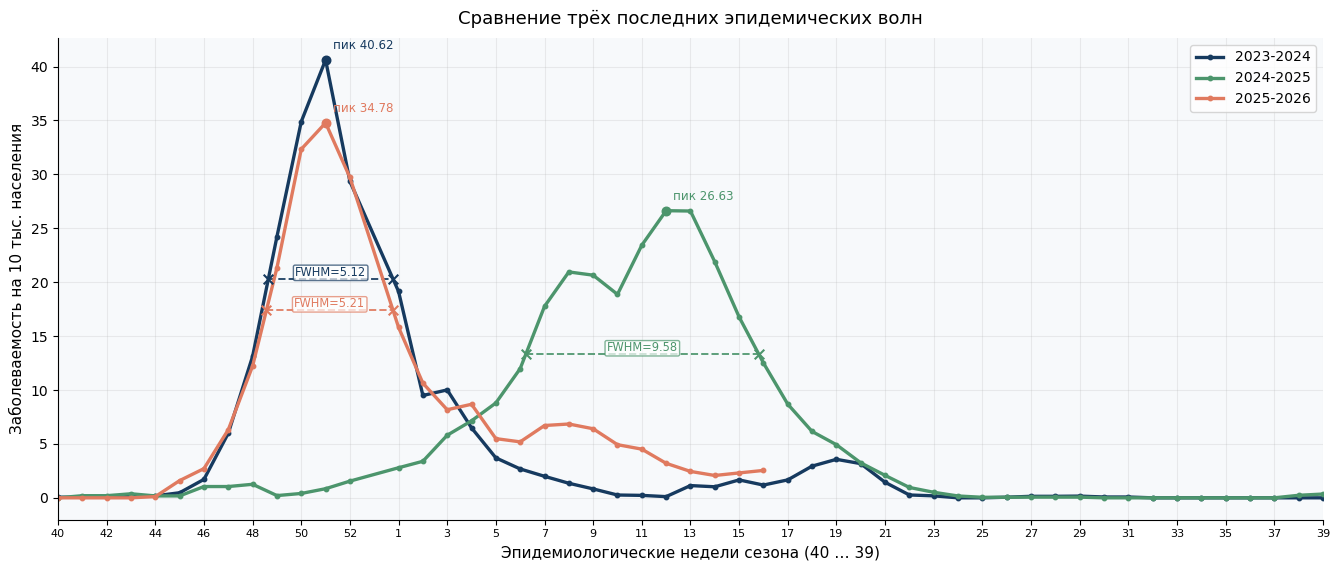

Forecast plot saved: results_csv\forecast_plot.png
Wave plot saved: results_csv\epidemic_wave_comparison_plot.png


In [26]:
forecast_hist_df = (
    history_plus_forecast_40.loc[history_plus_forecast_40["row_type"].eq("history"), ["date", "value"]]
    .rename(columns={"date": "datetime", "value": "inc_per_10k"})
    .copy()
)
forecast_hist_df["datetime"] = pd.to_datetime(forecast_hist_df["datetime"])

forecast_future_dates = pd.to_datetime(forecast_next_4w["target_date"]).sort_values().reset_index(drop=True)
forecast_rows_sorted = forecast_next_4w.sort_values("horizon_weeks").reset_index(drop=True)
forecast_y_hat = forecast_rows_sorted["point_forecast"].to_numpy(dtype=float)
forecast_y_lo = forecast_rows_sorted["q_lo"].to_numpy(dtype=float)
forecast_y_hi = forecast_rows_sorted["q_hi"].to_numpy(dtype=float)
forecast_origin_ts = pd.to_datetime(forecast_next_4w["origin_date"].iloc[0])

forecast_plot_path = os.path.join(OUT_DIR, "forecast_plot.png")
forecast_fig, _ = plot_forecast_like_example(
    raw_df=forecast_hist_df,
    origin_date=forecast_origin_ts,
    future_dates=pd.DatetimeIndex(forecast_future_dates),
    y_hat=forecast_y_hat,
    y_lo=forecast_y_lo,
    y_hi=forecast_y_hi,
    y_hist_col="inc_per_10k",
    datetime_col="datetime",
    window_back=24,
)
forecast_fig.savefig(forecast_plot_path, dpi=180, bbox_inches="tight")
plt.close(forecast_fig)

wave_plot_path = os.path.join(OUT_DIR, "epidemic_wave_comparison_plot.png")
wave_plot_path = plot_epidemic_wave_comparison_bundle(
    context["epidemic_wave_comparison"],
    out_path=wave_plot_path,
)

print("Forecast plot saved:", forecast_plot_path)
print("Wave plot saved:", wave_plot_path)


## LLM-слой и оркестрация

Этот раздел содержит только рабочий вариант генерации бюллетеня:

- `Narrator` генерирует отдельные смысловые разделы;
- deterministic-checks проверяют обязательные числа;
- text-checks выполняют простые программные проверки текста;
- `E_editor` редактирует готовые section drafts без добавления новых фактов.

Экспериментальные классы и функции для single-pass generation, external review и section-consistency удалены из активного кода.


In [27]:
from dataclasses import dataclass, field
from typing import Dict, List, Optional

LLM_BACKEND = os.getenv("LLM_BACKEND", "ollama")
OLLAMA_MODEL = os.getenv("OLLAMA_MODEL", "qwen3.5:9b")
DEFAULT_REQUEST_TIMEOUT_SEC = int(os.getenv("DEFAULT_REQUEST_TIMEOUT_SEC", "180"))
EVAL_REQUEST_TIMEOUT_SEC = int(os.getenv("EVAL_REQUEST_TIMEOUT_SEC", "600"))
EVAL_LLM_BACKEND = os.getenv("EVAL_LLM_BACKEND", "ollama")
EVAL_OLLAMA_MODEL = os.getenv("EVAL_OLLAMA_MODEL", "gemma3:12b")
NARRATOR_PROMPT_MODE = os.getenv("NARRATOR_PROMPT_MODE", "research").strip().lower()
if NARRATOR_PROMPT_MODE not in {"research", "assisted"}:
    print(f"[WARN] Неизвестный NARRATOR_PROMPT_MODE={NARRATOR_PROMPT_MODE!r}; используется 'research'.")
    NARRATOR_PROMPT_MODE = "research"



def is_very_small_model_name(model_name: str) -> bool:
    """
    Very small models are handled with a stricter format-repair path because
    they often produce almost-correct content but fail to close/normalize JSON.
    """
    if not model_name:
        return False
    name = str(model_name).strip().lower()
    m = re.search(r":\s*(\d+(?:\.\d+)?)b\s*$", name)
    if not m:
        return False
    try:
        size_b = float(m.group(1))
    except Exception:
        return False
    return size_b <= 1.0


class SectionGenerationError(RuntimeError):
    """Секция не была сгенерирована в валидном структурированном виде."""


@dataclass
class SectionRunResult:
    section_name: str
    status: str
    draft: Optional[dict]
    trace: List[dict] = field(default_factory=list)
    failure_stage: Optional[str] = None
    failure_reason: Optional[str] = None


@dataclass
class BulletinRunResult:
    status: str
    bulletin: Optional[dict]
    traces: Dict[str, List[dict]]
    sections: Dict[str, SectionRunResult]
    failure_reason: Optional[str] = None

# ══════════════════════════════════════════════════════════════
# LLM Backend
# ══════════════════════════════════════════════════════════════
class LLMBackend:
    def __init__(self, backend: str = "ollama", model: str = "qwen3.5:9b", default_timeout: Optional[int] = None):
        self.backend = backend
        self.model = model
        self.default_timeout = int(default_timeout) if default_timeout is not None else int(DEFAULT_REQUEST_TIMEOUT_SEC)

    def chat(self, messages, temperature=0.2, max_tokens=2000, format=None, think=None, timeout=None):
        if timeout is None:
            timeout = self.default_timeout
        if self.backend == "ollama":
            base_url = os.getenv("OLLAMA_URL", "http://localhost:11434").rstrip("/")
            payload = {
                "model": self.model,
                "messages": messages,
                "options": {"temperature": temperature, "num_predict": max_tokens},
                "stream": False,
            }
            if format is not None:
                payload["format"] = format

            if think is not None:
                payload["think"] = think

            r = requests.post(f"{base_url}/api/chat", json=payload, timeout=timeout)
            r.raise_for_status()
            data = r.json()
            msg = data.get("message") or {}
            content = msg.get("content") or ""
            if not content.strip() and isinstance(msg.get("thinking"), str):
                content = msg["thinking"]
            return {"content": content}

        raise ValueError(f"Unknown backend={self.backend}")


# ══════════════════════════════════════════════════════════════
# JSON extraction
# ══════════════════════════════════════════════════════════════
def _extract_outermost_json_candidate(text: str) -> Optional[str]:
    s = (text or "").strip()
    if not s:
        return None

    start = s.find("{")
    if start == -1:
        return None

    depth = 0
    in_str = False
    escape = False
    for i in range(start, len(s)):
        ch = s[i]
        if in_str:
            if escape:
                escape = False
            elif ch == "\\":
                escape = True
            elif ch == '"':
                in_str = False
            continue

        if ch == '"':
            in_str = True
        elif ch == "{":
            depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0:
                return s[start:i + 1]
    return None



def _strip_outer_code_fence(text: str) -> str:
    s = (text or "").strip()
    s = re.sub(r"^```(?:json)?\s*", "", s, flags=re.IGNORECASE)
    s = re.sub(r"\s*```\s*$", "", s)
    return s.strip()


def _iter_raw_json_dicts(text: str):
    s = text or ""
    decoder = json.JSONDecoder()
    for m in re.finditer(r"\{", s):
        start = m.start()
        try:
            obj, _ = decoder.raw_decode(s[start:])
            if isinstance(obj, dict):
                yield obj
        except Exception:
            continue


def extract_json(text: str) -> dict:
    t = (text or "").strip()
    if not t:
        raise ValueError("Пустой ответ LLM.")
    t = re.sub(r"<think>[\s\S]*?</think>", "", t, flags=re.IGNORECASE).strip()

    candidates = []
    fence_matches = re.findall(r"```(?:json)?\s*([\s\S]*?)```", t, flags=re.IGNORECASE)
    candidates.extend([c.strip() for c in fence_matches if c.strip()])

    stripped = _strip_outer_code_fence(t)
    if stripped and stripped not in candidates:
        candidates.append(stripped)

    if t not in candidates:
        candidates.append(t)

    # 1) strict JSON
    for cand in candidates:
        try:
            obj = json.loads(cand)
            if isinstance(obj, dict):
                return obj
        except Exception:
            pass

    # 2) raw_decode from any "{" position
    for cand in candidates:
        for obj in _iter_raw_json_dicts(cand):
            return obj

    # 3) outermost balanced object
    for cand in candidates:
        outer = _extract_outermost_json_candidate(cand)
        if not outer:
            continue
        try:
            obj = json.loads(outer)
            if isinstance(obj, dict):
                return obj
        except Exception:
            pass

    # 4) tolerant YAML parse
    try:
        import yaml
    except Exception:
        yaml = None

    if yaml is not None:
        for cand in candidates:
            for variant in filter(None, [cand, _extract_outermost_json_candidate(cand)]):
                try:
                    obj = yaml.safe_load(variant)
                    if isinstance(obj, dict):
                        return obj
                except Exception:
                    continue

    raise ValueError("JSON не найден в ответе LLM.")

def validate_llm_payload(obj, schema: dict, path: str = "$") -> None:
    if not isinstance(schema, dict):
        return

    schema_type = schema.get("type")

    if schema_type == "object":
        if not isinstance(obj, dict):
            raise ValueError(f"{path}: ожидался object, получено {type(obj).__name__}")
        properties = schema.get("properties", {})
        required_keys = schema.get("required", [])
        for key in required_keys:
            if key not in obj:
                raise ValueError(f"{path}: отсутствует обязательный ключ: {key}")
            validate_llm_payload(obj[key], properties.get(key, {}), path=f"{path}.{key}")
        if schema.get("additionalProperties") is False:
            extra_keys = [key for key in obj if key not in properties]
            if extra_keys:
                raise ValueError(f"{path}: запрещены дополнительные ключи: {', '.join(extra_keys)}")
        for key, value in obj.items():
            if key in properties:
                validate_llm_payload(value, properties[key], path=f"{path}.{key}")
        return

    if schema_type == "array":
        if not isinstance(obj, list):
            raise ValueError(f"{path}: ожидался array, получено {type(obj).__name__}")
        item_schema = schema.get("items", {})
        for i, item in enumerate(obj):
            validate_llm_payload(item, item_schema, path=f"{path}[{i}]")
        return

    if schema_type == "string":
        if not isinstance(obj, str):
            raise ValueError(f"{path}: ожидалась строка, получено {type(obj).__name__}")
        if not obj.strip():
            raise ValueError(f"{path}: пустая строка")
        return

    if schema_type == "boolean":
        if not isinstance(obj, bool):
            raise ValueError(f"{path}: ожидался boolean, получено {type(obj).__name__}")
        return

    if schema_type == "integer":
        if not isinstance(obj, int) or isinstance(obj, bool):
            raise ValueError(f"{path}: ожидался integer, получено {type(obj).__name__}")
        return

    if schema_type == "number":
        if not isinstance(obj, (int, float)) or isinstance(obj, bool):
            raise ValueError(f"{path}: ожидался number, получено {type(obj).__name__}")
        return

    required = schema.get("required", [])
    if required:
        if not isinstance(obj, dict):
            raise ValueError(f"{path}: ожидался object для required-полей, получено {type(obj).__name__}")
        properties = schema.get("properties", {})
        for key in required:
            if key not in obj:
                raise ValueError(f"{path}: отсутствует обязательный ключ: {key}")
            validate_llm_payload(obj[key], properties.get(key, {}), path=f"{path}.{key}")

# ══════════════════════════════════════════════════════════════
# Программная валидация чисел
# ══════════════════════════════════════════════════════════════
def validate_numbers_in_text(text: str, expected_numbers: dict, tolerance_pct=1.0) -> list:
    """
    Проверяет, что числа в тексте соответствуют ожидаемым.
    expected_numbers: {"label": value, ...}
    Возвращает список ошибок.
    """
    issues = []
    # Извлекаем все числа из текста
    found_numbers = [float(m.replace(",", ".")) for m in re.findall(r"\d+[.,]?\d*", text)]

    for label, expected in expected_numbers.items():
        if expected is None:
            continue
        exp = float(expected)
        tol = max(0.001, abs(exp) * tolerance_pct / 100)
        matched = any(abs(n - exp) <= tol for n in found_numbers)
        if not matched:
            issues.append(f"Число '{label}'={exp} не найдено в тексте (или искажено).")
    return issues


# ══════════════════════════════════════════════════════════════
# Программная валидация качества текста
# ══════════════════════════════════════════════════════════════
# Допустимые латинские слова/аббревиатуры в эпиднадзорном бюллетене
ALLOWED_LATIN = {
    "MAE", "RMSE", "R²", "R2", "SHAP", "ISO", "h", "q",
    "ПЦР", "ОРВИ",  # кириллица, но для полноты
}

def validate_text_quality(text: str) -> list:
    """
    Программная проверка качества текста.
    Возвращает список ошибок (критичных) и предупреждений (WARN:).
    """
    issues = []
    if not text or not text.strip():
        return ["Текст пустой."]

    # 1) Английские/кодовые слова (латиница длиннее 1 символа, не в whitelist)
    latin_words = re.findall(r"\b[a-zA-Z_][a-zA-Z0-9_]{1,}\b", text)
    bad_latin = [w for w in latin_words if w not in ALLOWED_LATIN and w.upper() not in ALLOWED_LATIN]
    if bad_latin:
        unique_bad = sorted(set(bad_latin))
        issues.append(
            f"Английские/кодовые слова в тексте: {unique_bad}. "
            "Замени на русские эквиваленты."
        )

    # 2) Проблемные Unicode-символы (не отрендерятся в PDF со шрифтом DejaVu)
    # Разрешаем: кириллицу, базовую латиницу, цифры, стандартную пунктуацию, пробелы
    allowed_ranges = (
        '\u0020-\u007E'   # базовая латиница + ASCII пунктуация
        '\u00A0-\u00FF'   # Latin-1 Supplement (°, ², ±, etc.)
        '\u0400-\u04FF'   # кириллица
        '\u2010-\u2027'   # дефисы, тире, кавычки
        '\u2030-\u205E'   # промилле, спецпробелы
        '\u2070-\u209F'   # надстрочные/подстрочные
        '\u2116'           # №
    )
    bad_chars = re.findall(f'[^{allowed_ranges}\n\r\t]', text)
    if bad_chars:
        unique_bad_chars = sorted(set(bad_chars))
        char_codes = [f"U+{ord(c):04X}" for c in unique_bad_chars]
        issues.append(
            f"Символы, которые не отобразятся в PDF: {char_codes}. "
            "Замени на стандартные символы."
        )

    # 3) Пунктуационные артефакты
    punct_issues = []
    if re.search(r'[.,]{2,}', text):
        punct_issues.append("двойная пунктуация (напр. '.,', '..')")
    if re.search(r'\s{3,}', text):
        punct_issues.append("тройные+ пробелы")
    if re.search(r'[.!?],', text):
        punct_issues.append("точка/восклицательный перед запятой")
    if punct_issues:
        issues.append(f"Пунктуационные артефакты: {'; '.join(punct_issues)}.")

    # 4) Слишком короткий текст (подозрительно для аналитического раздела)
    word_count = len(text.split())
    if word_count < 15:
        issues.append(f"WARN: текст подозрительно короткий ({word_count} слов).")

    return issues


# ══════════════════════════════════════════════════════════════
# JSON schemas для Ollama structured output
# ══════════════════════════════════════════════════════════════
SECTION_SCHEMAS = {
    "current_situation": {
        "type": "object",
        "properties": {
            "paragraph_situation": {"type": "string"},
            "paragraph_forecast_brief": {"type": "string"},
        },
        "required": ["paragraph_situation", "paragraph_forecast_brief"],
        "additionalProperties": False,
    },
    "forecast_risks": {
        "type": "object",
        "properties": {
            "point_forecast_text": {"type": "string"},
            "uncertainty_text": {"type": "string"},
            "risk_assessment": {"type": "string"},
        },
        "required": ["point_forecast_text", "uncertainty_text", "risk_assessment"],
        "additionalProperties": False,
    },
    "shap_interpretation": {
        "type": "object",
        "properties": {
            "short_term_factors": {"type": "string"},
            "long_term_factors": {"type": "string"},
            "overall_insight": {"type": "string"},
        },
        "required": ["short_term_factors", "long_term_factors", "overall_insight"],
        "additionalProperties": False,
    },
    "model_quality": {
        "type": "object",
        "properties": {
            "quality_summary": {"type": "string"},
            "limitations_text": {"type": "string"},
        },
        "required": ["quality_summary", "limitations_text"],
        "additionalProperties": False,
    },
    "model_description": {
        "type": "object",
        "properties": {
            "description_text": {"type": "string"},
        },
        "required": ["description_text"],
        "additionalProperties": False,
    },
    "epidemic_wave_comparison": {
        "type": "object",
        "properties": {
            "comparison_text": {"type": "string"},
        },
        "required": ["comparison_text"],
        "additionalProperties": False,
    },
}



# Narrator: посекционная генерация
# ══════════════════════════════════════════════════════════════
class Narrator:
    def __init__(self, llm: LLMBackend):
        self.llm = llm

    def _call_llm(self, system: str, user_data: dict, schema: dict, max_tokens=800) -> dict:
        base_messages = [
            {"role": "system", "content": system},
            {"role": "user", "content": json.dumps(user_data, ensure_ascii=False)},
        ]

        errors = []
        last_content = ""
        last_error = None

        attempt_specs = [
            ("structured_output", 0.0, schema),
            ("repair", 0.0, schema),
            ("no_format", 0.0, None),
        ]

        for label, temperature, fmt in attempt_specs:
            if label == "structured_output":
                messages = base_messages
            elif label == "repair":
                if is_very_small_model_name(self.llm.model):
                    repair_payload = {
                        "instruction": (
                            "Ниже дан предыдущий ответ и ошибка валидации. "
                            "НЕ генерируй раздел заново. "
                            "Исправь только формат ответа: JSON-структуру, кавычки, скобки, названия ключей, "
                            "недостающие поля и лишний текст вне JSON. "
                            "Сохрани уже имеющееся содержание максимально близко. "
                            "Не добавляй новые факты, которых нет в previous_response или original_data. "
                            "Удали markdown-блоки и повторяющиеся фрагменты. "
                            "Верни строго один JSON-объект указанной схемы и ничего кроме JSON."
                        ),
                        "schema_error": last_error or "unknown schema error",
                        "previous_response": last_content,
                        "original_data": user_data,
                    }
                else:
                    repair_payload = {
                        "instruction": (
                            "Ниже дан предыдущий неудачный ответ и ошибка валидации. "
                            "Сгенерируй ответ заново по исходным данным, но верни строго один JSON-объект "
                            "указанной схемы и ничего кроме JSON."
                        ),
                        "schema_error": last_error or "unknown schema error",
                        "previous_response": last_content,
                        "original_data": user_data,
                    }
                messages = [
                    {"role": "system", "content": system},
                    {"role": "user", "content": json.dumps(repair_payload, ensure_ascii=False)},
                ]
            else:
                nofmt_payload = {
                    "instruction": (
                        "Верни строго один JSON-объект указанной структуры. "
                        "Никаких markdown-блоков, пояснений или текста вне JSON."
                    ),
                    "schema_error": last_error or "unknown schema error",
                    "original_data": user_data,
                }
                if last_content:
                    nofmt_payload["previous_response"] = last_content
                messages = [
                    {"role": "system", "content": system},
                    {"role": "user", "content": json.dumps(nofmt_payload, ensure_ascii=False)},
                ]

            msg = self.llm.chat(
                messages,
                temperature=temperature,
                max_tokens=max_tokens,
                format=fmt,
                think=False,
            )
            content = (msg or {}).get("content", "")
            last_content = content

            try:
                payload = extract_json(content)
                validate_llm_payload(payload, schema)
                return payload
            except Exception as e:
                last_error = str(e)
                errors.append(f"{label}: {e}")
                print(f"  [Narrator] Попытка {label} не удалась: {e}")
                print(f"  [Narrator] Ответ LLM (первые 300 символов): {content[:300]}")

        raise SectionGenerationError(
            "LLM не вернула валидный JSON после 3 попыток. "
            f"Ошибки: {' | '.join(errors)}. "
            f"Последний ответ: {last_content[:800]}"
        )

    # ── Раздел 1: Текущая ситуация ──



# =========================================================
# PATCH v87: narrator-safe section packets
# Минимально инвазивный слой проекции перед narrator:
# narrator получает только publication-safe packet без
# semantic/semantic_codes/*_code/raw status полей.
# =========================================================

_NARRATOR_FORBIDDEN_KEYS = {"semantic", "semantic_codes", "wave_status"}
_NARRATOR_FORBIDDEN_SUFFIXES = ("_code", "_codes")


def _validate_narrator_packet(packet: dict) -> None:
    def _walk(obj, path="root"):
        if isinstance(obj, dict):
            for k, v in obj.items():
                if k in _NARRATOR_FORBIDDEN_KEYS or any(str(k).endswith(s) for s in _NARRATOR_FORBIDDEN_SUFFIXES):
                    raise ValueError(f"Forbidden narrator field: {path}.{k}")
                _walk(v, f"{path}.{k}")
        elif isinstance(obj, list):
            for i, item in enumerate(obj):
                _walk(item, f"{path}[{i}]")
    _walk(packet)


def _trim_feature_dicts(items):
    trimmed = []
    for feat in (items or []):
        if not isinstance(feat, dict):
            continue
        trimmed.append({k: v for k, v in feat.items() if k != "_internal_name"})
    return trimmed


def _build_current_situation_narrator_packet(ctx: dict) -> dict:
    cs = ctx["current_situation"]
    fc = ctx["forecast"]
    packet = {
        "iso_week": ctx["origin"]["iso_week"],
        "iso_year": ctx["origin"]["iso_year"],
        "unit": ctx.get("unit"),
        "current_value": cs.get("current_value"),
        "previous_value": cs.get("previous_value"),
        "change_pct": cs.get("change_pct"),
        "direction_word": cs.get("direction_word"),
        "trend_4w_values": cs.get("trend_4w_values"),
        "trend_4w_label": cs.get("trend_4w_label"),
        "weekly_point_forecast": [
            {
                "horizon_weeks": h.get("horizon_weeks"),
                "target_date": h.get("target_date"),
                "target_iso_week": h.get("target_iso_week"),
                "point_forecast": h.get("point_forecast"),
            }
            for h in fc.get("horizons", [])
        ],
        "forecast_trend_label": fc.get("trend_label"),
        "forecast_dynamics_description": fc.get("dynamics_description"),
    }
    _validate_narrator_packet(packet)
    return packet


def _build_forecast_risks_narrator_packet(ctx: dict) -> dict:
    fc = ctx["forecast"]
    horizons = fc.get("horizons", [])
    packet = {
        "weekly_forecast": [
            {
                "horizon_weeks": h.get("horizon_weeks"),
                "target_date": h.get("target_date"),
                "target_iso_week": h.get("target_iso_week"),
                "point_forecast": h.get("point_forecast"),
                "q_lo": h.get("q_lo"),
                "q_hi": h.get("q_hi"),
                "interval_width": h.get("interval_width", h.get("pi_width")),
            }
            for h in horizons
        ],
        "trend_label": fc.get("trend_label"),
        "dynamics_description": fc.get("dynamics_description"),
        "uncertainty_label": fc.get("uncertainty_label"),
        "relative_uncertainty_pct": fc.get("relative_uncertainty_pct"),
        "max_interval_width": fc.get("max_interval_width"),
        "all_lower_bounds_zero": all(abs(float(h.get("q_lo", 0.0))) < 1e-12 for h in horizons),
    }
    _validate_narrator_packet(packet)
    return packet


def _sanitize_wave_for_narrator(wave: dict) -> dict:
    status = wave.get("wave_status")
    width_complete = status == "complete"
    return {
        "season_label": wave.get("season_label"),
        "peak_week": wave.get("peak_week"),
        "peak_date": wave.get("peak_date"),
        "peak_value": wave.get("peak_value"),
        "fwhm_weeks": wave.get("fwhm_weeks") if width_complete else None,
        "fwhm_lower_bound_weeks": wave.get("fwhm_lower_bound_weeks") if not width_complete else None,
        "width_complete": width_complete,
        "width_note_ru": _format_wave_width_clause_ru(wave),
        "asymmetry_ratio": wave.get("asymmetry_ratio"),
        "season_area": wave.get("season_area"),
        "rise_slope_half_to_peak": wave.get("rise_slope_half_to_peak"),
        "fall_slope_peak_to_half": wave.get("fall_slope_peak_to_half"),
        "secondary_peak_ratio": wave.get("secondary_peak_ratio"),
    }


def _build_epidemic_wave_comparison_narrator_packet(ctx: dict) -> dict:
    wc = ctx["epidemic_wave_comparison"]
    packet = {
        "series_name": wc.get("series_name"),
        "series_label_ru": wc.get("series_label_ru"),
        "season_definition": wc.get("season_definition"),
        "width_definition": wc.get("width_definition"),
        "smoothing": wc.get("smoothing"),
        "season_labels": wc.get("season_labels"),
        "waves": [_sanitize_wave_for_narrator(w) for w in wc.get("waves", [])],
        "latest_vs_previous": [
            {
                "latest_season": cmp.get("latest_season"),
                "previous_season": cmp.get("previous_season"),
                "peak_diff_abs": cmp.get("peak_diff_abs"),
                "peak_diff_pct": cmp.get("peak_diff_pct"),
                "peak_week_diff": cmp.get("peak_week_diff"),
                "season_area_diff_pct": cmp.get("season_area_diff_pct"),
                "width_diff_weeks": cmp.get("width_diff_weeks"),
                "latest_width_incomplete": cmp.get("latest_width_censored"),
            }
            for cmp in wc.get("latest_vs_previous", [])
        ],
        "peak_ranking": wc.get("peak_ranking"),
        "width_ranking_complete": wc.get("width_ranking_complete"),
        "latest_width_note_ru": _format_wave_width_clause_ru((wc.get("waves") or [{}])[-1]),
        "allowed_claims": wc.get("allowed_claims"),
        "forbidden_claims": wc.get("forbidden_claims"),
    }
    _validate_narrator_packet(packet)
    return packet


def _build_shap_interpretation_narrator_packet(ctx: dict) -> dict:
    shap = ctx["shap_summary"]
    by_h = shap.get("by_horizon") or {}
    packet = {
        "short_term_features": _trim_feature_dicts(by_h.get("1", [])),
        "long_term_features": _trim_feature_dicts(by_h.get("4", [])),
        "key_insight": shap.get("key_insight"),
    }
    _validate_narrator_packet(packet)
    return packet


def _build_model_quality_narrator_packet(ctx: dict) -> dict:
    mq = ctx["model_quality"]
    packet = {
        "metrics": mq.get("metrics"),
        "error_stats_h1": mq.get("error_stats_h1"),
        "bias_description_ru": mq.get("worst_case_pattern"),
        "peak_error_months": (mq.get("semantic") or {}).get("peak_error_months", []),
    }
    _validate_narrator_packet(packet)
    return packet


def _build_model_description_narrator_packet(ctx: dict) -> dict:
    mi = ctx["model_info"]
    fg_ru = mi.get("feature_groups_ru", {})
    packet = {
        "family_ru": mi.get("family_ru"),
        "strategy_ru": mi.get("strategy_ru"),
        "task_type_ru": mi.get("task_type_ru"),
        "forecast_target_ru": mi.get("forecast_target_ru"),
        "horizons": mi.get("horizons", []),
        "feature_groups_ru": [fg_ru.get(g, g) for g in mi.get("feature_groups", [])],
        "calibration_start_year": mi.get("calibration_start_year"),
        "calibration_data_description": mi.get("calibration_data_description"),
    }
    _validate_narrator_packet(packet)
    return packet


def build_narrator_packet(section_name: str, ctx: dict) -> dict:
    builders = {
        "current_situation": _build_current_situation_narrator_packet,
        "epidemic_wave_comparison": _build_epidemic_wave_comparison_narrator_packet,
        "forecast_risks": _build_forecast_risks_narrator_packet,
        "shap_interpretation": _build_shap_interpretation_narrator_packet,
        "model_quality": _build_model_quality_narrator_packet,
        "model_description": _build_model_description_narrator_packet,
    }
    if section_name not in builders:
        raise KeyError(f"Unknown narrator packet section: {section_name}")
    return builders[section_name](ctx)


def generate_current_situation(self, ctx: dict, feedback: str = None) -> dict:
    packet = build_narrator_packet("current_situation", ctx)

    system = (
        "Ты Narrator — автор еженедельного бюллетеня по гриппу и ОРВИ. "
        "Сгенерируй два абзаца для раздела 'Текущая ситуация'. "
        "Верни JSON с полями paragraph_situation и paragraph_forecast_brief.\n\n"
        "АБЗАЦ 1 (paragraph_situation): "
        "по значениям current_value и previous_value определи изменение относительно предыдущей недели; "
        "обязательно укажи текущее наблюдаемое значение current_value в явном виде. "
        "Затем кратко охарактеризуй динамику последних четырёх недель по ряду trend_4w_values "
        "и при необходимости по полю trend_4w_label.\n\n"
        "АБЗАЦ 2 (paragraph_forecast_brief): "
        "начни СТРОГО фразой 'Прогноз на четыре недели показывает ...'. "
        "Далее по weekly_point_forecast и, при необходимости, по human-readable полю "
        "forecast_dynamics_description кратко опиши форму 4-недельной траектории. "
        "Если внутри траектории есть смена направления, обязательно отрази её явно.\n\n"
        "ПРАВИЛА: "
        "используй только данные из JSON-контекста; не придумывай дополнительные факты; "
        "используй только недельную шкалу времени — не пиши про дни, сутки, вчера, сегодня или месяцы; "
        "стиль официальный, нейтральный, без списков."
    )

    user = {"mode": NARRATOR_PROMPT_MODE, "current_situation_context": packet}
    if feedback:
        user["feedback_to_fix"] = feedback

    return self._call_llm(system, user, SECTION_SCHEMAS["current_situation"], max_tokens=700)

def generate_forecast_risks(self, ctx: dict, feedback: str = None) -> dict:
    packet = build_narrator_packet("forecast_risks", ctx)

    system = (
        "Ты Narrator — автор аналитического раздела бюллетеня по гриппу. "
        "Сгенерируй три абзаца для раздела 'Прогноз и оценка рисков'. "
        "Верни JSON: {point_forecast_text, uncertainty_text, risk_assessment}.\n\n"
        "АБЗАЦ 1 (point_forecast_text): "
        "по weekly_forecast и, при необходимости, по human-readable полю dynamics_description "
        "опиши точечный прогноз на 4 недели. "
        "Если внутри траектории есть промежуточный рост или промежуточное снижение, обязательно отрази это явно; "
        "не своди немонотонную траекторию к одному слову.\n\n"
        "АБЗАЦ 2 (uncertainty_text): "
        "объясни неопределённость прогноза по границам интервалов, их ширине, максимуму max_interval_width, "
        "относительной неопределённости relative_uncertainty_pct и, при необходимости, по полю uncertainty_label. "
        "Используй термин 'прогнозный интервал'. Не используй термины 'доверительный интервал' "
        "или 'интервал достоверности'. Объясни, что верхняя граница прогноза соответствует неблагоприятному сценарию "
        "с более высокой заболеваемостью, а нижняя граница, равная нулю, не является неблагоприятным исходом. "
        "Кратко поясни значение ширины интервалов для лица, принимающего решения.\n\n"
        "АБЗАЦ 3 (risk_assessment): "
        "дай сдержанную оценку риска для недельного мониторинга на ближайшие 4 недели. "
        "Не выходи за рамки данных и не делай причинных выводов.\n\n"
        "ПРАВИЛА: используй только данные из JSON-контекста; не придумывай дополнительные факты; "
        "используй только недельную шкалу времени — не пиши про дни, сутки, вчера, сегодня или месяцы; "
        "стиль официальный и нейтральный."
    )

    user = {"mode": NARRATOR_PROMPT_MODE, "forecast_context": packet}
    if feedback:
        user["feedback_to_fix"] = feedback

    return self._call_llm(system, user, SECTION_SCHEMAS["forecast_risks"], max_tokens=900)

def generate_epidemic_wave_comparison(self, ctx: dict, feedback: str = None) -> dict:
    packet = build_narrator_packet("epidemic_wave_comparison", ctx)
    waves = packet["waves"]
    latest = waves[-1]
    previous = waves[:-1]

    system = (
        "Ты Narrator — автор аналитического подпункта к рисунку о сравнении трёх последних эпидемических волн. "
        "Сгенерируй ОДИН плотный абзац и верни JSON {comparison_text}. "
        "Сравни последнюю волну с двумя предыдущими сезонами только по structured evidence bundle. "
        "Обязательно отрази: 1) сравнительную высоту пиков, 2) положение пиков по неделям, "
        "3) ширину волны по FWHM или, если полная ширина последней волны ещё не наблюдалась, явное указание на это. "
        "Допустимо кратко описать асимметрию волны и суммарную сезонную нагрузку, если это поддержано данными. "
        "Запрещено упоминать MEM, базовые линии, эпидемические пороги, формальное начало или окончание эпидемии, "
        "а также причинные объяснения. "
        "Текст должен быть в 4–6 предложениях, без списков, официальным и нейтральным."
    )

    user = {"mode": NARRATOR_PROMPT_MODE, "wave_comparison_context": packet}
    if feedback:
        user["feedback_to_fix"] = feedback

    return self._call_llm(system, user, SECTION_SCHEMAS["epidemic_wave_comparison"], max_tokens=900)

def generate_shap_interpretation(self, ctx: dict, feedback: str = None) -> dict:
    packet = build_narrator_packet("shap_interpretation", ctx)

    system = (
        "Ты Narrator — автор раздела 'Интерпретация модели' в эпиднадзорном бюллетене. "
        "Объясни, какие факторы влияют на прогноз, используя SHAP-данные. "
        "Верни JSON: {short_term_factors, long_term_factors, overall_insight}.\n\n"
        "АБЗАЦ 1 (short_term_factors): "
        "опиши top-факторы для краткосрочного прогноза h=1, опираясь на short_term_features. "
        "Для факторов с признаком направление_надёжное=false не утверждай фиксированное повышение или понижение прогноза; "
        "пиши, что влияние зависит от текущей эпидемической ситуации.\n\n"
        "АБЗАЦ 2 (long_term_factors): "
        "аналогично опиши top-факторы для горизонта h=4, опираясь на long_term_features.\n\n"
        "АБЗАЦ 3 (overall_insight): "
        "сравни горизонты h=1 и h=4 и сформулируй общий вывод о смене структуры факторов, "
        "используя key_insight только как опорное human-readable резюме, а не как готовую фразу. "
        "Допустимы только три типа утверждений: "
        "1) относительная важность факторов, "
        "2) различия между горизонтами, "
        "3) устойчивость или контекстная зависимость направления влияния. "
        "Запрещены причинные объяснения, домыслы и выводы вне данных.\n\n"
        "ПРАВИЛА: h=1 и h=4 означают 1 и 4 недели вперёд; не пиши про дни или месяцы. "
        "Не используй английские термины. Вместо 'SHAP-значение' пиши 'вклад фактора' или 'степень влияния'. "
        "Сохраняй официальный стиль."
    )

    user = {"mode": NARRATOR_PROMPT_MODE, "shap_context": packet}
    if feedback:
        user["feedback_to_fix"] = feedback

    return self._call_llm(system, user, SECTION_SCHEMAS["shap_interpretation"], max_tokens=1000)

def generate_model_quality(self, ctx: dict, feedback: str = None) -> dict:
    packet = build_narrator_packet("model_quality", ctx)

    system = (
        "Ты Narrator — автор раздела 'Качество модели и ограничения'. "
        "Верни JSON: {quality_summary, limitations_text}.\n\n"
        "АБЗАЦ 1 (quality_summary): "
        "кратко охарактеризуй качество модели по метрикам на разных горизонтах и по статистике ошибок для h=1. "
        "Используй только факты. Не используй оценочные слова вроде 'хороший', 'сильный' или 'отличный'.\n\n"
        "АБЗАЦ 2 (limitations_text): "
        "сформулируй ограничения модели по полю bias_description_ru, по месяцам peak_error_months "
        "и по статистике ошибок. Объясни, что это означает для практического использования прогноза. "
        "Не добавляй недоказанные причины ошибок.\n\n"
        "СТИЛЬ: нейтральный, для специалиста. "
        "Аббревиатуры MAE, RMSE и R² можно использовать как общепринятые обозначения."
    )

    user = {"mode": NARRATOR_PROMPT_MODE, "model_quality_context": packet}
    if feedback:
        user["feedback_to_fix"] = feedback

    return self._call_llm(system, user, SECTION_SCHEMAS["model_quality"], max_tokens=800)

def generate_model_description(self, ctx: dict, feedback: str = None) -> dict:
    packet = build_narrator_packet("model_description", ctx)

    system = (
        "Ты Narrator — автор раздела 'Описание модели'. "
        "На основе структурированной карточки модели напиши компактное описание для бюллетеня. "
        "Верни JSON: {description_text}.\n\n"
        "Требования к тексту:\n"
        "1) 2–3 предложения, официальный нейтральный стиль.\n"
        "2) Обязательно отрази тип модели, стратегию многошагового прогноза, диапазон горизонтов в неделях, "
        "основные группы признаков и стартовый год калибровки.\n"
        "3) Если поле отсутствует или неизвестно, опирайся только на доступные данные и не придумывай недостающие свойства.\n"
        "4) Не используй англоязычные имена классов и кодовые идентификаторы. "
        "Не добавляй маркетинговые или оценочные утверждения о качестве модели.\n"
        "5) Текст должен оставаться корректным и для других семейств моделей, а не только для текущей реализации."
    )

    user = {"mode": NARRATOR_PROMPT_MODE, "model_card": packet}
    if feedback:
        user["feedback_to_fix"] = feedback

    return self._call_llm(system, user, SECTION_SCHEMAS["model_description"], max_tokens=700)



# ══════════════════════════════════════════════════════════════
# Оркестрация: посекционная генерация и программная валидация
# ══════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────
# Привязка narrator-функций как методов класса Narrator
# (функции ниже определены на уровне модуля и затем
# явно назначаются методами, чтобы сохранить прозрачность
# prompt-кода и единый интерфейс narrator.generate_*).
# ─────────────────────────────────────────────────────────────
Narrator.generate_current_situation = generate_current_situation
Narrator.generate_forecast_risks = generate_forecast_risks
Narrator.generate_epidemic_wave_comparison = generate_epidemic_wave_comparison
Narrator.generate_shap_interpretation = generate_shap_interpretation
Narrator.generate_model_quality = generate_model_quality
Narrator.generate_model_description = generate_model_description

def _assemble_bulletin(ctx: dict, section_payloads: Dict[str, dict]) -> dict:
    iso_week = ctx["origin"]["iso_week"]
    iso_year = ctx["origin"]["iso_year"]

    forecast_figure_caption = (
        f"Рис. 1. Результаты моделирования заболеваемости гриппом с начала сезона "
        f"по {iso_week} неделю {iso_year} г."
    )
    wave_figure_caption = (
        "Рис. 2. Сравнение трёх последних эпидемических волн по показателю "
        "заболеваемости на 10 тыс. населения. Показаны сглаженные кривые, "
        "точки пика и FWHM-маркеры."
    )

    return {
        "title_main": "ЕЖЕНЕДЕЛЬНЫЙ БЮЛЛЕТЕНЬ ПО ГРИППУ И ОРВИ",
        "title_sub": f"за {iso_week} неделю {iso_year} года. ({ctx['origin']['week_start']} - {ctx['origin']['week_end']})",
        "sections": {
            "current_situation": section_payloads["current_situation"],
            "figure_caption": forecast_figure_caption,
            "forecast_figure_caption": forecast_figure_caption,
            "wave_figure_caption": wave_figure_caption,
            "epidemic_wave_comparison": section_payloads["epidemic_wave_comparison"],
            "forecast_table": ctx["forecast"]["horizons"],
            "forecast_risks": section_payloads["forecast_risks"],
            "shap_interpretation": section_payloads["shap_interpretation"],
            "model_quality": section_payloads["model_quality"],
            "metrics_table": ctx["model_quality"]["metrics"],
            "model_description": section_payloads["model_description"],
        },
        "meta": {
            "origin_date": ctx["origin"]["origin_date"],
            "iso_year": iso_year,
            "iso_week": iso_week,
        },
    }


    return _assemble_bulletin(ctx, canonical_sections)

# Ниже orchestration вынесена в отдельный configurable layer.
# Legacy run_section / run_multiagent intentionally removed.


In [28]:
# =========================================================
# PATCH v33: локальная стабилизация epidemic_wave_comparison
# Не меняет глобальную retry/repair/no-format логику Narrator.
# Меняется только контракт и payload новой секции.
# =========================================================

def _format_wave_width_clause_ru(wave: dict) -> str:
    status = wave.get("wave_status")
    if status == "right_censored":
        lb = wave.get("fwhm_lower_bound_weeks")
        return (
            f"полная ширина последней волны ещё не наблюдалась; на текущий момент FWHM не меньше {lb} недели"
            if lb is not None else
            "полная ширина последней волны ещё не наблюдалась"
        )
    if status == "left_censored":
        return "левая граница волны обрезана, поэтому полная ширина оценена неполно"
    if status == "both_censored":
        return "обе границы волны обрезаны, поэтому полная ширина не наблюдается"
    fwhm = wave.get("fwhm_weeks")
    return f"ширина волны по FWHM составляет {fwhm} недели" if fwhm is not None else "ширина волны по FWHM не определена"


def _compact_wave_evidence_ru(ctx: dict) -> dict:
    wc = ctx["epidemic_wave_comparison"]
    latest = wc["waves"][-1]
    previous = wc["waves"][:-1]

    waves_ru = []
    for wave in wc["waves"]:
        item = {
            "сезон": wave.get("season_label"),
            "статус_волны": wave.get("wave_status"),
            "пик_неделя": wave.get("peak_week"),
            "пик_дата": wave.get("peak_date"),
            "пик_значение": wave.get("peak_value"),
            "полувысота": wave.get("half_height_value"),
            "ширина_FWHM_недели": wave.get("fwhm_weeks"),
            "нижняя_граница_FWHM_если_неполная": wave.get("fwhm_lower_bound_weeks"),
            "асимметрия": wave.get("asymmetry_ratio"),
            "сезонная_нагрузка": wave.get("season_area"),
            "скорость_подъёма_от_полувысоты_к_пику": wave.get("rise_slope_half_to_peak"),
            "скорость_спада_от_пика_к_полувысоте": wave.get("fall_slope_peak_to_half"),
            "отношение_вторичного_пика_к_главному": wave.get("secondary_peak_ratio"),
        }
        waves_ru.append(item)

    comparisons_ru = []
    for cmp in wc.get("latest_vs_previous", []):
        item = {
            "последний_сезон": cmp.get("latest_season"),
            "предыдущий_сезон": cmp.get("previous_season"),
            "разница_пиков_абс": cmp.get("peak_diff_abs"),
            "разница_пиков_проц": cmp.get("peak_diff_pct"),
            "разница_недель_пика": cmp.get("peak_week_diff"),
            "разница_сезонной_нагрузки_проц": cmp.get("season_area_diff_pct"),
            "разница_ширины_FWHM_недели": cmp.get("width_diff_weeks"),
            "ширина_последней_волны_цензурирована": cmp.get("latest_width_censored"),
        }
        comparisons_ru.append(item)

    return {
        "показатель": wc.get("series_label_ru"),
        "единица": ctx.get("unit"),
        "режим_сравнения": "три последних эпидемических сезона",
        "определение_сезона": wc.get("season_definition"),
        "сглаживание": {
            "метод": "центрированное скользящее среднее",
            "окно_недель": wc.get("smoothing", {}).get("window_weeks"),
        },
        "определение_ширины": "FWHM по сглаженной недельной кривой",
        "сезоны": [w.get("season_label") for w in wc.get("waves", [])],
        "последняя_волна": {
            "сезон": latest.get("season_label"),
            "статус": latest.get("wave_status"),
            "формулировка_по_ширине": _format_wave_width_clause_ru(latest),
        },
        "волны_по_сезонам": waves_ru,
        "сравнение_последней_волны_с_двумя_предыдущими": comparisons_ru,
        "ранжирование_по_высоте_пика": wc.get("peak_ranking"),
        "ранжирование_по_ширине_среди_полных_волн": wc.get("width_ranking_complete"),
        "разрешённые_типы_утверждений": [
            "сравнение высоты пиков",
            "сравнение положения пиков по неделям",
            "сравнение ширины по FWHM только для полных волн",
            "оговорка о right-censored ширине для незавершённой последней волны",
            "сравнение асимметрии только если метрика определена",
            "сравнение суммарной сезонной нагрузки",
        ],
        "запрещённые_типы_утверждений": [
            "эпидемические пороги",
            "MEM",
            "формальное начало или окончание эпидемии",
            "причинные объяснения вне evidence bundle",
        ],
    }


def _build_epidemic_wave_narrator_payload(ctx: dict, feedback: str = None) -> dict:
    payload = {
        "mode": NARRATOR_PROMPT_MODE,
        "section_name": "epidemic_wave_comparison",
        "output_contract": {
            "return_only_json": True,
            "top_level_keys_exactly": ["comparison_text"],
            "json_example": {
                "comparison_text": (
                    "Последняя эпидемическая волна сопоставляется с двумя предыдущими сезонами по высоте пика, "
                    "положению пика и ширине по FWHM."
                )
            },
            "forbidden_output": [
                "markdown headings",
                "bullet lists",
                "english preamble",
                "text outside JSON",
            ],
        },
        "writing_rules": [
            "Один плотный абзац на русском языке",
            "4–6 предложений",
            "Нейтральный официальный стиль",
            "Без списков, подзаголовков и markdown",
            "Использовать только structured evidence",
        ],
        "wave_evidence_ru": _compact_wave_evidence_ru(ctx),
    }
    if feedback:
        payload["feedback_to_fix"] = feedback
    return payload


def _patched_generate_epidemic_wave_comparison(self, ctx: dict, feedback: str = None) -> dict:
    wc = ctx["epidemic_wave_comparison"]
    latest = wc["waves"][-1]
    previous = wc["waves"][:-1]

    system = (
        "Ты Narrator — автор аналитического подпункта к рисунку о сравнении трёх последних эпидемических волн. "
        "Верни строго один JSON-объект и ничего кроме JSON. "
        "Точная схема ответа: {\"comparison_text\": \"...\"}. "
        "На верхнем уровне допускается РОВНО ОДИН ключ comparison_text. "
        "Значение comparison_text должно быть одним плотным абзацем на русском языке из 4–6 предложений, "
        "без markdown, без заголовков, без списков и без текста вне JSON. "
        "Сравни последнюю волну с двумя предыдущими сезонами только по structured evidence bundle. "
        "Обязательно отрази: 1) сравнительную высоту пиков, 2) положение пиков по неделям, "
        "3) ширину волны по FWHM или, если последняя волна имеет статус right-censored, явное указание, "
        "что полная ширина ещё не наблюдалась. "
        "Допустимо кратко описать асимметрию волны и суммарную сезонную нагрузку, если это поддержано данными. "
        "Запрещено упоминать MEM, базовые линии, эпидемические пороги, формальное начало или окончание эпидемии, "
        "а также причинные объяснения."
    )

    user = _build_epidemic_wave_narrator_payload(ctx, feedback=feedback)

    return self._call_llm(system, user, SECTION_SCHEMAS["epidemic_wave_comparison"], max_tokens=1200)


Narrator.generate_epidemic_wave_comparison = _patched_generate_epidemic_wave_comparison


In [29]:
# =========================================================
# age_group_season_overview: schema, compact evidence and bulletin integration
# =========================================================

SECTION_SCHEMAS["age_group_season_overview"] = {
    "type": "object",
    "properties": {"overview_text": {"type": "string"}},
    "required": ["overview_text"],
    "additionalProperties": False,
}

def _compact_age_group_season_evidence_ru(ctx: dict) -> dict:
    ag = ctx["age_group_season"]
    rows = []
    for row in ag.get("rows", []):
        rows.append({
            "age_group_code": row["age_group_code"],
            "age_group_label": row["age_group_label"],
            "is_total_row": row.get("is_total_row", False),
            "season_cases": row["season_cases"],
            "cumulative_incidence_pct": row["cumulative_incidence_pct"],
            "peak_week": row["peak_week"],
            "peak_date": row.get("peak_date"),
            "peak_season_position": row.get("peak_season_position"),
            "peak_inc_per_10k": row["peak_inc_per_10k"],
            "mean_weekly_inc_per_10k": row["mean_weekly_inc_per_10k"],
            "peak_width_weeks": row.get("peak_width_weeks"),
            "peak_width_defined": row.get("peak_width_defined"),
            "peak_width_reason": row.get("peak_width_reason"),
            "width_level": row.get("width_level"),
            "share_of_total_cases_pct": row["share_of_total_cases_pct"],
        })
    return {
        "season_label": ag["season_label"],
        "metric_label_ru": ag["metric_label_ru"],
        "width_definition": ag["width_definition"],
        "width_undefined_note": ag.get("peak_width_undefined_note"),
        "comparison_scope_note": ag.get("comparison_scope_note"),
        "rows": rows,
        "derived_findings": ag["derived_findings"],
        "semantic_codes": ag.get("semantic", {}),
    }

def _assemble_bulletin(ctx: dict, section_payloads: dict) -> dict:
    origin_date = pd.to_datetime(ctx["origin"]["origin_date"])
    iso_year, iso_week, _ = origin_date.isocalendar()
    title_main = "ЕЖЕНЕДЕЛЬНЫЙ БЮЛЛЕТЕНЬ ПО ГРИППУ И ОРВИ"
    title_sub = f"за {int(iso_week)} неделю {int(iso_year)} года. ({origin_date.strftime('%d.%m.%y')} - {(origin_date + pd.Timedelta(days=6)).strftime('%d.%m.%y')})"

    forecast_figure_caption = (
        f"Рис. 1. Результаты моделирования заболеваемости гриппом с начала сезона по "
        f"{int(iso_week)} неделю {int(iso_year)} г."
    )
    wave_figure_caption = (
        "Рис. 2. Сравнение трёх последних эпидемических волн по показателю заболеваемости на 10 тыс. населения. "
        "Показаны сглаженные кривые, точки пика и FWHM-маркеры."
    )

    return {
        "title_main": title_main,
        "title_sub": title_sub,
        "sections": {
            "current_situation": section_payloads["current_situation"],
            "figure_caption": forecast_figure_caption,
            "forecast_figure_caption": forecast_figure_caption,
            "wave_figure_caption": wave_figure_caption,
            "epidemic_wave_comparison": section_payloads["epidemic_wave_comparison"],
            "age_group_season_table": ctx["age_group_season"]["rows"],
            "age_group_season_note": ctx["age_group_season"].get("peak_width_undefined_note"),
            "age_group_season_overview": section_payloads["age_group_season_overview"],
            "forecast_table": ctx["forecast"]["horizons"],
            "forecast_risks": section_payloads["forecast_risks"],
            "shap_interpretation": section_payloads["shap_interpretation"],
            "model_quality": section_payloads["model_quality"],
            "metrics_table": ctx["model_quality"]["metrics"],
            "model_description": section_payloads["model_description"],
        },
        "meta": {"origin_date": ctx["origin"]["origin_date"], "iso_year": iso_year, "iso_week": iso_week},
    }


In [30]:
# ════════════════════════════════════════════════════════════════
# EVALUATION LAYER v4.0
# ════════════════════════════════════════════════════════════════
#
# Архитектура:
#   Детерминированные:
#     1. NumericEvaluator         — верность чисел
#     2. FactualEvaluator         — верность фактов
#     3. LogicEvaluator           — верность логики
#
#   LLM-based structural adjudication:
#     4. WaterEvaluator           — информационная плотность narrative-разделов
#     5. TautologyEvaluator       — повторы мыслей
#     6. GrammarEvaluator         — собственно языковая норма
#     7. OrthotypographyEvaluator — орфо-типографическая норма
#     8. StyleEvaluator           — редакторская ясность
#
# Принцип:
#   - LLM не ставит интегральный балл.
#   - LLM возвращает только структурированные claims / нарушения.
#   - Итоговые score вычисляются детерминированно в коде.
# ════════════════════════════════════════════════════════════════

from __future__ import annotations

from abc import ABC, abstractmethod
from dataclasses import dataclass, field, asdict
from typing import Dict, List, Any, Optional, Tuple
import re
import json
import math


# ────────────────────────────────────────────────────────────
# Конфигурация
# ────────────────────────────────────────────────────────────

@dataclass
class EvalConfig:
    """Все настраиваемые параметры evaluation — в одном месте."""

    # Допуск при сравнении чисел (%).
    # Обоснование: LLM может округлить 2.345 до 2.35 — это не ошибка.
    # 1.5% покрывает округление до 2 знаков на типичных значениях 0.1–100.
    numeric_tolerance_pct: float = 1.5

    # Веса итоговой оценки. Сумма = 1.0.
    weights: Dict[str, float] = field(default_factory=lambda: {
        # Веса отражают порядок важности:
        # numeric > factual > logic > style > tautology > grammar > orthotypography > water
        # Используется линейная шкала важности 8..1, нормированная до суммы 1.0.
        "numeric":          8 / 36,
        "factual":          7 / 36,
        "logic":            6 / 36,
        "style":            5 / 36,
        "tautology":        4 / 36,
        "grammar":          3 / 36,
        "orthotypography":  2 / 36,
        "water":            1 / 36,
    })

    # LLM backend (нужен для water/tautology/grammar).
    # Если None — эти оценщики возвращают "not_evaluated".
    llm: Any = None  # LLMBackend instance


# ────────────────────────────────────────────────────────────
# Структуры данных
# ────────────────────────────────────────────────────────────

@dataclass
class Issue:
    evaluator: str
    severity: str       # "error" | "warn" | "info"
    section: str
    message: str
    detail: Optional[str] = None


@dataclass
class EvalScore:
    name: str
    score: float        # 0.0–1.0, 1.0 = идеально
    evaluated: bool     # False если оценщик не смог работать (нет LLM)
    issues: List[Issue] = field(default_factory=list)
    checks_total: int = 0
    checks_passed: int = 0


@dataclass
class EvalReport:
    scores: Dict[str, EvalScore]
    aggregate: float
    all_issues: List[Dict[str, Any]]
    summary: str


# ────────────────────────────────────────────────────────────
# Утилиты (только то, что объективно корректно)
# ────────────────────────────────────────────────────────────

def _section_text(bulletin: dict, section_name: str) -> str:
    """Извлекает текст раздела (обрабатывает str и dict значения)."""
    sec = bulletin.get("sections", {}).get(section_name)
    if sec is None:
        return ""
    if isinstance(sec, str):
        return sec
    if isinstance(sec, dict):
        return "\n".join(str(v) for v in sec.values() if isinstance(v, str))
    return str(sec)


def _all_sections_text(bulletin: dict) -> str:
    """Весь текст бюллетеня."""
    parts = []
    for key in bulletin.get("sections", {}):
        t = _section_text(bulletin, key)
        if t.strip():
            parts.append(t)
    return "\n\n".join(parts)



def _narrative_section_names() -> List[str]:
    return [
        "current_situation",
        "epidemic_wave_comparison",
        "forecast_risks",
        "shap_interpretation",
        "model_quality",
        "model_description",
    ]


def _prose_section_names() -> List[str]:
    return _narrative_section_names() + ["figure_caption", "forecast_figure_caption", "wave_figure_caption"]


def _section_text_map(bulletin: dict, section_names: List[str]) -> Dict[str, str]:
    result: Dict[str, str] = {}
    for name in section_names:
        text = _section_text(bulletin, name)
        if text.strip():
            result[name] = text
    return result


def _labeled_sections_text(bulletin: dict, section_names: List[str]) -> str:
    parts = []
    for name, text in _section_text_map(bulletin, section_names).items():
        parts.append(f"=== РАЗДЕЛ: {name} ===\n{text}")
    return "\n\n".join(parts)


def _score_from_section_fragment_coverage(
    section_texts: Dict[str, str],
    section_fragments: List[Tuple[str, str]],
) -> float:
    total = 0
    bad = 0
    grouped: Dict[str, List[str]] = {}
    for section, fragment in section_fragments:
        section = (section or "").strip()
        fragment = (fragment or "").strip()
        if section and fragment:
            grouped.setdefault(section, []).append(fragment)

    for section, text in section_texts.items():
        text = (text or "").strip()
        if not text:
            continue
        total += len(text)
        fragments = grouped.get(section, [])
        bad += _merged_coverage_length(_find_span_ranges(text, fragments))

    if total <= 0:
        return 1.0
    return max(0.0, min(1.0, 1.0 - bad / total))


def _extract_numbers(text: str) -> List[float]:
    """
    Извлекает числа из текста.
    Обрабатывает запятую как десятичный разделитель.
    НЕ извлекает числа, являющиеся частью слов/кодов.
    """
    results = []
    # Число: не предшествует букве, не следует за буквой
    for m in re.finditer(r"(?<![а-яА-ЯёЁa-zA-Z])(\d+[.,]\d+|\d+)(?![а-яА-ЯёЁa-zA-Z])", text):
        s = m.group(1).replace(",", ".")
        try:
            results.append(float(s))
        except ValueError:
            pass
    return results


def _number_present(expected: float, numbers: List[float], tolerance_pct: float) -> bool:
    """Есть ли число ≈expected среди numbers с заданным допуском."""
    tol = max(0.005, abs(expected) * tolerance_pct / 100)
    return any(abs(n - expected) <= tol for n in numbers)


def _keyword_in_text(keyword: str, text: str) -> bool:
    """Проверяет наличие ключевого слова (без учёта регистра, ё→е)."""
    k = keyword.lower().replace("ё", "е")
    t = text.lower().replace("ё", "е")
    return k in t


# ────────────────────────────────────────────────────────────
# Базовый класс оценщика
# ────────────────────────────────────────────────────────────

class BaseEvaluator(ABC):
    """Базовый класс. Каждый оценщик реализует evaluate()."""

    @abstractmethod
    def evaluate(self, ctx: dict, bulletin: dict, config: EvalConfig) -> EvalScore:
        ...


# ════════════════════════════════════════════════════════════════
# 1. ВЕРНОСТЬ ЧИСЕЛ (детерминированный)
# ════════════════════════════════════════════════════════════════

@dataclass
class ExpectedNumber:
    """Одно ожидаемое число."""
    label: str              # человекочитаемое описание
    value: float            # ожидаемое значение
    section: str            # раздел бюллетеня
    required: bool = True   # required=False → warn вместо error


class NumericEvaluator(BaseEvaluator):
    """
    Проверяет, что конкретные числа из контекста присутствуют в тексте.

    Почему это НЕ эвристика: мы знаем ТОЧНО, какие числа должны быть,
    и проверяем их наличие с явным допуском на округление.
    """

    def _build_expectations(self, ctx: dict) -> List[ExpectedNumber]:
        """
        Строит список ожидаемых чисел ПРОГРАММНО из контекста.
        Не хардкодит значения — берёт из структуры данных.
        """
        expectations = []

        # Текущая ситуация
        expectations.append(ExpectedNumber(
            label="номер эпидемиологической недели",
            value=float(ctx["origin"]["iso_week"]),
            section="current_situation",
            required=True,
        ))
        expectations.append(ExpectedNumber(
            label="заболеваемость текущей недели",
            value=float(ctx["current_situation"]["current_value"]),
            section="current_situation",
            required=True,
        ))
        expectations.append(ExpectedNumber(
            label="заболеваемость предыдущей недели",
            value=float(ctx["current_situation"]["previous_value"]),
            section="current_situation",
            required=False,
        ))

        # Прогноз: точечные значения по всем горизонтам
        for h in ctx["forecast"]["horizons"]:
            expectations.append(ExpectedNumber(
                label=f"точечный прогноз (горизонт {h['horizon_weeks']} нед.)",
                value=float(h["point_forecast"]),
                section="forecast_risks",
                required=True,
            ))

        # Качество модели: метрики по всем горизонтам
        for m in ctx["model_quality"]["metrics"]:
            h = m["horizon_weeks"]
            for metric_name in ["mae", "rmse", "r2"]:
                expectations.append(ExpectedNumber(
                    label=f"{metric_name.upper()} (h={h})",
                    value=float(m[metric_name]),
                    section="model_quality",
                    required=(h == ctx["model_quality"]["metrics"][0]["horizon_weeks"]),
                ))

        # Статистика ошибок
        error_stats = ctx["model_quality"]["error_stats_h1"]
        expectations.append(ExpectedNumber(
            label="медиана ошибки (h=1)",
            value=float(error_stats["median_error_h1"]),
            section="model_quality",
            required=False,
        ))
        expectations.append(ExpectedNumber(
            label="макс. ошибка (h=1)",
            value=float(error_stats["max_error_h1"]),
            section="model_quality",
            required=False,
        ))

        # Описание модели
        expectations.append(ExpectedNumber(
            label="год начала калибровки",
            value=float(ctx["model_info"]["calibration_start_year"]),
            section="model_description",
            required=True,
        ))

        return expectations

    def evaluate(self, ctx: dict, bulletin: dict, config: EvalConfig) -> EvalScore:
        expectations = self._build_expectations(ctx)
        issues = []
        checks = 0
        passed = 0

        for exp in expectations:
            text = _section_text(bulletin, exp.section)
            nums = _extract_numbers(text)
            checks += 1

            if _number_present(exp.value, nums, config.numeric_tolerance_pct):
                passed += 1
            else:
                issues.append(Issue(
                    evaluator="numeric",
                    severity="error" if exp.required else "warn",
                    section=exp.section,
                    message=f"Не найдено: {exp.label} = {exp.value}",
                    detail=f"Числа в разделе: {sorted(set(nums))[:10]}",
                ))

        score = passed / checks if checks > 0 else 1.0

        return EvalScore(
            name="numeric",
            score=round(score, 4),
            evaluated=True,
            issues=issues,
            checks_total=checks,
            checks_passed=passed,
        )


# ════════════════════════════════════════════════════════════════
# 2. ВЕРНОСТЬ ФАКТОВ (claim-level adjudication)
# ════════════════════════════════════════════════════════════════

@dataclass(frozen=True)
class CanonicalClaim:
    """Каноническое утверждение, программно построенное из ctx."""
    claim_id: str
    section: str
    predicate: str
    value: Any
    horizon_weeks: Optional[int] = None
    required: bool = True
    weight: float = 1.0
    severity_if_missing: str = "warn"
    severity_if_contradicted: str = "error"


@dataclass
class ExtractedClaim:
    """Утверждение, извлечённое из текста LLM-парсером."""
    section: str
    predicate: str
    value: Any
    horizon_weeks: Optional[int]
    modality: str
    evidence: str


@dataclass
class ClaimVerdict:
    claim_id: str
    status: str
    message: str
    detail: Optional[str] = None


class FactualEvaluator(BaseEvaluator):
    """
    Проверяет фактологию на уровне утверждений, а не ключевых слов.

    Архитектура:
      1) код строит canonical claims из ctx;
      2) LLM извлекает нормализованные claims из текста по секциям;
      3) код сопоставляет extracted claims с canonical claims.
    """

    _SECTION_SPECS = {
        "current_situation": {
            "predicates": ["direction_code", "trend_4w_code"],
            "notes": (
                "Нормализуй только явные утверждения о направлении изменения текущей недели "
                "и о характере 4-недельного тренда."
            ),
        },
        "forecast_risks": {
            "predicates": [
                "forecast_shape_code",
                "uncertainty_level_code",
                "has_intermediate_rise",
                "has_intermediate_decline",
            ],
            "notes": (
                "Нормализуй форму прогноза, уровень неопределённости и наличие явного указания "
                "на промежуточный рост/снижение внутри 4-недельной траектории."
            ),
        },
        "shap_interpretation": {
            "predicates": ["h1_dominant_group", "h4_dominant_group", "transition_pattern"],
            "notes": (
                "Нормализуй только утверждения о доминирующих группах факторов на h=1 и h=4 "
                "и о переходе между горизонтами."
            ),
        },
        "model_quality": {
            "predicates": ["worst_case_regime", "peak_error_months"],
            "notes": (
                "Нормализуй режим worst-case ошибок и месяцы, на которые текст относит основные ошибки."
            ),
        },
        "model_description": {
            "predicates": ["family_code", "strategy_code", "calibration_start_year"],
            "notes": (
                "Нормализуй тип модели, стратегию многошагового прогноза и стартовый год калибровки."
            ),
        },
    }

    @staticmethod
    def _normalize_value(value: Any) -> Any:
        if isinstance(value, str):
            return value.strip().lower().replace("ё", "е")
        if isinstance(value, list):
            normalized = [FactualEvaluator._normalize_value(v) for v in value]
            return tuple(sorted(str(v) for v in normalized))
        return value

    @staticmethod
    def _compare_values(expected: Any, actual: Any) -> bool:
        return FactualEvaluator._normalize_value(expected) == FactualEvaluator._normalize_value(actual)

    def _build_canonical_claims(self, ctx: dict) -> List[CanonicalClaim]:
        claims: List[CanonicalClaim] = []

        cs_sem = ctx["current_situation"]["semantic"]
        fc_sem = ctx["forecast"]["semantic"]
        shap_sem = ctx["shap_summary"]["semantic"]
        mq_sem = ctx["model_quality"]["semantic"]
        model_sem = ctx["model_info"]["semantic"]

        claims.extend([
            CanonicalClaim(
                claim_id="cs_direction_code",
                section="current_situation",
                predicate="direction_code",
                value=cs_sem["direction_code"],
                weight=2.0,
                severity_if_missing="error",
            ),
            CanonicalClaim(
                claim_id="cs_trend_4w_code",
                section="current_situation",
                predicate="trend_4w_code",
                value=cs_sem["trend_4w_code"],
                weight=1.5,
            ),
            CanonicalClaim(
                claim_id="forecast_shape_code",
                section="forecast_risks",
                predicate="forecast_shape_code",
                value=fc_sem["shape_code"],
                weight=2.5,
                severity_if_missing="error",
            ),
            CanonicalClaim(
                claim_id="forecast_uncertainty_level_code",
                section="forecast_risks",
                predicate="uncertainty_level_code",
                value=fc_sem["uncertainty_level_code"],
                weight=2.0,
            ),
            CanonicalClaim(
                claim_id="shap_h1_dominant_group",
                section="shap_interpretation",
                predicate="h1_dominant_group",
                value=shap_sem["h1_dominant_group"],
                horizon_weeks=1,
                weight=1.5,
            ),
            CanonicalClaim(
                claim_id="shap_h4_dominant_group",
                section="shap_interpretation",
                predicate="h4_dominant_group",
                value=shap_sem["h4_dominant_group"],
                horizon_weeks=4,
                weight=1.5,
            ),
            CanonicalClaim(
                claim_id="shap_transition_pattern",
                section="shap_interpretation",
                predicate="transition_pattern",
                value=shap_sem["transition_pattern"],
                weight=2.0,
            ),
            CanonicalClaim(
                claim_id="model_quality_worst_case_regime",
                section="model_quality",
                predicate="worst_case_regime",
                value=mq_sem["worst_case_regime"],
                weight=2.0,
            ),
            CanonicalClaim(
                claim_id="model_quality_peak_error_months",
                section="model_quality",
                predicate="peak_error_months",
                value=mq_sem["peak_error_months"],
                weight=1.5,
            ),
            CanonicalClaim(
                claim_id="model_family_code",
                section="model_description",
                predicate="family_code",
                value=model_sem["family_code"],
                weight=1.5,
            ),
            CanonicalClaim(
                claim_id="model_strategy_code",
                section="model_description",
                predicate="strategy_code",
                value=model_sem["strategy_code"],
                weight=1.5,
            ),
            CanonicalClaim(
                claim_id="model_calibration_start_year",
                section="model_description",
                predicate="calibration_start_year",
                value=ctx["model_info"]["calibration_start_year"],
                weight=1.0,
            ),
        ])

        if fc_sem.get("has_intermediate_rise"):
            claims.append(CanonicalClaim(
                claim_id="forecast_has_intermediate_rise",
                section="forecast_risks",
                predicate="has_intermediate_rise",
                value=True,
                weight=1.0,
            ))

        if fc_sem.get("has_intermediate_decline"):
            claims.append(CanonicalClaim(
                claim_id="forecast_has_intermediate_decline",
                section="forecast_risks",
                predicate="has_intermediate_decline",
                value=True,
                weight=1.0,
            ))

        return claims

    def _build_allowed_values(self, canonical_claims: List[CanonicalClaim]) -> Dict[str, List[Any]]:
        allowed: Dict[str, List[Any]] = {}
        for claim in canonical_claims:
            existing = allowed.setdefault(claim.predicate, [])
            if claim.value not in existing:
                existing.append(claim.value)

        for predicate in ["has_intermediate_rise", "has_intermediate_decline"]:
            allowed.setdefault(predicate, [True, False])

        return allowed

    def _schema_for_section(self, predicates: List[str]) -> dict:
        return {
            "type": "object",
            "properties": {
                "claims": {
                    "type": "array",
                    "items": {
                        "type": "object",
                        "properties": {
                            "predicate": {"type": "string", "enum": predicates},
                            "value": {
                                "anyOf": [
                                    {"type": "string"},
                                    {"type": "integer"},
                                    {"type": "number"},
                                    {"type": "boolean"},
                                    {"type": "array", "items": {"type": "string"}},
                                    {"type": "null"},
                                ]
                            },
                            "horizon_weeks": {"anyOf": [{"type": "integer"}, {"type": "null"}]},
                            "modality": {"type": "string", "enum": ["asserted", "hedged", "unclear"]},
                            "evidence": {"type": "string"},
                        },
                        "required": ["predicate", "value", "horizon_weeks", "modality", "evidence"],
                    },
                },
            },
            "required": ["claims"],
        }

    def _context_reference_for_section(self, ctx: dict, section: str) -> dict:
        if section == "current_situation":
            return ctx["current_situation"]["semantic"]
        if section == "forecast_risks":
            return ctx["forecast"]["semantic"]
        if section == "shap_interpretation":
            return ctx["shap_summary"]["semantic"]
        if section == "model_quality":
            return ctx["model_quality"]["semantic"]
        if section == "model_description":
            return {
                "family_code": ctx["model_info"]["semantic"]["family_code"],
                "strategy_code": ctx["model_info"]["semantic"]["strategy_code"],
                "calibration_start_year": ctx["model_info"]["calibration_start_year"],
            }
        return {}

    def _extract_claims_for_section(
        self,
        section: str,
        text: str,
        ctx: dict,
        config: EvalConfig,
        allowed_values: Dict[str, List[Any]],
    ) -> List[ExtractedClaim]:
        spec = self._SECTION_SPECS[section]
        schema = self._schema_for_section(spec["predicates"])

        system = (
            "Ты извлекаешь формализованные утверждения из аналитического текста. "
            "Твоя задача — не оценивать правильность текста, а только нормализовать "
            "ЯВНЫЕ утверждения в JSON.\n\n"
            "ПРАВИЛА:\n"
            "1) Возвращай только predicates из allowed_predicates.\n"
            "2) value кодируй в одной из allowed_values для соответствующего predicate, "
            "если утверждение в тексте явно выражено.\n"
            "3) Если утверждение не выражено явно, не добавляй claim.\n"
            "4) Не придумывай факты из context_reference; он дан только для выбора корректных кодов.\n"
            "5) evidence должен содержать короткий дословный фрагмент текста.\n"
            "6) horizon_weeks заполняй только если text явно относится к h=1 или h=4; иначе null."
        )

        payload = {
            "section_name": section,
            "section_text": text,
            "allowed_predicates": spec["predicates"],
            "allowed_values": allowed_values,
            "notes": spec["notes"],
            "context_reference": self._context_reference_for_section(ctx, section),
        }

        response = config.llm.chat(
            messages=[
                {"role": "system", "content": system},
                {"role": "user", "content": json.dumps(payload, ensure_ascii=False, indent=2)},
            ],
            temperature=getattr(config, "judge_temperature", 0.0),
            max_tokens=1800,
            format=schema,
        )

        parsed = _parse_llm_json(response.get("content", ""))
        extracted: List[ExtractedClaim] = []
        for item in parsed.get("claims", []) or []:
            extracted.append(ExtractedClaim(
                section=section,
                predicate=item.get("predicate"),
                value=item.get("value"),
                horizon_weeks=item.get("horizon_weeks"),
                modality=item.get("modality"),
                evidence=item.get("evidence") or "",
            ))
        return extracted

    def _adjudicate_claims(
        self,
        canonical_claims: List[CanonicalClaim],
        extracted_claims: List[ExtractedClaim],
    ) -> List[ClaimVerdict]:
        verdicts: List[ClaimVerdict] = []

        for claim in canonical_claims:
            candidates = [
                ext for ext in extracted_claims
                if ext.section == claim.section
                and ext.predicate == claim.predicate
                and (claim.horizon_weeks is None or ext.horizon_weeks in (claim.horizon_weeks, None))
            ]

            if not candidates:
                verdicts.append(ClaimVerdict(
                    claim_id=claim.claim_id,
                    status="missing",
                    message=f"Утверждение не отражено: {claim.predicate}",
                    detail=f"Ожидалось значение {claim.value!r} в разделе '{claim.section}'.",
                ))
                continue

            matched = next((ext for ext in candidates if self._compare_values(claim.value, ext.value)), None)
            if matched is not None:
                verdicts.append(ClaimVerdict(
                    claim_id=claim.claim_id,
                    status="supported",
                    message=f"Утверждение подтверждено: {claim.predicate}",
                    detail=f"Фрагмент: «{matched.evidence[:200]}»",
                ))
                continue

            first = candidates[0]
            verdicts.append(ClaimVerdict(
                claim_id=claim.claim_id,
                status="contradicted",
                message=f"Утверждение противоречит ctx: {claim.predicate}",
                detail=(
                    f"Ожидалось {claim.value!r}, извлечено {first.value!r}; "
                    f"фрагмент: «{first.evidence[:200]}»"
                ),
            ))

        return verdicts

    def evaluate(self, ctx: dict, bulletin: dict, config: EvalConfig) -> EvalScore:
        if config.llm is None:
            return EvalScore(
                name="factual",
                score=0.0,
                evaluated=False,
                issues=[],
                checks_total=0,
                checks_passed=0,
            )

        canonical_claims = self._build_canonical_claims(ctx)
        allowed_values = self._build_allowed_values(canonical_claims)

        issues: List[Issue] = []
        extracted_claims: List[ExtractedClaim] = []
        active_claims: List[CanonicalClaim] = []
        failed_sections = set()

        for section in sorted({claim.section for claim in canonical_claims}):
            text = _section_text(bulletin, section)
            if not text.strip():
                continue
            try:
                extracted_claims.extend(
                    self._extract_claims_for_section(section, text, ctx, config, allowed_values)
                )
            except Exception as e:
                failed_sections.add(section)
                issues.append(Issue(
                    evaluator="factual",
                    severity="warn",
                    section=section,
                    message="Claim extraction не выполнен",
                    detail=str(e),
                ))

        for claim in canonical_claims:
            if claim.section not in failed_sections:
                active_claims.append(claim)

        verdicts = self._adjudicate_claims(active_claims, extracted_claims)

        weighted_total = sum(claim.weight for claim in active_claims)
        penalty = 0.0
        checks_passed = 0
        claim_by_id = {claim.claim_id: claim for claim in active_claims}

        for verdict in verdicts:
            claim = claim_by_id[verdict.claim_id]
            if verdict.status == "supported":
                checks_passed += 1
                continue

            if verdict.status == "missing":
                penalty += 0.5 * claim.weight
                severity = claim.severity_if_missing
            elif verdict.status == "contradicted":
                penalty += 1.0 * claim.weight
                severity = claim.severity_if_contradicted
            else:
                penalty += 0.25 * claim.weight
                severity = "warn"

            issues.append(Issue(
                evaluator="factual",
                severity=severity,
                section=claim.section,
                message=verdict.message,
                detail=verdict.detail,
            ))

        score = max(0.0, 1.0 - penalty / weighted_total) if weighted_total > 0 else 0.0

        return EvalScore(
            name="factual",
            score=round(score, 4),
            evaluated=weighted_total > 0,
            issues=issues,
            checks_total=len(active_claims),
            checks_passed=checks_passed,
        )


# ════════════════════════════════════════════════════════════════
# 3. ВЕРНОСТЬ ЛОГИКИ (детерминированный)
# ════════════════════════════════════════════════════════════════

@dataclass
class LogicRule:
    """Одно логическое правило: предикат + описание."""
    name: str
    section: str
    description: str
    # Функция (ctx, bulletin) → (passed: bool, explanation: str)
    check_fn: Any  # Callable
    weight: float = 1.0



class LogicEvaluator(BaseEvaluator):
    """
    Проверяет внутреннюю логическую согласованность.

    Детерминированные правила применяются там, где логическое противоречие
    выводится напрямую из чисел и терминологии. Для SHAP-направлений вместо
    словарно-оконной эвристики используется структурная верификация claims:
    LLM извлекает формализованные высказывания, а код проверяет контракт
    допустимости относительно ctx["shap_summary"].
    """

    ABSOLUTE_CERTAINTY_WORDS = frozenset([
        "гарантированно", "несомненно", "безусловно",
        "однозначно", "точно произойдет", "обязательно произойдет",
        "определенно приведет",
    ])

    @staticmethod
    def _rule_no_overconfidence_under_uncertainty(ctx: dict, bulletin: dict) -> Tuple[bool, str]:
        unc_pct = ctx["forecast"].get("relative_uncertainty_pct") or 0
        if unc_pct <= 80:
            return True, "Неопределённость не высокая — проверка не применяется"

        text = _section_text(bulletin, "forecast_risks").lower().replace("ё", "е")
        found = [w for w in LogicEvaluator.ABSOLUTE_CERTAINTY_WORDS if w in text]

        if found:
            return False, (
                f"Неопределённость {unc_pct}%, но текст содержит: {found}. "
                f"Эти слова несовместимы с высокой неопределённостью."
            )
        return True, "Нет слов абсолютной уверенности"

    @staticmethod
    def _rule_correct_interval_terminology(ctx: dict, bulletin: dict) -> Tuple[bool, str]:
        text = _section_text(bulletin, "forecast_risks").lower().replace("ё", "е")

        has_confidence = "доверительн" in text and "интервал" in text
        has_prediction = "прогнозн" in text and "интервал" in text

        if has_confidence and not has_prediction:
            return False, (
                "Использован термин 'доверительный интервал'. "
                "Корректный термин — 'прогнозный интервал' (prediction interval)."
            )
        return True, "Терминология интервалов корректна"

    @staticmethod
    def _rule_adverse_scenario_is_high_incidence(ctx: dict, bulletin: dict) -> Tuple[bool, str]:
        text = _section_text(bulletin, "forecast_risks").lower().replace("ё", "е")

        adverse_words = ["неблагоприятн", "негативн", "пессимистичн", "худш"]
        low_words = ["нулев", "нижн", "минимальн"]
        high_words = ["верхн", "высок", "максимальн"]

        has_adverse = any(w in text for w in adverse_words)
        if not has_adverse:
            return True, "Термины неблагоприятного сценария не используются"

        near_low = any(w in text for w in low_words)
        near_high = any(w in text for w in high_words)

        if near_low and not near_high:
            return False, (
                "Неблагоприятный сценарий ассоциирован с нижней границей интервала. "
                "В эпидемиологии неблагоприятный = высокая заболеваемость."
            )
        return True, "Риск-фрейминг корректен"

    @staticmethod
    def _rule_forecast_trend_matches_numbers(ctx: dict, bulletin: dict) -> Tuple[bool, str]:
        pf_values = [h["point_forecast"] for h in ctx["forecast"]["horizons"]]
        if len(pf_values) < 2:
            return True, "Недостаточно горизонтов для проверки"

        diffs = [pf_values[i + 1] - pf_values[i] for i in range(len(pf_values) - 1)]
        all_increasing = all(d > 0 for d in diffs)
        all_decreasing = all(d < 0 for d in diffs)

        text = _section_text(bulletin, "forecast_risks").lower().replace("ё", "е")

        if all_increasing:
            decline_words = ["снижени", "уменьшени", "падени", "сокращени"]
            qualifier_words = ["затем", "однако", "после", "сменил", "колебан", "временн", "впоследств"]
            says_decline = any(w in text for w in decline_words)
            has_qualifier = any(w in text for w in qualifier_words)
            if says_decline and not has_qualifier:
                return False, (
                    f"Все прогнозные значения монотонно растут "
                    f"({' → '.join(f'{v:.2f}' for v in pf_values)}), "
                    f"но текст утверждает снижение без оговорок."
                )

        if all_decreasing:
            growth_words = ["рост", "повышени", "увеличени", "возрастани"]
            qualifier_words = ["затем", "однако", "после", "сменил", "колебан", "временн", "впоследств"]
            says_growth = any(w in text for w in growth_words)
            has_qualifier = any(w in text for w in qualifier_words)
            if says_growth and not has_qualifier:
                return False, (
                    f"Все прогнозные значения монотонно снижаются "
                    f"({' → '.join(f'{v:.2f}' for v in pf_values)}), "
                    f"но текст утверждает рост без оговорок."
                )

        return True, "Текстовый тренд не противоречит числам"

    def _get_deterministic_rules(self) -> List[LogicRule]:
        return [
            LogicRule(
                name="no_overconfidence",
                section="forecast_risks",
                description="Нет слов абсолютной уверенности при высокой неопределённости",
                check_fn=self._rule_no_overconfidence_under_uncertainty,
                weight=2.0,
            ),
            LogicRule(
                name="correct_interval_term",
                section="forecast_risks",
                description="Корректная терминология интервалов",
                check_fn=self._rule_correct_interval_terminology,
                weight=1.5,
            ),
            LogicRule(
                name="adverse_is_high",
                section="forecast_risks",
                description="Неблагоприятный сценарий = высокая заболеваемость",
                check_fn=self._rule_adverse_scenario_is_high_incidence,
                weight=2.0,
            ),
            LogicRule(
                name="trend_matches_numbers",
                section="forecast_risks",
                description="Текстовый тренд согласован с числами прогноза",
                check_fn=self._rule_forecast_trend_matches_numbers,
                weight=3.0,
            ),
        ]

    _SHAP_DIRECTION_RESPONSE_SCHEMA = {
        "type": "object",
        "properties": {
            "claims": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "fragment": {"type": "string"},
                        "horizon": {"type": "string"},
                        "factor": {"type": "string"},
                        "claim_kind": {"type": "string"},
                        "direction": {"type": "string"},
                        "modality": {"type": "string"},
                    },
                    "required": ["fragment", "horizon", "factor", "claim_kind", "direction", "modality"],
                },
            }
        },
        "required": ["claims"],
    }

    _SHAP_SYSTEM_PROMPT = """
Ты извлекаешь ТОЛЬКО структурированные высказывания из раздела SHAP-интерпретации.

Вход содержит:
1) inventory — допустимые канонические факторы по горизонтам;
2) section_text — сам раздел.

Нужно вернуть claims. Для каждого явного высказывания о факторе укажи:
- fragment: дословный фрагмент текста;
- horizon: один из горизонтов из inventory;
- factor: ТОЧНОЕ каноническое название фактора из inventory;
- claim_kind: directional, importance или other;
- direction: positive, negative, mixed или unknown;
- modality: hard, soft или conditional.

Правила:
- directional = в тексте утверждается направление влияния фактора на прогноз;
- importance = говорится только о значимости / роли без направления;
- hard = направление подано как устойчивый факт;
- soft = направление подано осторожно, как контекстно-зависимое или неустойчивое;
- conditional = направление зависит от условия, сценария или конкретной ситуации.
- Не придумывай факторов вне inventory.
- Не ставь интегральных оценок и не пиши пояснительный текст вне JSON.
"""

    @staticmethod
    def _build_shap_inventory(ctx: dict) -> List[Dict[str, Any]]:
        inventory: List[Dict[str, Any]] = []
        by_horizon = ctx.get("shap_summary", {}).get("by_horizon", {}) or {}
        for horizon, factors in by_horizon.items():
            for factor in factors or []:
                inventory.append({
                    "horizon": str(horizon),
                    "factor": factor["название"],
                    "direction_reliable": bool(
                        factor.get("направление_надёжное", factor.get("направление_надежное", True))
                    ),
                })
        return inventory

    def _evaluate_shap_direction_contract(
        self,
        ctx: dict,
        bulletin: dict,
        config: EvalConfig,
    ) -> Tuple[Optional[bool], List[Issue], float, int]:
        text = _section_text(bulletin, "shap_interpretation").strip()
        if not text:
            return True, [], 2.0, 1

        if config.llm is None:
            return None, [
                Issue(
                    "logic",
                    "info",
                    "shap_interpretation",
                    "[shap_direction_contract] Проверка пропущена: LLM не предоставлен",
                )
            ], 0.0, 0

        inventory = self._build_shap_inventory(ctx)
        if not inventory:
            return True, [], 0.0, 0

        payload = {
            "inventory": inventory,
            "section_text": text,
        }

        response = config.llm.chat(
            messages=[
                {"role": "system", "content": self._SHAP_SYSTEM_PROMPT},
                {"role": "user", "content": json.dumps(payload, ensure_ascii=False, indent=2)},
            ],
            temperature=getattr(config, "judge_temperature", 0.0),
            max_tokens=1800,
            format=self._SHAP_DIRECTION_RESPONSE_SCHEMA,
        )

        try:
            result = _parse_llm_json(response.get("content", ""))
            claims = result.get("claims", []) or []
        except Exception as e:
            return None, [
                Issue(
                    "logic",
                    "warn",
                    "shap_interpretation",
                    f"[shap_direction_contract] Проверка пропущена из-за ошибки парсинга: {e}",
                )
            ], 0.0, 0

        reliability_index = {
            (item["horizon"], item["factor"]): item["direction_reliable"]
            for item in inventory
        }

        issues: List[Issue] = []
        for claim in claims:
            factor = (claim.get("factor", "") or "").strip()
            horizon = (claim.get("horizon", "") or "").strip()
            fragment = (claim.get("fragment", "") or "").strip()
            kind = (claim.get("claim_kind", "") or "").strip().lower()
            modality = (claim.get("modality", "") or "").strip().lower()
            direction = (claim.get("direction", "") or "").strip().lower()

            if not factor or not horizon:
                continue
            if kind != "directional":
                continue
            if modality != "hard":
                continue

            reliable = reliability_index.get((horizon, factor), True)
            if reliable:
                continue

            issues.append(Issue(
                "logic",
                "error",
                "shap_interpretation",
                "[shap_direction_contract] Ненадёжное SHAP-направление подано как устойчивый факт",
                detail=(
                    f"Горизонт {horizon}, фактор '{factor}', направление '{direction}', "
                    f"фрагмент: «{fragment[:200]}»"
                ),
            ))

        passed = len(issues) == 0
        return passed, issues, 2.0, 1

    def evaluate(self, ctx: dict, bulletin: dict, config: EvalConfig) -> EvalScore:
        rules = self._get_deterministic_rules()
        issues: List[Issue] = []
        weighted_total = 0.0
        weighted_passed = 0.0
        checks_total = 0
        checks_passed = 0

        for rule in rules:
            weighted_total += rule.weight
            checks_total += 1
            passed, explanation = rule.check_fn(ctx, bulletin)

            if passed:
                weighted_passed += rule.weight
                checks_passed += 1
            else:
                issues.append(Issue(
                    evaluator="logic",
                    severity="error",
                    section=rule.section,
                    message=f"[{rule.name}] {rule.description}",
                    detail=explanation,
                ))

        shap_passed, shap_issues, shap_weight, shap_checks = self._evaluate_shap_direction_contract(
            ctx, bulletin, config
        )
        issues.extend(shap_issues)
        weighted_total += shap_weight
        checks_total += shap_checks
        if shap_passed is True:
            weighted_passed += shap_weight
            checks_passed += shap_checks

        score = weighted_passed / weighted_total if weighted_total > 0 else 1.0

        return EvalScore(
            name="logic",
            score=round(score, 4),
            evaluated=True,
            issues=issues,
            checks_total=checks_total,
            checks_passed=checks_passed,
        )


# ════════════════════════════════════════════════════════════════
# 4. НАЛИЧИЕ ВОДЫ (LLM structural adjudication)
# ════════════════════════════════════════════════════════════════

# JSON-схема для structured output

def _find_span_ranges(text: str, spans: List[str]) -> List[Tuple[int, int]]:
    """Ищет диапазоны для дословных цитат в полном тексте."""
    ranges: List[Tuple[int, int]] = []
    haystack = text or ""
    for span in spans or []:
        s = (span or "").strip()
        if not s:
            continue
        start = haystack.find(s)
        if start == -1:
            continue
        ranges.append((start, start + len(s)))
    return ranges


def _merged_coverage_length(ranges: List[Tuple[int, int]]) -> int:
    """Длина объединения диапазонов."""
    if not ranges:
        return 0
    ranges = sorted(ranges)
    merged: List[Tuple[int, int]] = [ranges[0]]
    for a, b in ranges[1:]:
        la, lb = merged[-1]
        if a <= lb:
            merged[-1] = (la, max(lb, b))
        else:
            merged.append((a, b))
    return sum(b - a for a, b in merged)


def _score_from_clean_coverage(full_text: str, problematic_spans: List[str]) -> float:
    """Детерминированная оценка по покрытию проблемных фрагментов."""
    text = (full_text or "").strip()
    if not text:
        return 1.0
    ranges = _find_span_ranges(text, problematic_spans)
    bad = _merged_coverage_length(ranges)
    total = len(text)
    return max(0.0, min(1.0, 1.0 - bad / total))



_WATER_RESPONSE_SCHEMA = {
    "type": "object",
    "properties": {
        "document_claims": {
            "type": "array",
            "items": {"type": "string"},
        },
        "span_to_claim_links": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "fragment": {"type": "string"},
                    "section": {"type": "string"},
                    "linked_claims": {
                        "type": "array",
                        "items": {"type": "string"},
                    },
                    "role": {"type": "string"},
                },
                "required": ["fragment", "section", "linked_claims", "role"],
            },
        },
        "orphan_spans": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "fragment": {"type": "string"},
                    "section": {"type": "string"},
                    "reason": {"type": "string"},
                },
                "required": ["fragment", "section", "reason"],
            },
        },
    },
    "required": ["document_claims", "span_to_claim_links", "orphan_spans"],
}


class WaterEvaluator(BaseEvaluator):
    """
    Оценивает информационную плотность только narrative-разделов.
    """

    SYSTEM_PROMPT = """
Ты — строгий редактор научно-аналитического бюллетеня.

ОБЛАСТЬ ОЦЕНКИ: только narrative-разделы. Таблицы и подписи рисунков сюда НЕ входят.

ЗАДАЧА:
1) восстановить множество содержательных claims документа;
2) построить отображение fragment -> linked_claims;
3) вернуть orphan_spans — только те фрагменты, которые не реализуют ни одного claim
   и не вносят модальность, ограничение, риск, интерпретацию или причинную связь.

НЕ СЧИТАТЬ ПУСТЫМИ:
- аналитические выводы, если они интерпретируют данные;
- формулировки риска и неопределённости, если они меняют смысл claims;
- пояснения механизмов прогноза, если они связывают факторы и результат;
- квалификаторы и ограничения.

Верни только JSON заданной структуры.
"""

    def evaluate(self, ctx: dict, bulletin: dict, config: EvalConfig) -> EvalScore:
        if config.llm is None:
            return EvalScore(
                name="water",
                score=0.0,
                evaluated=False,
                issues=[Issue("water", "info", "global", "LLM не предоставлен — оценка воды пропущена")],
            )

        section_names = _narrative_section_names()
        section_texts = _section_text_map(bulletin, section_names)
        if not section_texts:
            return EvalScore(name="water", score=1.0, evaluated=True)

        labeled_text = _labeled_sections_text(bulletin, section_names)
        response = config.llm.chat(
            messages=[
                {"role": "system", "content": self.SYSTEM_PROMPT},
                {"role": "user", "content": labeled_text},
            ],
            temperature=getattr(config, "judge_temperature", 0.0),
            max_tokens=1400,
            format=_WATER_RESPONSE_SCHEMA,
        )

        issues: List[Issue] = []
        try:
            result = _parse_llm_json(response.get("content", ""))
            orphan_spans = result.get("orphan_spans", []) or []
            fragments_by_section: List[Tuple[str, str]] = []

            for item in orphan_spans:
                frag = (item.get("fragment", "") or "").strip()
                section = (item.get("section", "") or "").strip() or "global"
                reason = (item.get("reason", "") or "").strip() or "не вносит собственного семантического вклада"
                if frag:
                    fragments_by_section.append((section, frag))
                    issues.append(Issue(
                        "water",
                        "warn",
                        section,
                        f"Пустой фрагмент: «{frag[:120]}» ({reason})",
                    ))

            score = _score_from_section_fragment_coverage(section_texts, fragments_by_section)
            return EvalScore(name="water", score=score, issues=issues, evaluated=True)

        except Exception as e:
            return EvalScore(
                name="water",
                score=0.0,
                evaluated=False,
                issues=[Issue("water", "error", "global", f"Ошибка парсинга ответа LLM: {e}")],
            )

_TAUTOLOGY_RESPONSE_SCHEMA = {

    "type": "object",
    "properties": {
        "claims": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "claim": {"type": "string"},
                    "realizations": {
                        "type": "array",
                        "items": {
                            "type": "object",
                            "properties": {
                                "fragment": {"type": "string"},
                                "section": {"type": "string"},
                                "role": {"type": "string"},
                            },
                            "required": ["fragment", "section", "role"],
                        },
                    },
                },
                "required": ["claim", "realizations"],
            },
            "description": "Нормализованные утверждения и их реализации в тексте.",
        }
    },
    "required": ["claims"],
}


class TautologyEvaluator(BaseEvaluator):
    """
    Выявляет повторы мыслей на уровне всего документа.
    """

    SYSTEM_PROMPT = (
        "Ты — редактор научно-аналитического бюллетеня.\n\n"
        "ЗАДАЧА:\n"
        "Построй список уникальных содержательных утверждений документа и для каждого "
        "укажи все его реализации в тексте.\n\n"
        "ВАЖНО:\n"
        "- Объединяй в один claim только действительно одну и ту же мысль.\n"
        "- Если фрагмент добавляет новое число, новое условие, новую причину, новое "
        "ограничение, новую временную перспективу или другой аналитический аспект, "
        "это уже НЕ тот же самый claim.\n"
        "- Разные разделы могут говорить о близких вещах, но не быть тавтологией, "
        "если выполняют разные функции (например, описание модели и интерпретация SHAP).\n"
        "- role должен быть одним из: primary, repetition, refinement.\n"
        "  primary = основная реализация claim;\n"
        "  repetition = повтор без нового содержания;\n"
        "  refinement = повтор с добавочным уточнением.\n\n"
        "Верни JSON указанной структуры. Никаких баллов."
    )

    def evaluate(self, ctx: dict, bulletin: dict, config: EvalConfig) -> EvalScore:
        if config.llm is None:
            return EvalScore(
                name="tautology",
                score=0.0,
                evaluated=False,
                issues=[Issue("tautology", "info", "global", "LLM не предоставлен — оценка тавтологии пропущена")],
            )

        labeled_parts = []
        section_names = _narrative_section_names()
        for sec_name in section_names:
            text = _section_text(bulletin, sec_name)
            if text.strip():
                labeled_parts.append(f"=== РАЗДЕЛ: {sec_name} ===\n{text}")

        full_labeled = "\n\n".join(labeled_parts)

        response = config.llm.chat(
            messages=[
                {"role": "system", "content": self.SYSTEM_PROMPT},
                {"role": "user", "content": full_labeled},
            ],
            temperature=getattr(config, "judge_temperature", 0.0),
            max_tokens=2500,
            format=_TAUTOLOGY_RESPONSE_SCHEMA,
        )

        issues: List[Issue] = []
        try:
            result = _parse_llm_json(response.get("content", ""))
            claims = result.get("claims", []) or []

            total_realizations = 0
            repetition_count = 0

            for item in claims:
                claim = (item.get("claim", "") or "").strip()
                realizations = item.get("realizations", []) or []
                if not claim or not realizations:
                    continue

                total_realizations += len(realizations)

                primary_seen = False
                for r in realizations:
                    frag = (r.get("fragment", "") or "").strip()
                    sec = (r.get("section", "") or "").strip() or "global"
                    role = (r.get("role", "") or "").strip().lower()

                    if role == "primary" and not primary_seen:
                        primary_seen = True
                        continue
                    if role == "repetition":
                        repetition_count += 1
                        issues.append(Issue(
                            "tautology",
                            "warn",
                            sec,
                            f"Повтор claim «{claim}»: «{frag[:120]}»",
                        ))

            # PATCH v97:
            # refinement не штрафуется как тавтология; score отражает только долю
            # реализаций, которые judge пометил именно как repetition.
            score = 1.0 if total_realizations == 0 else max(
                0.0,
                min(1.0, 1.0 - (repetition_count / total_realizations)),
            )
            return EvalScore(
                name="tautology",
                score=score,
                issues=issues,
                evaluated=True,
                checks_total=total_realizations,
                checks_passed=max(0, total_realizations - repetition_count),
            )

        except Exception as e:
            return EvalScore(
                name="tautology",
                score=0.0,
                evaluated=False,
                issues=[Issue("tautology", "error", "global", f"Ошибка парсинга ответа LLM: {e}")],
            )


_GRAMMAR_RESPONSE_SCHEMA = {
    "type": "object",
    "properties": {
        "errors": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "fragment": {"type": "string"},
                    "section": {"type": "string"},
                    "error_type": {"type": "string"},
                    "suggestion": {"type": "string"},
                    "severity": {"type": "string"},
                },
                "required": ["fragment", "section", "error_type", "suggestion", "severity"],
            },
        }
    },
    "required": ["errors"],
}


class GrammarEvaluator(BaseEvaluator):
    """
    Проверяет собственно языковую норму. Орфо-типографика и стиль вынесены отдельно.
    """

    SYSTEM_PROMPT = """
Ты — строгий корректор русского языка.

ОБЛАСТЬ ОЦЕНКИ: только собственно языковая норма.

СЧИТАТЬ ОШИБКОЙ:
- орфографию слов;
- согласование;
- управление;
- реальные синтаксические нарушения.

НЕ СЧИТАТЬ ОШИБКОЙ ЗДЕСЬ:
- запись десятичных дробей с точкой или запятой;
- оформление недель, диапазонов, процентов и сокращений;
- чисто редакторские и стилистические замечания;
- специальные обозначения MAE, RMSE, R², SHAP.

Верни только подтверждённые ошибки в JSON.
"""

    def evaluate(self, ctx: dict, bulletin: dict, config: EvalConfig) -> EvalScore:
        if config.llm is None:
            return EvalScore(
                name="grammar",
                score=0.0,
                evaluated=False,
                issues=[Issue("grammar", "info", "global", "LLM не предоставлен — оценка грамматики пропущена")],
            )

        section_names = _prose_section_names()
        section_texts = _section_text_map(bulletin, section_names)
        if not section_texts:
            return EvalScore(name="grammar", score=1.0, evaluated=True)

        labeled_text = _labeled_sections_text(bulletin, section_names)
        response = config.llm.chat(
            messages=[
                {"role": "system", "content": self.SYSTEM_PROMPT},
                {"role": "user", "content": labeled_text},
            ],
            temperature=getattr(config, "judge_temperature", 0.0),
            max_tokens=2200,
            format=_GRAMMAR_RESPONSE_SCHEMA,
        )

        issues: List[Issue] = []
        try:
            result = _parse_llm_json(response.get("content", ""))
            errors = result.get("errors", []) or []
            section_fragments: List[Tuple[str, str]] = []

            for err in errors:
                frag = (err.get("fragment", "") or "").strip()
                section = (err.get("section", "") or "").strip() or "global"
                err_type = (err.get("error_type", "") or "").strip() or "language"
                suggestion = (err.get("suggestion", "") or "").strip()
                severity = (err.get("severity", "") or "warn").strip().lower()
                severity = severity if severity in {"warn", "error"} else "warn"

                if frag:
                    section_fragments.append((section, frag))
                    msg = f"[{err_type}] «{frag[:120]}»"
                    if suggestion:
                        msg += f" → {suggestion}"
                    issues.append(Issue("grammar", severity, section, msg))

            score = _score_from_section_fragment_coverage(section_texts, section_fragments)
            return EvalScore(name="grammar", score=score, issues=issues, evaluated=True)

        except Exception as e:
            return EvalScore(
                name="grammar",
                score=0.0,
                evaluated=False,
                issues=[Issue("grammar", "error", "global", f"Ошибка парсинга ответа LLM: {e}")],
            )


_ORTHOTYPOGRAPHY_RESPONSE_SCHEMA = {
    "type": "object",
    "properties": {
        "issues": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "fragment": {"type": "string"},
                    "section": {"type": "string"},
                    "issue_type": {"type": "string"},
                    "suggestion": {"type": "string"},
                    "severity": {"type": "string"},
                },
                "required": ["fragment", "section", "issue_type", "suggestion", "severity"],
            },
        }
    },
    "required": ["issues"],
}


class OrthotypographyEvaluator(BaseEvaluator):
    """
    Проверяет орфо-типографическую норму научного русского текста.
    """

    SYSTEM_PROMPT = """
Ты — редактор научного русского текста.

ОБЛАСТЬ ОЦЕНКИ: орфо-типографическая норма, а НЕ грамматика и не стиль.

СЧИТАТЬ НАРУШЕНИЯМИ ЗДЕСЬ:
- оформление порядковых номеров недель в беглом тексте;
- оформление десятичных дробей в русском связном тексте;
- тире/дефис, проценты, сокращения и сходные орфо-типографические случаи.

НЕ СЧИТАТЬ НАРУШЕНИЯМИ:
- содержательные числовые значения сами по себе;
- интервалы и табличные форматы;
- грамматические и стилистические дефекты.

Верни только подтверждённые орфо-типографические нарушения в JSON.
"""

    def evaluate(self, ctx: dict, bulletin: dict, config: EvalConfig) -> EvalScore:
        if config.llm is None:
            return EvalScore(
                name="orthotypography",
                score=0.0,
                evaluated=False,
                issues=[Issue("orthotypography", "info", "global", "LLM не предоставлен — орфо-типографическая оценка пропущена")],
            )

        section_names = _prose_section_names()
        section_texts = _section_text_map(bulletin, section_names)
        if not section_texts:
            return EvalScore(name="orthotypography", score=1.0, evaluated=True)

        labeled_text = _labeled_sections_text(bulletin, section_names)
        response = config.llm.chat(
            messages=[
                {"role": "system", "content": self.SYSTEM_PROMPT},
                {"role": "user", "content": labeled_text},
            ],
            temperature=getattr(config, "judge_temperature", 0.0),
            max_tokens=1300,
            format=_ORTHOTYPOGRAPHY_RESPONSE_SCHEMA,
        )

        issues: List[Issue] = []
        try:
            result = _parse_llm_json(response.get("content", ""))
            ortho_issues = result.get("issues", []) or []
            section_fragments: List[Tuple[str, str]] = []

            for err in ortho_issues:
                frag = (err.get("fragment", "") or "").strip()
                section = (err.get("section", "") or "").strip() or "global"
                err_type = (err.get("issue_type", "") or "").strip() or "orthotypography"
                suggestion = (err.get("suggestion", "") or "").strip()
                severity = (err.get("severity", "") or "warn").strip().lower()
                severity = severity if severity in {"warn", "error"} else "warn"

                if frag:
                    section_fragments.append((section, frag))
                    msg = f"[{err_type}] «{frag[:120]}»"
                    if suggestion:
                        msg += f" → {suggestion}"
                    issues.append(Issue("orthotypography", severity, section, msg))

            score = _score_from_section_fragment_coverage(section_texts, section_fragments)
            return EvalScore(name="orthotypography", score=score, issues=issues, evaluated=True)

        except Exception as e:
            return EvalScore(
                name="orthotypography",
                score=0.0,
                evaluated=False,
                issues=[Issue("orthotypography", "error", "global", f"Ошибка парсинга ответа LLM: {e}")],
            )


_STYLE_RESPONSE_SCHEMA = {
    "type": "object",
    "properties": {
        "issues": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "fragment": {"type": "string"},
                    "section": {"type": "string"},
                    "issue_type": {"type": "string"},
                    "suggestion": {"type": "string"},
                    "severity": {"type": "string"},
                },
                "required": ["fragment", "section", "issue_type", "suggestion", "severity"],
            },
        }
    },
    "required": ["issues"],
}


class StyleEvaluator(BaseEvaluator):
    """
    Проверяет редакторскую ясность и точность изложения отдельно от грамматики и орфо-типографики.
    """

    SYSTEM_PROMPT = """
Ты — редактор научно-аналитического текста.

ОБЛАСТЬ ОЦЕНКИ: стиль и редакторская ясность, а НЕ грамматика, не орфо-типографика и не фактологическая корректность.

СЧИТАТЬ ПРОБЛЕМАМИ ЗДЕСЬ:
- тяжёлые или расплывчатые конструкции, ухудшающие точность;
- редакторски неудачные фрагменты, которые можно сделать яснее без изменения смысла;
- лишний метатекст, ухудшающий читаемость.

НЕ СЧИТАТЬ ПРОБЛЕМАМИ:
- аналитические выводы сами по себе;
- повторы, уже несущие новое уточнение;
- грамматические и орфо-типографические нарушения.

Верни только подтверждённые стилевые проблемы в JSON.
"""

    def evaluate(self, ctx: dict, bulletin: dict, config: EvalConfig) -> EvalScore:
        if config.llm is None:
            return EvalScore(
                name="style",
                score=0.0,
                evaluated=False,
                issues=[Issue("style", "info", "global", "LLM не предоставлен — стилевая оценка пропущена")],
            )

        section_names = _narrative_section_names()
        section_texts = _section_text_map(bulletin, section_names)
        if not section_texts:
            return EvalScore(name="style", score=1.0, evaluated=True)

        labeled_text = _labeled_sections_text(bulletin, section_names)
        response = config.llm.chat(
            messages=[
                {"role": "system", "content": self.SYSTEM_PROMPT},
                {"role": "user", "content": labeled_text},
            ],
            temperature=getattr(config, "judge_temperature", 0.0),
            max_tokens=2200,
            format=_STYLE_RESPONSE_SCHEMA,
        )

        issues: List[Issue] = []
        try:
            result = _parse_llm_json(response.get("content", ""))
            style_issues = result.get("issues", []) or []
            section_fragments: List[Tuple[str, str]] = []

            for err in style_issues:
                frag = (err.get("fragment", "") or "").strip()
                section = (err.get("section", "") or "").strip() or "global"
                err_type = (err.get("issue_type", "") or "").strip() or "style"
                suggestion = (err.get("suggestion", "") or "").strip()
                severity = (err.get("severity", "") or "warn").strip().lower()
                severity = severity if severity in {"warn", "error"} else "warn"

                if frag:
                    section_fragments.append((section, frag))
                    msg = f"[{err_type}] «{frag[:120]}»"
                    if suggestion:
                        msg += f" → {suggestion}"
                    issues.append(Issue("style", severity, section, msg))

            score = _score_from_section_fragment_coverage(section_texts, section_fragments)
            return EvalScore(name="style", score=score, issues=issues, evaluated=True)

        except Exception as e:
            return EvalScore(
                name="style",
                score=0.0,
                evaluated=False,
                issues=[Issue("style", "error", "global", f"Ошибка парсинга ответа LLM: {e}")],
            )

def _parse_llm_json(text: str) -> dict:
    """Извлекает JSON из ответа LLM (обрабатывает <think> и ```json``` обёртки)."""
    t = (text or "").strip()
    if not t:
        raise ValueError("Пустой ответ LLM")

    t = re.sub(r"<think>[\s\S]*?</think>", "", t, flags=re.IGNORECASE).strip()
    fences = re.findall(r"```(?:json)?\s*([\s\S]*?)```", t, flags=re.IGNORECASE)
    candidates = [c.strip() for c in fences if c.strip()] or [t]

    decoder = json.JSONDecoder()
    for cand in candidates:
        for i, ch in enumerate(cand):
            if ch != "{":
                continue
            try:
                obj, _ = decoder.raw_decode(cand[i:])
                if isinstance(obj, dict):
                    return obj
            except Exception:
                continue
    raise ValueError(f"JSON не найден в ответе: {t[:200]}")


# ════════════════════════════════════════════════════════════════
# MASTER FUNCTION
# ════════════════════════════════════════════════════════════════

def evaluate_bulletin(
    ctx: dict,
    bulletin: dict,
    config: Optional[EvalConfig] = None,
) -> EvalReport:
    """
    Полная оценка бюллетеня.

    Аргументы:
        ctx: контекст (context_relevant.json)
        bulletin: сгенерированный бюллетень
        config: настройки (включая LLM для субъективных оценок)

    Возвращает:
        EvalReport с оценками по 8 критериям
    """
    if config is None:
        config = EvalConfig()

    evaluators: List[Tuple[str, BaseEvaluator]] = [
        ("numeric",          NumericEvaluator()),
        ("factual",          FactualEvaluator()),
        ("logic",            LogicEvaluator()),
        ("water",            WaterEvaluator()),
        ("tautology",        TautologyEvaluator()),
        ("grammar",          GrammarEvaluator()),
        ("orthotypography",  OrthotypographyEvaluator()),
        ("style",            StyleEvaluator()),
    ]

    scores: Dict[str, EvalScore] = {}
    all_issues: List[Dict[str, Any]] = []

    for name, evaluator in evaluators:
        result = evaluator.evaluate(ctx, bulletin, config)
        scores[name] = result
        for issue in result.issues:
            item = asdict(issue)
            item["criterion"] = name
            all_issues.append(item)

    # Агрегация: учитываем только evaluated оценщики
    evaluated_weights = {
        name: config.weights[name]
        for name in config.weights
        if name in scores and scores[name].evaluated
    }
    weight_sum = sum(evaluated_weights.values())

    if weight_sum > 0:
        aggregate = sum(
            scores[name].score * w / weight_sum
            for name, w in evaluated_weights.items()
        )
    else:
        aggregate = 0.0

    # Сводка
    error_count = sum(1 for i in all_issues if i["severity"] == "error")
    warn_count = sum(1 for i in all_issues if i["severity"] == "warn")

    lines = [
        f"{'═' * 50}",
        f"  ИТОГОВАЯ ОЦЕНКА: {aggregate:.1%}",
        f"{'═' * 50}",
    ]

    for name, score in scores.items():
        status = "✓" if score.evaluated else "—"
        bar = "█" * int(score.score * 20) + "░" * (20 - int(score.score * 20))
        lines.append(f"  {status} {name:.<25s} {bar} {score.score:.1%}")

    lines.append(f"\n  Ошибок: {error_count}, предупреждений: {warn_count}")

    errors = [i for i in all_issues if i["severity"] == "error"]
    if errors:
        lines.append("\n  Критические проблемы:")
        for e in errors[:10]:
            lines.append(f"    [{e['criterion']}] {e['section']}: {e['message']}")

    not_evaluated = [name for name, s in scores.items() if not s.evaluated]
    if not_evaluated:
        lines.append(f"\n  Не оценены (нет LLM): {', '.join(not_evaluated)}")

    summary = "\n".join(lines)

    return EvalReport(
        scores=scores,
        aggregate=round(aggregate, 4),
        all_issues=all_issues,
        summary=summary,
    )


# ════════════════════════════════════════════════════════════════
# Точка входа
# ════════════════════════════════════════════════════════════════

def print_eval_report(report: EvalReport) -> None:
    """Печать отчёта."""
    print(report.summary)


# ── Пример использования ──
#
# from evaluation import evaluate_bulletin, EvalConfig, print_eval_report
#
# config = EvalConfig(
#     numeric_tolerance_pct=1.5,
#     llm=LLMBackend(backend="ollama", model="qwen3.5:9b"),
# )
#
# report = evaluate_bulletin(context, bulletin_json, config)
# print_eval_report(report)


In [31]:
# =========================================================
# PATCH v54: configurable evaluator set + centralized judge temperature
# =========================================================

from collections import OrderedDict

DEFAULT_JUDGE_TEMPERATURE = 0.0

ALL_EVALUATOR_FACTORIES = OrderedDict([
    ("numeric", NumericEvaluator),
    ("factual", FactualEvaluator),
    ("logic", LogicEvaluator),
    ("water", WaterEvaluator),
    ("tautology", TautologyEvaluator),
    ("grammar", GrammarEvaluator),
    ("orthotypography", OrthotypographyEvaluator),
    ("style", StyleEvaluator),
])

DEFAULT_ENABLED_EVALUATORS = (
    "numeric",
    "factual",
    "water",
    "tautology",
    "grammar",
    "orthotypography",
    "style",
)

DEFAULT_EVAL_WEIGHTS: Dict[str, float] = {
    # PATCH v98:
    # Для editor-tuning усиливаем style как главный editorial-signal,
    # а tautology переводим в вспомогательный анти-редундантный штраф.
    # logic и water по умолчанию выключены; их веса оставлены нулевыми/малыми
    # для совместимости конфигурации.
    "numeric": 8 / 30,
    "factual": 8 / 30,
    "logic": 0.0,
    "style": 6 / 30,
    "tautology": 2 / 30,
    "grammar": 3 / 30,
    "orthotypography": 2 / 30,
    "water": 1 / 30,
}


def _normalize_enabled_evaluators(enabled: Optional[List[str] | Tuple[str, ...]]) -> Tuple[str, ...]:
    if enabled is None:
        enabled = DEFAULT_ENABLED_EVALUATORS

    normalized: List[str] = []
    seen = set()
    for name in enabled:
        key = str(name).strip()
        if not key:
            continue
        if key not in ALL_EVALUATOR_FACTORIES:
            raise ValueError(
                f"Unknown evaluator: {key!r}. Allowed: {list(ALL_EVALUATOR_FACTORIES.keys())}"
            )
        if key not in seen:
            normalized.append(key)
            seen.add(key)

    if not normalized:
        raise ValueError("enabled_evaluators must contain at least one evaluator")

    return tuple(normalized)


@dataclass
class EvalConfig:
    """Конфигурация evaluation с явным набором evaluators и общей температурой для judge-ролей."""

    numeric_tolerance_pct: float = 1.5
    weights: Dict[str, float] = field(default_factory=lambda: dict(DEFAULT_EVAL_WEIGHTS))
    enabled_evaluators: Tuple[str, ...] = field(default_factory=lambda: tuple(DEFAULT_ENABLED_EVALUATORS))
    judge_temperature: float = DEFAULT_JUDGE_TEMPERATURE
    llm: Any = None

    def __post_init__(self):
        self.enabled_evaluators = _normalize_enabled_evaluators(self.enabled_evaluators)
        missing = [name for name in self.enabled_evaluators if name not in self.weights]
        if missing:
            raise ValueError(f"weights missing entries for enabled evaluators: {missing}")


def evaluate_bulletin(ctx: dict, bulletin: dict, config: EvalConfig) -> EvalReport:
    scores: "OrderedDict[str, EvalScore]" = OrderedDict()
    all_issues: List[Dict[str, Any]] = []

    for name in config.enabled_evaluators:
        evaluator_cls = ALL_EVALUATOR_FACTORIES[name]
        evaluator = evaluator_cls()
        result = evaluator.evaluate(ctx, bulletin, config)
        scores[name] = result
        for issue in result.issues:
            all_issues.append({
                "criterion": issue.evaluator,
                "severity": issue.severity,
                "section": issue.section,
                "message": issue.message,
                "detail": issue.detail,
            })

    evaluated_weights = {
        name: config.weights[name]
        for name, score in scores.items()
        if score.evaluated and name in config.weights
    }
    weight_sum = sum(evaluated_weights.values())
    if weight_sum > 0:
        aggregate = sum(
            scores[name].score * w / weight_sum
            for name, w in evaluated_weights.items()
        )
    else:
        aggregate = 0.0

    error_count = sum(1 for i in all_issues if i["severity"] == "error")
    warn_count = sum(1 for i in all_issues if i["severity"] == "warn")
    disabled = [name for name in ALL_EVALUATOR_FACTORIES if name not in config.enabled_evaluators]

    lines = [
        f"{'═' * 50}",
        f"  ИТОГОВАЯ ОЦЕНКА: {aggregate:.1%}",
        f"{'═' * 50}",
        f"  Используемые evaluators: {', '.join(config.enabled_evaluators)}",
        f"  Judge temperature: {config.judge_temperature}",
    ]
    if disabled:
        lines.append(f"  Отключены evaluators: {', '.join(disabled)}")

    for name, score in scores.items():
        status = "✓" if score.evaluated else "—"
        bar = "█" * int(score.score * 20) + "░" * (20 - int(score.score * 20))
        lines.append(f"  {status} {name:.<25s} {bar} {score.score:.1%}")

    lines.append(f"\n  Ошибок: {error_count}, предупреждений: {warn_count}")

    errors = [i for i in all_issues if i["severity"] == "error"]
    if errors:
        lines.append("\n  Критические проблемы:")
        for e in errors[:10]:
            lines.append(f"    [{e['criterion']}] {e['section']}: {e['message']}")

    not_evaluated = [name for name, s in scores.items() if not s.evaluated]
    if not_evaluated:
        lines.append(f"\n  Не оценены (нет LLM): {', '.join(not_evaluated)}")

    summary = "\n".join(lines)

    return EvalReport(
        scores=scores,
        aggregate=round(aggregate, 4),
        all_issues=all_issues,
        summary=summary,
    )


def print_eval_report(report: EvalReport) -> None:
    print(report.summary)


print("[patch v54] default enabled evaluators:", DEFAULT_ENABLED_EVALUATORS)
print("[patch v54] default judge temperature:", DEFAULT_JUDGE_TEMPERATURE)


[patch v54] default enabled evaluators: ('numeric', 'factual', 'water', 'tautology', 'grammar', 'orthotypography', 'style')
[patch v54] default judge temperature: 0.0


In [32]:

# =========================================================
# PATCH v41: evaluation integration for age_group_season (width@50% prominence)
# =========================================================

_old_section_text = _section_text

def _section_text(bulletin: dict, section_name: str) -> str:
    sec = bulletin.get("sections", {}).get(section_name)
    if section_name == "age_group_season_table" and isinstance(sec, list):
        lines = []
        for row in sec:
            if not isinstance(row, dict):
                continue
            lines.append(
                f"{row.get('age_group_label', '')}: случаи за сезон {row.get('season_cases', '')}; "
                f"накопленная сезонная заболеваемость {row.get('cumulative_incidence_pct', '')}%; "
                f"неделя пика {row.get('peak_week', '')}; "
                f"пик на 10 тыс. {row.get('peak_inc_per_10k', '')}; "
                f"средняя недельная заболеваемость на 10 тыс. {row.get('mean_weekly_inc_per_10k', '')}; "
                f"ширина главного пика на уровне 50% prominence {row.get('peak_width_weeks', '')}; "
                f"доля сезонных случаев {row.get('share_of_total_cases_pct', '')}%"
            )
        return "\n".join(lines)
    return _old_section_text(bulletin, section_name)

def _narrative_section_names() -> List[str]:
    return ["current_situation", "epidemic_wave_comparison", "age_group_season_overview", "forecast_risks", "shap_interpretation", "model_quality", "model_description"]

def _prose_section_names() -> List[str]:
    return _narrative_section_names() + ["figure_caption", "forecast_figure_caption", "wave_figure_caption"]

_old_numeric_build_expectations = NumericEvaluator._build_expectations

def _numeric_build_expectations_with_age(self, ctx: dict) -> List[ExpectedNumber]:
    expectations = _old_numeric_build_expectations(self, ctx)
    ag = ctx.get("age_group_season") or {}
    for row in ag.get("rows", []) or []:
        label = row.get("age_group_label", "")
        expectations.append(ExpectedNumber(label=f"накопленная сезонная заболеваемость ({label})", value=float(row["cumulative_incidence_pct"]), section="age_group_season_table", required=True))
        expectations.append(ExpectedNumber(label=f"неделя пика ({label})", value=float(row["peak_week"]), section="age_group_season_table", required=True))
        expectations.append(ExpectedNumber(label=f"пик на 10 тыс. ({label})", value=float(row["peak_inc_per_10k"]), section="age_group_season_table", required=True))
        expectations.append(ExpectedNumber(label=f"средняя недельная заболеваемость на 10 тыс. ({label})", value=float(row["mean_weekly_inc_per_10k"]), section="age_group_season_table", required=False))
        if row.get("peak_width_weeks") is not None:
            expectations.append(ExpectedNumber(label=f"ширина главного пика ({label})", value=float(row["peak_width_weeks"]), section="age_group_season_table", required=False))
    return expectations

NumericEvaluator._build_expectations = _numeric_build_expectations_with_age

FactualEvaluator._SECTION_SPECS["age_group_season_overview"] = {
    "predicates": ["highest_peak_group", "largest_cumulative_incidence_group", "widest_wave_group", "latest_peak_group"],
    "notes": "Нормализуй только явные утверждения о возрастной группе с наибольшим пиком, о группе с наибольшей накопленной сезонной заболеваемостью, о наиболее широкой ширине главного пика на уровне 50% prominence и о возрастной группе с наиболее поздним пиком, если такое сравнение допустимо.",
}

_old_factual_context_reference = FactualEvaluator._context_reference_for_section

def _factual_context_reference_with_age(self, ctx: dict, section: str) -> dict:
    if section == "age_group_season_overview":
        return ctx["age_group_season"]["semantic"]
    return _old_factual_context_reference(self, ctx, section)

FactualEvaluator._context_reference_for_section = _factual_context_reference_with_age

_old_factual_build_canonical_claims = FactualEvaluator._build_canonical_claims

def _factual_build_canonical_claims_with_age(self, ctx: dict) -> List[CanonicalClaim]:
    claims = _old_factual_build_canonical_claims(self, ctx)
    ag_sem = (ctx.get("age_group_season") or {}).get("semantic", {}) or {}
    mapping = [
        ("highest_peak_group", "highest_peak_group_code", 1.5),
        ("largest_cumulative_incidence_group", "largest_cumulative_incidence_group_code", 1.5),
        ("latest_peak_group", "latest_peak_group_code", 1.25),
    ]
    for predicate, key, weight in mapping:
        value = ag_sem.get(key)
        if value is not None:
            claims.append(CanonicalClaim(claim_id=f"age_group_season_{predicate}", section="age_group_season_overview", predicate=predicate, value=value, weight=weight))
    widest_value = ag_sem.get("widest_wave_group_code")
    if widest_value is not None:
        claims.append(CanonicalClaim(claim_id="age_group_season_widest_wave_group", section="age_group_season_overview", predicate="widest_wave_group", value=widest_value, weight=1.0, required=False))
    return claims

FactualEvaluator._build_canonical_claims = _factual_build_canonical_claims_with_age


def _tautology_evaluate_with_age(self, ctx: dict, bulletin: dict, config: EvalConfig) -> EvalScore:
    if config.llm is None:
        return EvalScore(
            name="tautology",
            score=0.0,
            evaluated=False,
            issues=[Issue("tautology", "info", "global", "LLM не предоставлен — оценка тавтологии пропущена")],
        )

    labeled_parts = []
    for sec_name in _narrative_section_names():
        text = _section_text(bulletin, sec_name)
        if text.strip():
            labeled_parts.append(f"=== РАЗДЕЛ: {sec_name} ===\n{text}")
    full_labeled = "\n\n".join(labeled_parts)

    response = config.llm.chat(
        messages=[
            {"role": "system", "content": self.SYSTEM_PROMPT},
            {"role": "user", "content": full_labeled},
        ],
        temperature=getattr(config, "judge_temperature", 0.0),
        max_tokens=2500,
        format=_TAUTOLOGY_RESPONSE_SCHEMA,
    )

    issues: List[Issue] = []
    try:
        result = _parse_llm_json(response.get("content", ""))
        claims = result.get("claims", []) or []

        total_realizations = 0
        repetition_count = 0

        for item in claims:
            claim = (item.get("claim", "") or "").strip()
            realizations = item.get("realizations", []) or []
            if not claim or not realizations:
                continue

            total_realizations += len(realizations)

            primary_seen = False
            for r in realizations:
                frag = (r.get("fragment", "") or "").strip()
                sec = (r.get("section", "") or "").strip() or "global"
                role = (r.get("role", "") or "").strip().lower()

                if role == "primary" and not primary_seen:
                    primary_seen = True
                    continue

                if role == "repetition":
                    repetition_count += 1
                    issues.append(Issue(
                        evaluator="tautology",
                        severity="warn",
                        section=sec,
                        message=f"Повтор мысли: {claim}",
                        detail=frag,
                    ))

        score = 1.0 if total_realizations == 0 else max(
            0.0,
            min(1.0, 1.0 - (repetition_count / total_realizations)),
        )
        checks_total = total_realizations
        checks_passed = max(0, total_realizations - repetition_count)

    except Exception as e:
        return EvalScore(
            name="tautology",
            score=0.0,
            evaluated=False,
            issues=[Issue("tautology", "error", "global", f"Ошибка разбора LLM-ответа: {e}")],
        )

    return EvalScore(
        name="tautology",
        score=round(score, 4),
        evaluated=True,
        issues=issues,
        checks_total=checks_total,
        checks_passed=checks_passed,
    )

TautologyEvaluator.evaluate = _tautology_evaluate_with_age


In [33]:
# ============================================
# CONFIGURABLE ORCHESTRATION: deterministic and text checks only
# ============================================

@dataclass(frozen=True)
class RuntimeChecksConfig:
    use_deterministic_checks: bool = False
    use_text_checks: bool = False


DEFAULT_RUNTIME_CHECKS = RuntimeChecksConfig(
    use_deterministic_checks=False,
    use_text_checks=False,
)

ALL_RUNTIME_CHECKS = RuntimeChecksConfig(
    use_deterministic_checks=True,
    use_text_checks=True,
)


def resolve_runtime_checks(
    checks: Optional[RuntimeChecksConfig] = None,
    use_deterministic_checks: Optional[bool] = None,
    use_text_checks: Optional[bool] = None,
) -> RuntimeChecksConfig:
    base = checks or DEFAULT_RUNTIME_CHECKS

    if isinstance(base, dict):
        base = RuntimeChecksConfig(
            use_deterministic_checks=bool(base.get("use_deterministic_checks", False)),
            use_text_checks=bool(base.get("use_text_checks", False)),
        )

    if not isinstance(base, RuntimeChecksConfig):
        raise TypeError("checks must be RuntimeChecksConfig, dict or None")

    return RuntimeChecksConfig(
        use_deterministic_checks=base.use_deterministic_checks if use_deterministic_checks is None else bool(use_deterministic_checks),
        use_text_checks=base.use_text_checks if use_text_checks is None else bool(use_text_checks),
    )


def _deep_get(obj: Any, *path, default=None):
    cur = obj
    for key in path:
        if isinstance(cur, dict) and key in cur:
            cur = cur[key]
        else:
            return default
    return cur


def build_section_runtime_specs(ctx: dict) -> Dict[str, dict]:
    h1_factors = _deep_get(ctx, "shap_summary", "by_horizon", "1", default=[]) or []
    h1_reliable = [f for f in h1_factors if f.get("направление_надёжное")]
    h1_unreliable = [f for f in h1_factors if not f.get("направление_надёжное")]

    current_direction = _deep_get(ctx, "current_situation", "direction_word")
    wave_season_labels = _deep_get(ctx, "epidemic_wave_comparison", "season_labels", default=[]) or []
    latest_wave_status = _deep_get(ctx, "epidemic_wave_comparison", "latest_wave_status")
    peak_ranking = _deep_get(ctx, "epidemic_wave_comparison", "peak_ranking", default=[]) or []
    width_ranking_complete = _deep_get(ctx, "epidemic_wave_comparison", "width_ranking_complete", default=[]) or []
    forecast_trend = _deep_get(ctx, "forecast", "trend_label") or _deep_get(ctx, "forecast", "semantic", "shape_code")
    forecast_dynamics = _deep_get(ctx, "forecast", "dynamics_description") or _deep_get(ctx, "forecast", "semantic", "shape_code")
    forecast_uncertainty = _deep_get(ctx, "forecast", "uncertainty_label") or _deep_get(ctx, "forecast", "semantic", "uncertainty_level_code")
    shap_key_insight = _deep_get(ctx, "shap_summary", "key_insight") or _deep_get(ctx, "shap_summary", "semantic", "transition_pattern")
    worst_case_pattern = _deep_get(ctx, "model_quality", "worst_case_pattern") or _deep_get(ctx, "model_quality", "semantic", "worst_case_regime")
    peak_error_months = _deep_get(ctx, "model_quality", "peak_error_months") or _deep_get(ctx, "model_quality", "semantic", "peak_error_months", default=[]) or []
    model_family = _deep_get(ctx, "model_info", "family") or _deep_get(ctx, "model_info", "semantic", "family_code") or "unknown"
    model_strategy = _deep_get(ctx, "model_info", "strategy") or _deep_get(ctx, "model_info", "semantic", "strategy_code") or "unknown"
    feature_groups = _deep_get(ctx, "model_info", "feature_groups", default=[]) or []

    return {
        "current_situation": {
            "generate_attr": "generate_current_situation",
            "expected_numbers": {"заболеваемость текущей недели": _deep_get(ctx, "current_situation", "current_value")},
            "evidence_context": {"direction": current_direction, "trend": forecast_trend, "current_value": _deep_get(ctx, "current_situation", "current_value")},
        },
        "epidemic_wave_comparison": {
            "generate_attr": "generate_epidemic_wave_comparison",
            "expected_numbers": None,
            "evidence_context": {"season_labels": wave_season_labels, "latest_wave_status": latest_wave_status, "peak_ranking": peak_ranking, "width_ranking_complete": width_ranking_complete},
        },
        "forecast_risks": {
            "generate_attr": "generate_forecast_risks",
            "expected_numbers": None,
            "evidence_context": {"trend": forecast_trend, "dynamics": forecast_dynamics, "uncertainty": forecast_uncertainty, "point_values": [h.get("point_forecast") for h in (_deep_get(ctx, "forecast", "horizons", default=[]) or [])]},
        },
        "shap_interpretation": {
            "generate_attr": "generate_shap_interpretation",
            "expected_numbers": None,
            "evidence_context": {
                "key_insight": shap_key_insight,
                "h1_reliable_directions": [{"фактор": f.get("название"), "направление": f.get("направление")} for f in h1_reliable],
                "h1_unreliable_factors": [f.get("название") for f in h1_unreliable],
            },
        },
        "model_quality": {
            "generate_attr": "generate_model_quality",
            "expected_numbers": None,
            "evidence_context": {"worst_case_pattern": worst_case_pattern, "peak_error_months": peak_error_months, "metrics": _deep_get(ctx, "model_quality", "metrics", default=[])},
        },
        "model_description": {
            "generate_attr": "generate_model_description",
            "expected_numbers": None,
            "evidence_context": {"family": model_family, "strategy": model_strategy, "feature_groups": feature_groups},
        },
    }


def _evaluate_section_draft(
    *,
    section_name: str,
    draft: dict,
    expected_numbers=None,
    evidence_context=None,
    use_deterministic_checks=False,
    use_text_checks=False,
) -> tuple[bool, dict, Optional[str]]:
    step = {
        "draft": draft,
        "number_issues": [],
        "text_quality_issues": [],
        "mode": {
            "use_deterministic_checks": use_deterministic_checks,
            "use_text_checks": use_text_checks,
        },
        "evidence_context": evidence_context or {},
    }

    all_text = " ".join(str(v) for v in draft.values() if isinstance(v, str))

    if use_deterministic_checks and expected_numbers:
        num_issues = validate_numbers_in_text(all_text, expected_numbers)
        step["number_issues"] = num_issues
        if num_issues:
            return False, step, "ЧИСЛОВЫЕ ОШИБКИ: " + "; ".join(num_issues)

    if use_text_checks:
        text_issues = validate_text_quality(all_text)
        step["text_quality_issues"] = text_issues
        severe_text_issues = [t for t in text_issues if not t.startswith("WARN:")]
        if severe_text_issues:
            return False, step, "ОШИБКИ ТЕКСТА: " + "; ".join(severe_text_issues)

    return True, step, None


def run_section_configurable(
    *,
    narrator: Narrator,
    section_name: str,
    generate_fn,
    ctx: dict,
    expected_numbers=None,
    evidence_context=None,
    max_iters=3,
    use_deterministic_checks=False,
    use_text_checks=False,
    revision_stage: str = "initial_generation",
):
    trace = []
    feedback = None
    last_draft = None

    for i in range(max_iters):
        try:
            draft = generate_fn(ctx, feedback=feedback)
            last_draft = draft
        except SectionGenerationError as e:
            step = {
                "iteration": i,
                "draft": None,
                "number_issues": [],
                "text_quality_issues": [],
                "mode": {
                    "use_deterministic_checks": use_deterministic_checks,
                    "use_text_checks": use_text_checks,
                    "generation_mode": revision_stage,
                },
                "failure_stage": "narrator",
                "failure_reason": str(e),
            }
            trace.append(step)
            feedback = f"Ответ не прошёл JSON/schema validation: {e}. Верни только валидный JSON по схеме."
            continue

        accepted, step, feedback = _evaluate_section_draft(
            section_name=section_name,
            draft=draft,
            expected_numbers=expected_numbers,
            evidence_context=evidence_context,
            use_deterministic_checks=use_deterministic_checks,
            use_text_checks=use_text_checks,
        )
        step["iteration"] = i
        step["mode"]["generation_mode"] = revision_stage
        trace.append(step)

        if accepted:
            return SectionRunResult(section_name=section_name, status="ok", draft=draft, trace=trace)

    return SectionRunResult(
        section_name=section_name,
        status="failed",
        draft=last_draft,
        trace=trace,
        failure_stage="validation",
        failure_reason=feedback or f"Раздел {section_name} не прошёл проверки за {max_iters} итераций.",
    )


In [34]:
# =========================================================
# Runtime spec for age_group_season_overview
# =========================================================

_old_build_section_runtime_specs = build_section_runtime_specs


def build_section_runtime_specs(ctx: dict) -> Dict[str, dict]:
    specs = _old_build_section_runtime_specs(ctx)
    ag = ctx.get("age_group_season") or {}
    findings = ag.get("derived_findings") or {}
    widest = findings.get("widest_wave_group") or {}
    latest = findings.get("latest_peak_group") or {}
    specs["age_group_season_overview"] = {
        "generate_attr": "generate_age_group_season_overview",
        "expected_numbers": None,
        "evidence_context": {
            "season_label": ag.get("season_label"),
            "highest_peak_group": (findings.get("highest_peak_group") or {}).get("age_group_label"),
            "largest_cumulative_incidence_group": (findings.get("largest_cumulative_incidence_group") or {}).get("age_group_label"),
            "latest_peak_group": latest.get("age_group_label") if latest else None,
            "widest_wave_group": widest.get("age_group_label") if widest else None,
        },
    }
    return specs


In [35]:

# =========================================================
# PATCH v51: final single age narrator (clean JSON contract)
# =========================================================

def generate_age_group_season_overview(self, ctx: dict, feedback: str = None) -> dict:
    ag = ctx["age_group_season"]
    d = ag.get("derived_findings", {})

    rows = []
    for row in ag.get("rows", []):
        if not row.get("is_total_row", False):
            rows.append({
                "age_group_label": row["age_group_label"],
                "peak_inc_per_10k": row["peak_inc_per_10k"],
                "cumulative_incidence_pct": row["cumulative_incidence_pct"],
                "peak_width_weeks": row.get("peak_width_weeks"),
                "share_of_total_cases_pct": row["share_of_total_cases_pct"],
                "peak_week": row.get("peak_week"),
            })

    user = {
        "mode": NARRATOR_PROMPT_MODE,
        "age_group_season_context": {
            "series_label_ru": ag.get("metric_label_ru"),
            "season_label": ag.get("season_label"),
            "width_definition": ag.get("width_definition"),
            "rows": rows,
            "derived_findings": {
                "highest_peak_group": d.get("highest_peak_group"),
                "largest_cumulative_incidence_group": d.get("largest_cumulative_incidence_group"),
                "widest_wave_group": d.get("widest_wave_group"),
                "largest_share_group": d.get("largest_share_group"),
                "smallest_share_group": d.get("smallest_share_group"),
                "latest_peak_group": d.get("latest_peak_group"),
            },
            "allowed_claims": [
                "группа с максимальным пиком на 10 тыс. населения",
                "группа с максимальной накопленной сезонной заболеваемостью",
                "группа с максимальной шириной главного пика на уровне 50% prominence",
                "распределение долей возрастных групп в общем объёме зарегистрированных случаев ОРВИ",
                "отсутствие сравнения по времени пика, если все группы достигают пика в одну и ту же неделю",
            ],
            "forbidden_claims": [
                "причины различий между возрастными группами",
                "прогноз, лабораторная реконструкция гриппа, inc_per_10k и другие разделы бюллетеня",
                "формальные эпидемические пороги, MEM, начало или окончание эпидемии",
            ],
        },
    }
    if feedback:
        user["feedback_to_fix"] = feedback

    system = (
        "Ты Narrator — автор одного аналитического подпункта бюллетеня. "
        "Верни строго один JSON-объект с единственным ключом overview_text. "
        "Значение overview_text — один плотный абзац на русском языке в официальном нейтральном стиле. "
        "Используй только structured evidence bundle. "
        "Обязательно отрази: "
        "1) у какой возрастной группы максимальный пик на 10 тыс. населения; "
        "2) у какой группы максимальная накопленная сезонная заболеваемость; "
        "3) у какой возрастной группы максимальна ширина главного пика на уровне 50% prominence, если это поддержано данными; "
        "4) как распределяется вклад возрастных групп в общий объём зарегистрированных случаев ОРВИ. "
        "Если latest_peak_group отсутствует или равен null, не сравнивай группы по времени пика. "
        "Не называй строку «Все население» возрастной группой. "
        "Не смешивай эту секцию с прогнозом, лабораторной реконструкцией гриппа и другими разделами бюллетеня. "
        "Не выдумывай числа, причины и медицинские интерпретации."
    )

    return self._call_llm(system, user, SECTION_SCHEMAS["age_group_season_overview"], max_tokens=500)

Narrator.generate_age_group_season_overview = generate_age_group_season_overview
print("PATCH v51 applied: final single age narrator bound")


PATCH v51 applied: final single age narrator bound


In [36]:
def run_multiagent_configurable(
    ctx: dict,
    backend="ollama",
    model="qwen3.5:9b",
    max_iters=3,
    checks: Optional[RuntimeChecksConfig] = None,
    use_deterministic_checks: Optional[bool] = None,
    use_text_checks: Optional[bool] = None,
):
    checks_cfg = resolve_runtime_checks(
        checks=checks,
        use_deterministic_checks=use_deterministic_checks,
        use_text_checks=use_text_checks,
    )

    llm = LLMBackend(backend=backend, model=model)
    narrator = Narrator(llm)

    section_specs = build_section_runtime_specs(ctx)
    section_results: Dict[str, SectionRunResult] = {}
    all_traces: Dict[str, List[dict]] = {}

    for section_name in SECTION_ORDER:
        spec = section_specs[section_name]
        sec = run_section_configurable(
            narrator=narrator,
            section_name=section_name,
            generate_fn=getattr(narrator, spec["generate_attr"]),
            ctx=ctx,
            expected_numbers=spec["expected_numbers"],
            evidence_context=spec.get("evidence_context"),
            max_iters=max_iters,
            use_deterministic_checks=checks_cfg.use_deterministic_checks,
            use_text_checks=checks_cfg.use_text_checks,
        )
        section_results[section_name] = sec
        all_traces[section_name] = sec.trace

    failed_sections = {
        name: res.failure_reason
        for name, res in section_results.items()
        if res.status != "ok"
    }
    if failed_sections:
        reason = "Не удалось собрать бюллетень: " + "; ".join(
            f"{name} -> {msg}" for name, msg in failed_sections.items()
        )
        return BulletinRunResult(
            status="failed",
            bulletin=None,
            traces=all_traces,
            sections=section_results,
            failure_reason=reason,
        )

    bulletin = _assemble_bulletin(ctx, {
        name: section_results[name].draft
        for name in section_results
    })

    return BulletinRunResult(
        status="ok",
        bulletin=bulletin,
        traces=all_traces,
        sections=section_results,
        failure_reason=None,
    )


In [37]:
# ------------------------------------------------------------
# Convenience wrappers for runtime-check regimes
# ------------------------------------------------------------

def run_multiagent_full(ctx, backend="ollama", model="qwen3.5:9b", max_iters=4):
    """Narrator + deterministic checks + text checks."""
    return run_multiagent_configurable(
        ctx=ctx,
        backend=backend,
        model=model,
        max_iters=max_iters,
        checks=ALL_RUNTIME_CHECKS,
    )


def run_multiagent_text_only(ctx, backend="ollama", model="qwen3.5:9b", max_iters=4):
    """Narrator + text checks."""
    return run_multiagent_configurable(
        ctx=ctx,
        backend=backend,
        model=model,
        max_iters=max_iters,
        checks=RuntimeChecksConfig(
            use_deterministic_checks=False,
            use_text_checks=True,
        ),
    )


def run_multiagent_narrator_only(ctx, backend="ollama", model="qwen3.5:9b", max_iters=1):
    """Narrator without runtime checks."""
    return run_multiagent_configurable(
        ctx=ctx,
        backend=backend,
        model=model,
        max_iters=max_iters,
        checks=DEFAULT_RUNTIME_CHECKS,
    )


def run_multiagent(ctx, backend="ollama", model="qwen3.5:9b", max_iters=1):
    """Backward-compatible alias for the basic decomposed narrator pipeline."""
    return run_multiagent_narrator_only(
        ctx=ctx,
        backend=backend,
        model=model,
        max_iters=max_iters,
    )


## Конфигурация рабочей цепочки B -> E

Далее задана единая конфигурация экспериментов.

- `B_decomposed` — основной режим генерации: несколько секционных narrator-агентов.
- `E_editor` — редакторский проход поверх успешного результата `B_decomposed`.

Удалённые экспериментальные режимы не участвуют в конфигурации и не вызываются из helper-функций.


In [38]:
# =========================================================
# PIPELINE CONFIGURATION AND CONDITION REGISTRY
# =========================================================
from dataclasses import dataclass, field, replace
from typing import Any, Callable, Dict, List, Literal, Optional

ArchitectureMode = Literal[
    "B_decomposed",
    "E_editor",
]


@dataclass(frozen=True)
class PipelineConfig:
    architecture_mode: ArchitectureMode = "B_decomposed"
    strict_legacy_compat: bool = True
    prompt_version: str = "v1_legacy"

    use_deterministic_checks: bool = False
    use_text_checks: bool = False

    enable_cost_logging: bool = False
    enable_trace_logging: bool = True

    narrator_backend: str = "ollama"
    narrator_model: str = "qwen3.5:9b"

    editor_backend: Optional[str] = None
    editor_model: Optional[str] = None

    max_iters: int = 4
    revision_max_iters: int = 1


def validate_pipeline_config(cfg: PipelineConfig) -> None:
    if cfg.architecture_mode == "B_decomposed":
        if cfg.prompt_version != "v1_legacy":
            raise ValueError("B_decomposed требует prompt_version='v1_legacy'.")
        return

    if cfg.architecture_mode == "E_editor":
        if cfg.strict_legacy_compat:
            raise ValueError("E_editor требует strict_legacy_compat=False.")
        if cfg.prompt_version != EDITOR_PROMPT_VERSION:
            raise ValueError(f"E_editor требует prompt_version='{EDITOR_PROMPT_VERSION}'.")
        return

    raise ValueError(f"Неизвестный architecture_mode: {cfg.architecture_mode!r}")


EXPERIMENT_REGISTRY: Dict[str, PipelineConfig] = {
    "legacy_decomposed": PipelineConfig(
        architecture_mode="B_decomposed",
        strict_legacy_compat=True,
        prompt_version="v1_legacy",
        narrator_backend=LLM_BACKEND,
        narrator_model=OLLAMA_MODEL,
        max_iters=1,
    ),
    "legacy_decomposed_fullchecks": PipelineConfig(
        architecture_mode="B_decomposed",
        strict_legacy_compat=True,
        prompt_version="v1_legacy",
        use_deterministic_checks=True,
        use_text_checks=True,
        narrator_backend=LLM_BACKEND,
        narrator_model=OLLAMA_MODEL,
        max_iters=4,
    ),
}


def get_pipeline_config(condition_name: str, **overrides) -> PipelineConfig:
    if condition_name not in EXPERIMENT_REGISTRY:
        raise KeyError(f"Неизвестное условие эксперимента: {condition_name!r}")
    cfg = EXPERIMENT_REGISTRY[condition_name]
    if overrides:
        cfg = replace(cfg, **overrides)
    validate_pipeline_config(cfg)
    return cfg


In [39]:
# =========================================================
# RUN ARTIFACTS AND COST LOGGING
# =========================================================
import copy
import json
import time
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional


@dataclass
class CallMetrics:
    actor_name: str
    model: str
    started_at: float
    finished_at: float
    latency_sec: float
    input_chars: int
    output_chars: int
    ok: bool


@dataclass
class RunCostSummary:
    total_calls: int
    total_latency_sec: float
    per_actor_calls: Dict[str, int]
    records: List[CallMetrics] = field(default_factory=list)


class CostLogger:
    def __init__(self):
        self.records: List[CallMetrics] = []

    def log_call(self, rec: CallMetrics) -> None:
        self.records.append(rec)

    def summarize(self) -> RunCostSummary:
        per_actor: Dict[str, int] = {}
        total_latency = 0.0
        for rec in self.records:
            per_actor[rec.actor_name] = per_actor.get(rec.actor_name, 0) + 1
            total_latency += float(rec.latency_sec)
        return RunCostSummary(
            total_calls=len(self.records),
            total_latency_sec=round(total_latency, 3),
            per_actor_calls=per_actor,
            records=list(self.records),
        )


@dataclass
class PipelineArtifacts:
    prompt_version: str
    architecture_mode: str
    cost_summary: Optional[RunCostSummary] = None
    trace_meta: Dict[str, Any] = field(default_factory=dict)

    base_cost_summary: Optional[RunCostSummary] = None
    editor_incremental_cost_summary: Optional[RunCostSummary] = None

    editor_payloads: Dict[str, dict] = field(default_factory=dict)
    editor_before_sections: Optional[Dict[str, Any]] = None
    editor_after_sections: Optional[Dict[str, Any]] = None
    editor_revised_sections: List[str] = field(default_factory=list)
    editor_changed_fields: Dict[str, List[str]] = field(default_factory=dict)
    editor_no_op_fields: Dict[str, List[str]] = field(default_factory=dict)


@dataclass
class PipelineRunBundle:
    result: BulletinRunResult
    config: PipelineConfig
    artifacts: PipelineArtifacts


class InstrumentedLLMBackend:
    """Adapter over LLMBackend for call-level logging."""

    def __init__(self, base: LLMBackend, actor_name: str, cost_logger: Optional[CostLogger] = None):
        self.base = base
        self.actor_name = actor_name
        self.cost_logger = cost_logger
        self.backend = base.backend
        self.model = base.model

    def chat(self, messages, temperature=0.2, max_tokens=2000, format=None, think=None, timeout=180):
        started = time.time()
        response = None
        ok = False
        try:
            response = self.base.chat(
                messages=messages,
                temperature=temperature,
                max_tokens=max_tokens,
                format=format,
                think=think,
                timeout=timeout,
            )
            ok = True
            return response
        finally:
            finished = time.time()
            if self.cost_logger is not None:
                self.cost_logger.log_call(
                    CallMetrics(
                        actor_name=self.actor_name,
                        model=self.model,
                        started_at=started,
                        finished_at=finished,
                        latency_sec=finished - started,
                        input_chars=len(json.dumps(messages, ensure_ascii=False)),
                        output_chars=len((response or {}).get("content", "")) if ok else 0,
                        ok=ok,
                    )
                )


def make_backend(
    backend: str,
    model: str,
    actor_name: str,
    cost_logger: Optional[CostLogger] = None,
):
    base = LLMBackend(backend=backend, model=model)
    if cost_logger is None:
        return base
    return InstrumentedLLMBackend(base, actor_name=actor_name, cost_logger=cost_logger)


In [40]:
# =========================================================
# PROMPT VERSION REGISTRY
# =========================================================
from typing import Dict, Any


PROMPT_VERSION_REGISTRY: Dict[str, Dict[str, Any]] = {
    "v1_legacy": {
        "status": "frozen",
        "description": "Секционные narrator-агенты без редакторского прохода.",
        "components": ["section_narrators"],
    },
    "v96_plain_language_controlled_rewrite": {
        "status": "active",
        "description": "Редакторский проход E_editor: упрощение языка при сохранении фактов, чисел и структуры.",
        "components": ["section_narrators", "plain_language_editor"],
    },
}


def get_prompt_version_meta(prompt_version: str) -> Dict[str, Any]:
    if prompt_version not in PROMPT_VERSION_REGISTRY:
        raise KeyError(f"Неизвестная версия prompt-stack: {prompt_version!r}")
    return PROMPT_VERSION_REGISTRY[prompt_version]


In [41]:
# =========================================================
# PIPELINE ORCHESTRATION: B_decomposed and E_editor
# =========================================================
from dataclasses import replace
from typing import Dict, Any, Optional

SECTION_ORDER = [
    "current_situation",
    "epidemic_wave_comparison",
    "age_group_season_overview",
    "forecast_risks",
    "shap_interpretation",
    "model_quality",
    "model_description",
]


def _make_pipeline_artifacts(cfg: PipelineConfig) -> PipelineArtifacts:
    return PipelineArtifacts(
        prompt_version=cfg.prompt_version,
        architecture_mode=cfg.architecture_mode,
        trace_meta={"prompt_meta": get_prompt_version_meta(cfg.prompt_version)},
    )


def _wrap_result(result: BulletinRunResult, cfg: PipelineConfig, artifacts: Optional[PipelineArtifacts] = None) -> PipelineRunBundle:
    return PipelineRunBundle(result=result, config=cfg, artifacts=artifacts or _make_pipeline_artifacts(cfg))


def _build_runtime_checks_from_cfg(cfg: PipelineConfig) -> RuntimeChecksConfig:
    return RuntimeChecksConfig(
        use_deterministic_checks=cfg.use_deterministic_checks,
        use_text_checks=cfg.use_text_checks,
    )


def _copy_section_drafts_from_sections(sections: Dict[str, SectionRunResult]) -> Dict[str, Any]:
    return {
        name: copy.deepcopy(res.draft)
        for name, res in sections.items()
    }


def _merge_cost_summaries(*summaries: Optional[RunCostSummary]) -> Optional[RunCostSummary]:
    valid = [s for s in summaries if s is not None]
    if not valid:
        return None
    records = []
    total_latency = 0.0
    per_actor: Dict[str, int] = {}
    for summary in valid:
        total_latency += float(summary.total_latency_sec)
        records.extend(summary.records)
        for actor, n in summary.per_actor_calls.items():
            per_actor[actor] = per_actor.get(actor, 0) + int(n)
    return RunCostSummary(
        total_calls=sum(s.total_calls for s in valid),
        total_latency_sec=round(total_latency, 3),
        per_actor_calls=per_actor,
        records=records,
    )


def run_decomposed_pipeline(ctx: dict, cfg: PipelineConfig) -> PipelineRunBundle:
    cost_logger = CostLogger() if cfg.enable_cost_logging else None
    llm = make_backend(
        backend=cfg.narrator_backend,
        model=cfg.narrator_model,
        actor_name="section_narrator",
        cost_logger=cost_logger,
    )
    narrator = Narrator(llm)
    checks_cfg = _build_runtime_checks_from_cfg(cfg)
    section_specs = build_section_runtime_specs(ctx)
    section_results: Dict[str, SectionRunResult] = {}
    all_traces: Dict[str, List[dict]] = {}

    for section_name in SECTION_ORDER:
        spec = section_specs[section_name]
        sec = run_section_configurable(
            narrator=narrator,
            section_name=section_name,
            generate_fn=getattr(narrator, spec["generate_attr"]),
            ctx=ctx,
            expected_numbers=spec["expected_numbers"],
            evidence_context=spec.get("evidence_context"),
            max_iters=cfg.max_iters,
            use_deterministic_checks=checks_cfg.use_deterministic_checks,
            use_text_checks=checks_cfg.use_text_checks,
        )
        section_results[section_name] = sec
        all_traces[section_name] = sec.trace

    failed_sections = {name: res.failure_reason for name, res in section_results.items() if res.status != "ok"}
    if failed_sections:
        result = BulletinRunResult(
            status="failed",
            bulletin=None,
            traces=all_traces,
            sections=section_results,
            failure_reason="Не удалось собрать бюллетень: " + "; ".join(f"{k} -> {v}" for k, v in failed_sections.items()),
        )
    else:
        result = BulletinRunResult(
            status="ok",
            bulletin=_assemble_bulletin(ctx, {name: section_results[name].draft for name in SECTION_ORDER}),
            traces=all_traces,
            sections=section_results,
            failure_reason=None,
        )

    artifacts = _make_pipeline_artifacts(cfg)
    artifacts.cost_summary = cost_logger.summarize() if cost_logger is not None else None
    artifacts.base_cost_summary = artifacts.cost_summary
    return _wrap_result(result, cfg, artifacts)


def run_pipeline(ctx: dict, cfg: PipelineConfig) -> PipelineRunBundle:
    validate_pipeline_config(cfg)
    if cfg.architecture_mode == "B_decomposed":
        return run_decomposed_pipeline(ctx, cfg)
    if cfg.architecture_mode == "E_editor":
        raise ValueError("E_editor запускается через run_editor_pipeline_from_existing_bundle(context, base_bundle, cfg).")
    raise ValueError(f"Неизвестный architecture_mode: {cfg.architecture_mode}")


def run_pipeline_condition(ctx: dict, condition_name: str, **overrides) -> PipelineRunBundle:
    cfg = get_pipeline_config(condition_name, **overrides)
    return run_pipeline(ctx, cfg)


In [42]:
# =========================================================
# REGRESSION AND BENCHMARK HELPERS
# =========================================================
from dataclasses import dataclass
from typing import Any, Dict, Optional


@dataclass
class BenchmarkRecord:
    week_id: str
    condition_name: str
    run_idx: int
    architecture_mode: str
    model_name: str
    status: str
    aggregate_score: Optional[float]
    failure_reason: Optional[str]
    latency_sec: Optional[float]
    total_calls: Optional[int]


def summarize_pipeline_bundle(bundle: PipelineRunBundle) -> dict:
    result = bundle.result
    artifacts = bundle.artifacts

    def _cost_view(summary):
        if summary is None:
            return None
        return {
            "total_calls": summary.total_calls,
            "total_latency_sec": summary.total_latency_sec,
            "per_actor_calls": summary.per_actor_calls,
        }

    return {
        "status": result.status,
        "failure_reason": result.failure_reason,
        "prompt_version": artifacts.prompt_version,
        "architecture_mode": artifacts.architecture_mode,
        "cost_summary": _cost_view(artifacts.cost_summary),
        "base_cost_summary": _cost_view(getattr(artifacts, "base_cost_summary", None)),
        "editor_incremental_cost_summary": _cost_view(getattr(artifacts, "editor_incremental_cost_summary", None)),
        "editor_revised_sections": list(getattr(artifacts, "editor_revised_sections", []) or []),
        "editor_changed_fields": dict(getattr(artifacts, "editor_changed_fields", {}) or {}),
    }


def legacy_equivalence_smoke_check(ctx: dict) -> dict:
    old_result = run_multiagent(
        ctx,
        backend=LLM_BACKEND,
        model=OLLAMA_MODEL,
        max_iters=1,
    )
    new_bundle = run_pipeline_condition(ctx, "legacy_decomposed")

    return {
        "old_status": old_result.status,
        "new_status": new_bundle.result.status,
        "old_sections": sorted(old_result.sections.keys()),
        "new_sections": sorted(new_bundle.result.sections.keys()),
        "old_has_bulletin": old_result.bulletin is not None,
        "new_has_bulletin": new_bundle.result.bulletin is not None,
    }


## Редакторский слой E_editor

`E_editor` получает успешный результат `B_decomposed` и редактирует каждое текстовое поле отдельно.

Основное правило: редактор может улучшать читаемость, но не может добавлять новые факты, менять числа или усиливать выводы. Числовые фрагменты защищаются перед отправкой в модель и восстанавливаются после ответа.


In [43]:
from typing import Any, Dict, List, Optional, Tuple
from collections import OrderedDict
from dataclasses import dataclass, field, replace
import copy
import json
import re

# =========================================================
# E_editor: narrator-first plain-language controlled rewrite
# =========================================================

PRIMARY_PIPELINE_MODE = "B_decomposed"
EDITOR_EXPERIMENT_MODE = "E_editor"
EDITOR_ROLE = "plain_language_editor"
EDITOR_PROMPT_VERSION = "v96_plain_language_controlled_rewrite"
STRICT_EDITOR_FAILURE_STATUS = "editor_contract_failed"
OPTIONAL_DIAGNOSTIC_EVALUATORS = ("logic", "water")
DEFAULT_JUDGE_TEMPERATURE = 0.0
EVALUATION_ENABLED = True

_editor_base_cfg = EXPERIMENT_REGISTRY.get("legacy_decomposed")
if _editor_base_cfg is None:
    raise KeyError("Не найден базовый pipeline config для editor_v1.")

EXPERIMENT_REGISTRY["editor_v1"] = replace(
    _editor_base_cfg,
    architecture_mode=EDITOR_EXPERIMENT_MODE,
    strict_legacy_compat=False,
    prompt_version=EDITOR_PROMPT_VERSION,
    use_deterministic_checks=False,
    use_text_checks=False,
    enable_cost_logging=True,
    editor_backend=_editor_base_cfg.narrator_backend,
    editor_model=_editor_base_cfg.narrator_model,
    revision_max_iters=1,
)


def validate_pipeline_config(cfg: PipelineConfig) -> None:
    if cfg.architecture_mode == "B_decomposed":
        if cfg.prompt_version != "v1_legacy":
            raise ValueError("B_decomposed требует prompt_version='v1_legacy'.")
        return

    if cfg.architecture_mode == "E_editor":
        if cfg.strict_legacy_compat:
            raise ValueError("E_editor требует strict_legacy_compat=False.")
        if cfg.prompt_version != EDITOR_PROMPT_VERSION:
            raise ValueError(f"E_editor требует prompt_version='{EDITOR_PROMPT_VERSION}'.")
        return

    raise ValueError(f"Неизвестный architecture_mode: {cfg.architecture_mode!r}")


def _strict_parse_and_validate_json_response(*, agent_name: str, raw_content: str, schema: dict) -> dict:
    content = (raw_content or "").strip()
    if not content:
        raise ValueError(f"{agent_name}: пустой ответ модели.")
    parsed = extract_json(content)
    validate_llm_payload(parsed, schema)
    return parsed

@dataclass
class EditorFieldTrace:
    section_id: str
    field_name: str
    changed: bool
    old_text: str
    new_text: str
    raw_response: Optional[str] = None
    schema_error: Optional[str] = None
    validation_error: Optional[str] = None
    source_length: int = 0
    revised_length: int = 0


def _normalize_text_for_change_detection(text: Optional[str]) -> str:
    return " ".join((text or "").split())


def _make_field_editor_schema() -> dict:
    return {
        "type": "object",
        "properties": {
            "revised_text": {"type": "string"},
        },
        "required": ["revised_text"],
        "additionalProperties": False,
    }




def _make_editor_output_contract_text() -> str:
    return (
        'Верни ровно один JSON-объект и ничего больше. '
        'Допустим только формат {"revised_text": "..."} без дополнительных ключей. '
        'Первый символ ответа должен быть "{", последний символ ответа должен быть "}". '
        'Используй только двойные кавычки JSON. '
        'Запрещены markdown, пояснения, комментарии, префиксы, суффиксы, списки и любой текст вне JSON. '
        'Если правка не нужна, верни {"revised_text": "<исходный текст без изменений>"}.'
    )

def _editor_few_shots_text() -> str:
    return (
        "Пример 1 — допустимо делать фразу короче и прямее\n"
        "Исходный текст: \"Прогноз на четыре недели показывает временное снижение с последующим ростом.\"\n"
        "Хорошая правка: \"Прогноз на четыре недели указывает на временное снижение с последующим ростом.\"\n"
        "Норма: если формулировку можно сделать прямее без потери смысла, это следует сделать.\n\n"

        "Пример 2 — допустимо разбивать тяжёлую конструкцию\n"
        "Исходный текст: \"Влияние температуры за шестидневное скользящее окно характеризуется нестабильностью направления, поэтому его эффект зависит от текущей эпидемической ситуации и может варьироваться как в сторону повышения, так и понижения прогноза.\"\n"
        "Хорошая правка: \"Влияние температуры за шестидневное скользящее окно нестабильно. Поэтому его эффект зависит от текущей эпидемической ситуации и может как повышать, так и понижать прогноз.\"\n"
        "Норма: разрешено упростить длинную фразу и разделить её на два предложения, если фактические отношения сохранены.\n\n"

        "Пример 3 — допустимо убирать канцелярит\n"
        "Исходный текст: \"Ширина прогнозного интервала для лица, принимающего решения, указывает на значительный разброс возможных значений.\"\n"
        "Хорошая правка: \"Ширина прогнозного интервала указывает на значительный разброс возможных значений.\"\n"
        "Норма: убирай тяжёлые служебные обороты, если они не добавляют отдельного факта.\n\n"

        "Пример 4 — narrator draft первичен\n"
        "Исходный текст: \"Вероятность резкого роста активности вируса не исключается.\"\n"
        "Хорошая правка: \"Вероятность резкого роста активности вируса не исключается.\"\n"
        "Норма: нельзя усиливать или ослаблять модальность, даже если evidence позволяет более сильную формулировку.\n\n"

        "Пример 5 — protected span переносится дословно\n"
        "Исходный текст: \"Ширина главного пика составляет [[NUM_1]] недели.\"\n"
        "Хорошая правка: \"Ширина главного пика составляет [[NUM_1]] недели.\"\n"
        "Норма: protected span и связанная с ним фактическая конструкция не изменяются.\n\n"

        "Пример 6 — нельзя импортировать факт из evidence\n"
        "Исходный текст: \"Суммарная сезонная нагрузка уступает предыдущему сезону.\"\n"
        "Хорошая правка: \"Суммарная сезонная нагрузка уступает предыдущему сезону.\"\n"
        "Норма: запрещено добавлять числа, сравнения или акценты из evidence, если их нет в narrator draft.\n\n"

        "Пример 7 — для численно плотного абзаца допустим no-op\n"
        "Исходный текст: \"Ширина волны по FWHM для сезона 2025–2026 составляет [[NUM_1]] недели, что лишь незначительно отличается от ширины волны 2023–2024 ([[NUM_2]] недели).\"\n"
        "Хорошая правка: \"Ширина волны по FWHM для сезона 2025–2026 составляет [[NUM_1]] недели, что лишь незначительно отличается от ширины волны 2023–2024 ([[NUM_2]] недели).\"\n"
        "Норма: если абзац насыщен числами и сравнениями, правь его только при очевидном и безопасном выигрыше.\n\n"

        "Пример 8 — формат ответа\n"
        "Допустимый ответ: {\"revised_text\": \"Исходный текст без изменений.\"}\n"
        "Норма: ответ должен быть одним валидным JSON-объектом с одним ключом revised_text."
    )

def _editor_field_profile(section_name: str, field_name: str) -> dict:
    prose_heavy = {
        ("current_situation", "paragraph_forecast_brief"),
        ("forecast_risks", "point_forecast_text"),
        ("forecast_risks", "uncertainty_text"),
        ("forecast_risks", "risk_assessment"),
        ("shap_interpretation", "short_term_factors"),
        ("shap_interpretation", "long_term_factors"),
        ("shap_interpretation", "overall_insight"),
        ("model_quality", "quality_summary"),
        ("model_description", "description_text"),
    }
    fact_dense = {
        ("epidemic_wave_comparison", "comparison_text"),
        ("age_group_season_overview", "overview_text"),
        ("model_quality", "limitations_text"),
    }

    if (section_name, field_name) in prose_heavy:
        return {
            "rewrite_freedom": "high",
            "style_target": "plain_language_scientific",
            "instruction": (
                "Это prose-heavy поле. Предпочтительны заметные улучшения читаемости: "
                "прямой синтаксис, меньше канцелярита, более короткие фразы и ясные причинные связи."
            ),
        }

    if (section_name, field_name) in fact_dense:
        return {
            "rewrite_freedom": "conservative",
            "style_target": "fact_dense_conservative",
            "instruction": (
                "Это фактологически плотное поле с числами и сравнениями. "
                "Правь только при очевидном выигрыше в ясности и нулевом риске для фактов."
            ),
        }

    return {
        "rewrite_freedom": "medium",
        "style_target": "plain_language_balanced",
        "instruction": (
            "Предпочтительно умеренное упрощение: сделать текст яснее и компактнее, "
            "не переходя в разговорный регистр."
        ),
    }

def _build_editor_system_prompt() -> str:
    return (
        "Ты редактор аналитического текста. "
        "Твоя задача — улучшить язык narrator draft: сделать формулировку яснее, проще, компактнее и естественнее, "
        "сохранив фактическое содержание, числа, смысловые отношения и степень уверенности.\n\n"

        "Иерархия источников:\n"
        "1) narrator draft — основной и канонический текст для редактирования;\n"
        "2) evidence — только вспомогательная проверка того, что при перефразировании не искажены факты;\n"
        "3) запрещено добавлять в итоговый текст факты, числа, акценты или интерпретации из evidence, если их нет в narrator draft.\n\n"

        "Целевая стилистика:\n"
        "Пиши на ясном профессиональном русском языке. Предпочитай прямой синтаксис, более короткие фразы и естественные формулировки. "
        "Устраняй канцелярит, тяжеловесные обороты, перегруженные перечисления и ненужные служебные конструкции. "
        "Не упрощай текст до разговорного регистра и не теряй научную точность.\n\n"

        "Разрешено:\n"
        "- свободно переписывать предложение и порядок его частей;\n"
        "- разбивать длинную фразу на две более ясные;\n"
        "- заменять тяжёлую конструкцию на более прямую;\n"
        "- сокращать текст, если смысл и фактические связи полностью сохранены;\n"
        "- убирать канцелярские и избыточные обороты.\n\n"

        "Запрещено:\n"
        "- менять любые protected spans;\n"
        "- менять числа, даты, проценты, интервалы, возрастные группы, сезоны, горизонты прогноза, единицы измерения и метрики;\n"
        "- менять сравнения, причинно-следственные связи, временные отношения и модальность;\n"
        "- усиливать или ослаблять риск, уверенность, неопределённость или интерпретацию;\n"
        "- добавлять сведения из evidence;\n"
        "- делать выводы, которых не было в narrator draft.\n\n"

        "Правило protected spans:\n"
        "Каждый protected span должен быть перенесён в revised_text дословно, без изменения символов, порядка, формы и ближайшей фактической связи. "
        "Если удачное упрощение требует изменить protected span или связанный с ним факт, верни исходный текст без изменений.\n\n"

        "Правило решения:\n"
        "- для prose-heavy полей предпочитай заметное улучшение читаемости;\n"
        "- для fact-dense полей будь консервативен и правь только при явном и безопасном выигрыше;\n"
        "- narrator draft важнее surface-closeness: можно переписывать смелее, если фактические якоря сохранены.\n\n"

        f"Нормативные примеры поведения редактора:\n\n{_editor_few_shots_text()}\n\n"
        f"{_make_editor_output_contract_text()}"
    )

def _make_editor_user_message(payload: dict) -> str:
    packet = {
        "task": "plain_language_controlled_rewrite_from_narrator",
        "goal": (
            "Улучшить язык draft_text: сделать формулировку проще, яснее и естественнее, "
            "сохранив фактическое содержание narrator draft."
        ),
        "source_priority": {
            "primary_source_for_writing": "draft_text",
            "secondary_source_for_fact_check": "field_evidence",
            "do_not_import_new_facts_from_evidence": True,
        },
        "editing_policy": {
            "mode": "plain_language_controlled_rewrite_from_narrator",
            "allow_sentence_rewrite": True,
            "allow_sentence_split": True,
            "allow_syntax_simplification": True,
            "allow_clarity_rephrase": True,
            "allow_plain_language_shift": True,
            "allow_remove_heavy_bureaucratic_phrases": True,
            "prefer_readability_gain_over_surface_closeness": True,
            "preserve_all_protected_spans_verbatim": True,
            "preserve_modality": True,
            "preserve_causal_temporal_and_comparative_relations": True,
            "fallback_to_no_op_if_risky": True,
        },
        "field_profile": payload.get("field_profile", {}),
        "context": {
            "section_name": payload.get("section_name", ""),
            "field_name": payload.get("field_name", ""),
            "field_role": payload.get("field_role", ""),
            "section_role": payload.get("section_role", ""),
        },
        "input": {
            "draft_text": payload.get("draft_text", ""),
            "field_evidence": payload.get("field_evidence", {}),
            "protected_spans": payload.get("protected_spans", []),
        },
        "output_contract": {
            "only_json_object": True,
            "json_must_be_valid": True,
            "first_char_must_be": "{",
            "last_char_must_be": "}",
            "single_allowed_key": "revised_text",
            "use_only_double_quotes": True,
            "valid_example": {"revised_text": "Исходный текст без изменений."},
        },
    }
    return json.dumps(packet, ensure_ascii=False)

def _extract_required_revised_text(payload: dict) -> str:
    if not isinstance(payload, dict):
        raise ValueError("payload должен быть dict")
    if "revised_text" not in payload:
        raise ValueError("ответ модели нарушает schema contract: отсутствует обязательный ключ revised_text")
    revised_text = payload.get("revised_text")
    if not isinstance(revised_text, str):
        raise ValueError("revised_text должен быть строкой")
    return revised_text.strip()


def _clean_editor_evidence(obj):
    return copy.deepcopy(obj)


def _extract_numeric_anchors(text: str) -> List[str]:
    return re.findall(r"\d+(?:[.,]\d+)?", text or "")


def _protect_numeric_spans(text: str) -> Tuple[str, Dict[str, str]]:
    if not isinstance(text, str) or not text:
        return "", {}

    mapping: Dict[str, str] = {}
    counter = 0

    def repl(match: re.Match) -> str:
        nonlocal counter
        counter += 1
        token = f"[[NUM_{counter}]]"
        mapping[token] = match.group(0)
        return token

    masked = re.sub(r"\d+(?:[.,]\d+)?", repl, text)
    return masked, mapping


def _restore_numeric_spans(text: str, mapping: Dict[str, str]) -> str:
    out = text or ""
    for token, raw_value in (mapping or {}).items():
        out = out.replace(token, raw_value)
    return out


def _section_field_order(section_draft: dict) -> List[str]:
    return [k for k, v in section_draft.items() if isinstance(k, str) and isinstance(v, str)]


def _describe_field_role(section_name: str, field_name: str) -> str:
    roles = {
        ("current_situation", "paragraph_situation"): "абзац о текущей эпидемиологической ситуации",
        ("current_situation", "paragraph_forecast_brief"): "краткий абзац о ближайшем прогнозе",
        ("epidemic_wave_comparison", "comparison_text"): "абзац со сравнением последних эпидемических волн",
        ("age_group_season_overview", "overview_text"): "абзац с возрастным обзором текущего сезона",
        ("forecast_risks", "point_forecast_text"): "абзац о точечном прогнозе",
        ("forecast_risks", "uncertainty_text"): "абзац о неопределённости прогноза",
        ("forecast_risks", "risk_assessment"): "абзац об оценке рисков",
        ("shap_interpretation", "short_term_factors"): "абзац о краткосрочных факторах модели",
        ("shap_interpretation", "long_term_factors"): "абзац о долгосрочных факторах модели",
        ("shap_interpretation", "overall_insight"): "итоговый абзац об интерпретации факторов",
        ("model_quality", "quality_summary"): "абзац о качестве модели",
        ("model_quality", "limitations_text"): "абзац об ограничениях модели",
        ("model_description", "description_text"): "абзац с описанием модели",
    }
    return roles.get((section_name, field_name), "абзац научного бюллетеня")


def _compact_current_situation_editor_evidence(ctx: dict) -> dict:
    return {
        "origin": {
            "iso_week": (ctx.get("origin") or {}).get("iso_week"),
            "iso_year": (ctx.get("origin") or {}).get("iso_year"),
        },
        "current_situation": copy.deepcopy(ctx.get("current_situation") or {}),
        "forecast_semantic": copy.deepcopy((ctx.get("forecast") or {}).get("semantic", {})),
    }


def _compact_forecast_risks_editor_evidence(ctx: dict) -> dict:
    forecast = ctx.get("forecast") or {}
    return {
        "forecast_horizons": [
            {
                "horizon_weeks": h.get("horizon_weeks"),
                "target_date": h.get("target_date"),
                "point_forecast": h.get("point_forecast", h.get("y_pred")),
                "q_lo": h.get("q_lo", h.get("y_lo")),
                "q_hi": h.get("q_hi", h.get("y_hi")),
                "pi_width": h.get("pi_width"),
            }
            for h in forecast.get("horizons", [])
        ],
        "forecast_semantic": copy.deepcopy(forecast.get("semantic", {})),
        "forecast_risks": copy.deepcopy(ctx.get("forecast_risks", {})),
    }


def _compact_shap_editor_evidence(ctx: dict) -> dict:
    shap = ctx.get("shap_summary") or {}
    by_h = shap.get("by_horizon") or {}

    def _trim_features(items):
        trimmed = []
        for feat in (items or [])[:5]:
            if isinstance(feat, dict):
                trimmed.append({
                    k: feat.get(k)
                    for k in feat.keys()
                    if k not in {"_internal_name"}
                })
            else:
                trimmed.append(feat)
        return trimmed

    return {
        "semantic": copy.deepcopy(shap.get("semantic", {})),
        "key_insight": shap.get("key_insight"),
        "by_horizon": {
            "1": _trim_features(by_h.get("1", [])),
            "4": _trim_features(by_h.get("4", [])),
        },
    }


def _compact_model_quality_editor_evidence(ctx: dict) -> dict:
    mq = ctx.get("model_quality") or {}
    return {
        "metrics": copy.deepcopy(mq.get("metrics")),
        "error_stats_h1": copy.deepcopy(mq.get("error_stats_h1")),
        "worst_case_pattern": copy.deepcopy(mq.get("worst_case_pattern")),
        "semantic": copy.deepcopy(mq.get("semantic", {})),
    }


def _compact_model_description_editor_evidence(ctx: dict) -> dict:
    mi = ctx.get("model_info") or {}
    return {
        "family_ru": mi.get("family_ru"),
        "strategy_ru": mi.get("strategy_ru"),
        "task_type_ru": mi.get("task_type_ru"),
        "forecast_target_ru": mi.get("forecast_target_ru"),
        "horizons": copy.deepcopy(mi.get("horizons")),
        "feature_groups_ru": [
            (mi.get("feature_groups_ru") or {}).get(g, g)
            for g in (mi.get("feature_groups") or [])
        ],
        "calibration_start_year": mi.get("calibration_start_year"),
        "calibration_data_description": mi.get("calibration_data_description"),
        "semantic": copy.deepcopy(mi.get("semantic", {})),
    }


def build_editor_evidence_packet(ctx: dict, section_name: str, spec: dict) -> dict:
    section_roles = {
        "current_situation": "Кратко и ясно описать текущую эпидемиологическую ситуацию и ближайший прогноз.",
        "epidemic_wave_comparison": "Сравнить последние эпидемические волны без перегрузки второстепенными деталями.",
        "age_group_season_overview": "Показать возрастные различия текущего сезона кратко и внятно.",
        "forecast_risks": "Объяснить траекторию прогноза, неопределённость и риск без тяжеловесных повторов.",
        "shap_interpretation": "Перевести SHAP-интерпретацию на понятный профессиональный русский язык.",
        "model_quality": "Кратко и точно интерпретировать качество модели и её ограничения.",
        "model_description": "Технически корректно и компактно описать модель и используемые признаки.",
    }

    section_map = {
        "current_situation": _compact_current_situation_editor_evidence(ctx),
        "epidemic_wave_comparison": copy.deepcopy(_compact_wave_evidence_ru(ctx)) if "epidemic_wave_comparison" in ctx else {},
        "age_group_season_overview": copy.deepcopy(_compact_age_group_season_evidence_ru(ctx)) if "age_group_season" in ctx else {},
        "forecast_risks": _compact_forecast_risks_editor_evidence(ctx),
        "shap_interpretation": _compact_shap_editor_evidence(ctx),
        "model_quality": _compact_model_quality_editor_evidence(ctx),
        "model_description": _compact_model_description_editor_evidence(ctx),
    }

    return {
        "section_name": section_name,
        "section_role": section_roles.get(section_name, ""),
        "section_specific_evidence": _clean_editor_evidence(section_map.get(section_name, {})),
        "evidence_context": copy.deepcopy(spec.get("evidence_context") or {}),
        "required_numeric_facts": copy.deepcopy(spec.get("expected_numbers") or {}),
    }


def _build_field_evidence_packet(
    *,
    section_name: str,
    field_name: str,
    original_text: str,
    section_evidence_packet: dict,
) -> dict:
    masked_source_text, numeric_token_map = _protect_numeric_spans(original_text)

    return {
        "section_name": section_name,
        "field_name": field_name,
        "field_role": _describe_field_role(section_name, field_name),
        "section_role": section_evidence_packet.get("section_role", ""),
        "source_text": original_text,
        "masked_source_text": masked_source_text,
        "numeric_token_map": numeric_token_map,
        "clean_field_evidence": copy.deepcopy(
            section_evidence_packet.get("section_specific_evidence", {})
        ),
    }


def _make_minimal_editor_payload(
    *,
    field_evidence_packet: dict,
) -> dict:
    section_name = field_evidence_packet.get("section_name", "")
    field_name = field_evidence_packet.get("field_name", "")
    return {
        "editing_mode": "plain_language_controlled_rewrite_from_narrator",
        "section_name": section_name,
        "field_name": field_name,
        "field_role": field_evidence_packet.get("field_role", ""),
        "section_role": field_evidence_packet.get("section_role", ""),
        "field_profile": _editor_field_profile(section_name, field_name),
        "draft_text": field_evidence_packet.get("masked_source_text", ""),
        "field_evidence": field_evidence_packet.get("clean_field_evidence", {}),
    }

def _validate_revised_text(original_text: str, revised_text: str) -> Optional[str]:
    if not isinstance(revised_text, str):
        return "revised_text не является строкой"
    if not revised_text.strip():
        return "revised_text пуст"

    source_anchors = _extract_numeric_anchors(original_text)
    revised_anchors = _extract_numeric_anchors(revised_text)
    if source_anchors != revised_anchors:
        return (
            "нарушено сохранение numeric anchors: "
            f"source={source_anchors}, revised={revised_anchors}"
        )

    return None


class PlainLanguageEditorAgent:
    """Plain-language editor for one narrator field with protected numeric spans."""

    def __init__(self, llm: LLMBackend):
        self.llm = llm

    def _call_editor_once(
        self,
        *,
        section_name: str,
        field_name: str,
        schema: dict,
        payload: dict,
    ) -> dict:
        system = _build_editor_system_prompt()

        user_content = _make_editor_user_message(payload)

        msg = self.llm.chat(
            [
                {"role": "system", "content": system},
                {"role": "user", "content": user_content},
            ],
            temperature=0.0,
            max_tokens=700,
            format=schema,
            think=False,
        )

        raw_content = msg.get("content", "")
        parsed = _strict_parse_and_validate_json_response(
            agent_name=f"PlainLanguageEditorAgent[{section_name}.{field_name}]",
            raw_content=raw_content,
            schema=schema,
        )
        return parsed

    def edit_field(
        self,
        *,
        section_name: str,
        field_name: str,
        original_text: str,
        field_evidence_packet: dict,
    ) -> dict:
        schema = _make_field_editor_schema()
        numeric_token_map = copy.deepcopy(field_evidence_packet.get("numeric_token_map", {}))
        payload = _make_minimal_editor_payload(
            field_evidence_packet=field_evidence_packet,
        )

        parsed = self._call_editor_once(
            section_name=section_name,
            field_name=field_name,
            schema=schema,
            payload=payload,
        )

        revised_masked = _extract_required_revised_text(parsed)
        revised_text = _restore_numeric_spans(revised_masked, numeric_token_map)

        validation_error = _validate_revised_text(original_text, revised_text)
        if validation_error is not None:
            raise ValueError(f"validation_error: {validation_error}")

        return {"revised_text": revised_text}


def _make_editor_trace_step(payload: dict) -> dict:
    return {
        "stage": "editor_pass",
        "field_level": True,
        "changed_fields": list(payload.get("changed_fields", []) or []),
        "attempted_fields": list(payload.get("attempted_fields", []) or []),
        "no_op_fields": list(payload.get("no_op_fields", []) or []),
    }


def apply_editor_to_bundle(
    ctx: dict,
    base_bundle: PipelineRunBundle,
    cfg: PipelineConfig,
) -> PipelineRunBundle:
    if base_bundle.result.status != "ok":
        return copy.deepcopy(base_bundle)

    cost_logger = CostLogger() if cfg.enable_cost_logging else None

    editor_backend = cfg.editor_backend or cfg.narrator_backend
    editor_model = cfg.editor_model or cfg.narrator_model
    editor_llm = make_backend(
        backend=editor_backend,
        model=editor_model,
        actor_name="editor_agent",
        cost_logger=cost_logger,
    )
    editor = PlainLanguageEditorAgent(editor_llm)

    section_specs = build_section_runtime_specs(ctx)
    updated_sections: Dict[str, SectionRunResult] = copy.deepcopy(base_bundle.result.sections)
    before_sections = _copy_section_drafts_from_sections(updated_sections)

    editor_payloads: Dict[str, dict] = {}
    revised_sections: List[str] = []
    changed_fields_global: Dict[str, List[str]] = {}
    no_op_fields_global: Dict[str, List[str]] = {}
    editor_errors: Dict[str, str] = {}

    for section_name in SECTION_ORDER:
        current_result = updated_sections[section_name]
        current_draft = copy.deepcopy(current_result.draft)

        if not isinstance(current_draft, dict) or not current_draft:
            editor_errors[section_name] = "Пустой или невалидный section_draft; секция оставлена без изменений."
            continue

        spec = section_specs[section_name]
        section_evidence_packet = build_editor_evidence_packet(ctx, section_name, spec)

        section_payload = {
            "mode": "field_level_source_anchored_compression",
            "section_name": section_name,
            "fields": {},
        }
        changed_fields: List[str] = []
        no_op_fields: List[str] = []
        attempted_fields: List[str] = []

        new_result = copy.deepcopy(current_result)

        for field_name in _section_field_order(current_draft):
            original_text = current_draft[field_name]
            field_packet = _build_field_evidence_packet(
                section_name=section_name,
                field_name=field_name,
                original_text=original_text,
                section_evidence_packet=section_evidence_packet,
            )

            payload = {"revised_text": original_text}
            raw_response = None
            schema_error = None
            validation_error = None

            try:
                payload = editor.edit_field(
                    section_name=section_name,
                    field_name=field_name,
                    original_text=original_text,
                    field_evidence_packet=field_packet,
                )
            except Exception as e:
                schema_error = str(e)
                editor_errors[f"{section_name}.{field_name}"] = f"schema_error: {e}"

            revised_text = payload.get("revised_text", original_text)
            if schema_error is None:
                validation_error = _validate_revised_text(original_text, revised_text)
                if validation_error is not None:
                    editor_errors[f"{section_name}.{field_name}"] = f"validation_error: {validation_error}"
                    revised_text = original_text

            attempted_fields.append(field_name)

            changed = _normalize_text_for_change_detection(revised_text) != _normalize_text_for_change_detection(original_text)
            if changed:
                new_result.draft[field_name] = revised_text
                changed_fields.append(field_name)
            else:
                no_op_fields.append(field_name)

            section_payload["fields"][field_name] = {
                "changed": changed,
                "schema_error": schema_error,
                "validation_error": validation_error,
                "source_length": len(original_text),
                "revised_length": len(revised_text),
                "original_preview": original_text[:160],
                "revised_preview": revised_text[:160],
            }

        if changed_fields:
            revised_sections.append(section_name)
            changed_fields_global[section_name] = changed_fields
        if no_op_fields:
            no_op_fields_global[section_name] = no_op_fields

        new_result.trace = list(new_result.trace) + [
            _make_editor_trace_step(
                {
                    "changed_fields": changed_fields,
                    "attempted_fields": attempted_fields,
                    "no_op_fields": no_op_fields,
                }
            )
        ]
        updated_sections[section_name] = new_result
        editor_payloads[section_name] = section_payload

    after_sections = _copy_section_drafts_from_sections(updated_sections)
    incremental_cost = cost_logger.summarize() if cost_logger is not None else None

    artifacts = copy.deepcopy(base_bundle.artifacts)
    artifacts.prompt_version = cfg.prompt_version
    artifacts.architecture_mode = cfg.architecture_mode
    artifacts.editor_payloads = editor_payloads
    artifacts.editor_before_sections = before_sections
    artifacts.editor_after_sections = after_sections
    artifacts.editor_revised_sections = revised_sections
    artifacts.editor_changed_fields = changed_fields_global
    artifacts.editor_no_op_fields = no_op_fields_global
    artifacts.editor_incremental_cost_summary = incremental_cost

    artifacts.trace_meta = copy.deepcopy(getattr(artifacts, "trace_meta", {}) or {})
    artifacts.trace_meta["editor_errors"] = editor_errors

    artifacts.cost_summary = _merge_cost_summaries(
        getattr(base_bundle.artifacts, "cost_summary", None),
        incremental_cost,
    )

    bulletin = _assemble_bulletin(
        ctx,
        {name: updated_sections[name].draft for name in SECTION_ORDER},
    )
    result = BulletinRunResult(
        status="ok",
        bulletin=bulletin,
        traces={name: updated_sections[name].trace for name in updated_sections},
        sections=updated_sections,
        failure_reason=None,
    )
    return _wrap_result(result, cfg, artifacts)


def run_editor_pipeline_from_existing_bundle(context: dict, base_bundle, cfg: PipelineConfig):
    validate_pipeline_config(cfg)

    if getattr(base_bundle.result, "status", None) != "ok":
        raise ValueError("Базовый bundle должен быть успешным для запуска E_editor.")

    return apply_editor_to_bundle(context, base_bundle, cfg)


## PATCH v69: evaluator rework

Этот patch перестраивает evaluator в более строгую иерархию:

- `Aggregate` больше не является главным выводом;
- сначала оценивается **Semantic integrity**, затем **Editorial quality**;
- вводится **semantic gate**: серьёзные semantic/numeric ошибки не могут быть перекрыты стилем;
- `factual` сохраняется как **grounded factuality / evidence-faithfulness**;
- `numeric` усиливается до проверки **количественных отношений**, а не только отдельных числовых якорей;
- добавляется **pairwise comparison** для честного сравнения `B` и `E`.

Patch не меняет narrator-логику и не требует секционно-специфического пайплайна.


In [44]:
from dataclasses import dataclass, field
from collections import OrderedDict
from typing import Any, Dict, List, Optional, Tuple
import copy
import json

# =========================================================
# PATCH v76: evaluator stabilization
# - numeric is rolled back to the last stable deterministic evaluator
# - factual is upgraded to grounded factuality / evidence-faithfulness
#   with contradicted claims as errors and unsupported/speculative claims as warnings
# - aggregate stays secondary
# - semantic gate fires only on hard semantic failures:
#   numeric contradictions (not missing anchors) and factual contradictions
# - pairwise comparison is preserved for B vs E experiments
# =========================================================

_BaseNumericEvaluator_v68 = NumericEvaluator
_BaseFactualEvaluator_v68 = FactualEvaluator


class NumericEvaluator(_BaseNumericEvaluator_v68):
    """
    Канонический стабильный numeric-evaluator.

    ВАЖНО:
    - здесь нет LLM-adjudication количественных отношений;
    - здесь остаётся только детерминированная проверка обязательных numeric anchors.
    """
    pass


def _compact_current_situation_evidence_ru(ctx: dict) -> dict:
    return {
        "origin": {
            "iso_week": (ctx.get("origin") or {}).get("iso_week"),
            "iso_year": (ctx.get("origin") or {}).get("iso_year"),
        },
        "current_situation": ctx.get("current_situation") or {},
        "forecast_semantic": (ctx.get("forecast") or {}).get("semantic", {}),
    }


def _compact_forecast_risks_evidence_ru(ctx: dict) -> dict:
    forecast = ctx.get("forecast") or {}
    return {
        "forecast_horizons": [
            {
                "horizon_weeks": h.get("horizon_weeks"),
                "target_date": h.get("target_date"),
                "point_forecast": h.get("point_forecast", h.get("y_pred")),
                "q_lo": h.get("q_lo", h.get("y_lo")),
                "q_hi": h.get("q_hi", h.get("y_hi")),
                "pi_width": h.get("pi_width"),
            }
            for h in forecast.get("horizons", [])
        ],
        "forecast_semantic": forecast.get("semantic", {}),
        "forecast_risks": ctx.get("forecast_risks", {}),
    }


def _compact_shap_evidence_ru(ctx: dict) -> dict:
    shap = ctx.get("shap_summary") or {}
    by_h = shap.get("by_horizon") or {}

    def _trim_features(items):
        trimmed = []
        for feat in (items or [])[:5]:
            if isinstance(feat, dict):
                trimmed.append({
                    k: feat.get(k)
                    for k in feat.keys()
                    if k not in {"_internal_name"}
                })
            else:
                trimmed.append(feat)
        return trimmed

    return {
        "semantic": shap.get("semantic", {}),
        "key_insight": shap.get("key_insight"),
        "by_horizon": {
            "1": _trim_features(by_h.get("1", [])),
            "4": _trim_features(by_h.get("4", [])),
        },
    }


def _compact_model_quality_evidence_ru(ctx: dict) -> dict:
    mq = ctx.get("model_quality") or {}
    return {
        "metrics": mq.get("metrics"),
        "error_stats_h1": mq.get("error_stats_h1"),
        "worst_case_pattern": mq.get("worst_case_pattern"),
        "semantic": mq.get("semantic", {}),
    }


def _compact_model_description_evidence_ru(ctx: dict) -> dict:
    mi = ctx.get("model_info") or {}
    return {
        "family_ru": mi.get("family_ru"),
        "strategy_ru": mi.get("strategy_ru"),
        "task_type_ru": mi.get("task_type_ru"),
        "forecast_target_ru": mi.get("forecast_target_ru"),
        "horizons": mi.get("horizons"),
        "feature_groups_ru": [
            (mi.get("feature_groups_ru") or {}).get(g, g)
            for g in (mi.get("feature_groups") or [])
        ],
        "calibration_start_year": mi.get("calibration_start_year"),
        "calibration_data_description": mi.get("calibration_data_description"),
        "semantic": mi.get("semantic", {}),
    }


def _grounded_factuality_evidence_for_section(ctx: dict, section: str) -> Optional[dict]:
    if section == "current_situation":
        return _compact_current_situation_evidence_ru(ctx)
    if section == "epidemic_wave_comparison":
        return _compact_wave_evidence_ru(ctx)
    if section == "age_group_season_overview":
        return _compact_age_group_season_evidence_ru(ctx)
    if section == "forecast_risks":
        return _compact_forecast_risks_evidence_ru(ctx)
    if section == "shap_interpretation":
        return _compact_shap_evidence_ru(ctx)
    if section == "model_quality":
        return _compact_model_quality_evidence_ru(ctx)
    if section == "model_description":
        return _compact_model_description_evidence_ru(ctx)
    return None


def _grounded_factuality_schema() -> dict:
    item = {
        "type": "object",
        "properties": {
            "claim_text": {"type": "string"},
            "reason": {"type": "string"},
        },
        "required": ["claim_text", "reason"],
        "additionalProperties": False,
    }
    return {
        "type": "object",
        "properties": {
            "unsupported_claims": {"type": "array", "items": item},
            "contradicted_claims": {"type": "array", "items": item},
            "speculative_strengthening": {"type": "array", "items": item},
        },
        "required": [
            "unsupported_claims",
            "contradicted_claims",
            "speculative_strengthening",
        ],
        "additionalProperties": False,
    }


class FactualEvaluator(_BaseFactualEvaluator_v68):
    """
    Grounded factuality / evidence-faithfulness evaluator.

    1) сохраняет базовую canonical-claim проверку из прежнего factual;
    2) дополнительно ловит:
       - unsupported claims
       - contradicted claims
       - speculative strengthening
    """

    _GROUNDED_SECTIONS = (
        "current_situation",
        "epidemic_wave_comparison",
        "age_group_season_overview",
        "forecast_risks",
        "shap_interpretation",
        "model_quality",
        "model_description",
    )

    def _judge_groundedness_for_section(
        self,
        *,
        section: str,
        text: str,
        ctx: dict,
        config: EvalConfig,
    ) -> dict:
        schema = _grounded_factuality_schema()
        evidence_reference = _grounded_factuality_evidence_for_section(ctx, section) or {}

        system = (
            "Ты judge evidence-faithfulness для раздела научно-аналитического бюллетеня. "
            "Сравни section_text с evidence_reference и найди только достаточно явные нарушения.\n\n"
            "Категории нарушений:\n"
            "1) unsupported_claims — в тексте есть утверждение, которого нет в evidence_reference;\n"
            "2) contradicted_claims — утверждение в тексте противоречит evidence_reference;\n"
            "3) speculative_strengthening — evidence_reference допускает только более слабую, условную или частичную формулировку, "
            "а section_text делает более сильный, определённый или категоричный вывод.\n\n"
            "Не штрафуй за:\n"
            "- более короткую формулировку;\n"
            "- перестановку предложений;\n"
            "- упрощение языка;\n"
            "- отсутствие второстепенных деталей, если смысл основных утверждений сохранён.\n\n"
            "Не оценивай стиль, грамматику и читаемость. Возвращай только явные и хорошо обоснованные нарушения. "
            "Если нарушений нет, верни пустые массивы."
        )

        payload = {
            "section_name": section,
            "section_text": text,
            "evidence_reference": evidence_reference,
        }

        response = config.llm.chat(
            messages=[
                {"role": "system", "content": system},
                {"role": "user", "content": json.dumps(payload, ensure_ascii=False, indent=2)},
            ],
            temperature=getattr(config, "judge_temperature", 0.0),
            max_tokens=1800,
            format=schema,
        )
        return _parse_llm_json(response.get("content", ""))

    def evaluate(self, ctx: dict, bulletin: dict, config: EvalConfig) -> EvalScore:
        base = super().evaluate(ctx, bulletin, config)
        issues = list(base.issues)
        checks_total = int(base.checks_total)
        checks_passed = int(base.checks_passed)

        if config.llm is None:
            return EvalScore(
                name="factual",
                score=base.score,
                evaluated=base.evaluated,
                issues=issues,
                checks_total=checks_total,
                checks_passed=checks_passed,
            )

        active_sections = [
            section for section in self._GROUNDED_SECTIONS
            if _section_text(bulletin, section).strip()
        ]
        if not active_sections:
            return EvalScore(
                name="factual",
                score=base.score,
                evaluated=base.evaluated,
                issues=issues,
                checks_total=checks_total,
                checks_passed=checks_passed,
            )

        extra_penalty = 0.0
        for section in active_sections:
            checks_total += 1
            text = _section_text(bulletin, section)
            try:
                judged = self._judge_groundedness_for_section(
                    section=section,
                    text=text,
                    ctx=ctx,
                    config=config,
                )
            except Exception as e:
                issues.append(Issue(
                    evaluator="factual",
                    severity="warn",
                    section=section,
                    message="Grounded factuality adjudication не выполнен",
                    detail=str(e),
                ))
                continue

            section_has_errors = False
            section_has_warns = False

            for item in judged.get("contradicted_claims", []) or []:
                section_has_errors = True
                extra_penalty += 1.0
                issues.append(Issue(
                    evaluator="factual",
                    severity="error",
                    section=section,
                    message=f"Claim противоречит evidence: {item.get('claim_text', '')}",
                    detail=item.get("reason"),
                ))

            for item in judged.get("unsupported_claims", []) or []:
                section_has_warns = True
                extra_penalty += 0.35
                issues.append(Issue(
                    evaluator="factual",
                    severity="warn",
                    section=section,
                    message=f"Unsupported claim: {item.get('claim_text', '')}",
                    detail=item.get("reason"),
                ))

            for item in judged.get("speculative_strengthening", []) or []:
                section_has_warns = True
                extra_penalty += 0.20
                issues.append(Issue(
                    evaluator="factual",
                    severity="warn",
                    section=section,
                    message=f"Speculative strengthening: {item.get('claim_text', '')}",
                    detail=item.get("reason"),
                ))

            if not section_has_errors:
                checks_passed += 1

        grounded_budget = max(3.0 * len(active_sections), 1.0)
        score = max(0.0, base.score - extra_penalty / grounded_budget)

        return EvalScore(
            name="factual",
            score=round(score, 4),
            evaluated=base.evaluated or bool(active_sections),
            issues=issues,
            checks_total=checks_total,
            checks_passed=checks_passed,
        )


ALL_EVALUATOR_FACTORIES = OrderedDict([
    ("numeric", NumericEvaluator),
    ("factual", FactualEvaluator),
    ("logic", LogicEvaluator),
    ("water", WaterEvaluator),
    ("tautology", TautologyEvaluator),
    ("grammar", GrammarEvaluator),
    ("orthotypography", OrthotypographyEvaluator),
    ("style", StyleEvaluator),
])

DEFAULT_ENABLED_EVALUATORS = (
    "numeric",
    "factual",
    "tautology",
    "grammar",
    "orthotypography",
    "style",
)

DEFAULT_EVAL_WEIGHTS: Dict[str, float] = {
    # PATCH v98:
    # Финальная честная калибровка editorial-блока для editor-tuning.
    # Style должен доминировать над tautology, потому что наша целевая функция —
    # улучшение ясности и plain-language качества при сохранении фактов.
    "numeric": 8 / 30,
    "factual": 8 / 30,
    "logic": 0.0,
    "style": 6 / 30,
    "tautology": 2 / 30,
    "grammar": 3 / 30,
    "orthotypography": 2 / 30,
    "water": 1 / 30,
}



@dataclass
class EvalReport:
    scores: Dict[str, EvalScore]
    aggregate: float
    all_issues: List[Dict[str, Any]]
    summary: str
    semantic_integrity: Optional[float] = None
    editorial_quality: Optional[float] = None
    semantic_gate_passed: bool = True
    semantic_gate_reasons: List[str] = field(default_factory=list)
    aggregate_pre_gate: Optional[float] = None


def _weighted_group_score(
    scores: "OrderedDict[str, EvalScore]",
    weights: Dict[str, float],
    group: Tuple[str, ...],
) -> Optional[float]:
    group_weights = {
        name: weights.get(name, 0.0)
        for name in group
        if name in scores and scores[name].evaluated and weights.get(name, 0.0) > 0
    }
    denom = sum(group_weights.values())
    if denom <= 0:
        return None
    return sum(scores[name].score * w for name, w in group_weights.items()) / denom


def _issue_triggers_semantic_gate(metric_name: str, issue: "Issue") -> bool:
    if issue.severity != "error":
        return False

    if metric_name == "numeric":
        msg = (issue.message or "").strip().lower()
        # Missing numeric anchors are coverage/completeness problems, not hard semantic failures.
        if msg.startswith("не найдено:"):
            return False
        return True

    if metric_name == "factual":
        # In grounded factuality, only contradicted claims remain errors.
        return True

    return False


def _semantic_gate_from_scores(scores: "OrderedDict[str, EvalScore]") -> Tuple[bool, List[str]]:
    reasons: List[str] = []

    for metric_name in ("numeric", "factual"):
        metric = scores.get(metric_name)
        if metric is None or not metric.evaluated:
            continue
        for issue in metric.issues:
            if not _issue_triggers_semantic_gate(metric_name, issue):
                continue
            reasons.append(f"[{metric_name}] {issue.section}: {issue.message}")

    return (len(reasons) == 0), reasons


def evaluate_bulletin(ctx: dict, bulletin: dict, config: EvalConfig) -> EvalReport:
    scores: "OrderedDict[str, EvalScore]" = OrderedDict()
    all_issues: List[Dict[str, Any]] = []

    for name in config.enabled_evaluators:
        evaluator_cls = ALL_EVALUATOR_FACTORIES[name]
        evaluator = evaluator_cls()
        result = evaluator.evaluate(ctx, bulletin, config)
        scores[name] = result
        for issue in result.issues:
            all_issues.append({
                "criterion": issue.evaluator,
                "severity": issue.severity,
                "section": issue.section,
                "message": issue.message,
                "detail": issue.detail,
            })

    evaluated_weights = {
        name: config.weights.get(name, 0.0)
        for name, score in scores.items()
        if score.evaluated and config.weights.get(name, 0.0) > 0
    }
    weight_sum = sum(evaluated_weights.values())
    aggregate_pre_gate = (
        sum(scores[name].score * w / weight_sum for name, w in evaluated_weights.items())
        if weight_sum > 0 else 0.0
    )

    semantic_score = _weighted_group_score(
        scores,
        config.weights,
        ("numeric", "factual"),
    )
    editorial_score = _weighted_group_score(
        scores,
        config.weights,
        ("tautology", "grammar", "orthotypography", "style"),
    )

    semantic_gate_passed, semantic_gate_reasons = _semantic_gate_from_scores(scores)

    aggregate = aggregate_pre_gate
    if not semantic_gate_passed:
        # Hard semantic failures dominate the final score, but we do not collapse runs to a fixed cap.
        aggregate = semantic_score if semantic_score is not None else aggregate_pre_gate

    error_count = sum(1 for i in all_issues if i["severity"] == "error")
    warn_count = sum(1 for i in all_issues if i["severity"] == "warn")
    disabled = [name for name in ALL_EVALUATOR_FACTORIES if name not in config.enabled_evaluators]

    lines = [
        f"{'═' * 50}",
        f"  SEMANTIC GATE: {'PASSED' if semantic_gate_passed else 'FAILED'}",
        f"{'═' * 50}",
    ]
    if semantic_score is not None:
        lines.append(f"  Semantic integrity: {semantic_score:.1%}")
    if editorial_score is not None:
        lines.append(f"  Editorial quality: {editorial_score:.1%}")
    if not semantic_gate_passed:
        lines.append(f"  Aggregate (set to semantic integrity by gate): {aggregate:.1%}")
        lines.append(f"  Aggregate before gate: {aggregate_pre_gate:.1%}")
    else:
        lines.append(f"  Aggregate: {aggregate:.1%}")
    lines.append(f"  Используемые evaluators: {', '.join(config.enabled_evaluators)}")
    lines.append(f"  Judge temperature: {config.judge_temperature}")
    if disabled:
        lines.append(f"  Отключены evaluators: {', '.join(disabled)}")
    lines.append("")

    for name, score in scores.items():
        status = "✓" if score.evaluated else "—"
        bar_fill = int(round(score.score * 20)) if score.evaluated else 0
        bar = "█" * bar_fill + "░" * (20 - bar_fill)
        lines.append(f"  {status} {name:25s} {bar} {score.score:.1%}")

    not_eval = [name for name, score in scores.items() if not score.evaluated]
    lines.append("")
    lines.append(f"  Ошибок: {error_count}, предупреждений: {warn_count}")

    if semantic_gate_reasons:
        lines.append("")
        lines.append("  Причины semantic-gate failure:")
        for item in semantic_gate_reasons:
            lines.append(f"    - {item}")

    if error_count:
        lines.append("")
        lines.append("  Критические проблемы:")
        for issue in all_issues:
            if issue["severity"] == "error":
                lines.append(f"    [{issue['criterion']}] {issue['section']}: {issue['message']}")

    if not_eval:
        lines.append(f"  Не оценены (нет LLM/ошибка judge): {', '.join(not_eval)}")

    return EvalReport(
        scores=dict(scores),
        aggregate=round(aggregate, 4),
        all_issues=all_issues,
        summary="\n".join(lines),
        semantic_integrity=(round(semantic_score, 4) if semantic_score is not None else None),
        editorial_quality=(round(editorial_score, 4) if editorial_score is not None else None),
        semantic_gate_passed=semantic_gate_passed,
        semantic_gate_reasons=list(semantic_gate_reasons),
        aggregate_pre_gate=round(aggregate_pre_gate, 4),
    )


@dataclass
class PairwiseEvalReport:
    label_a: str
    label_b: str
    semantic_winner: str
    editorial_winner: str
    overall_winner: str
    summary: str
    rationale: str


def _winner_from_values(a: Optional[float], b: Optional[float], label_a: str, label_b: str, tol: float = 0.01) -> str:
    if a is None and b is None:
        return "tie"
    if a is None:
        return label_b
    if b is None:
        return label_a
    if abs(a - b) <= tol:
        return "tie"
    return label_a if a > b else label_b


def compare_eval_reports(
    report_a: EvalReport,
    report_b: EvalReport,
    *,
    label_a: str = "A",
    label_b: str = "B",
    tol: float = 0.01,
) -> PairwiseEvalReport:
    a_gate = bool(getattr(report_a, "semantic_gate_passed", True))
    b_gate = bool(getattr(report_b, "semantic_gate_passed", True))

    if a_gate and not b_gate:
        semantic_winner = label_a
    elif b_gate and not a_gate:
        semantic_winner = label_b
    else:
        semantic_winner = _winner_from_values(
            getattr(report_a, "semantic_integrity", None),
            getattr(report_b, "semantic_integrity", None),
            label_a,
            label_b,
            tol=tol,
        )

    editorial_winner = _winner_from_values(
        getattr(report_a, "editorial_quality", None),
        getattr(report_b, "editorial_quality", None),
        label_a,
        label_b,
        tol=tol,
    )

    if semantic_winner != "tie":
        overall_winner = semantic_winner
        rationale = "overall winner follows semantic integrity"
    elif editorial_winner != "tie":
        overall_winner = editorial_winner
        rationale = "semantic tie → editorial quality breaks tie"
    else:
        overall_winner = _winner_from_values(
            getattr(report_a, "aggregate", None),
            getattr(report_b, "aggregate", None),
            label_a,
            label_b,
            tol=tol,
        )
        rationale = "semantic and editorial tie → aggregate used only as secondary tie-breaker"

    lines = [
        f"{'═' * 50}",
        f"  PAIRWISE COMPARISON: {label_a} vs {label_b}",
        f"{'═' * 50}",
        f"  Semantic integrity winner: {semantic_winner}",
        f"  Editorial quality winner: {editorial_winner}",
        f"  Overall winner: {overall_winner}",
        f"  Rule: {rationale}",
    ]

    a_sem = getattr(report_a, "semantic_integrity", None)
    b_sem = getattr(report_b, "semantic_integrity", None)
    a_ed = getattr(report_a, "editorial_quality", None)
    b_ed = getattr(report_b, "editorial_quality", None)

    lines.append("")
    lines.append(f"  {label_a}: semantic={a_sem if a_sem is not None else 'n/a'}, editorial={a_ed if a_ed is not None else 'n/a'}, aggregate={getattr(report_a, 'aggregate', None)}")
    lines.append(f"  {label_b}: semantic={b_sem if b_sem is not None else 'n/a'}, editorial={b_ed if b_ed is not None else 'n/a'}, aggregate={getattr(report_b, 'aggregate', None)}")

    if not a_gate:
        lines.append(f"  {label_a}: semantic gate FAILED")
    if not b_gate:
        lines.append(f"  {label_b}: semantic gate FAILED")

    return PairwiseEvalReport(
        label_a=label_a,
        label_b=label_b,
        semantic_winner=semantic_winner,
        editorial_winner=editorial_winner,
        overall_winner=overall_winner,
        summary="\n".join(lines),
        rationale=rationale,
    )


def print_eval_report(report: EvalReport) -> None:
    # Canonical report printer for the stabilized evaluator layout.
    print(getattr(report, "summary", ""))


In [45]:

# =========================================================
# PATCH v98: final evaluator guardrail
# Гарантирует, что после всех переопределений активна честная конфигурация
# для editor-tuning, а tautology штрафует только role == "repetition".
# =========================================================

DEFAULT_ENABLED_EVALUATORS = (
    "numeric",
    "factual",
    "tautology",
    "grammar",
    "orthotypography",
    "style",
)

DEFAULT_EVAL_WEIGHTS = {
    "numeric": 8 / 30,
    "factual": 8 / 30,
    "logic": 0.0,
    "style": 6 / 30,
    "tautology": 2 / 30,
    "grammar": 3 / 30,
    "orthotypography": 2 / 30,
    "water": 1 / 30,
}

# sanity check: style должен быть строго важнее tautology
assert DEFAULT_EVAL_WEIGHTS["style"] > DEFAULT_EVAL_WEIGHTS["tautology"]

def _tautology_evaluate_v98(self, ctx: dict, bulletin: dict, config: EvalConfig) -> EvalScore:
    if config.llm is None:
        return EvalScore(
            name="tautology",
            score=0.0,
            evaluated=False,
            issues=[Issue("tautology", "info", "global", "LLM не предоставлен — оценка тавтологии пропущена")],
        )

    labeled_parts = []
    for sec_name in _narrative_section_names():
        text = _section_text(bulletin, sec_name)
        if text.strip():
            labeled_parts.append(f"=== РАЗДЕЛ: {sec_name} ===\n{text}")
    full_labeled = "\n\n".join(labeled_parts)

    response = config.llm.chat(
        messages=[
            {"role": "system", "content": self.SYSTEM_PROMPT},
            {"role": "user", "content": full_labeled},
        ],
        temperature=getattr(config, "judge_temperature", 0.0),
        max_tokens=2500,
        format=_TAUTOLOGY_RESPONSE_SCHEMA,
    )

    issues: List[Issue] = []
    try:
        result = _parse_llm_json(response.get("content", ""))
        claims = result.get("claims", []) or []

        total_realizations = 0
        repetition_count = 0

        for item in claims:
            claim = (item.get("claim", "") or "").strip()
            realizations = item.get("realizations", []) or []
            if not claim or not realizations:
                continue

            total_realizations += len(realizations)

            primary_seen = False
            for r in realizations:
                frag = (r.get("fragment", "") or "").strip()
                sec = (r.get("section", "") or "").strip() or "global"
                role = (r.get("role", "") or "").strip().lower()

                if role == "primary" and not primary_seen:
                    primary_seen = True
                    continue

                if role == "repetition":
                    repetition_count += 1
                    issues.append(Issue(
                        evaluator="tautology",
                        severity="warn",
                        section=sec,
                        message=f"Повтор мысли: {claim}",
                        detail=frag,
                    ))

        score = 1.0 if total_realizations == 0 else max(
            0.0,
            min(1.0, 1.0 - (repetition_count / total_realizations)),
        )
        checks_total = total_realizations
        checks_passed = max(0, total_realizations - repetition_count)

    except Exception as e:
        return EvalScore(
            name="tautology",
            score=0.0,
            evaluated=False,
            issues=[Issue("tautology", "error", "global", f"Ошибка разбора LLM-ответа: {e}")],
        )

    return EvalScore(
        name="tautology",
        score=round(score, 4),
        evaluated=True,
        issues=issues,
        checks_total=checks_total,
        checks_passed=checks_passed,
    )

TautologyEvaluator.evaluate = _tautology_evaluate_v98


## Запуск B -> E

В этом разделе запускается базовая генерация `B_decomposed`, затем редакторский проход `E_editor`. Результаты сохраняются в `RUN_BUNDLES`, чтобы их можно было сравнить и отрендерить в PDF.


In [46]:
eval_cfg = EvalConfig(
    numeric_tolerance_pct=1.5,
    llm=LLMBackend(
        backend=EVAL_LLM_BACKEND,
        model=EVAL_OLLAMA_MODEL,
        default_timeout=EVAL_REQUEST_TIMEOUT_SEC,
    ),
    enabled_evaluators=DEFAULT_ENABLED_EVALUATORS,
    weights=DEFAULT_EVAL_WEIGHTS,
)

RUN_BUNDLES: Dict[str, PipelineRunBundle] = {}
EVAL_REPORTS: Dict[str, EvalReport] = {}
PAIRWISE_REPORTS: Dict[str, PairwiseEvalReport] = {}

print(f"Evaluation judge: backend={EVAL_LLM_BACKEND}, model={EVAL_OLLAMA_MODEL}, timeout={EVAL_REQUEST_TIMEOUT_SEC}s")
print(f"Section narrator model: backend={LLM_BACKEND}, model={OLLAMA_MODEL}, timeout={DEFAULT_REQUEST_TIMEOUT_SEC}s")
print("Evaluator set:", DEFAULT_ENABLED_EVALUATORS)


Evaluation judge: backend=ollama, model=gemma3:12b, timeout=600s
Section narrator model: backend=ollama, model=qwen3.5:9b, timeout=180s
Evaluator set: ('numeric', 'factual', 'tautology', 'grammar', 'orthotypography', 'style')


## Helper-функции для запуска экспериментов

Главная функция для текущего ноутбука — `run_be_pair_for_model`. Она запускает пару:

- `B_decomposed`: исходная генерация по секциям;
- `E_editor`: редакторская версия того же бюллетеня.

Если базовый запуск завершился ошибкой, редакторский проход не выполняется.


In [47]:
def register_pipeline_bundle(name: str, pipeline_bundle: PipelineRunBundle, ctx: dict, eval_cfg: EvalConfig):
    """Register a pipeline bundle and, if possible, compute evaluation metrics."""
    result = pipeline_bundle.result
    eval_result = None

    if result.status == "ok" and result.bulletin is not None and EVALUATION_ENABLED:
        try:
            eval_result = evaluate_bulletin(ctx, result.bulletin, config=eval_cfg)
            EVAL_REPORTS[name] = eval_result
            print(f"\n[EVAL REPORT] {name}")
            if "print_eval_report" in globals():
                print_eval_report(eval_result)
            else:
                print(getattr(eval_result, "summary", ""))
        except Exception as e:
            pipeline_bundle.artifacts.trace_meta = dict(pipeline_bundle.artifacts.trace_meta or {})
            pipeline_bundle.artifacts.trace_meta["evaluation_error"] = str(e)
            print(f"[WARN] Evaluation skipped for {name}: {e}")

    RUN_BUNDLES[name] = pipeline_bundle

    print(f"[OK] Registered pipeline run: {name}")
    print(json.dumps(summarize_pipeline_bundle(pipeline_bundle), ensure_ascii=False, indent=2))
    if result.status != "ok":
        print(f"[WARN] Run status is {result.status}: {result.failure_reason}")
    return pipeline_bundle


def list_available_runs() -> list[str]:
    return list(RUN_BUNDLES.keys())


## Серия запусков B -> E по выбранным моделям

Ниже оставлена компактная серия запусков только для рабочей пары `B_decomposed` и `E_editor`. Удалённые экспериментальные режимы здесь не вызываются.


## Архивные экспериментальные блоки удалены

Ранее здесь находились устаревшие patch-блоки. Они удалены из активного ноутбука, чтобы цепочка B -> E была читаемой и не зависела от старых переопределений.


## Канонический helper API для B -> E

Эта ячейка содержит функции регистрации, краткой печати результатов и запуска пары `B_decomposed` -> `E_editor`.


In [48]:
# =========================================================
# CANONICAL HELPER API: B_decomposed -> E_editor
# =========================================================


def _sanitize_model_tag(model_name: str) -> str:
    return re.sub(r"[^A-Za-z0-9]+", "_", model_name).strip("_")


def _changed_section_names(before_sections, after_sections):
    if not before_sections or not after_sections:
        return []
    changed = []
    for name in sorted(set(before_sections) | set(after_sections)):
        if before_sections.get(name) != after_sections.get(name):
            changed.append(name)
    return changed


def print_editor_debug(bundle_or_traces, editor_errors=None):
    artifacts = getattr(bundle_or_traces, "artifacts", None)
    if artifacts is not None:
        print("editor_revised_sections:", getattr(artifacts, "editor_revised_sections", []) or [])
        print("editor_changed_fields:", getattr(artifacts, "editor_changed_fields", {}) or {})
        errors = (getattr(artifacts, "trace_meta", {}) or {}).get("editor_errors", {})
        if errors:
            print("editor_errors:")
            for key, value in errors.items():
                print(f"  - {key}: {value}")
        return

    if editor_errors:
        print("editor_errors:")
        for key, value in editor_errors.items():
            print(f"  - {key}: {value}")



def compare_bulletins_pairwise(
    ctx: dict,
    name_a: str,
    bulletin_a: dict,
    name_b: str,
    bulletin_b: dict,
    config: EvalConfig,
    *,
    use_cached_reports: bool = True,
) -> PairwiseEvalReport:
    """
    Сравнивает два уже сгенерированных бюллетеня через существующий evaluator-слой.

    Функция опирается только на evaluator-слой:
    - evaluate_bulletin(...): независимая оценка каждого бюллетеня;
    - compare_eval_reports(...): парное сравнение двух EvalReport.
    """
    if bulletin_a is None:
        raise ValueError(f"Для запуска {name_a!r} отсутствует bulletin.")
    if bulletin_b is None:
        raise ValueError(f"Для запуска {name_b!r} отсутствует bulletin.")

    report_a = EVAL_REPORTS.get(name_a) if use_cached_reports else None
    report_b = EVAL_REPORTS.get(name_b) if use_cached_reports else None

    if report_a is None:
        report_a = evaluate_bulletin(ctx, bulletin_a, config=config)
        EVAL_REPORTS[name_a] = report_a

    if report_b is None:
        report_b = evaluate_bulletin(ctx, bulletin_b, config=config)
        EVAL_REPORTS[name_b] = report_b

    return compare_eval_reports(
        report_a,
        report_b,
        label_a=name_a,
        label_b=name_b,
    )


def print_pairwise_eval_report(pair: PairwiseEvalReport) -> None:
    print("\n[PAIRWISE REPORT]")
    print(getattr(pair, "summary", ""))
    print("\n[PAIRWISE REPORT JSON]")
    print(json.dumps(dataclass_to_jsonable(pair), ensure_ascii=False, indent=2))


def compare_registered_runs(run_name_a: str, run_name_b: str) -> Optional[PairwiseEvalReport]:
    if run_name_a not in RUN_BUNDLES or run_name_b not in RUN_BUNDLES:
        print(f"[PAIRWISE] пропуск: нет run {run_name_a!r} или {run_name_b!r}")
        return None
    pair_key = f"{run_name_a}__vs__{run_name_b}"
    pair = compare_bulletins_pairwise(
        ctx=context,
        name_a=run_name_a,
        bulletin_a=RUN_BUNDLES[run_name_a].result.bulletin,
        name_b=run_name_b,
        bulletin_b=RUN_BUNDLES[run_name_b].result.bulletin,
        config=eval_cfg,
    )
    PAIRWISE_REPORTS[pair_key] = pair
    print_pairwise_eval_report(pair)
    return pair


def register_report_existing_bundle(run_name: str, bundle):
    register_pipeline_bundle(run_name, bundle, context, eval_cfg)
    print("\n[PIPELINE SUMMARY]")
    print(json.dumps(summarize_pipeline_bundle(bundle), ensure_ascii=False, indent=2))
    print_editor_debug(bundle)
    return bundle


def run_register_report_model_condition(
    model_name: str,
    condition_name: str,
    backend: str = "ollama",
    run_name: Optional[str] = None,
    **cfg_overrides,
):
    cfg = get_pipeline_config(
        condition_name,
        narrator_backend=backend,
        narrator_model=model_name,
        **cfg_overrides,
    )
    bundle = run_pipeline(context, cfg)
    if run_name is None:
        run_name = f"{condition_name}__{_sanitize_model_tag(model_name)}"
    register_report_existing_bundle(run_name, bundle)
    return bundle


def run_be_pair_for_model(
    model_name: str,
    backend: str = "ollama",
    editor_model: Optional[str] = None,
    editor_backend: Optional[str] = None,
):
    """
    Запускает рабочую пару:
    B_decomposed -> E_editor.

    Возвращает tuple: (bundle_b, bundle_e). Если B завершается ошибкой, второй элемент равен None.
    """
    model_tag = _sanitize_model_tag(model_name)
    print("=" * 100)
    print(f"MODEL: {model_name} | backend={backend}")
    print("=" * 100)

    cfg_b = get_pipeline_config(
        "legacy_decomposed",
        narrator_backend=backend,
        narrator_model=model_name,
        max_iters=1,
        enable_cost_logging=True,
    )
    bundle_b = run_pipeline(context, cfg_b)
    run_name_b = f"B_decomposed__{model_tag}"
    register_report_existing_bundle(run_name_b, bundle_b)

    if getattr(bundle_b.result, "status", None) != "ok":
        print(f"[E_editor] skipped: base run failed: {bundle_b.result.failure_reason}")
        return bundle_b, None

    cfg_e = replace(
        get_pipeline_config(
            "editor_v1",
            narrator_backend=backend,
            narrator_model=model_name,
            editor_model=editor_model or model_name,
            editor_backend=editor_backend or backend,
            max_iters=1,
            revision_max_iters=1,
            enable_cost_logging=True,
        ),
        architecture_mode="E_editor",
        strict_legacy_compat=False,
        prompt_version=EDITOR_PROMPT_VERSION,
    )
    bundle_e = run_editor_pipeline_from_existing_bundle(context, bundle_b, cfg_e)
    run_name_e = f"E_editor__{model_tag}"
    register_report_existing_bundle(run_name_e, bundle_e)

    if EVALUATION_ENABLED:
        try:
            compare_registered_runs(run_name_b, run_name_e)
        except Exception as e:
            print(f"[WARN] Pairwise evaluation skipped: {e}")

    return bundle_b, bundle_e


In [49]:
# Пример основного запуска B -> E для выбранной модели.
# При необходимости измените имя модели и backend.
bundle_b, bundle_e = run_be_pair_for_model("qwen3.5:9b", backend="ollama")


MODEL: qwen3.5:9b | backend=ollama

[EVAL REPORT] B_decomposed__qwen3_5_9b
══════════════════════════════════════════════════
  SEMANTIC GATE: PASSED
══════════════════════════════════════════════════
  Semantic integrity: 89.2%
  Editorial quality: 87.7%
  Aggregate: 88.5%
  Используемые evaluators: numeric, factual, tautology, grammar, orthotypography, style
  Judge temperature: 0.0
  Отключены evaluators: logic, water

  ✓ numeric                   ██████████████████░░ 90.4%
  ✓ factual                   ██████████████████░░ 88.1%
  ✓ tautology                 ███████████████████░ 94.7%
  ✓ grammar                   ████████████████████ 100.0%
  ✓ orthotypography           ████████████████████ 100.0%
  ✓ style                     ███████████████░░░░░ 75.0%

  Ошибок: 3, предупреждений: 20

  Критические проблемы:
    [numeric] current_situation: Не найдено: номер эпидемиологической недели = 16.0
    [numeric] forecast_risks: Не найдено: точечный прогноз (горизонт 1 нед.) = 1.369
   

### Примеры запуска моделей

Все примеры ниже оставлены закомментированными. Для запуска раскомментируйте нужную ячейку.


## Выбор активного результата

Эта ячейка выбирает **один из уже запущенных** режимов.  
Если часть режимов была пропущена, это нормально: будут доступны только реально зарегистрированные элементы из `RUN_BUNDLES`.


In [ ]:
if not RUN_BUNDLES:
    raise RuntimeError(
        "RUN_BUNDLES пуст. Сначала запустите run_be_pair_for_model(...), "
        "затем повторите выбор активного результата."
    )

SELECTED_RUN_NAME = next(
    (name for name in reversed(list(RUN_BUNDLES.keys())) if name.startswith("E_editor__")),
    next(reversed(RUN_BUNDLES.keys())),
)

selected_bundle = RUN_BUNDLES[SELECTED_RUN_NAME]
result = selected_bundle.result
bulletin = result.bulletin
all_traces = result.traces

if result.status != "ok" or bulletin is None:
    raise RuntimeError(
        f"Выбранный запуск {SELECTED_RUN_NAME!r} не содержит готового бюллетеня: "
        f"status={result.status}, reason={result.failure_reason}"
    )

print(f"Выбран активный запуск: {SELECTED_RUN_NAME}")
print(json.dumps(summarize_pipeline_bundle(selected_bundle), ensure_ascii=False, indent=2))


## Рендеринг бюллетеней в PDF

PDF строится из структуры `bulletin`. Таблицы рендерятся через `Paragraph` внутри ячеек, поэтому длинный текст переносится по строкам, а не накладывается на соседние колонки.

Ключевые меры против наложения текста:

- явные ширины колонок;
- перенос строк внутри ячеек;
- выравнивание содержимого по верхнему краю;
- повтор заголовка таблицы при переносе на новую страницу;
- компактный размер шрифта только в таблицах.


In [ ]:
from typing import Optional, Tuple, Any
from pathlib import Path
from html import escape
import os
import numpy as np

from reportlab.lib import colors
from reportlab.lib.enums import TA_CENTER, TA_LEFT
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import mm
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle,
    PageBreak,
    Image as RLImage,
)


def _register_cyrillic_fonts() -> Tuple[str, str]:
    candidates = [
        ("DejaVuSans", "DejaVuSans-Bold", "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf"),
        ("Arial", "Arial-Bold", "C:/Windows/Fonts/arial.ttf", "C:/Windows/Fonts/arialbd.ttf"),
        ("LiberationSans", "LiberationSans-Bold", "/usr/share/fonts/truetype/liberation2/LiberationSans-Regular.ttf", "/usr/share/fonts/truetype/liberation2/LiberationSans-Bold.ttf"),
    ]
    for regular_name, bold_name, regular_path, bold_path in candidates:
        if os.path.exists(regular_path) and os.path.exists(bold_path):
            pdfmetrics.registerFont(TTFont(regular_name, regular_path))
            pdfmetrics.registerFont(TTFont(bold_name, bold_path))
            return regular_name, bold_name
    return "Helvetica", "Helvetica-Bold"


FONT_REGULAR, FONT_BOLD = _register_cyrillic_fonts()


def _fmt(x, digits=2, empty="—"):
    if x is None:
        return empty
    try:
        if isinstance(x, float) and not np.isfinite(x):
            return empty
        return f"{float(x):.{digits}f}".replace(".", ",")
    except Exception:
        return str(x)


def _pdf_text(value: Any) -> str:
    text = "" if value is None else str(value)
    text = text.replace("\n", "<br/>")
    return escape(text, quote=False)


def _make_styles():
    styles = getSampleStyleSheet()
    styles.add(ParagraphStyle(
        name="RusTitle",
        parent=styles["Title"],
        fontName=FONT_BOLD,
        fontSize=14,
        leading=17,
        alignment=TA_CENTER,
        spaceAfter=6,
    ))
    styles.add(ParagraphStyle(
        name="RusSubtitle",
        parent=styles["Normal"],
        fontName=FONT_REGULAR,
        fontSize=10,
        leading=13,
        alignment=TA_CENTER,
        spaceAfter=8,
    ))
    styles.add(ParagraphStyle(
        name="RusHeading",
        parent=styles["Heading2"],
        fontName=FONT_BOLD,
        fontSize=11,
        leading=14,
        spaceBefore=8,
        spaceAfter=4,
    ))
    styles.add(ParagraphStyle(
        name="RusBody",
        parent=styles["BodyText"],
        fontName=FONT_REGULAR,
        fontSize=9,
        leading=12,
        alignment=TA_LEFT,
        spaceAfter=5,
    ))
    styles.add(ParagraphStyle(
        name="RusSmall",
        parent=styles["BodyText"],
        fontName=FONT_REGULAR,
        fontSize=7.2,
        leading=8.6,
        alignment=TA_LEFT,
        wordWrap="CJK",
    ))
    styles.add(ParagraphStyle(
        name="RusSmallBold",
        parent=styles["RusSmall"],
        fontName=FONT_BOLD,
        alignment=TA_CENTER,
    ))
    return styles


def _cell(value: Any, style: ParagraphStyle) -> Paragraph:
    return Paragraph(_pdf_text(value), style)


def _table_style(header_rows: int = 1) -> TableStyle:
    return TableStyle([
        ("FONTNAME", (0, 0), (-1, -1), FONT_REGULAR),
        ("FONTSIZE", (0, 0), (-1, -1), 7),
        ("LEADING", (0, 0), (-1, -1), 8),
        ("FONTNAME", (0, 0), (-1, header_rows - 1), FONT_BOLD),
        ("BACKGROUND", (0, 0), (-1, header_rows - 1), colors.lightgrey),
        ("TEXTCOLOR", (0, 0), (-1, -1), colors.black),
        ("ALIGN", (0, 0), (-1, header_rows - 1), "CENTER"),
        ("VALIGN", (0, 0), (-1, -1), "TOP"),
        ("GRID", (0, 0), (-1, -1), 0.25, colors.grey),
        ("LEFTPADDING", (0, 0), (-1, -1), 2.2),
        ("RIGHTPADDING", (0, 0), (-1, -1), 2.2),
        ("TOPPADDING", (0, 0), (-1, -1), 2.0),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 2.0),
    ])


def _add_paragraph(story, text, style):
    if text:
        story.append(Paragraph(_pdf_text(text), style))
        story.append(Spacer(1, 2.5 * mm))


def _add_image_if_exists(story, path: Optional[str], max_width_mm: float = 170, max_height_mm: float = 105):
    if not path:
        return
    p = Path(path)
    if not p.exists():
        return
    img = RLImage(str(p))
    max_w = max_width_mm * mm
    max_h = max_height_mm * mm
    scale = min(max_w / img.drawWidth, max_h / img.drawHeight)
    img.drawWidth *= scale
    img.drawHeight *= scale
    story.append(img)
    story.append(Spacer(1, 3 * mm))


def _build_table(headers, rows, col_widths_mm, styles):
    data = [[_cell(h, styles["RusSmallBold"]) for h in headers]]
    for row in rows:
        data.append([_cell(v, styles["RusSmall"]) for v in row])
    table = Table(
        data,
        colWidths=[w * mm for w in col_widths_mm],
        repeatRows=1,
        splitByRow=1,
        hAlign="LEFT",
    )
    table.setStyle(_table_style(header_rows=1))
    return table


def render_bulletin_pdf(
    bulletin: dict,
    out_path: str,
    forecast_plot_path: Optional[str] = None,
    wave_plot_path: Optional[str] = None,
):
    styles = _make_styles()
    doc = SimpleDocTemplate(
        out_path,
        pagesize=A4,
        rightMargin=15 * mm,
        leftMargin=15 * mm,
        topMargin=15 * mm,
        bottomMargin=15 * mm,
    )
    story = []
    sections = bulletin.get("sections", {})

    story.append(Paragraph(_pdf_text(bulletin.get("title_main", "Еженедельный бюллетень")), styles["RusTitle"]))
    story.append(Paragraph(_pdf_text(bulletin.get("title_sub", "")), styles["RusSubtitle"]))

    current = sections.get("current_situation", {}) or {}
    story.append(Paragraph("Текущая ситуация", styles["RusHeading"]))
    _add_paragraph(story, current.get("paragraph_situation"), styles["RusBody"])
    _add_paragraph(story, current.get("paragraph_forecast_brief"), styles["RusBody"])

    _add_image_if_exists(story, forecast_plot_path)
    _add_paragraph(story, sections.get("forecast_figure_caption") or sections.get("figure_caption"), styles["RusSmall"])

    wave = sections.get("epidemic_wave_comparison", {}) or {}
    story.append(Paragraph("Сравнение эпидемических волн", styles["RusHeading"]))
    _add_paragraph(story, wave.get("comparison_text"), styles["RusBody"])
    _add_image_if_exists(story, wave_plot_path)
    _add_paragraph(story, sections.get("wave_figure_caption"), styles["RusSmall"])

    age_rows = sections.get("age_group_season_table", []) or []
    if age_rows:
        story.append(Paragraph("Возрастная структура зарегистрированной заболеваемости ОРВИ", styles["RusHeading"]))
        age_headers = [
            "Возрастная группа",
            "Случаи за сезон",
            "Накопленная заболеваемость, %",
            "Неделя пика",
            "Пик на 10 тыс.",
            "Средняя недельная заболеваемость на 10 тыс.",
            "Ширина главного пика, недель",
            "Доля случаев, %",
        ]
        age_data = []
        for row in age_rows:
            age_data.append([
                row.get("age_group_label"),
                row.get("season_cases"),
                _fmt(row.get("cumulative_incidence_pct"), 2),
                row.get("peak_week"),
                _fmt(row.get("peak_inc_per_10k"), 2),
                _fmt(row.get("mean_weekly_inc_per_10k"), 2),
                _fmt(row.get("peak_width_weeks"), 2),
                _fmt(row.get("share_of_total_cases_pct"), 2),
            ])
        story.append(_build_table(age_headers, age_data, [28, 17, 23, 15, 19, 28, 24, 16], styles))
        story.append(Spacer(1, 3 * mm))
        _add_paragraph(story, sections.get("age_group_season_note"), styles["RusSmall"])
        overview = sections.get("age_group_season_overview", {}) or {}
        _add_paragraph(story, overview.get("overview_text"), styles["RusBody"])

    forecast_rows = sections.get("forecast_table", []) or []
    if forecast_rows:
        story.append(Paragraph("Прогноз на четыре недели", styles["RusHeading"]))
        forecast_headers = ["Горизонт", "Дата", "Точечный прогноз", "Прогнозный интервал", "Тренд"]
        forecast_data = []
        for row in forecast_rows:
            lo = row.get("lower") if row.get("lower") is not None else row.get("y_lo")
            hi = row.get("upper") if row.get("upper") is not None else row.get("y_hi")
            point = row.get("point_forecast") if row.get("point_forecast") is not None else row.get("y_pred")
            interval = f"{_fmt(lo, 2)} — {_fmt(hi, 2)}" if lo is not None or hi is not None else "—"
            forecast_data.append([
                row.get("horizon") or row.get("h"),
                row.get("target_date") or row.get("date"),
                _fmt(point, 2),
                interval,
                row.get("trend_label") or row.get("trend") or "",
            ])
        story.append(_build_table(forecast_headers, forecast_data, [20, 30, 25, 55, 25], styles))
        story.append(Spacer(1, 3 * mm))

    risks = sections.get("forecast_risks", {}) or {}
    story.append(Paragraph("Риски прогноза", styles["RusHeading"]))
    _add_paragraph(story, risks.get("point_forecast_text"), styles["RusBody"])
    _add_paragraph(story, risks.get("uncertainty_text"), styles["RusBody"])
    _add_paragraph(story, risks.get("risk_assessment"), styles["RusBody"])

    shap = sections.get("shap_interpretation", {}) or {}
    story.append(Paragraph("Интерпретация факторов модели", styles["RusHeading"]))
    _add_paragraph(story, shap.get("short_term_factors"), styles["RusBody"])
    _add_paragraph(story, shap.get("long_term_factors"), styles["RusBody"])
    _add_paragraph(story, shap.get("overall_insight"), styles["RusBody"])

    metrics_rows = sections.get("metrics_table", []) or []
    quality = sections.get("model_quality", {}) or {}
    story.append(Paragraph("Качество модели", styles["RusHeading"]))
    _add_paragraph(story, quality.get("metrics_text") or quality.get("quality_summary"), styles["RusBody"])
    _add_paragraph(story, quality.get("limitations_text"), styles["RusBody"])
    if metrics_rows:
        metric_headers = ["Горизонт", "MAE", "RMSE", "R2", "N"]
        metric_data = []
        for row in metrics_rows:
            metric_data.append([
                row.get("horizon"),
                _fmt(row.get("MAE") or row.get("mae"), 3),
                _fmt(row.get("RMSE") or row.get("rmse"), 3),
                _fmt(row.get("R2") or row.get("r2"), 3),
                row.get("n") or row.get("n_test") or "",
            ])
        story.append(_build_table(metric_headers, metric_data, [28, 28, 28, 28, 20], styles))
        story.append(Spacer(1, 3 * mm))

    model_desc = sections.get("model_description", {}) or {}
    story.append(Paragraph("Методические сведения", styles["RusHeading"]))
    _add_paragraph(story, model_desc.get("description_text"), styles["RusBody"])

    doc.build(story)
    return out_path


In [ ]:
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)


def _sanitize_run_name_for_filename(run_name: str) -> str:
    safe = re.sub(r"[^0-9A-Za-zА-Яа-я._-]+", "_", str(run_name).strip())
    safe = re.sub(r"_+", "_", safe).strip("._-")
    return safe or "run"


def render_all_bulletin_pdfs(
    run_bundles: dict[str, PipelineRunBundle],
    out_dir: str,
    *,
    forecast_plot_path: Optional[str] = None,
    wave_plot_path: Optional[str] = None,
    age_overlay_plot_path: Optional[str] = None,
    age_panel_plot_path: Optional[str] = None,
) -> dict[str, str]:
    """Render PDFs for all successful registered runs."""
    pdf_paths: dict[str, str] = {}
    Path(out_dir).mkdir(parents=True, exist_ok=True)

    for run_name in sorted(run_bundles.keys()):
        bundle = run_bundles[run_name]
        result = getattr(bundle, "result", None)
        if result is None or getattr(result, "status", None) != "ok" or result.bulletin is None:
            continue

        file_name = f"bulletin__{_sanitize_run_name_for_filename(run_name)}.pdf"
        out_pdf_path = os.path.join(out_dir, file_name)

        render_bulletin_pdf(
            result.bulletin,
            out_pdf_path,
            forecast_plot_path=forecast_plot_path,
            wave_plot_path=wave_plot_path,
        )
        pdf_paths[run_name] = out_pdf_path

    return pdf_paths


ALL_BULLETIN_PDF_PATHS = render_all_bulletin_pdfs(
    RUN_BUNDLES,
    OUT_DIR,
    forecast_plot_path=forecast_plot_path,
    wave_plot_path=wave_plot_path,
    age_overlay_plot_path=age_overlay_plot_path,
    age_panel_plot_path=age_panel_plot_path,
)

print("PDF files generated for all completed runs:")
for run_name, generated_pdf_path in ALL_BULLETIN_PDF_PATHS.items():
    marker = " <== selected" if run_name == SELECTED_RUN_NAME else ""
    print(f"- {run_name}: {generated_pdf_path}{marker}")

if SELECTED_RUN_NAME not in ALL_BULLETIN_PDF_PATHS:
    raise RuntimeError(f"Для выбранного запуска {SELECTED_RUN_NAME!r} PDF не был создан.")

pdf_path = ALL_BULLETIN_PDF_PATHS[SELECTED_RUN_NAME]
print("Selected PDF:", pdf_path)


## Инспекция результатов

Сначала строится агрегированная сводка по trace для **всех реально запущенных режимов**, затем — детальный trace выбранного запуска.


In [ ]:
def summarize_traces(all_traces: dict) -> dict:
    rows = []
    for section_name, trace in all_traces.items():
        rows.append({
            "section": section_name,
            "iterations": len(trace),
            "number_failures": sum(1 for t in trace if t.get("number_issues")),
            "text_failures": sum(1 for t in trace if t.get("text_quality_issues")),
            "last_status": "ok" if trace and not trace[-1].get("failure_reason") else "check_failed",
        })
    return pd.DataFrame(rows)

trace_summary_df = summarize_traces(all_traces)
trace_summary_df


In [ ]:
for run_name in list_available_runs():
    bundle = RUN_BUNDLES[run_name]
    print(f"{run_name.upper()} TRACE SUMMARY")
    print(summarize_traces(bundle.result.traces).to_string(index=False))
    print()


In [ ]:
for section_name, trace in all_traces.items():
    print("\n" + "=" * 60)
    print(f"SECTION: {section_name}")
    print("=" * 60)
    for step_idx, step in enumerate(trace):
        iteration = step.get("iteration", step_idx)
        print(f"  Iter {iteration}:")
        if step.get("failure_stage"):
            print(f"    [FAILURE] stage={step.get('failure_stage')} reason={step.get('failure_reason')}")
        if step.get("number_issues"):
            print(f"    [NUM ISSUES] {step['number_issues']}")
        if step.get("text_quality_issues"):
            print(f"    [TEXT QUALITY] {step['text_quality_issues']}")
        validation_info = step.get("validation", {})
        if validation_info:
            print(f"    [validation] {validation_info}")
        draft = step.get("draft") or {}
        if isinstance(draft, dict):
            for k, v in draft.items():
                preview = str(v)[:120] + "..." if len(str(v)) > 120 else str(v)
                print(f"    {k}: {preview}")


## Диагностика активного результата

Эта ячейка печатает краткие сведения о выбранном запуске: статус, список разделов и сведения о работе editor-агента.


In [ ]:
# Краткая диагностика активного запуска.
print("Selected run:", SELECTED_RUN_NAME)
print("Status:", result.status)
print("Failure reason:", result.failure_reason)
print("Sections:", list(result.sections.keys()) if result.sections else [])
print_editor_debug(selected_bundle)
